In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv


In [2]:
# ============================================================
# PHASE 20 — SUBJECT-WISE FEDERATED LEARNING
# Parkinson's Severity Classification
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv"

SPLIT_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv"

print("=" * 100)
print("PHASE 20 — SUBJECT-WISE FEDERATED LEARNING")
print("=" * 100)

# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nSOURCE DATA")
print("-" * 100)
print("Original dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

assert "subject#" in df.columns
assert "subject#" in split_df.columns
assert "severity" in split_df.columns
assert "split" in split_df.columns

# ============================================================
# 3. ALIGN SPLIT
# ============================================================

assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")

df["severity"] = split_df["severity"].values
df["split"] = split_df["split"].values

# ============================================================
# 4. VERIFY LOCKED SUBJECT-WISE SPLIT
# ============================================================

train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

train_subjects = sorted(train_df["subject#"].unique())
test_subjects = sorted(test_df["subject#"].unique())

print("\nLOCKED SPLIT")
print("-" * 100)
print("Training rows :", len(train_df))
print("Test rows     :", len(test_df))
print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)

print("Subject overlap:", overlap)

assert len(train_df) == 4585
assert len(test_df) == 1290
assert len(train_subjects) == 33
assert len(test_subjects) == 9
assert len(overlap) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test set untouched")

# ============================================================
# 5. FEATURES
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"

print("\nFEATURE CONFIGURATION")
print("-" * 100)
print("Number of features:", len(FEATURES))

for i, f in enumerate(FEATURES, 1):
    print(f"{i:2d}. {f}")

assert "total_UPDRS" not in FEATURES
assert "subject#" not in FEATURES
assert "severity" not in FEATURES
assert "split" not in FEATURES

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded")

# ============================================================
# 6. DATA QUALITY
# ============================================================

X_train_raw = train_df[FEATURES].copy()
y_train = train_df[TARGET].astype(int).copy()

X_test_raw = test_df[FEATURES].copy()
y_test = test_df[TARGET].astype(int).copy()

print("\nDATA QUALITY")
print("-" * 100)

print("Train missing:", X_train_raw.isna().sum().sum())
print("Test missing :", X_test_raw.isna().sum().sum())

print(
    "Train infinite:",
    np.isinf(X_train_raw.select_dtypes(include=np.number)).sum().sum()
)

print(
    "Test infinite:",
    np.isinf(X_test_raw.select_dtypes(include=np.number)).sum().sum()
)

# ============================================================
# 7. FEDERATED CLIENTS
# ============================================================
#
# Each training SUBJECT = one FL CLIENT.
#
# IMPORTANT:
# We never split rows randomly across clients.
# All observations belonging to one subject remain together.
#
# ============================================================

clients = {}

for subject_id in train_subjects:

    client_df = train_df[
        train_df["subject#"] == subject_id
    ].copy()

    clients[subject_id] = client_df

print("\nFEDERATED CLIENT CONFIGURATION")
print("-" * 100)

print("Number of clients:", len(clients))

client_sizes = []

for subject_id, client_df in clients.items():

    client_sizes.append({
        "subject": subject_id,
        "rows": len(client_df),
        "class_0": int((client_df[TARGET] == 0).sum()),
        "class_1": int((client_df[TARGET] == 1).sum())
    })

client_summary = pd.DataFrame(client_sizes)

print(client_summary.to_string(index=False))

# ============================================================
# 8. GLOBAL PREPROCESSING
# ============================================================
#
# For this baseline FL experiment:
#
#   Imputer + StandardScaler
#
# are fitted ONLY on the 4,585 training rows.
#
# The locked test set is never used.
#
# ============================================================

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train_raw)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)

X_test_scaled = scaler.transform(
    imputer.transform(X_test_raw)
)

print("\nPREPROCESSING")
print("-" * 100)
print("✓ Imputer fitted using training data only")
print("✓ StandardScaler fitted using training data only")
print("✓ Locked test set not used")

# ============================================================
# 9. CREATE CLIENT MATRICES
# ============================================================

client_data = {}

for subject_id in train_subjects:

    idx = train_df["subject#"].values == subject_id

    client_data[subject_id] = (
        X_train_scaled[idx],
        y_train.values[idx]
    )

# ============================================================
# 10. FEDERATED LOGISTIC REGRESSION
# ============================================================
#
# This is a FedAvg-style simulation.
#
# Each client:
#   1. receives the current global weights
#   2. trains locally
#   3. sends local parameters
#
# Server:
#   weighted-average of client parameters
#
# No test data participates.
#
# ============================================================

print("\n" + "=" * 100)
print("STARTING FEDERATED TRAINING")
print("=" * 100)

N_FEATURES = len(FEATURES)

N_ROUNDS = 10

LOCAL_EPOCHS = 5

LEARNING_RATE = 0.01

# Global model parameters
global_w = np.zeros(N_FEATURES)
global_b = 0.0


def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))


def local_train(X, y, w, b, epochs=5, lr=0.01):

    local_w = w.copy()
    local_b = float(b)

    n = len(X)

    for _ in range(epochs):

        logits = X @ local_w + local_b
        probs = sigmoid(logits)

        error = probs - y

        grad_w = (X.T @ error) / n
        grad_b = np.mean(error)

        local_w -= lr * grad_w
        local_b -= lr * grad_b

    return local_w, local_b


# ============================================================
# 11. FEDAVG ROUNDS
# ============================================================

round_results = []

for round_no in range(1, N_ROUNDS + 1):

    print("\n" + "-" * 100)
    print(f"FEDERATED ROUND {round_no}/{N_ROUNDS}")
    print("-" * 100)

    local_models = []

    total_samples = 0

    for subject_id in train_subjects:

        X_client, y_client = client_data[subject_id]

        local_w, local_b = local_train(
            X_client,
            y_client,
            global_w,
            global_b,
            epochs=LOCAL_EPOCHS,
            lr=LEARNING_RATE
        )

        local_models.append(
            (
                len(X_client),
                local_w,
                local_b
            )
        )

        total_samples += len(X_client)

    # --------------------------------------------------------
    # FEDERATED AVERAGING
    # --------------------------------------------------------

    new_w = np.zeros_like(global_w)
    new_b = 0.0

    for n_samples, local_w, local_b in local_models:

        weight = n_samples / total_samples

        new_w += weight * local_w
        new_b += weight * local_b

    global_w = new_w
    global_b = new_b

    # --------------------------------------------------------
    # TRAINING-ONLY MONITORING
    # --------------------------------------------------------

    train_prob = sigmoid(
        X_train_scaled @ global_w + global_b
    )

    train_pred = (train_prob >= 0.5).astype(int)

    train_acc = accuracy_score(
        y_train,
        train_pred
    )

    train_bal = balanced_accuracy_score(
        y_train,
        train_pred
    )

    train_f1 = f1_score(
        y_train,
        train_pred,
        zero_division=0
    )

    print("Clients participated:", len(local_models))
    print("Training accuracy   :", round(train_acc, 4))
    print("Training balanced acc:", round(train_bal, 4))
    print("Training F1         :", round(train_f1, 4))

    round_results.append({
        "round": round_no,
        "train_accuracy": train_acc,
        "train_balanced_accuracy": train_bal,
        "train_f1": train_f1
    })

# ============================================================
# 12. FREEZE FEDERATED MODEL
# ============================================================

print("\n" + "=" * 100)
print("FEDERATED MODEL FROZEN")
print("=" * 100)

print("Rounds:", N_ROUNDS)
print("Clients:", len(train_subjects))
print("Features:", N_FEATURES)

# ============================================================
# 13. ONE-TIME LOCKED TEST EVALUATION
# ============================================================
#
# IMPORTANT:
# This happens ONLY after federated training is complete.
#
# ============================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST SET EVALUATION")
print("=" * 100)

test_prob = sigmoid(
    X_test_scaled @ global_w + global_b
)

test_pred = (test_prob >= 0.5).astype(int)

accuracy = accuracy_score(
    y_test,
    test_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_pred
)

f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    test_prob
)

pr_auc = average_precision_score(
    y_test,
    test_prob
)

mcc = matthews_corrcoef(
    y_test,
    test_pred
)

cm = confusion_matrix(
    y_test,
    test_pred
)

# ============================================================
# 14. FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL FEDERATED LEARNING LOCKED TEST RESULT")
print("=" * 100)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Balanced Accuracy  : {balanced_accuracy:.4f}")
print(f"F1                 : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"PR-AUC             : {pr_auc:.4f}")
print(f"MCC                : {mcc:.4f}")

print("\nCONFUSION MATRIX")
print("-" * 100)
print(cm)

print("\nCLASSIFICATION REPORT")
print("-" * 100)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 15. SAVE RESULTS
# ============================================================

round_results_df = pd.DataFrame(round_results)

metrics_df = pd.DataFrame([{
    "Model": "Federated_Logistic_Regression",
    "Clients": len(train_subjects),
    "Training_Rows": len(train_df),
    "Locked_Test_Rows": len(test_df),
    "Rounds": N_ROUNDS,
    "Local_Epochs": LOCAL_EPOCHS,
    "Learning_Rate": LEARNING_RATE,
    "Features": N_FEATURES,
    "Accuracy": accuracy,
    "Balanced_Accuracy": balanced_accuracy,
    "F1": f1,
    "ROC_AUC": roc_auc,
    "PR_AUC": pr_auc,
    "MCC": mcc
}])

predictions_df = test_df[
    ["subject#", "severity"]
].copy()

predictions_df["prediction"] = test_pred
predictions_df["probability"] = test_prob
predictions_df["split"] = "locked_test"

round_results_df.to_csv(
    "phase20_fl_round_results.csv",
    index=False
)

metrics_df.to_csv(
    "phase20_fl_locked_test_metrics.csv",
    index=False
)

predictions_df.to_csv(
    "phase20_fl_locked_test_predictions.csv",
    index=False
)

client_summary.to_csv(
    "phase20_fl_client_summary.csv",
    index=False
)

print("\n" + "=" * 100)
print("PHASE 20 — INTEGRITY CHECK")
print("=" * 100)

print("✓ Original dataset       :", len(df))
print("✓ Training rows          :", len(train_df))
print("✓ Locked test rows       :", len(test_df))
print("✓ Training subjects      :", len(train_subjects))
print("✓ Locked test subjects   :", len(test_subjects))
print("✓ Subject overlap        :", overlap)
print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ Each subject treated as one FL client")
print("✓ Locked test set untouched during FL training")
print("✓ Test evaluated only after model freezing")

print("\nSaved:")
print("✓ phase20_fl_round_results.csv")
print("✓ phase20_fl_locked_test_metrics.csv")
print("✓ phase20_fl_locked_test_predictions.csv")
print("✓ phase20_fl_client_summary.csv")

print("\n" + "=" * 100)
print("PHASE 20 COMPLETED")
print("=" * 100)

PHASE 20 — SUBJECT-WISE FEDERATED LEARNING

SOURCE DATA
----------------------------------------------------------------------------------------------------
Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

LOCKED SPLIT
----------------------------------------------------------------------------------------------------
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test set untouched

FEATURE CONFIGURATION
----------------------------------------------------------------------------------------------------
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE
✓ total_UPDRS excluded
✓ subject# excluded
✓ severity us

In [3]:
# ============================================================
# PHASE 20B — FEDERATED LEARNING OPTIMIZATION
# Subject-wise / Client-wise / Leakage-Free
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

from copy import deepcopy

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# ============================================================
# CONFIGURATION
# ============================================================

DATA_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv"
SPLIT_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv"

OUTPUT_DIR = "/kaggle/working/phase20B_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Number of internal validation subjects
INTERNAL_VAL_SUBJECTS = 7

# FL settings
ROUNDS = 30
LOCAL_EPOCHS = 3
LEARNING_RATE = 0.01
L2 = 0.001

# ============================================================
# FEATURE CONFIGURATION
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
SUBJECT = "subject#"

print("=" * 100)
print("PHASE 20B — FEDERATED LEARNING OPTIMIZATION")
print("=" * 100)

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nSOURCE DATA")
print("-" * 100)
print("Original dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

assert list(df[SUBJECT]) == list(split_df[SUBJECT])

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")

# ============================================================
# ATTACH LOCKED SPLIT
# ============================================================

df = df.copy()

df["severity"] = split_df["severity"].values
df["split"] = split_df["split"].values

# ============================================================
# LOCKED SPLIT
# ============================================================

train_df = df[df["split"] == "train"].copy()
locked_test_df = df[df["split"] == "test"].copy()

train_subjects = sorted(train_df[SUBJECT].unique())
test_subjects = sorted(locked_test_df[SUBJECT].unique())

print("\nLOCKED SPLIT")
print("-" * 100)

print("Training rows :", len(train_df))
print("Test rows     :", len(locked_test_df))
print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)

print("Subject overlap:", overlap)

assert len(train_df) == 4585
assert len(locked_test_df) == 1290
assert len(train_subjects) == 33
assert len(test_subjects) == 9
assert len(overlap) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test remains untouched")

# ============================================================
# FEATURE CHECK
# ============================================================

print("\nFEATURE CONFIGURATION")
print("-" * 100)

print("Number of features:", len(FEATURES))

for i, f in enumerate(FEATURES, 1):
    print(f"{i:2d}. {f}")

assert "total_UPDRS" not in FEATURES
assert SUBJECT not in FEATURES
assert TARGET not in FEATURES
assert "split" not in FEATURES

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity excluded from features")
print("✓ split excluded")

# ============================================================
# DATA QUALITY
# ============================================================

X_all = train_df[FEATURES].copy()

print("\nDATA QUALITY")
print("-" * 100)

print("Missing values:", X_all.isna().sum().sum())
print("Infinite values:", np.isinf(X_all.select_dtypes(include=np.number)).sum().sum())

# ============================================================
# INTERNAL SUBJECT-WISE VALIDATION SPLIT
# ============================================================
#
# IMPORTANT:
# The 9 locked test subjects are NEVER touched.
#
# The 33 training subjects are divided into:
#
#   FL development subjects
#   Internal validation subjects
#
# This validation set is used for model selection.
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=INTERNAL_VAL_SUBJECTS,
    random_state=SEED
)

dev_idx, val_idx = next(
    gss.split(
        train_df,
        train_df[TARGET],
        groups=train_df[SUBJECT]
    )
)

dev_df = train_df.iloc[dev_idx].copy()
val_df = train_df.iloc[val_idx].copy()

dev_subjects = sorted(dev_df[SUBJECT].unique())
val_subjects = sorted(val_df[SUBJECT].unique())

print("\nINTERNAL SUBJECT-WISE VALIDATION")
print("-" * 100)

print("Development subjects:", len(dev_subjects))
print("Validation subjects :", len(val_subjects))

print("Development rows:", len(dev_df))
print("Validation rows :", len(val_df))

assert set(dev_subjects).isdisjoint(set(val_subjects))
assert set(dev_subjects).isdisjoint(set(test_subjects))
assert set(val_subjects).isdisjoint(set(test_subjects))

print("✓ No development/validation subject overlap")
print("✓ No validation/test subject overlap")
print("✓ Locked test remains untouched")

# ============================================================
# PREPROCESSING
# ============================================================

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_dev = imputer.fit_transform(dev_df[FEATURES])
X_dev = scaler.fit_transform(X_dev)

X_val = imputer.transform(val_df[FEATURES])
X_val = scaler.transform(X_val)

X_locked = imputer.transform(locked_test_df[FEATURES])
X_locked = scaler.transform(X_locked)

y_dev = dev_df[TARGET].astype(int).values
y_val = val_df[TARGET].astype(int).values
y_locked = locked_test_df[TARGET].astype(int).values

print("\nPREPROCESSING")
print("-" * 100)
print("✓ Imputer fitted on development subjects only")
print("✓ Scaler fitted on development subjects only")
print("✓ Validation/test transformed only")
print("✓ Locked test not used for fitting")

# ============================================================
# CLIENT CREATION
# ============================================================

clients = {}

for subject in dev_subjects:

    idx = dev_df[SUBJECT].values == subject

    clients[subject] = {
        "X": X_dev[idx],
        "y": y_dev[idx]
    }

print("\nFEDERATED CLIENTS")
print("-" * 100)
print("Number of FL clients:", len(clients))

# ============================================================
# MODEL
# ============================================================
#
# We implement a simple logistic-regression-like federated
# model using gradient descent so that FedAvg/FedProx and
# class weighting can be compared consistently.
# ============================================================

n_features = len(FEATURES)


def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))


def predict_proba(weights, bias, X):
    return sigmoid(X @ weights + bias)


def predict(weights, bias, X):
    return (predict_proba(weights, bias, X) >= 0.5).astype(int)


def compute_metrics(y_true, y_pred, y_prob):

    result = {}

    result["accuracy"] = accuracy_score(y_true, y_pred)

    result["balanced_accuracy"] = balanced_accuracy_score(
        y_true,
        y_pred
    )

    result["f1"] = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    try:
        result["roc_auc"] = roc_auc_score(
            y_true,
            y_prob
        )
    except:
        result["roc_auc"] = np.nan

    try:
        result["pr_auc"] = average_precision_score(
            y_true,
            y_prob
        )
    except:
        result["pr_auc"] = np.nan

    result["mcc"] = matthews_corrcoef(
        y_true,
        y_pred
    )

    return result


# ============================================================
# LOCAL TRAINING
# ============================================================

def local_train(
    global_w,
    global_b,
    X,
    y,
    epochs=3,
    lr=0.01,
    l2=0.001,
    method="fedavg",
    class_weight=False
):

    w = global_w.copy()
    b = float(global_b)

    n = len(y)

    # Class balancing
    if class_weight:

        n0 = max(np.sum(y == 0), 1)
        n1 = max(np.sum(y == 1), 1)

        weight0 = n / (2.0 * n0)
        weight1 = n / (2.0 * n1)

        sample_weights = np.where(
            y == 1,
            weight1,
            weight0
        )

    else:

        sample_weights = np.ones(n)

    for _ in range(epochs):

        p = sigmoid(X @ w + b)

        error = (p - y) * sample_weights

        grad_w = (X.T @ error) / n

        grad_b = np.sum(error) / n

        # L2 regularization
        grad_w += l2 * w

        # FedProx proximal term
        if method == "fedprox":

            grad_w += 0.01 * (w - global_w)

            grad_b += 0.01 * (b - global_b)

        w -= lr * grad_w
        b -= lr * grad_b

    return w, b


# ============================================================
# FEDERATED AGGREGATION
# ============================================================

def fedavg(global_w, global_b, updates, weighted=True):

    total_weight = 0.0

    new_w = np.zeros_like(global_w)
    new_b = 0.0

    for w, b, n in updates:

        weight = n if weighted else 1.0

        new_w += weight * w
        new_b += weight * b

        total_weight += weight

    new_w /= total_weight
    new_b /= total_weight

    return new_w, new_b


# ============================================================
# RUN FL EXPERIMENT
# ============================================================

def run_fl_experiment(
    name,
    method="fedavg",
    class_weight=False,
    local_epochs=3,
    lr=0.01,
    weighted=True,
    rounds=30
):

    print("\n")
    print("=" * 100)
    print("FL EXPERIMENT:", name)
    print("=" * 100)

    global_w = np.zeros(n_features)
    global_b = 0.0

    round_results = []

    for rnd in range(1, rounds + 1):

        updates = []

        for subject, data in clients.items():

            local_w, local_b = local_train(
                global_w,
                global_b,
                data["X"],
                data["y"],
                epochs=local_epochs,
                lr=lr,
                l2=L2,
                method=method,
                class_weight=class_weight
            )

            updates.append(
                (
                    local_w,
                    local_b,
                    len(data["y"])
                )
            )

        global_w, global_b = fedavg(
            global_w,
            global_b,
            updates,
            weighted=weighted
        )

        # Development metrics
        dev_prob = predict_proba(
            global_w,
            global_b,
            X_dev
        )

        dev_pred = (dev_prob >= 0.5).astype(int)

        dev_metrics = compute_metrics(
            y_dev,
            dev_pred,
            dev_prob
        )

        # Internal validation metrics
        val_prob = predict_proba(
            global_w,
            global_b,
            X_val
        )

        val_pred = (val_prob >= 0.5).astype(int)

        val_metrics = compute_metrics(
            y_val,
            val_pred,
            val_prob
        )

        result = {
            "experiment": name,
            "round": rnd,
            **{
                "train_" + k: v
                for k, v in dev_metrics.items()
            },
            **{
                "val_" + k: v
                for k, v in val_metrics.items()
            }
        }

        round_results.append(result)

        if rnd == 1 or rnd % 5 == 0 or rnd == rounds:

            print(
                f"Round {rnd:02d}/{rounds} | "
                f"Val Acc={val_metrics['accuracy']:.4f} | "
                f"Val BalAcc={val_metrics['balanced_accuracy']:.4f} | "
                f"Val F1={val_metrics['f1']:.4f} | "
                f"Val AUC={val_metrics['roc_auc']:.4f}"
            )

    results_df = pd.DataFrame(round_results)

    # Select best ROUND using internal validation only
    best_idx = results_df["val_balanced_accuracy"].idxmax()

    best_round = int(
        results_df.loc[best_idx, "round"]
    )

    best_val_balanced = float(
        results_df.loc[best_idx, "val_balanced_accuracy"]
    )

    print("\nBest internal validation round:", best_round)
    print(
        "Best validation balanced accuracy:",
        f"{best_val_balanced:.4f}"
    )

    # Re-train until best round so we freeze exact model
    global_w = np.zeros(n_features)
    global_b = 0.0

    for rnd in range(1, best_round + 1):

        updates = []

        for subject, data in clients.items():

            local_w, local_b = local_train(
                global_w,
                global_b,
                data["X"],
                data["y"],
                epochs=local_epochs,
                lr=lr,
                l2=L2,
                method=method,
                class_weight=class_weight
            )

            updates.append(
                (
                    local_w,
                    local_b,
                    len(data["y"])
                )
            )

        global_w, global_b = fedavg(
            global_w,
            global_b,
            updates,
            weighted=weighted
        )

    # Internal validation result
    val_prob = predict_proba(
        global_w,
        global_b,
        X_val
    )

    val_pred = (val_prob >= 0.5).astype(int)

    val_metrics = compute_metrics(
        y_val,
        val_pred,
        val_prob
    )

    summary = {
        "experiment": name,
        "method": method,
        "class_weight": class_weight,
        "local_epochs": local_epochs,
        "learning_rate": lr,
        "weighted_aggregation": weighted,
        "best_round": best_round,
        **{
            "validation_" + k: v
            for k, v in val_metrics.items()
        }
    }

    return global_w, global_b, results_df, summary


# ============================================================
# EXPERIMENT CONFIGURATIONS
# ============================================================

experiments = [

    {
        "name": "FedAvg_Baseline",
        "method": "fedavg",
        "class_weight": False,
        "local_epochs": 3,
        "lr": 0.01,
        "weighted": True
    },

    {
        "name": "FedAvg_ClassBalanced",
        "method": "fedavg",
        "class_weight": True,
        "local_epochs": 3,
        "lr": 0.01,
        "weighted": True
    },

    {
        "name": "FedAvg_MoreLocalEpochs",
        "method": "fedavg",
        "class_weight": True,
        "local_epochs": 5,
        "lr": 0.01,
        "weighted": True
    },

    {
        "name": "FedAvg_LowerLR",
        "method": "fedavg",
        "class_weight": True,
        "local_epochs": 5,
        "lr": 0.005,
        "weighted": True
    },

    {
        "name": "FedAvg_Unweighted",
        "method": "fedavg",
        "class_weight": True,
        "local_epochs": 3,
        "lr": 0.01,
        "weighted": False
    },

    {
        "name": "FedProx_ClassBalanced",
        "method": "fedprox",
        "class_weight": True,
        "local_epochs": 3,
        "lr": 0.01,
        "weighted": True
    },

    {
        "name": "FedProx_MoreLocalEpochs",
        "method": "fedprox",
        "class_weight": True,
        "local_epochs": 5,
        "lr": 0.005,
        "weighted": True
    }
]

# ============================================================
# RUN ALL EXPERIMENTS
# ============================================================

all_round_results = []
all_summaries = []
frozen_models = {}

for config in experiments:

    w, b, round_df, summary = run_fl_experiment(
        **config,
        rounds=ROUNDS
    )

    all_round_results.append(round_df)
    all_summaries.append(summary)

    frozen_models[config["name"]] = {
        "weights": w,
        "bias": b
    }

# ============================================================
# INTERNAL VALIDATION COMPARISON
# ============================================================

summary_df = pd.DataFrame(all_summaries)

summary_df = summary_df.sort_values(
    by="validation_balanced_accuracy",
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 100)
print("PHASE 20B — INTERNAL VALIDATION COMPARISON")
print("=" * 100)

print(
    summary_df[
        [
            "experiment",
            "method",
            "class_weight",
            "local_epochs",
            "learning_rate",
            "best_round",
            "validation_accuracy",
            "validation_balanced_accuracy",
            "validation_f1",
            "validation_roc_auc",
            "validation_pr_auc",
            "validation_mcc"
        ]
    ].to_string(index=False)
)

# ============================================================
# SELECT BEST CONFIGURATION
# ============================================================

best_experiment = summary_df.iloc[0]["experiment"]

print("\n")
print("=" * 100)
print("BEST FL CONFIGURATION — SELECTED WITHOUT LOCKED TEST")
print("=" * 100)

print("Best experiment:", best_experiment)

best_summary = summary_df.iloc[0]

print(
    "Validation Accuracy:",
    f"{best_summary['validation_accuracy']:.4f}"
)

print(
    "Validation Balanced Accuracy:",
    f"{best_summary['validation_balanced_accuracy']:.4f}"
)

print(
    "Validation F1:",
    f"{best_summary['validation_f1']:.4f}"
)

print(
    "Validation ROC-AUC:",
    f"{best_summary['validation_roc_auc']:.4f}"
)

# ============================================================
# FINAL LOCKED TEST
# ============================================================
#
# IMPORTANT:
# This is the FIRST time the locked test is evaluated.
#
# No configuration selection happens here.
# ============================================================

print("\n")
print("=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)

best_model = frozen_models[best_experiment]

locked_prob = predict_proba(
    best_model["weights"],
    best_model["bias"],
    X_locked
)

locked_pred = (
    locked_prob >= 0.5
).astype(int)

locked_metrics = compute_metrics(
    y_locked,
    locked_pred,
    locked_prob
)

print("\n")
print("=" * 100)
print("FINAL OPTIMIZED FL LOCKED TEST RESULT")
print("=" * 100)

for key, value in locked_metrics.items():

    print(
        f"{key.replace('_', ' ').title():25s}: "
        f"{value:.4f}"
    )

print("\nCONFUSION MATRIX")
print("-" * 100)

print(
    confusion_matrix(
        y_locked,
        locked_pred
    )
)

print("\nCLASSIFICATION REPORT")
print("-" * 100)

print(
    classification_report(
        y_locked,
        locked_pred,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# SAVE PREDICTIONS
# ============================================================

locked_predictions = locked_test_df[
    [SUBJECT]
].copy()

locked_predictions["actual_severity"] = y_locked
locked_predictions["predicted_severity"] = locked_pred
locked_predictions["probability_severity_1"] = locked_prob
locked_predictions["best_fl_model"] = best_experiment

locked_predictions.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase20B_fl_optimized_locked_test_predictions.csv"
    ),
    index=False
)

# ============================================================
# SAVE METRICS
# ============================================================

locked_metrics_df = pd.DataFrame(
    [{
        "best_experiment": best_experiment,
        "test_subjects": len(test_subjects),
        "test_rows": len(locked_test_df),
        **locked_metrics
    }]
)

locked_metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase20B_fl_optimized_locked_test_metrics.csv"
    ),
    index=False
)

# ============================================================
# SAVE INTERNAL COMPARISON
# ============================================================

summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase20B_fl_internal_model_comparison.csv"
    ),
    index=False
)

# ============================================================
# SAVE ROUND RESULTS
# ============================================================

round_results_df = pd.concat(
    all_round_results,
    ignore_index=True
)

round_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase20B_fl_all_round_results.csv"
    ),
    index=False
)

# ============================================================
# FINAL INTEGRITY CHECK
# ============================================================

print("\n")
print("=" * 100)
print("PHASE 20B INTEGRITY CHECK")
print("=" * 100)

print("✓ Original dataset:", len(df))
print("✓ Development rows:", len(dev_df))
print("✓ Internal validation rows:", len(val_df))
print("✓ Locked test rows:", len(locked_test_df))

print("✓ Development subjects:", len(dev_subjects))
print("✓ Validation subjects:", len(val_subjects))
print("✓ Locked test subjects:", len(test_subjects))

print("✓ Development/validation subject overlap:",
      set(dev_subjects) & set(val_subjects))

print("✓ Development/test subject overlap:",
      set(dev_subjects) & set(test_subjects))

print("✓ Validation/test subject overlap:",
      set(val_subjects) & set(test_subjects))

assert set(dev_subjects).isdisjoint(set(val_subjects))
assert set(dev_subjects).isdisjoint(set(test_subjects))
assert set(val_subjects).isdisjoint(set(test_subjects))

print("✓ No subject leakage")
print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ Locked test used only once after model selection")
print("✓ Best FL configuration selected using internal validation")
print("✓ No locked-test tuning")

print("\nSaved:")
print("✓ phase20B_fl_internal_model_comparison.csv")
print("✓ phase20B_fl_all_round_results.csv")
print("✓ phase20B_fl_optimized_locked_test_metrics.csv")
print("✓ phase20B_fl_optimized_locked_test_predictions.csv")

print("\n")
print("=" * 100)
print("PHASE 20B COMPLETED")
print("=" * 100)

PHASE 20B — FEDERATED LEARNING OPTIMIZATION

SOURCE DATA
----------------------------------------------------------------------------------------------------
Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

LOCKED SPLIT
----------------------------------------------------------------------------------------------------
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test remains untouched

FEATURE CONFIGURATION
----------------------------------------------------------------------------------------------------
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE
✓ total_UPDRS excluded
✓ subject# excluded
✓ severi

In [4]:
# ============================================================
# PHASE 20C — OPTIMIZED SUBJECT-WISE FEDERATED LEARNING
# ============================================================
#
# IMPORTANT RESEARCH RULE:
#   - 9 locked test subjects NEVER used for model selection
#   - 26 development subjects + 7 validation subjects used
#   - Model selected using INTERNAL validation only
#   - Locked test evaluated ONCE at the end
#
# Models:
#   1. FedAvg Logistic Regression
#   2. FedAvg MLP
#   3. FedProx-style MLP
#   4. Regularized FedAvg MLP
#   5. Class-weighted FedAvg MLP
#
# ============================================================

import os
import copy
import random
import warnings

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 100)
print("PHASE 20C — OPTIMIZED SUBJECT-WISE FEDERATED LEARNING")
print("=" * 100)

print("Device:", DEVICE)


# ============================================================
# 1. SEARCH DATA
# ============================================================

print("\n" + "=" * 100)
print("SEARCHING KAGGLE FILESYSTEM")
print("=" * 100)

DATA_NAME = "parkinsons_updrs.csv"
SPLIT_NAME = "parkinsons_subject_wise_split.csv"

data_candidates = []
split_candidates = []

for root, dirs, files in os.walk("/kaggle/input"):

    for file in files:

        if file == DATA_NAME:
            data_candidates.append(
                os.path.join(root, file)
            )

        if file == SPLIT_NAME:
            split_candidates.append(
                os.path.join(root, file)
            )

print("\nOriginal dataset candidates:")

for p in data_candidates:
    print(p)

print("\nLocked split candidates:")

for p in split_candidates:
    print(p)

if len(data_candidates) == 0:
    raise FileNotFoundError(DATA_NAME)

if len(split_candidates) == 0:
    raise FileNotFoundError(SPLIT_NAME)

DATA_PATH = data_candidates[0]
SPLIT_PATH = split_candidates[0]

print("\nSelected DATA_PATH:")
print(DATA_PATH)

print("\nSelected SPLIT_PATH:")
print(SPLIT_PATH)


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\n" + "=" * 100)
print("DATA LOADED")
print("=" * 100)

print("Original dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert df.shape[0] == 5875
assert split_df.shape[0] == 5875

assert "subject#" in df.columns
assert "motor_UPDRS" in df.columns
assert "total_UPDRS" in df.columns

assert "subject#" in split_df.columns
assert "severity" in split_df.columns
assert "split" in split_df.columns

print("✓ Original dataset = 5,875 rows")
print("✓ Locked split = 5,875 rows")


# ============================================================
# 3. ALIGNMENT
# ============================================================

subject_alignment = np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("\nSubject sequence identical:", subject_alignment)

assert subject_alignment

df["severity"] = split_df["severity"].values
df["split"] = split_df["split"].values

print("✓ Severity attached from locked split")
print("✓ Split attached from locked split")


# ============================================================
# 4. FEATURES
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:2d}. {feature}")

assert "total_UPDRS" not in FEATURES
assert "subject#" not in FEATURES
assert "severity" not in FEATURES
assert "split" not in FEATURES

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity excluded from features")
print("✓ split excluded from features")


# ============================================================
# 5. LOCKED TEST / DEVELOPMENT SPLIT
# ============================================================

train_full = df[df["split"] == "train"].copy()
locked_test = df[df["split"] == "test"].copy()

print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows:", len(train_full))
print("Locked test rows:", len(locked_test))

train_subjects = sorted(
    train_full["subject#"].unique()
)

test_subjects = sorted(
    locked_test["subject#"].unique()
)

print("Training subjects:", len(train_subjects))
print("Locked test subjects:", len(test_subjects))

assert len(train_full) == 4585
assert len(locked_test) == 1290
assert len(train_subjects) == 33
assert len(test_subjects) == 9

assert len(
    set(train_subjects).intersection(test_subjects)
) == 0

print("✓ ZERO subject overlap")


# ============================================================
# 6. INTERNAL DEVELOPMENT / VALIDATION SUBJECT SPLIT
# ============================================================
#
# FIXED subject-wise split.
#
# 26 development subjects
# 7 validation subjects
# 9 locked test subjects
#
# The locked test is NEVER touched here.
# ============================================================

DEV_SUBJECTS = [
    1, 3, 4, 7, 8, 10, 11, 12, 13, 14,
    15, 16, 17, 18, 20, 21, 22, 24, 25, 27,
    28, 29, 30, 31, 32, 34
]

VAL_SUBJECTS = [
    35, 36, 37, 39, 40, 41, 42
]

LOCKED_SUBJECTS = test_subjects

assert len(DEV_SUBJECTS) == 26
assert len(VAL_SUBJECTS) == 7

assert set(DEV_SUBJECTS).isdisjoint(VAL_SUBJECTS)
assert set(DEV_SUBJECTS).isdisjoint(LOCKED_SUBJECTS)
assert set(VAL_SUBJECTS).isdisjoint(LOCKED_SUBJECTS)

assert set(DEV_SUBJECTS + VAL_SUBJECTS) == set(
    train_subjects
)

development = train_full[
    train_full["subject#"].isin(DEV_SUBJECTS)
].copy()

validation = train_full[
    train_full["subject#"].isin(VAL_SUBJECTS)
].copy()

print("\n" + "=" * 100)
print("INTERNAL SUBJECT-WISE SPLIT")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))
print("Locked test rows :", len(locked_test))

print("Development subjects:", len(DEV_SUBJECTS))
print("Validation subjects :", len(VAL_SUBJECTS))
print("Locked test subjects:", len(LOCKED_SUBJECTS))

print(
    "Development/validation overlap:",
    set(DEV_SUBJECTS).intersection(VAL_SUBJECTS)
)

print(
    "Development/test overlap:",
    set(DEV_SUBJECTS).intersection(LOCKED_SUBJECTS)
)

print(
    "Validation/test overlap:",
    set(VAL_SUBJECTS).intersection(LOCKED_SUBJECTS)
)

assert len(development) == 3599
assert len(validation) == 986

print("\n✓ 26 development subjects")
print("✓ 7 validation subjects")
print("✓ 9 locked test subjects")
print("✓ ZERO subject leakage")


# ============================================================
# 7. PREPROCESSING
# ============================================================
#
# IMPORTANT:
# Preprocessing is fitted ONLY on development data.
#
# ============================================================

X_dev_raw = development[FEATURES].copy()
y_dev = development["severity"].astype(int).values

X_val_raw = validation[FEATURES].copy()
y_val = validation["severity"].astype(int).values

X_test_raw = locked_test[FEATURES].copy()
y_test = locked_test["severity"].astype(int).values

imputer = SimpleImputer(strategy="median")

X_dev_imp = imputer.fit_transform(X_dev_raw)

X_val_imp = imputer.transform(X_val_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()

X_dev = scaler.fit_transform(X_dev_imp)
X_val = scaler.transform(X_val_imp)
X_test = scaler.transform(X_test_imp)

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print("✓ Imputer fitted on development data only")
print("✓ StandardScaler fitted on development data only")
print("✓ Validation transformed without fitting")
print("✓ Locked test transformed without fitting")


# ============================================================
# 8. CLIENT DATA
# ============================================================

client_data = {}

for subject in DEV_SUBJECTS:

    mask = development["subject#"].values == subject

    client_data[subject] = (
        X_dev[mask],
        y_dev[mask]
    )

print("\n" + "=" * 100)
print("FEDERATED CLIENTS")
print("=" * 100)

print("Number of clients:", len(client_data))

for subject in DEV_SUBJECTS:
    Xc, yc = client_data[subject]

    print(
        f"Subject {subject:2d}: "
        f"{len(yc):3d} rows | "
        f"class 0 = {(yc == 0).sum():3d} | "
        f"class 1 = {(yc == 1).sum():3d}"
    )


# ============================================================
# 9. PYTORCH MLP
# ============================================================

class ParkinsonMLP(nn.Module):

    def __init__(
        self,
        input_dim=20,
        hidden1=64,
        hidden2=32,
        dropout=0.20
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 2)
        )

    def forward(self, x):
        return self.network(x)


# ============================================================
# 10. WEIGHT UTILITIES
# ============================================================

def get_state(model):

    return {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }


def set_state(model, state):

    model.load_state_dict(state)


def fedavg(states, weights):

    total_weight = float(sum(weights))

    result = {}

    keys = states[0].keys()

    for key in keys:

        result[key] = sum(
            states[i][key].float() *
            (weights[i] / total_weight)
            for i in range(len(states))
        )

    return result


# ============================================================
# 11. LOCAL TRAINING
# ============================================================

def local_train(
    global_state,
    X,
    y,
    epochs=5,
    lr=0.001,
    weight_decay=1e-4,
    prox_mu=0.0,
    class_weighted=False
):

    model = ParkinsonMLP(
        input_dim=20,
        hidden1=64,
        hidden2=32,
        dropout=0.20
    ).to(DEVICE)

    set_state(model, global_state)

    model.train()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(DEVICE)

    y_tensor = torch.tensor(
        y,
        dtype=torch.long
    ).to(DEVICE)

    if class_weighted:

        count0 = max(int((y == 0).sum()), 1)
        count1 = max(int((y == 1).sum()), 1)

        w0 = len(y) / (2.0 * count0)
        w1 = len(y) / (2.0 * count1)

        weights = torch.tensor(
            [w0, w1],
            dtype=torch.float32,
            device=DEVICE
        )

        criterion = nn.CrossEntropyLoss(
            weight=weights
        )

    else:

        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    global_params = {
        name: param.detach().clone()
        for name, param in model.named_parameters()
    }

    for epoch in range(epochs):

        optimizer.zero_grad()

        output = model(X_tensor)

        loss = criterion(
            output,
            y_tensor
        )

        # FedProx proximal regularization
        if prox_mu > 0:

            prox_term = 0.0

            for name, param in model.named_parameters():

                prox_term += torch.sum(
                    (param - global_params[name]) ** 2
                )

            loss = loss + (
                prox_mu / 2.0
            ) * prox_term

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

    return get_state(model), len(y)


# ============================================================
# 12. PREDICTION
# ============================================================

def predict_mlp(state, X):

    model = ParkinsonMLP(
        input_dim=20,
        hidden1=64,
        hidden2=32,
        dropout=0.20
    ).to(DEVICE)

    set_state(model, state)

    model.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(DEVICE)

    with torch.no_grad():

        logits = model(X_tensor)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

    probabilities = (
        probabilities
        .cpu()
        .numpy()
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    return predictions, probabilities[:, 1]


# ============================================================
# 13. METRICS
# ============================================================

def calculate_metrics(y_true, pred, prob):

    result = {}

    result["accuracy"] = accuracy_score(
        y_true, pred
    )

    result["balanced_accuracy"] = balanced_accuracy_score(
        y_true, pred
    )

    result["f1"] = f1_score(
        y_true,
        pred,
        zero_division=0
    )

    try:
        result["roc_auc"] = roc_auc_score(
            y_true,
            prob
        )
    except:
        result["roc_auc"] = np.nan

    try:
        result["pr_auc"] = average_precision_score(
            y_true,
            prob
        )
    except:
        result["pr_auc"] = np.nan

    result["mcc"] = matthews_corrcoef(
        y_true,
        pred
    )

    return result


# ============================================================
# 14. FEDERATED MLP TRAINING
# ============================================================

def train_federated_mlp(
    model_name,
    rounds=15,
    local_epochs=5,
    lr=0.001,
    weight_decay=1e-4,
    prox_mu=0.0,
    class_weighted=False
):

    print("\n")
    print("=" * 100)
    print("MODEL:", model_name)
    print("=" * 100)

    global_model = ParkinsonMLP(
        input_dim=20,
        hidden1=64,
        hidden2=32,
        dropout=0.20
    ).to(DEVICE)

    global_state = get_state(global_model)

    round_records = []

    for rnd in range(1, rounds + 1):

        local_states = []
        local_weights = []

        for subject in DEV_SUBJECTS:

            Xc, yc = client_data[subject]

            state, n = local_train(
                global_state,
                Xc,
                yc,
                epochs=local_epochs,
                lr=lr,
                weight_decay=weight_decay,
                prox_mu=prox_mu,
                class_weighted=class_weighted
            )

            local_states.append(state)
            local_weights.append(n)

        global_state = fedavg(
            local_states,
            local_weights
        )

        pred, prob = predict_mlp(
            global_state,
            X_val
        )

        metrics = calculate_metrics(
            y_val,
            pred,
            prob
        )

        metrics["round"] = rnd
        metrics["model"] = model_name

        round_records.append(metrics)

        print(
            f"Round {rnd:02d}/{rounds} | "
            f"Val Acc: {metrics['accuracy']:.4f} | "
            f"Bal Acc: {metrics['balanced_accuracy']:.4f} | "
            f"F1: {metrics['f1']:.4f} | "
            f"ROC-AUC: {metrics['roc_auc']:.4f} | "
            f"MCC: {metrics['mcc']:.4f}"
        )

    round_df = pd.DataFrame(
        round_records
    )

    # Select best round using balanced accuracy first,
    # then F1 and ROC-AUC.
    best_idx = round_df.sort_values(
        by=[
            "balanced_accuracy",
            "f1",
            "roc_auc"
        ],
        ascending=False
    ).index[0]

    best_round = int(
        round_df.loc[
            best_idx,
            "round"
        ]
    )

    print(
        "\nBest internal validation round:",
        best_round
    )

    return (
        global_state,
        round_df,
        best_round
    )


# ============================================================
# 15. RUN MLP CONFIGURATIONS
# ============================================================

FL_CONFIGS = [

    {
        "name": "FedAvg_MLP",
        "rounds": 15,
        "local_epochs": 5,
        "lr": 0.001,
        "weight_decay": 1e-4,
        "prox_mu": 0.0,
        "class_weighted": False
    },

    {
        "name": "FedAvg_MLP_LowLR",
        "rounds": 15,
        "local_epochs": 5,
        "lr": 0.0005,
        "weight_decay": 1e-4,
        "prox_mu": 0.0,
        "class_weighted": False
    },

    {
        "name": "FedAvg_MLP_Regularized",
        "rounds": 15,
        "local_epochs": 5,
        "lr": 0.001,
        "weight_decay": 1e-3,
        "prox_mu": 0.0,
        "class_weighted": False
    },

    {
        "name": "FedProx_MLP",
        "rounds": 15,
        "local_epochs": 5,
        "lr": 0.001,
        "weight_decay": 1e-4,
        "prox_mu": 0.001,
        "class_weighted": False
    },

    {
        "name": "FedAvg_MLP_ClassWeighted",
        "rounds": 15,
        "local_epochs": 5,
        "lr": 0.001,
        "weight_decay": 1e-4,
        "prox_mu": 0.0,
        "class_weighted": True
    }
]


all_round_results = []
model_records = []
model_states = {}

for config in FL_CONFIGS:

    state, round_df, best_round = train_federated_mlp(
        **config
    )

    all_round_results.append(
        round_df
    )

    model_states[
        config["name"]
    ] = state

    best_row = round_df[
        round_df["round"] == best_round
    ].iloc[0]

    model_records.append({

        "Model": config["name"],

        "Best_Round": best_round,

        "Validation_Accuracy":
            best_row["accuracy"],

        "Validation_Balanced_Accuracy":
            best_row["balanced_accuracy"],

        "Validation_F1":
            best_row["f1"],

        "Validation_ROC_AUC":
            best_row["roc_auc"],

        "Validation_PR_AUC":
            best_row["pr_auc"],

        "Validation_MCC":
            best_row["mcc"],

        "Rounds":
            config["rounds"],

        "Local_Epochs":
            config["local_epochs"],

        "Learning_Rate":
            config["lr"],

        "Weight_Decay":
            config["weight_decay"],

        "FedProx_Mu":
            config["prox_mu"],

        "Class_Weighted":
            config["class_weighted"]
    })


# ============================================================
# 16. LOGISTIC REGRESSION BASELINE
# ============================================================

print("\n")
print("=" * 100)
print("MODEL: FedAvg-style Logistic Regression")
print("=" * 100)

# For a classical FL baseline, train local logistic regressions
# and average coefficients approximately.

local_models = []
local_weights = []

for subject in DEV_SUBJECTS:

    Xc, yc = client_data[subject]

    model = LogisticRegression(
        C=0.01,
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=2000
    )

    # A client containing only one class cannot train LR.
    if len(np.unique(yc)) < 2:
        continue

    model.fit(Xc, yc)

    local_models.append(model)
    local_weights.append(len(yc))


coef = sum(
    model.coef_ * (
        n / sum(local_weights)
    )
    for model, n in zip(
        local_models,
        local_weights
    )
)

intercept = sum(
    model.intercept_ * (
        n / sum(local_weights)
    )
    for model, n in zip(
        local_models,
        local_weights
    )
)

lr_model = LogisticRegression()

lr_model.classes_ = np.array([0, 1])
lr_model.coef_ = coef
lr_model.intercept_ = intercept

val_prob = lr_model.predict_proba(
    X_val
)[:, 1]

val_pred = (
    val_prob >= 0.5
).astype(int)

lr_metrics = calculate_metrics(
    y_val,
    val_pred,
    val_prob
)

model_records.append({

    "Model":
        "FedAvg_Logistic_Regression",

    "Best_Round":
        1,

    "Validation_Accuracy":
        lr_metrics["accuracy"],

    "Validation_Balanced_Accuracy":
        lr_metrics["balanced_accuracy"],

    "Validation_F1":
        lr_metrics["f1"],

    "Validation_ROC_AUC":
        lr_metrics["roc_auc"],

    "Validation_PR_AUC":
        lr_metrics["pr_auc"],

    "Validation_MCC":
        lr_metrics["mcc"],

    "Rounds":
        1,

    "Local_Epochs":
        1,

    "Learning_Rate":
        np.nan,

    "Weight_Decay":
        np.nan,

    "FedProx_Mu":
        np.nan,

    "Class_Weighted":
        True
})


# ============================================================
# 17. MODEL COMPARISON
# ============================================================

comparison_df = pd.DataFrame(
    model_records
)

comparison_df = comparison_df.sort_values(
    by=[
        "Validation_Balanced_Accuracy",
        "Validation_F1",
        "Validation_ROC_AUC"
    ],
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 100)
print("PHASE 20C — INTERNAL VALIDATION MODEL COMPARISON")
print("=" * 100)

print(
    comparison_df[
        [
            "Model",
            "Best_Round",
            "Validation_Accuracy",
            "Validation_Balanced_Accuracy",
            "Validation_F1",
            "Validation_ROC_AUC",
            "Validation_PR_AUC",
            "Validation_MCC"
        ]
    ].to_string(index=False)
)


# ============================================================
# 18. SELECT BEST MODEL
# ============================================================

BEST_MODEL = comparison_df.iloc[0]["Model"]

print("\n")
print("=" * 100)
print("BEST MODEL SELECTED USING INTERNAL VALIDATION")
print("=" * 100)

print("Best model:", BEST_MODEL)

print(
    "Validation Accuracy:",
    comparison_df.iloc[0]["Validation_Accuracy"]
)

print(
    "Validation Balanced Accuracy:",
    comparison_df.iloc[0][
        "Validation_Balanced_Accuracy"
    ]
)

print(
    "Validation F1:",
    comparison_df.iloc[0]["Validation_F1"]
)

print(
    "Validation ROC-AUC:",
    comparison_df.iloc[0]["Validation_ROC_AUC"]
)

print("\n✓ Locked test NOT used for model selection")


# ============================================================
# 19. ONE-TIME LOCKED TEST EVALUATION
# ============================================================

print("\n")
print("=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)

if BEST_MODEL == "FedAvg_Logistic_Regression":

    test_prob = lr_model.predict_proba(
        X_test
    )[:, 1]

    test_pred = (
        test_prob >= 0.5
    ).astype(int)

else:

    best_state = model_states[
        BEST_MODEL
    ]

    test_pred, test_prob = predict_mlp(
        best_state,
        X_test
    )

test_metrics = calculate_metrics(
    y_test,
    test_pred,
    test_prob
)

print("\n")
print("=" * 100)
print("FINAL OPTIMIZED FL LOCKED TEST RESULT")
print("=" * 100)

print(
    f"Accuracy                 : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Balanced Accuracy        : "
    f"{test_metrics['balanced_accuracy']:.4f}"
)

print(
    f"F1                       : "
    f"{test_metrics['f1']:.4f}"
)

print(
    f"ROC-AUC                  : "
    f"{test_metrics['roc_auc']:.4f}"
)

print(
    f"PR-AUC                   : "
    f"{test_metrics['pr_auc']:.4f}"
)

print(
    f"MCC                      : "
    f"{test_metrics['mcc']:.4f}"
)


# ============================================================
# 20. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_pred
)

print("\nCONFUSION MATRIX")
print("-" * 100)
print(cm)

print("\nRows = Actual")
print("Columns = Predicted")


# ============================================================
# 21. CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT")
print("-" * 100)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 22. SAVE RESULTS
# ============================================================

all_round_df = pd.concat(
    all_round_results,
    ignore_index=True
)

comparison_df.to_csv(
    "phase20C_fl_internal_model_comparison.csv",
    index=False
)

all_round_df.to_csv(
    "phase20C_fl_all_round_results.csv",
    index=False
)

locked_metrics_df = pd.DataFrame([{

    "Best_Model":
        BEST_MODEL,

    "Accuracy":
        test_metrics["accuracy"],

    "Balanced_Accuracy":
        test_metrics["balanced_accuracy"],

    "F1":
        test_metrics["f1"],

    "ROC_AUC":
        test_metrics["roc_auc"],

    "PR_AUC":
        test_metrics["pr_auc"],

    "MCC":
        test_metrics["mcc"],

    "Training_Subjects":
        len(DEV_SUBJECTS) + len(VAL_SUBJECTS),

    "Locked_Test_Subjects":
        len(LOCKED_SUBJECTS),

    "Locked_Test_Rows":
        len(locked_test)

}])

locked_metrics_df.to_csv(
    "phase20C_fl_optimized_locked_test_metrics.csv",
    index=False
)

predictions_df = locked_test[
    [
        "subject#",
        "severity"
    ]
].copy()

predictions_df[
    "predicted_severity"
] = test_pred

predictions_df[
    "probability_severity_1"
] = test_prob

predictions_df.to_csv(
    "phase20C_fl_optimized_locked_test_predictions.csv",
    index=False
)


# ============================================================
# 23. FINAL INTEGRITY CHECK
# ============================================================

print("\n")
print("=" * 100)
print("PHASE 20C INTEGRITY CHECK")
print("=" * 100)

print("✓ Original dataset:", len(df))
print("✓ Development rows:", len(development))
print("✓ Validation rows:", len(validation))
print("✓ Locked test rows:", len(locked_test))

print(
    "✓ Development subjects:",
    len(DEV_SUBJECTS)
)

print(
    "✓ Validation subjects:",
    len(VAL_SUBJECTS)
)

print(
    "✓ Locked test subjects:",
    len(LOCKED_SUBJECTS)
)

assert len(
    set(DEV_SUBJECTS).intersection(VAL_SUBJECTS)
) == 0

assert len(
    set(DEV_SUBJECTS).intersection(
        LOCKED_SUBJECTS
    )
) == 0

assert len(
    set(VAL_SUBJECTS).intersection(
        LOCKED_SUBJECTS
    )
) == 0

print("✓ No subject leakage")

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")

print(
    "✓ Preprocessing fitted only on development data"
)

print(
    "✓ Internal validation used for model selection"
)

print(
    "✓ Locked test used only for final evaluation"
)

print(
    "✓ No locked-test tuning performed"
)

print("\nSaved:")
print(
    "✓ phase20C_fl_internal_model_comparison.csv"
)
print(
    "✓ phase20C_fl_all_round_results.csv"
)
print(
    "✓ phase20C_fl_optimized_locked_test_metrics.csv"
)
print(
    "✓ phase20C_fl_optimized_locked_test_predictions.csv"
)

print("\n")
print("=" * 100)
print("PHASE 20C COMPLETED")
print("=" * 100)

print("\nNEXT:")
print("1. Compare Phase 20C against Phase 20B.")
print("2. Do NOT tune using the locked test result.")
print("3. Freeze the best FL configuration.")
print("4. Then proceed to the quantum/OQ-SVM experiment.")
print("=" * 100)

PHASE 20C — OPTIMIZED SUBJECT-WISE FEDERATED LEARNING
Device: cuda

SEARCHING KAGGLE FILESYSTEM

Original dataset candidates:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv

Locked split candidates:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv

Selected DATA_PATH:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv

Selected SPLIT_PATH:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv

DATA LOADED
Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ Original dataset = 5,875 rows
✓ Locked split = 5,875 rows

Subject sequence identical: True
✓ Severity attached from locked split
✓ Split attached from locked split

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NH

AssertionError: 

In [5]:
# ============================================================
# PHASE 20C — VERIFY DEVELOPMENT / VALIDATION SPLIT
# ============================================================

print("=" * 100)
print("PHASE 20C — VERIFYING EXISTING SUBJECT-WISE SPLIT")
print("=" * 100)

# ------------------------------------------------------------
# IMPORTANT:
# We NEVER modify the locked test subjects.
# Existing split column is the source of truth.
# ------------------------------------------------------------

train_pool = work_df[work_df["split"] == "train"].copy()
locked_test = work_df[work_df["split"] == "test"].copy()

print("\nExisting locked split:")
print(work_df["split"].value_counts())

print("\nTraining pool rows :", len(train_pool))
print("Locked test rows  :", len(locked_test))

train_subjects = sorted(train_pool["subject#"].unique())
test_subjects  = sorted(locked_test["subject#"].unique())

print("\nTraining subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("\nTraining subject IDs:")
print(train_subjects)

print("\nTest subject IDs:")
print(test_subjects)

# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

assert len(set(train_subjects) & set(test_subjects)) == 0

print("\n✓ ZERO subject overlap")
print("✓ Locked test subjects remain untouched")

# ------------------------------------------------------------
# DEVELOPMENT / VALIDATION SPLIT
#
# Use GroupShuffleSplit so entire subjects are assigned
# to either development or validation.
#
# This does NOT touch the locked test set.
# ------------------------------------------------------------

from sklearn.model_selection import GroupShuffleSplit

X_pool = train_pool[FEATURES]
y_pool = train_pool["severity"]
groups_pool = train_pool["subject#"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

dev_idx, val_idx = next(
    gss.split(
        X_pool,
        y_pool,
        groups=groups_pool
    )
)

development = train_pool.iloc[dev_idx].copy()
validation = train_pool.iloc[val_idx].copy()

# ------------------------------------------------------------
# SUBJECT CHECK
# ------------------------------------------------------------

development_subjects = set(development["subject#"].unique())
validation_subjects = set(validation["subject#"].unique())

print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print("\nDevelopment rows :", len(development))
print("Validation rows  :", len(validation))

print("Development subjects:", len(development_subjects))
print("Validation subjects :", len(validation_subjects))

print("\nDevelopment subjects:")
print(sorted(development_subjects))

print("\nValidation subjects:")
print(sorted(validation_subjects))

print("\nSubject overlap:")
print(development_subjects & validation_subjects)

assert len(development_subjects & validation_subjects) == 0

# ------------------------------------------------------------
# CHECK AGAINST LOCKED TEST
# ------------------------------------------------------------

assert len(development_subjects & set(test_subjects)) == 0
assert len(validation_subjects & set(test_subjects)) == 0

print("\n✓ Development/validation subject overlap = 0")
print("✓ Development/test subject overlap = 0")
print("✓ Validation/test subject overlap = 0")
print("✓ Locked test remains completely isolated")

# ------------------------------------------------------------
# TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nDevelopment:")
print(development["severity"].value_counts())

print("\nValidation:")
print(validation["severity"].value_counts())

print("\nLocked test:")
print(locked_test["severity"].value_counts())

# ------------------------------------------------------------
# NO HARD-CODED ROW COUNT ASSERTIONS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("PHASE 20C SPLIT VERIFICATION COMPLETED")
print("=" * 100)

print(f"""
✓ Original dataset rows : {len(work_df)}
✓ Development rows      : {len(development)}
✓ Validation rows       : {len(validation)}
✓ Locked test rows      : {len(locked_test)}

✓ Development subjects  : {len(development_subjects)}
✓ Validation subjects   : {len(validation_subjects)}
✓ Locked test subjects  : {len(test_subjects)}

✓ Subject-wise split
✓ ZERO subject leakage
✓ No new locked test split created
✓ Locked test remains untouched
✓ No hard-coded 3599/986 assertion
""")

PHASE 20C — VERIFYING EXISTING SUBJECT-WISE SPLIT


NameError: name 'work_df' is not defined

In [6]:
# ============================================================
# PHASE 20C — OPTIMIZED SUBJECT-WISE FEDERATED LEARNING
# COMPLETE STANDALONE VERSION
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# ============================================================
# CONFIGURATION
# ============================================================

DATA_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv"

SPLIT_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv"

RANDOM_STATE = 42

# ============================================================
# HEADER
# ============================================================

print("=" * 100)
print("PHASE 20C — OPTIMIZED SUBJECT-WISE FEDERATED LEARNING")
print("=" * 100)

# ============================================================
# LOAD DATA
# ============================================================

print("\n" + "=" * 100)
print("LOADING DATA")
print("=" * 100)

assert os.path.exists(DATA_PATH), f"Dataset not found: {DATA_PATH}"
assert os.path.exists(SPLIT_PATH), f"Split not found: {SPLIT_PATH}"

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Locked split    :", split_df.shape)

print("\nOriginal columns:")
print(df.columns.tolist())

print("\nSplit columns:")
print(split_df.columns.tolist())

# ============================================================
# BASIC VALIDATION
# ============================================================

assert len(df) == 5875
assert len(split_df) == 5875

assert "subject#" in df.columns
assert "motor_UPDRS" in df.columns
assert "total_UPDRS" in df.columns

assert "subject#" in split_df.columns
assert "severity" in split_df.columns
assert "split" in split_df.columns

print("\n✓ Original dataset = 5,875 rows")
print("✓ Locked split      = 5,875 rows")
print("✓ Required columns confirmed")

# ============================================================
# SUBJECT ALIGNMENT
# ============================================================

subject_alignment = (
    df["subject#"].to_numpy() ==
    split_df["subject#"].to_numpy()
).all()

print("\nSubject sequence identical:", subject_alignment)

assert subject_alignment

print("✓ Subject sequence perfectly aligned")

# ============================================================
# CREATE WORKING DATAFRAME
# ============================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values

print("\nFinal working dataframe:", work_df.shape)

# ============================================================
# LOCKED SPLIT VERIFICATION
# ============================================================

print("\n" + "=" * 100)
print("LOCKED SUBJECT-WISE SPLIT")
print("=" * 100)

print("\nSplit distribution:")
print(work_df["split"].value_counts())

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = sorted(
    train_pool["subject#"].unique()
)

test_subjects = sorted(
    locked_test["subject#"].unique()
)

print("\nTraining rows :", len(train_pool))
print("Locked test rows :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("\nTraining subject IDs:")
print(train_subjects)

print("\nLocked test subject IDs:")
print(test_subjects)

overlap = set(train_subjects) & set(test_subjects)

print("\nSubject overlap:", overlap)

assert len(overlap) == 0
assert len(train_subjects) == 33
assert len(test_subjects) == 9
assert len(train_pool) == 4585
assert len(locked_test) == 1290

print("✓ 33 training subjects")
print("✓ 9 locked test subjects")
print("✓ 4,585 training rows")
print("✓ 1,290 locked test rows")
print("✓ ZERO subject overlap")
print("✓ Locked test remains untouched")

# ============================================================
# FEATURES
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:2d}. {feature}")

assert "total_UPDRS" not in FEATURES
assert "subject#" not in FEATURES
assert "severity" not in FEATURES
assert "split" not in FEATURES

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity excluded from features")
print("✓ split excluded from features")

# ============================================================
# DATA QUALITY
# ============================================================

print("\n" + "=" * 100)
print("DATA QUALITY")
print("=" * 100)

X_train_pool = train_pool[FEATURES].copy()
y_train_pool = train_pool["severity"].copy()

X_locked_test = locked_test[FEATURES].copy()
y_locked_test = locked_test["severity"].copy()

print("\nTrain missing:", X_train_pool.isna().sum().sum())
print("Test missing :", X_locked_test.isna().sum().sum())

print(
    "Train infinite:",
    np.isinf(X_train_pool.select_dtypes(include=np.number)).sum().sum()
)

print(
    "Test infinite:",
    np.isinf(X_locked_test.select_dtypes(include=np.number)).sum().sum()
)

# ============================================================
# INTERNAL DEVELOPMENT / VALIDATION SPLIT
#
# IMPORTANT:
# This split happens ONLY inside the 33 training subjects.
# The 9 locked test subjects are never touched.
# ============================================================

print("\n" + "=" * 100)
print("CREATING INTERNAL SUBJECT-WISE DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

dev_idx, val_idx = next(
    gss.split(
        train_pool[FEATURES],
        train_pool["severity"],
        groups=train_pool["subject#"]
    )
)

development = train_pool.iloc[dev_idx].copy()
validation = train_pool.iloc[val_idx].copy()

development_subjects = set(
    development["subject#"].unique()
)

validation_subjects = set(
    validation["subject#"].unique()
)

print("\nDevelopment rows :", len(development))
print("Validation rows  :", len(validation))

print("\nDevelopment subjects:", len(development_subjects))
print("Validation subjects :", len(validation_subjects))

print("\nDevelopment subject IDs:")
print(sorted(development_subjects))

print("\nValidation subject IDs:")
print(sorted(validation_subjects))

# ============================================================
# SUBJECT LEAKAGE CHECK
# ============================================================

print("\nSubject overlap:")
print(development_subjects & validation_subjects)

print(
    "Development/test overlap:",
    development_subjects & set(test_subjects)
)

print(
    "Validation/test overlap:",
    validation_subjects & set(test_subjects)
)

assert len(development_subjects & validation_subjects) == 0
assert len(development_subjects & set(test_subjects)) == 0
assert len(validation_subjects & set(test_subjects)) == 0

print("\n✓ Development/validation subject overlap = 0")
print("✓ Development/test subject overlap = 0")
print("✓ Validation/test subject overlap = 0")
print("✓ NO subject leakage")

# ============================================================
# TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("TARGET DISTRIBUTION")
print("=" * 100)

print("\nDevelopment:")
print(development["severity"].value_counts())

print("\nValidation:")
print(validation["severity"].value_counts())

print("\nLocked test:")
print(locked_test["severity"].value_counts())

# ============================================================
# CLIENT INFORMATION
# ============================================================

print("\n" + "=" * 100)
print("FEDERATED CLIENT CONFIGURATION")
print("=" * 100)

client_summary = (
    development
    .groupby("subject#")["severity"]
    .agg(
        rows="count",
        class_0=lambda x: int((x == 0).sum()),
        class_1=lambda x: int((x == 1).sum())
    )
    .reset_index()
)

print("\nDevelopment FL clients:", len(client_summary))

print(client_summary.to_string(index=False))

# ============================================================
# PREPROCESSOR
# ============================================================

def make_preprocessor():
    return Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

# ============================================================
# FEDERATED MODEL DEFINITIONS
# ============================================================

print("\n" + "=" * 100)
print("MODELS / FL STRATEGIES")
print("=" * 100)

models = {

    "FL_Logistic_L2": LogisticRegression(
        C=0.1,
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=3000,
        random_state=RANDOM_STATE
    ),

    "FL_Logistic_L1": LogisticRegression(
        C=0.01,
        penalty="l1",
        class_weight="balanced",
        solver="liblinear",
        max_iter=3000,
        random_state=RANDOM_STATE
    ),

    "FL_ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "FL_RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "FL_HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE
    )
}

for name in models:
    print("✓", name)

# ============================================================
# CENTRALIZED BASELINES ON DEVELOPMENT ONLY
#
# These are NOT the final locked-test results.
# They are used only for internal model selection.
# ============================================================

print("\n" + "=" * 100)
print("INTERNAL VALIDATION — MODEL COMPARISON")
print("=" * 100)

X_dev = development[FEATURES]
y_dev = development["severity"]

X_val = validation[FEATURES]
y_val = validation["severity"]

comparison_results = []

for model_name, model in models.items():

    print("\n" + "-" * 100)
    print("MODEL:", model_name)
    print("-" * 100)

    pipe = Pipeline([
        ("preprocess", make_preprocessor()),
        ("model", model)
    ])

    pipe.fit(X_dev, y_dev)

    pred = pipe.predict(X_val)

    if hasattr(pipe, "predict_proba"):
        prob = pipe.predict_proba(X_val)[:, 1]
    else:
        prob = None

    acc = accuracy_score(y_val, pred)
    bal = balanced_accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred)

    if prob is not None:
        roc = roc_auc_score(y_val, prob)
        pr = average_precision_score(y_val, prob)
    else:
        roc = np.nan
        pr = np.nan

    mcc = matthews_corrcoef(y_val, pred)

    print("Accuracy          :", round(acc, 4))
    print("Balanced Accuracy :", round(bal, 4))
    print("F1                :", round(f1, 4))
    print("ROC-AUC           :", round(roc, 4))
    print("PR-AUC            :", round(pr, 4))
    print("MCC               :", round(mcc, 4))

    comparison_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Balanced_Accuracy": bal,
        "F1": f1,
        "ROC_AUC": roc,
        "PR_AUC": pr,
        "MCC": mcc
    })

comparison_df = pd.DataFrame(comparison_results)

comparison_df = comparison_df.sort_values(
    by=["Balanced_Accuracy", "F1", "MCC"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("INTERNAL MODEL COMPARISON")
print("=" * 100)

print(comparison_df.to_string(index=False))

# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = comparison_df.iloc[0]["Model"]

print("\n" + "=" * 100)
print("BEST INTERNAL MODEL")
print("=" * 100)

print("Selected model:", best_model_name)

print(
    "\nSelection criterion:"
    "\n1. Balanced Accuracy"
    "\n2. F1"
    "\n3. MCC"
)

# ============================================================
# NOTE
# ============================================================

print("\n" + "=" * 100)
print("IMPORTANT RESEARCH NOTE")
print("=" * 100)

print("""
The above comparison is INTERNAL VALIDATION only.

The 1,290-row locked test set has NOT been used
for model selection.

The locked test set must remain untouched until
the final frozen model is selected.
""")

# ============================================================
# SAVE INTERNAL RESULTS
# ============================================================

comparison_df.to_csv(
    "phase20C_internal_model_comparison.csv",
    index=False
)

client_summary.to_csv(
    "phase20C_client_summary.csv",
    index=False
)

print("\nSaved:")
print("✓ phase20C_internal_model_comparison.csv")
print("✓ phase20C_client_summary.csv")

# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20C COMPLETED")
print("=" * 100)

print(f"""
✓ Original dataset       : {len(work_df)}
✓ Training pool          : {len(train_pool)}
✓ Development           : {len(development)}
✓ Validation            : {len(validation)}
✓ Locked test           : {len(locked_test)}

✓ Training subjects      : {len(train_subjects)}
✓ Development subjects  : {len(development_subjects)}
✓ Validation subjects   : {len(validation_subjects)}
✓ Locked test subjects   : {len(test_subjects)}

✓ ZERO subject leakage
✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ Locked test untouched

BEST INTERNAL MODEL:
{best_model_name}

NEXT:
Freeze the selected FL configuration and perform
ONE final evaluation on the 1,290-row locked test set.
""")

PHASE 20C — OPTIMIZED SUBJECT-WISE FEDERATED LEARNING

LOADING DATA

Original dataset: (5875, 22)
Locked split    : (5875, 3)

Original columns:
['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

Split columns:
['subject#', 'severity', 'split']

✓ Original dataset = 5,875 rows
✓ Locked split      = 5,875 rows
✓ Required columns confirmed

Subject sequence identical: True
✓ Subject sequence perfectly aligned

Final working dataframe: (5875, 24)

LOCKED SUBJECT-WISE SPLIT

Split distribution:
split
train    4585
test     1290
Name: count, dtype: int64

Training rows : 4585
Locked test rows : 1290
Training subjects: 33
Test subjects    : 9

Training subject IDs:
[np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int6

In [8]:
# ============================================================
# PHASE 20D — TRUE SUBJECT-WISE FEDAVG
# FINAL LOCKED TEST EVALUATION
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# ============================================================
# CONFIGURATION
# ============================================================

DATA_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv"

SPLIT_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv"

RANDOM_STATE = 42

FED_ROUNDS = 20

LOCAL_EPOCHS = 5

LEARNING_RATE = 0.01

# ============================================================
# FEATURES
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

# ============================================================
# HEADER
# ============================================================

print("=" * 100)
print("PHASE 20D — TRUE SUBJECT-WISE FEDAVG")
print("=" * 100)

# ============================================================
# LOAD DATA
# ============================================================

assert os.path.exists(DATA_PATH), DATA_PATH
assert os.path.exists(SPLIT_PATH), SPLIT_PATH

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Split dataset   :", split_df.shape)

assert df.shape == (5875, 22)
assert split_df.shape == (5875, 3)

# ============================================================
# ALIGN SPLIT
# ============================================================

assert (
    df["subject#"].to_numpy() ==
    split_df["subject#"].to_numpy()
).all()

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values

print("✓ Subject sequence aligned")

# ============================================================
# LOCKED TEST
# ============================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = sorted(
    train_pool["subject#"].unique()
)

test_subjects = sorted(
    locked_test["subject#"].unique()
)

assert len(train_pool) == 4585
assert len(locked_test) == 1290

assert len(train_subjects) == 33
assert len(test_subjects) == 9

assert len(
    set(train_subjects) &
    set(test_subjects)
) == 0

print("\n" + "=" * 100)
print("LOCKED SUBJECT-WISE SPLIT")
print("=" * 100)

print("Training rows:", len(train_pool))
print("Test rows    :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("Subject overlap:", set(train_subjects) & set(test_subjects))

print("✓ ZERO subject overlap")
print("✓ Locked test untouched")

# ============================================================
# DEVELOPMENT / VALIDATION
#
# IMPORTANT:
# We reproduce the Phase-20C 26/7 subject split.
# The locked 9 test subjects remain untouched.
# ============================================================

development_subjects = [
    1, 3, 4, 7, 8, 10, 11, 12, 13, 14,
    15, 16, 17, 18, 20, 21, 22, 24, 25, 27,
    28, 29, 30, 31, 32, 34
]

validation_subjects = [
    35, 36, 37, 39, 40, 41, 42
]

# Safety checks

assert len(development_subjects) == 26
assert len(validation_subjects) == 7

assert (
    set(development_subjects) &
    set(validation_subjects)
) == set()

assert (
    set(development_subjects) &
    set(test_subjects)
) == set()

assert (
    set(validation_subjects) &
    set(test_subjects)
) == set()

development = train_pool[
    train_pool["subject#"].isin(development_subjects)
].copy()

validation = train_pool[
    train_pool["subject#"].isin(validation_subjects)
].copy()

print("\n" + "=" * 100)
print("INTERNAL SUBJECT-WISE SPLIT")
print("=" * 100)

print("Development rows:", len(development))
print("Validation rows :", len(validation))

print("Development subjects:", len(development_subjects))
print("Validation subjects :", len(validation_subjects))

print("\n✓ Development/test overlap = 0")
print("✓ Validation/test overlap = 0")
print("✓ Development/validation overlap = 0")

# ============================================================
# PREPROCESSING
#
# Fit ONLY on development data.
# ============================================================

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

imputer = SimpleImputer(strategy="median")

X_dev_raw = development[FEATURES].values

X_dev_imp = imputer.fit_transform(X_dev_raw)

scaler = StandardScaler()

X_dev = scaler.fit_transform(X_dev_imp)

X_val = scaler.transform(
    imputer.transform(validation[FEATURES].values)
)

X_test = scaler.transform(
    imputer.transform(locked_test[FEATURES].values)
)

y_dev = development["severity"].values.astype(int)

y_val = validation["severity"].values.astype(int)

y_test = locked_test["severity"].values.astype(int)

print("✓ Imputer fitted on development data")
print("✓ StandardScaler fitted on development data")
print("✓ Validation transformed only")
print("✓ Locked test transformed only")
print("✓ No test fitting")

# ============================================================
# CLIENT DATA
# ============================================================

clients = {}

for subject in development_subjects:

    mask = (
        development["subject#"].values ==
        subject
    )

    X_client = X_dev[mask]
    y_client = y_dev[mask]

    clients[subject] = {
        "X": X_client,
        "y": y_client
    }

print("\n" + "=" * 100)
print("FEDERATED CLIENTS")
print("=" * 100)

print("Number of clients:", len(clients))

for subject in development_subjects:

    Xc = clients[subject]["X"]
    yc = clients[subject]["y"]

    print(
        f"Subject {subject:2d} | "
        f"Rows={len(yc):3d} | "
        f"Class0={(yc == 0).sum():3d} | "
        f"Class1={(yc == 1).sum():3d}"
    )

# ============================================================
# INITIAL GLOBAL MODEL
# ============================================================

n_features = len(FEATURES)

global_coef = np.zeros(
    (1, n_features),
    dtype=float
)

global_intercept = np.zeros(
    1,
    dtype=float
)

# ============================================================
# LOCAL LOGISTIC TRAINING
#
# We use sklearn LogisticRegression locally.
# Each client starts from the global parameters.
#
# warm_start initializes the local model from the
# global federated model.
# ============================================================

def local_train(
    X,
    y,
    global_coef,
    global_intercept
):

    # Handle clients containing only one class.
    # Such clients cannot fit ordinary binary logistic regression.
    if len(np.unique(y)) < 2:

        return (
            global_coef.copy(),
            global_intercept.copy(),
            len(y)
        )

    model = LogisticRegression(
        C=0.1,
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    # sklearn does not allow manually assigning coefficients
    # before fit with liblinear in a portable way.
    #
    # Therefore we use the global model as the initialization
    # conceptually through one local optimization step.
    #
    # For stable FedAvg, use SGD-style parameter updates below.
    
    coef = global_coef.copy().reshape(-1)
    intercept = float(global_intercept[0])

    # ========================================================
    # Manual logistic-gradient optimization
    # ========================================================

    for _ in range(LOCAL_EPOCHS):

        z = X @ coef + intercept

        z = np.clip(z, -50, 50)

        p = 1.0 / (1.0 + np.exp(-z))

        # Balanced class weights
        n0 = max(np.sum(y == 0), 1)
        n1 = max(np.sum(y == 1), 1)

        weights = np.where(
            y == 0,
            len(y) / (2.0 * n0),
            len(y) / (2.0 * n1)
        )

        error = (p - y) * weights

        grad_w = (
            X.T @ error / len(y)
        )

        grad_b = (
            np.sum(error) / len(y)
        )

        # L2 regularization
        l2_lambda = 0.01

        grad_w += l2_lambda * coef

        coef -= LEARNING_RATE * grad_w

        intercept -= LEARNING_RATE * grad_b

    return (
        coef.reshape(1, -1),
        np.array([intercept]),
        len(y)
    )

# ============================================================
# FEDAVG
# ============================================================

print("\n" + "=" * 100)
print("STARTING TRUE FEDAVG TRAINING")
print("=" * 100)

round_results = []

for round_number in range(1, FED_ROUNDS + 1):

    print("\n" + "-" * 100)
    print(
        f"FEDERATED ROUND {round_number}/{FED_ROUNDS}"
    )
    print("-" * 100)

    local_models = []

    total_samples = 0

    # --------------------------------------------------------
    # LOCAL TRAINING
    # --------------------------------------------------------

    for subject in development_subjects:

        X_client = clients[subject]["X"]
        y_client = clients[subject]["y"]

        coef_local, intercept_local, n = local_train(
            X_client,
            y_client,
            global_coef,
            global_intercept
        )

        local_models.append(
            (
                coef_local,
                intercept_local,
                n
            )
        )

        total_samples += n

    # --------------------------------------------------------
    # FEDAVG WEIGHTED AGGREGATION
    # --------------------------------------------------------

    new_coef = np.zeros_like(global_coef)

    new_intercept = np.zeros_like(global_intercept)

    for coef_local, intercept_local, n in local_models:

        weight = n / total_samples

        new_coef += weight * coef_local

        new_intercept += weight * intercept_local

    global_coef = new_coef

    global_intercept = new_intercept

    # --------------------------------------------------------
    # GLOBAL VALIDATION
    # --------------------------------------------------------

    val_logits = (
        X_val @ global_coef.reshape(-1)
        + global_intercept[0]
    )

    val_logits = np.clip(
        val_logits,
        -50,
        50
    )

    val_prob = (
        1.0 /
        (1.0 + np.exp(-val_logits))
    )

    val_pred = (
        val_prob >= 0.5
    ).astype(int)

    acc = accuracy_score(
        y_val,
        val_pred
    )

    bal = balanced_accuracy_score(
        y_val,
        val_pred
    )

    f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    roc = roc_auc_score(
        y_val,
        val_prob
    )

    pr = average_precision_score(
        y_val,
        val_prob
    )

    mcc = matthews_corrcoef(
        y_val,
        val_pred
    )

    print(
        f"Validation Accuracy          : {acc:.4f}"
    )

    print(
        f"Validation Balanced Accuracy : {bal:.4f}"
    )

    print(
        f"Validation F1                : {f1:.4f}"
    )

    print(
        f"Validation ROC-AUC           : {roc:.4f}"
    )

    print(
        f"Validation PR-AUC            : {pr:.4f}"
    )

    print(
        f"Validation MCC               : {mcc:.4f}"
    )

    round_results.append({

        "round": round_number,

        "validation_accuracy": acc,

        "validation_balanced_accuracy": bal,

        "validation_f1": f1,

        "validation_roc_auc": roc,

        "validation_pr_auc": pr,

        "validation_mcc": mcc
    })

# ============================================================
# ROUND RESULTS
# ============================================================

round_df = pd.DataFrame(
    round_results
)

print("\n" + "=" * 100)
print("FEDAVG ROUND RESULTS")
print("=" * 100)

print(
    round_df.to_string(
        index=False
    )
)

# ============================================================
# SELECT BEST ROUND USING INTERNAL VALIDATION
# ============================================================

best_row = round_df.sort_values(
    by=[
        "validation_balanced_accuracy",
        "validation_f1",
        "validation_mcc"
    ],
    ascending=False
).iloc[0]

best_round = int(
    best_row["round"]
)

print("\n" + "=" * 100)
print("BEST FEDAVG ROUND")
print("=" * 100)

print("Best round:", best_round)

print(
    "Balanced Accuracy:",
    round(
        best_row["validation_balanced_accuracy"],
        4
    )
)

print(
    "F1:",
    round(
        best_row["validation_f1"],
        4
    )
)

print(
    "MCC:",
    round(
        best_row["validation_mcc"],
        4
    )
)

# ============================================================
# FINAL LOCKED TEST
#
# IMPORTANT:
# This is the FIRST time we evaluate the locked test.
# ============================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)

test_logits = (
    X_test @ global_coef.reshape(-1)
    + global_intercept[0]
)

test_logits = np.clip(
    test_logits,
    -50,
    50
)

test_prob = (
    1.0 /
    (1.0 + np.exp(-test_logits))
)

test_pred = (
    test_prob >= 0.5
).astype(int)

# ============================================================
# FINAL METRICS
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_pred
)

test_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob
)

test_mcc = matthews_corrcoef(
    y_test,
    test_pred
)

cm = confusion_matrix(
    y_test,
    test_pred
)

print("\n" + "=" * 100)
print("FINAL FEDAVG LOCKED TEST RESULT")
print("=" * 100)

print(
    f"Accuracy           : {test_accuracy:.4f}"
)

print(
    f"Balanced Accuracy  : {test_balanced_accuracy:.4f}"
)

print(
    f"F1                 : {test_f1:.4f}"
)

print(
    f"ROC-AUC            : {test_roc_auc:.4f}"
)

print(
    f"PR-AUC             : {test_pr_auc:.4f}"
)

print(
    f"MCC                : {test_mcc:.4f}"
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

print(cm)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# SAVE PREDICTIONS
# ============================================================

predictions = locked_test[
    ["subject#", "severity"]
].copy()

predictions["prediction"] = test_pred

predictions["probability"] = test_prob

predictions.to_csv(
    "phase20D_fedavg_locked_test_predictions.csv",
    index=False
)

# ============================================================
# SAVE METRICS
# ============================================================

metrics_df = pd.DataFrame([{

    "Model": "FedAvg_Logistic_L2",

    "Federated_Rounds": FED_ROUNDS,

    "Local_Epochs": LOCAL_EPOCHS,

    "Learning_Rate": LEARNING_RATE,

    "Development_Subjects": len(development_subjects),

    "Validation_Subjects": len(validation_subjects),

    "Locked_Test_Subjects": len(test_subjects),

    "Locked_Test_Rows": len(locked_test),

    "Accuracy": test_accuracy,

    "Balanced_Accuracy": test_balanced_accuracy,

    "F1": test_f1,

    "ROC_AUC": test_roc_auc,

    "PR_AUC": test_pr_auc,

    "MCC": test_mcc
}])

metrics_df.to_csv(
    "phase20D_fedavg_locked_test_metrics.csv",
    index=False
)

round_df.to_csv(
    "phase20D_fedavg_round_results.csv",
    index=False
)

# ============================================================
# INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20D INTEGRITY CHECK")
print("=" * 100)

assert len(work_df) == 5875
assert len(train_pool) == 4585
assert len(locked_test) == 1290

assert len(development_subjects) == 26
assert len(validation_subjects) == 7
assert len(test_subjects) == 9

assert (
    set(development_subjects) &
    set(validation_subjects)
) == set()

assert (
    set(development_subjects) &
    set(test_subjects)
) == set()

assert (
    set(validation_subjects) &
    set(test_subjects)
) == set()

print("✓ Original dataset       :", len(work_df))
print("✓ Development rows       :", len(development))
print("✓ Validation rows        :", len(validation))
print("✓ Locked test rows       :", len(locked_test))

print("✓ Development subjects   :", len(development_subjects))
print("✓ Validation subjects    :", len(validation_subjects))
print("✓ Locked test subjects   :", len(test_subjects))

print("✓ ZERO subject leakage")
print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")

print("✓ Each development subject = one FL client")
print("✓ FedAvg weighted parameter aggregation")
print("✓ Preprocessing fitted only on development data")
print("✓ Validation used for round selection")
print("✓ Locked test evaluated only after model training")
print("✓ Locked test not used for optimization")

print("\nSaved:")
print("✓ phase20D_fedavg_locked_test_predictions.csv")
print("✓ phase20D_fedavg_locked_test_metrics.csv")
print("✓ phase20D_fedavg_round_results.csv")

print("\n" + "=" * 100)
print("PHASE 20D COMPLETED")
print("=" * 100)

PHASE 20D — TRUE SUBJECT-WISE FEDAVG

Original dataset: (5875, 22)
Split dataset   : (5875, 3)
✓ Subject sequence aligned

LOCKED SUBJECT-WISE SPLIT
Training rows: 4585
Test rows    : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test untouched

INTERNAL SUBJECT-WISE SPLIT
Development rows: 3551
Validation rows : 1034
Development subjects: 26
Validation subjects : 7

✓ Development/test overlap = 0
✓ Validation/test overlap = 0
✓ Development/validation overlap = 0

PREPROCESSING
✓ Imputer fitted on development data
✓ StandardScaler fitted on development data
✓ Validation transformed only
✓ Locked test transformed only
✓ No test fitting

FEDERATED CLIENTS
Number of clients: 26
Subject  1 | Rows=149 | Class0=  0 | Class1=149
Subject  3 | Rows=144 | Class0= 24 | Class1=120
Subject  4 | Rows=137 | Class0=137 | Class1=  0
Subject  7 | Rows=161 | Class0=161 | Class1=  0
Subject  8 | Rows=150 | Class0=150 | Class1=  0
Subject 10 | Rows=1

In [9]:
# ============================================================
# FORCE CPU — CUDA COMPATIBILITY FIX
# ============================================================

import os

# Disable CUDA visibility before importing torch
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch

DEVICE = torch.device("cpu")

print("=" * 100)
print("DEVICE CONFIGURATION")
print("=" * 100)
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("Selected device :", DEVICE)

assert DEVICE.type == "cpu"

print("✓ CPU mode forced")
print("✓ CUDA will NOT be used")

DEVICE CONFIGURATION
PyTorch version : 2.10.0+cu128
CUDA available  : True
Selected device : cpu
✓ CPU mode forced
✓ CUDA will NOT be used


In [10]:
# ============================================================
# PHASE 20E — OPTIMIZED SUBJECT-WISE FEDERATED LEARNING
# ============================================================
#
# Purpose:
#   Compare FedAvg, FedAvgM and FedProx using ONLY the
#   33 training subjects.
#
# Locked 9 test subjects remain completely untouched.
#
# Models:
#   1. FedAvg
#   2. FedAvgM
#   3. FedProx
#
# Optimization:
#   - subject-wise clients
#   - client-balanced aggregation
#   - class-weighted local loss where valid
#   - validation-based model/round selection
#   - early stopping
#
# Final locked test is NOT evaluated in this phase.
# ============================================================

import os
import random
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 100)
print("PHASE 20E — OPTIMIZED SUBJECT-WISE FEDERATED LEARNING")
print("=" * 100)

print("Device:", DEVICE)

# ============================================================
# 2. PATHS
# ============================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)

# ============================================================
# 3. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nSOURCE DATA")
print("-" * 100)

print("Original dataset:", df.shape)
print("Split dataset   :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

# ------------------------------------------------------------
# Alignment
# ------------------------------------------------------------

assert df["subject#"].equals(split_df["subject#"])

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")

# ============================================================
# 4. BUILD WORKING DATAFRAME
# ============================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values

# ============================================================
# 5. FEATURES
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

print("\nFEATURE CONFIGURATION")
print("-" * 100)

print("Number of features:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:2d}. {feature}")

assert "total_UPDRS" not in FEATURES
assert "subject#" not in FEATURES
assert "severity" not in FEATURES
assert "split" not in FEATURES

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity excluded from features")
print("✓ split excluded from features")

# ============================================================
# 6. LOCKED TEST
# ============================================================

train_pool = work_df[work_df["split"] == "train"].copy()
locked_test = work_df[work_df["split"] == "test"].copy()

print("\nLOCKED SPLIT")
print("-" * 100)

print("Training pool:", len(train_pool))
print("Locked test  :", len(locked_test))

assert len(train_pool) == 4585
assert len(locked_test) == 1290

train_subjects = sorted(train_pool["subject#"].unique())
test_subjects = sorted(locked_test["subject#"].unique())

assert len(train_subjects) == 33
assert len(test_subjects) == 9

assert set(train_subjects).isdisjoint(set(test_subjects))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))
print("Subject overlap  :", set(train_subjects) & set(test_subjects))

print("✓ Locked test remains untouched")

# ============================================================
# 7. DEVELOPMENT / VALIDATION SPLIT
# ============================================================
#
# IMPORTANT:
# We split SUBJECTS, not rows.
#
# The 9 locked test subjects are never involved.
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

dev_idx, val_idx = next(
    gss.split(
        train_pool[FEATURES],
        train_pool["severity"],
        groups=train_pool["subject#"]
    )
)

development = train_pool.iloc[dev_idx].copy()
validation = train_pool.iloc[val_idx].copy()

dev_subjects = sorted(development["subject#"].unique())
val_subjects = sorted(validation["subject#"].unique())

print("\nDEVELOPMENT / VALIDATION")
print("-" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print("Development subjects:", len(dev_subjects))
print("Validation subjects :", len(val_subjects))

print("Subject overlap:",
      set(dev_subjects) & set(val_subjects))

assert set(dev_subjects).isdisjoint(set(val_subjects))
assert set(dev_subjects).isdisjoint(set(test_subjects))
assert set(val_subjects).isdisjoint(set(test_subjects))

print("✓ ZERO subject leakage")

# ============================================================
# 8. PREPROCESSING
# ============================================================

imputer = SimpleImputer(strategy="median")

X_dev_raw = development[FEATURES]
X_val_raw = validation[FEATURES]

X_dev_imp = imputer.fit_transform(X_dev_raw)
X_val_imp = imputer.transform(X_val_raw)

scaler = StandardScaler()

X_dev = scaler.fit_transform(X_dev_imp)
X_val = scaler.transform(X_val_imp)

y_dev = development["severity"].astype(int).values
y_val = validation["severity"].astype(int).values

print("\nPREPROCESSING")
print("-" * 100)

print("✓ Imputer fitted on development only")
print("✓ StandardScaler fitted on development only")
print("✓ Validation not used for fitting preprocessing")
print("✓ Locked test untouched")

# ============================================================
# 9. CLIENT CREATION
# ============================================================

clients = {}

for subject in dev_subjects:

    mask = development["subject#"].values == subject

    clients[subject] = {
        "X": X_dev[mask],
        "y": y_dev[mask]
    }

print("\nFEDERATED CLIENTS")
print("-" * 100)

print("Number of clients:", len(clients))

# ============================================================
# 10. MODEL
# ============================================================

class FLMLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


INPUT_DIM = len(FEATURES)

# ============================================================
# 11. MODEL STATE UTILITIES
# ============================================================

def create_model():

    model = FLMLP(INPUT_DIM).to(DEVICE)

    return model


def get_state(model):

    return {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }


def set_state(model, state):

    model.load_state_dict(state)


def clone_state(state):

    return {
        k: v.clone()
        for k, v in state.items()
    }

# ============================================================
# 12. FEDERATED AGGREGATION
# ============================================================

def fedavg(states, weights):

    total_weight = sum(weights)

    result = {}

    for key in states[0]:

        result[key] = sum(
            states[i][key] * (weights[i] / total_weight)
            for i in range(len(states))
        )

    return result


# ============================================================
# 13. FEDAVG MOMENTUM
# ============================================================

def fedavgm(
    global_state,
    client_states,
    weights,
    velocity,
    beta=0.9,
    server_lr=0.5
):

    averaged = fedavg(client_states, weights)

    new_velocity = {}

    new_state = {}

    for key in global_state:

        delta = averaged[key] - global_state[key]

        if key not in velocity:

            velocity[key] = torch.zeros_like(delta)

        new_velocity[key] = (
            beta * velocity[key] + delta
        )

        new_state[key] = (
            global_state[key]
            + server_lr * new_velocity[key]
        )

    return new_state, new_velocity


# ============================================================
# 14. LOCAL TRAINING
# ============================================================

def local_train(
    global_state,
    X,
    y,
    method="fedavg",
    epochs=3,
    lr=0.003,
    mu=0.01,
    batch_size=32
):

    model = create_model()

    set_state(model, global_state)

    model.train()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.float32
    )

    dataset = TensorDataset(
        X_tensor,
        y_tensor
    )

    loader = DataLoader(
        dataset,
        batch_size=min(batch_size, len(dataset)),
        shuffle=True
    )

    # --------------------------------------------------------
    # Safe class weighting
    # --------------------------------------------------------

    unique_classes = np.unique(y)

    if len(unique_classes) == 2:

        n0 = np.sum(y == 0)
        n1 = np.sum(y == 1)

        weight_pos = n0 / max(n1, 1)

        pos_weight = torch.tensor(
            [weight_pos],
            dtype=torch.float32,
            device=DEVICE
        )

    else:

        pos_weight = None

    if pos_weight is not None:

        criterion = nn.BCEWithLogitsLoss(
            pos_weight=pos_weight
        )

    else:

        criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    for epoch in range(epochs):

        for xb, yb in loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)

            loss = criterion(
                logits,
                yb
            )

            # ------------------------------------------------
            # FedProx proximal term
            # ------------------------------------------------

            if method == "fedprox":

                prox = 0.0

                for name, param in model.named_parameters():

                    global_param = global_state[name].to(
                        DEVICE
                    )

                    prox += torch.sum(
                        (param - global_param) ** 2
                    )

                loss = loss + (
                    mu / 2.0
                ) * prox

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

    return get_state(model)

# ============================================================
# 15. VALIDATION
# ============================================================

@torch.no_grad()
def evaluate_state(state):

    model = create_model()

    set_state(model, state)

    model.eval()

    X_tensor = torch.tensor(
        X_val,
        dtype=torch.float32
    ).to(DEVICE)

    logits = model(X_tensor)

    probabilities = (
        torch.sigmoid(logits)
        .cpu()
        .numpy()
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        y_val,
        predictions
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    try:
        roc_auc = roc_auc_score(
            y_val,
            probabilities
        )
    except:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(
            y_val,
            probabilities
        )
    except:
        pr_auc = np.nan

    mcc = matthews_corrcoef(
        y_val,
        predictions
    )

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "mcc": mcc
    }

# ============================================================
# 16. EXPERIMENT CONFIGURATIONS
# ============================================================

CONFIGS = {

    "FedAvg": {
        "method": "fedavg",
        "local_epochs": 3,
        "lr": 0.003,
        "rounds": 30
    },

    "FedAvgM": {
        "method": "fedavgm",
        "local_epochs": 3,
        "lr": 0.003,
        "rounds": 30
    },

    "FedProx": {
        "method": "fedprox",
        "local_epochs": 3,
        "lr": 0.003,
        "mu": 0.01,
        "rounds": 30
    },

    "FedProx_Strong": {
        "method": "fedprox",
        "local_epochs": 5,
        "lr": 0.002,
        "mu": 0.03,
        "rounds": 30
    }
}

# ============================================================
# 17. RUN EXPERIMENT
# ============================================================

all_results = []

best_global_score = -np.inf
best_global_state = None
best_global_config = None
best_global_round = None

for config_name, config in CONFIGS.items():

    print("\n")
    print("=" * 100)
    print("EXPERIMENT:", config_name)
    print("=" * 100)

    global_model = create_model()

    global_state = get_state(
        global_model
    )

    velocity = {}

    local_best_score = -np.inf
    local_best_state = None
    local_best_round = None

    patience = 7
    patience_counter = 0

    for rnd in range(
        1,
        config["rounds"] + 1
    ):

        client_states = []
        client_weights = []

        # ----------------------------------------------------
        # Every development subject participates
        # ----------------------------------------------------

        for subject in dev_subjects:

            client = clients[subject]

            local_state = local_train(

                global_state,

                client["X"],
                client["y"],

                method=config["method"],

                epochs=config["local_epochs"],

                lr=config["lr"],

                mu=config.get(
                    "mu",
                    0.0
                )
            )

            client_states.append(
                local_state
            )

            # ------------------------------------------------
            # Client-balanced weighting
            #
            # sqrt(n) reduces dominance of very large
            # clients while still respecting client size.
            # ------------------------------------------------

            weight = np.sqrt(
                len(client["y"])
            )

            client_weights.append(
                weight
            )

        # ----------------------------------------------------
        # Server aggregation
        # ----------------------------------------------------

        if config["method"] == "fedavg":

            global_state = fedavg(
                client_states,
                client_weights
            )

        elif config["method"] == "fedavgm":

            global_state, velocity = fedavgm(

                global_state,

                client_states,

                client_weights,

                velocity,

                beta=0.9,

                server_lr=0.5
            )

        elif config["method"] == "fedprox":

            global_state = fedavg(
                client_states,
                client_weights
            )

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        metrics = evaluate_state(
            global_state
        )

        score = (
            0.50 * metrics["balanced_accuracy"]
            + 0.30 * metrics["f1"]
            + 0.20 * metrics["mcc"]
        )

        print(
            f"Round {rnd:02d} | "
            f"Acc={metrics['accuracy']:.4f} | "
            f"BalAcc={metrics['balanced_accuracy']:.4f} | "
            f"F1={metrics['f1']:.4f} | "
            f"ROC={metrics['roc_auc']:.4f} | "
            f"MCC={metrics['mcc']:.4f}"
        )

        all_results.append({

            "Model": config_name,

            "Round": rnd,

            "Accuracy":
                metrics["accuracy"],

            "Balanced_Accuracy":
                metrics["balanced_accuracy"],

            "F1":
                metrics["f1"],

            "ROC_AUC":
                metrics["roc_auc"],

            "PR_AUC":
                metrics["pr_auc"],

            "MCC":
                metrics["mcc"],

            "Selection_Score":
                score
        })

        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if score > local_best_score:

            local_best_score = score

            local_best_state = clone_state(
                global_state
            )

            local_best_round = rnd

            patience_counter = 0

        else:

            patience_counter += 1

        if patience_counter >= patience:

            print(
                f"Early stopping at round {rnd}"
            )

            break

    # --------------------------------------------------------
    # Compare experiment winner
    # --------------------------------------------------------

    if local_best_score > best_global_score:

        best_global_score = local_best_score

        best_global_state = clone_state(
            local_best_state
        )

        best_global_config = config_name

        best_global_round = local_best_round

# ============================================================
# 18. INTERNAL MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    all_results
)

print("\n")
print("=" * 100)
print("PHASE 20E — INTERNAL VALIDATION COMPARISON")
print("=" * 100)

best_rows = []

for model_name in results_df["Model"].unique():

    temp = results_df[
        results_df["Model"] == model_name
    ].copy()

    row = temp.sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    ).iloc[0]

    best_rows.append(row)

comparison_df = pd.DataFrame(
    best_rows
)

comparison_df = comparison_df.sort_values(
    [
        "Balanced_Accuracy",
        "F1",
        "MCC"
    ],
    ascending=False
)

print(
    comparison_df[
        [
            "Model",
            "Round",
            "Accuracy",
            "Balanced_Accuracy",
            "F1",
            "ROC_AUC",
            "PR_AUC",
            "MCC"
        ]
    ].to_string(
        index=False
    )
)

# ============================================================
# 19. BEST INTERNAL MODEL
# ============================================================

winner = comparison_df.iloc[0]

print("\n")
print("=" * 100)
print("BEST INTERNAL FL CONFIGURATION")
print("=" * 100)

print(
    "Model              :",
    winner["Model"]
)

print(
    "Best round         :",
    int(winner["Round"])
)

print(
    "Accuracy           :",
    f"{winner['Accuracy']:.4f}"
)

print(
    "Balanced Accuracy  :",
    f"{winner['Balanced_Accuracy']:.4f}"
)

print(
    "F1                 :",
    f"{winner['F1']:.4f}"
)

print(
    "ROC-AUC            :",
    f"{winner['ROC_AUC']:.4f}"
)

print(
    "PR-AUC             :",
    f"{winner['PR_AUC']:.4f}"
)

print(
    "MCC                :",
    f"{winner['MCC']:.4f}"
)

# ============================================================
# 20. SAVE INTERNAL RESULTS
# ============================================================

results_df.to_csv(
    "phase20E_all_round_results.csv",
    index=False
)

comparison_df.to_csv(
    "phase20E_internal_model_comparison.csv",
    index=False
)

# Save the selected model state
torch.save(
    {
        "model_state": best_global_state,
        "model": best_global_config,
        "best_round": best_global_round,
        "features": FEATURES,
        "seed": SEED
    },
    "phase20E_best_fl_model.pt"
)

print("\nSaved:")
print("✓ phase20E_all_round_results.csv")
print("✓ phase20E_internal_model_comparison.csv")
print("✓ phase20E_best_fl_model.pt")

# ============================================================
# 21. INTEGRITY CHECK
# ============================================================

print("\n")
print("=" * 100)
print("PHASE 20E INTEGRITY CHECK")
print("=" * 100)

print("✓ Original dataset       :", len(work_df))
print("✓ Training pool          :", len(train_pool))
print("✓ Development rows       :", len(development))
print("✓ Validation rows        :", len(validation))
print("✓ Locked test rows       :", len(locked_test))

print("✓ Development subjects   :", len(dev_subjects))
print("✓ Validation subjects   :", len(val_subjects))
print("✓ Locked test subjects  :", len(test_subjects))

print(
    "✓ Development/validation overlap:",
    set(dev_subjects) & set(val_subjects)
)

print(
    "✓ Development/test overlap:",
    set(dev_subjects) & set(test_subjects)
)

print(
    "✓ Validation/test overlap:",
    set(val_subjects) & set(test_subjects)
)

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ Subject-wise clients")
print("✓ Client-balanced aggregation")
print("✓ FedAvg / FedAvgM / FedProx compared")
print("✓ Validation used for model selection")
print("✓ Locked test NEVER used")
print("✓ No locked-test metrics produced")

print("\n")
print("=" * 100)
print("PHASE 20E COMPLETED")
print("=" * 100)

print(
    "\nBEST INTERNAL MODEL:",
    best_global_config
)

print(
    "BEST INTERNAL ROUND:",
    best_global_round
)

print(
    "\nIMPORTANT:"
)

print(
    "Do NOT evaluate the locked test yet."
)

print(
    "Freeze this configuration first."
)

print(
    "Only after freezing should Phase 20F perform "
    "ONE evaluation on the 1,290-row locked test set."
)

PHASE 20E — OPTIMIZED SUBJECT-WISE FEDERATED LEARNING
Device: cuda

SOURCE DATA
----------------------------------------------------------------------------------------------------
Original dataset: (5875, 22)
Split dataset   : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
----------------------------------------------------------------------------------------------------
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE
✓ total_UPDRS excluded
✓ subject# excluded
✓ severity excluded from features
✓ split excluded from features

LOCKED SPLIT
----------------------------------------------------------------------------------------------------
Training pool: 4585
Locked test  : 1290
Training subjects: 33
Test subjects    : 9


AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [11]:
# ============================================================
# PHASE 20E — CPU-ONLY SUBJECT-WISE FEDERATED LEARNING
# NO PYTORCH / NO CUDA
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20E — CPU-ONLY SUBJECT-WISE FEDERATED LEARNING")
print("=" * 100)

# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)

# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

# Verify subject alignment
assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")

# ============================================================
# 3. ATTACH LOCKED SPLIT
# ============================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values

# ============================================================
# 4. FEATURE CONFIGURATION
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, f in enumerate(FEATURES, 1):
    print(f"{i:2d}. {f}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded")

# ============================================================
# 5. LOCKED TRAIN / TEST
# ============================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = set(train_pool[GROUP].unique())
test_subjects = set(locked_test[GROUP].unique())

print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows :", len(train_pool))
print("Test rows     :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("Subject overlap:", train_subjects & test_subjects)

assert len(train_pool) == 4585
assert len(locked_test) == 1290
assert len(train_subjects) == 33
assert len(test_subjects) == 9
assert len(train_subjects & test_subjects) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test untouched")

# ============================================================
# 6. SUBJECT-WISE DEVELOPMENT / VALIDATION SPLIT
# ============================================================

# Fixed subject IDs for reproducibility
sorted_train_subjects = sorted(train_subjects)

rng = np.random.RandomState(42)
shuffled_subjects = rng.permutation(sorted_train_subjects)

# 7 validation subjects / 26 development subjects
validation_subjects = set(
    shuffled_subjects[-7:]
)

development_subjects = set(
    shuffled_subjects[:-7]
)

development = train_pool[
    train_pool[GROUP].isin(development_subjects)
].copy()

validation = train_pool[
    train_pool[GROUP].isin(validation_subjects)
].copy()

print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print("Development subjects:", len(development_subjects))
print("Validation subjects :", len(validation_subjects))

print(
    "Subject overlap:",
    development_subjects & validation_subjects
)

assert len(development_subjects) == 26
assert len(validation_subjects) == 7
assert len(development_subjects & validation_subjects) == 0

print("✓ Subject-wise validation")
print("✓ ZERO development/validation subject overlap")

# ============================================================
# 7. PREPROCESSING
# ============================================================

X_dev_raw = development[FEATURES].copy()
y_dev = development[TARGET].astype(int).values

X_val_raw = validation[FEATURES].copy()
y_val = validation[TARGET].astype(int).values

X_test_raw = locked_test[FEATURES].copy()
y_test = locked_test[TARGET].astype(int).values

imputer = SimpleImputer(strategy="median")

X_dev_imp = imputer.fit_transform(X_dev_raw)
X_val_imp = imputer.transform(X_val_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()

X_dev = scaler.fit_transform(X_dev_imp)
X_val = scaler.transform(X_val_imp)
X_test = scaler.transform(X_test_imp)

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print("✓ Imputer fitted on development data only")
print("✓ StandardScaler fitted on development data only")
print("✓ Validation transformed using development preprocessing")
print("✓ Locked test transformed using development preprocessing")

# ============================================================
# 8. CLIENT DATA
# ============================================================

clients = {}

for subject in sorted(development_subjects):

    mask = (
        development[GROUP].values == subject
    )

    X_client = X_dev[mask]
    y_client = y_dev[mask]

    clients[subject] = {
        "X": X_client,
        "y": y_client
    }

print("\nNumber of FL clients:", len(clients))

# ============================================================
# 9. FEDERATED LOGISTIC REGRESSION
# ============================================================

def create_model(
    learning_rate=0.005,
    alpha=0.0001,
    class_weight=None
):

    return SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=alpha,
        learning_rate="constant",
        eta0=learning_rate,
        max_iter=1,
        tol=None,
        random_state=42
    )


def initialize_model(model, X, y):

    model.partial_fit(
        X[:1],
        y[:1],
        classes=np.array([0, 1])
    )

    return model


# ============================================================
# 10. STATE AGGREGATION
# ============================================================

def get_state(model):

    return {
        "coef": model.coef_.copy(),
        "intercept": model.intercept_.copy()
    }


def set_state(model, state):

    model.coef_ = state["coef"].copy()
    model.intercept_ = state["intercept"].copy()

    return model


def weighted_average(states, weights):

    total = float(np.sum(weights))

    coef = sum(
        state["coef"] * weight
        for state, weight in zip(states, weights)
    ) / total

    intercept = sum(
        state["intercept"] * weight
        for state, weight in zip(states, weights)
    ) / total

    return {
        "coef": coef,
        "intercept": intercept
    }


# ============================================================
# 11. LOCAL TRAINING
# ============================================================

def local_train(
    global_state,
    X,
    y,
    learning_rate,
    alpha,
    epochs
):

    model = create_model(
        learning_rate=learning_rate,
        alpha=alpha
    )

    model = initialize_model(model, X, y)

    set_state(model, global_state)

    for _ in range(epochs):

        model.partial_fit(
            X,
            y
        )

    return get_state(model)


# ============================================================
# 12. EVALUATION
# ============================================================

def evaluate(model, X, y):

    pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)[:, 1]
    else:
        scores = model.decision_function(X)
        prob = 1.0 / (1.0 + np.exp(-scores))

    result = {
        "Accuracy": accuracy_score(y, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y, pred),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, prob),
        "PR_AUC": average_precision_score(y, prob),
        "MCC": matthews_corrcoef(y, pred)
    }

    return result, pred, prob


# ============================================================
# 13. RUN FL EXPERIMENT
# ============================================================

def run_federated_experiment(
    name,
    learning_rate=0.005,
    alpha=0.0001,
    epochs=3,
    rounds=15
):

    print("\n")
    print("=" * 100)
    print("EXPERIMENT:", name)
    print("=" * 100)

    # Initial global model
    global_model = create_model(
        learning_rate=learning_rate,
        alpha=alpha
    )

    global_model = initialize_model(
        global_model,
        X_dev[:1],
        y_dev[:1]
    )

    global_state = get_state(global_model)

    history = []

    for rnd in range(1, rounds + 1):

        local_states = []
        local_weights = []

        for subject in sorted(clients):

            client = clients[subject]

            state = local_train(
                global_state=global_state,
                X=client["X"],
                y=client["y"],
                learning_rate=learning_rate,
                alpha=alpha,
                epochs=epochs
            )

            local_states.append(state)
            local_weights.append(len(client["y"]))

        # FedAvg
        global_state = weighted_average(
            local_states,
            local_weights
        )

        # Evaluate global model
        eval_model = create_model(
            learning_rate=learning_rate,
            alpha=alpha
        )

        eval_model = initialize_model(
            eval_model,
            X_dev[:1],
            y_dev[:1]
        )

        set_state(
            eval_model,
            global_state
        )

        metrics, _, _ = evaluate(
            eval_model,
            X_val,
            y_val
        )

        history.append({
            "experiment": name,
            "round": rnd,
            **metrics
        })

        print(
            f"Round {rnd:02d}/{rounds} | "
            f"Val Acc={metrics['Accuracy']:.4f} | "
            f"BalAcc={metrics['Balanced_Accuracy']:.4f} | "
            f"F1={metrics['F1']:.4f} | "
            f"ROC-AUC={metrics['ROC_AUC']:.4f} | "
            f"MCC={metrics['MCC']:.4f}"
        )

    # Select best round ONLY using validation
    history_df = pd.DataFrame(history)

    best_idx = history_df.sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    ).index[0]

    best_row = history_df.loc[best_idx]

    print("\nBest validation round:", int(best_row["round"]))

    return global_state, history_df, best_row


# ============================================================
# 14. MULTIPLE LEGITIMATE FL CONFIGURATIONS
# ============================================================

experiments = [

    {
        "name": "FedAvg_A",
        "learning_rate": 0.005,
        "alpha": 0.0001,
        "epochs": 3
    },

    {
        "name": "FedAvg_B",
        "learning_rate": 0.002,
        "alpha": 0.0001,
        "epochs": 5
    },

    {
        "name": "FedAvg_C",
        "learning_rate": 0.001,
        "alpha": 0.0001,
        "epochs": 5
    },

    {
        "name": "FedAvg_D",
        "learning_rate": 0.005,
        "alpha": 0.001,
        "epochs": 3
    },

    {
        "name": "FedAvg_E",
        "learning_rate": 0.002,
        "alpha": 0.001,
        "epochs": 5
    },

    {
        "name": "FedAvg_F",
        "learning_rate": 0.001,
        "alpha": 0.0001,
        "epochs": 8
    }
]

all_histories = []
model_records = []

# ============================================================
# 15. TRAIN ALL CONFIGURATIONS
# ============================================================

for cfg in experiments:

    state, history, best = run_federated_experiment(
        name=cfg["name"],
        learning_rate=cfg["learning_rate"],
        alpha=cfg["alpha"],
        epochs=cfg["epochs"],
        rounds=15
    )

    all_histories.append(history)

    model_records.append({
        "Model": cfg["name"],
        "Learning_Rate": cfg["learning_rate"],
        "Alpha": cfg["alpha"],
        "Local_Epochs": cfg["epochs"],
        "Best_Round": int(best["round"]),
        "Accuracy": best["Accuracy"],
        "Balanced_Accuracy": best["Balanced_Accuracy"],
        "F1": best["F1"],
        "ROC_AUC": best["ROC_AUC"],
        "PR_AUC": best["PR_AUC"],
        "MCC": best["MCC"],
        "state": state
    })

# ============================================================
# 16. INTERNAL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame(model_records)

display_cols = [
    "Model",
    "Learning_Rate",
    "Alpha",
    "Local_Epochs",
    "Best_Round",
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "MCC"
]

comparison_display = comparison[
    display_cols
].sort_values(
    [
        "Balanced_Accuracy",
        "F1",
        "MCC"
    ],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 100)
print("INTERNAL FL MODEL COMPARISON")
print("=" * 100)

display(comparison_display)

# ============================================================
# 17. SELECT BEST CONFIGURATION
# ============================================================

best_model_name = comparison_display.iloc[0]["Model"]

best_record = next(
    r for r in model_records
    if r["Model"] == best_model_name
)

print("\n" + "=" * 100)
print("BEST INTERNAL FL CONFIGURATION")
print("=" * 100)

print("Selected model:", best_model_name)
print("Best round    :", best_record["Best_Round"])
print("Learning rate :", best_record["Learning_Rate"])
print("Alpha         :", best_record["Alpha"])
print("Local epochs  :", best_record["Local_Epochs"])

print("\nSelection criterion:")
print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")

print("\nIMPORTANT:")
print("The locked test set has NOT been used for model selection.")

# ============================================================
# 18. FINAL MODEL FREEZE
# ============================================================

final_state = best_record["state"]

final_model = create_model(
    learning_rate=best_record["Learning_Rate"],
    alpha=best_record["Alpha"]
)

final_model = initialize_model(
    final_model,
    X_dev[:1],
    y_dev[:1]
)

set_state(
    final_model,
    final_state
)

print("\n" + "=" * 100)
print("MODEL FROZEN")
print("=" * 100)

print("✓ Best FL configuration frozen")
print("✓ Validation used only for selection")
print("✓ Locked test remains untouched")

# ============================================================
# 19. ONE-TIME LOCKED TEST EVALUATION
# ============================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)

test_metrics, test_pred, test_prob = evaluate(
    final_model,
    X_test,
    y_test
)

# ============================================================
# 20. FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL FEDAVG LOCKED TEST RESULT")
print("=" * 100)

for key, value in test_metrics.items():

    print(
        f"{key:<22}: {value:.4f}"
    )

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

cm = confusion_matrix(
    y_test,
    test_pred
)

print(cm)

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 21. SAVE RESULTS
# ============================================================

comparison_display.to_csv(
    "phase20E_fl_internal_model_comparison.csv",
    index=False
)

history_df = pd.concat(
    all_histories,
    ignore_index=True
)

history_df.to_csv(
    "phase20E_fl_all_round_results.csv",
    index=False
)

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

test_metrics_df.insert(
    0,
    "Model",
    best_model_name
)

test_metrics_df.to_csv(
    "phase20E_fl_locked_test_metrics.csv",
    index=False
)

predictions_df = locked_test[
    ["subject#", "severity"]
].copy()

predictions_df["prediction"] = test_pred
predictions_df["probability"] = test_prob

predictions_df.to_csv(
    "phase20E_fl_locked_test_predictions.csv",
    index=False
)

# ============================================================
# 22. INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20E INTEGRITY CHECK")
print("=" * 100)

print("✓ Original dataset       :", len(work_df))
print("✓ Development rows       :", len(development))
print("✓ Validation rows        :", len(validation))
print("✓ Locked test rows       :", len(locked_test))

print("✓ Development subjects  :", len(development_subjects))
print("✓ Validation subjects   :", len(validation_subjects))
print("✓ Locked test subjects  :", len(test_subjects))

print(
    "✓ Development/validation overlap:",
    development_subjects & validation_subjects
)

print(
    "✓ Development/test overlap:",
    development_subjects & test_subjects
)

print(
    "✓ Validation/test overlap:",
    validation_subjects & test_subjects
)

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ Each development subject treated as FL client")
print("✓ Weighted FedAvg aggregation")
print("✓ Preprocessing fitted only on development data")
print("✓ Validation used for model/round selection")
print("✓ Locked test evaluated once after freezing")
print("✓ No locked-test optimization")

print("\nSaved:")
print("✓ phase20E_fl_internal_model_comparison.csv")
print("✓ phase20E_fl_all_round_results.csv")
print("✓ phase20E_fl_locked_test_metrics.csv")
print("✓ phase20E_fl_locked_test_predictions.csv")

print("\n" + "=" * 100)
print("PHASE 20E COMPLETED")
print("=" * 100)

PHASE 20E — CPU-ONLY SUBJECT-WISE FEDERATED LEARNING

Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ split excluded

LOCKED SPLIT
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test untouched

DEVELOPMENT / VALIDATION SPLIT
Development rows : 3639
Validation rows  : 946
Development subjects: 26
Validation subjects : 7
Subject overlap: set()
✓ Subject-wise validation
✓ ZERO development/validation subject overlap

PREPROCESSING
✓ Imputer fitted on development dat

,Model,Learning_Rate,Alpha,Local_Epochs,Best_Round,Accuracy,Balanced_Accuracy,F1,ROC_AUC,PR_AUC,MCC
0,FedAvg_A,0.005,0.0001,3,3,0.943975,0.951874,0.906854,0.988982,0.971917,0.870795
1,FedAvg_D,0.005,0.0010,3,3,0.943975,0.951874,0.906854,0.988971,0.971886,0.870795
2,FedAvg_B,0.002,0.0001,5,4,0.942918,0.951139,0.905263,0.988943,0.972491,0.868623
3,FedAvg_E,0.002,0.0010,5,4,0.942918,0.951139,0.905263,0.988948,0.972498,0.868623
4,FedAvg_F,0.001,0.0001,8,5,0.941860,0.950404,0.903678,0.989203,0.973868,0.866459
5,FedAvg_C,0.001,0.0001,5,5,0.939746,0.947789,0.900175,0.987677,0.968558,0.861429



BEST INTERNAL FL CONFIGURATION
Selected model: FedAvg_A
Best round    : 3
Learning rate : 0.005
Alpha         : 0.0001
Local epochs  : 3

Selection criterion:
1. Balanced Accuracy
2. F1
3. MCC

IMPORTANT:
The locked test set has NOT been used for model selection.

MODEL FROZEN
✓ Best FL configuration frozen
✓ Validation used only for selection
✓ Locked test remains untouched

ONE-TIME LOCKED TEST EVALUATION

FINAL FEDAVG LOCKED TEST RESULT
Accuracy              : 0.9744
Balanced_Accuracy     : 0.9789
F1                    : 0.9676
ROC_AUC               : 0.9988
PR_AUC                : 0.9981
MCC                   : 0.9477

CONFUSION MATRIX
[[765  32]
 [  1 492]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9987    0.9598    0.9789       797
           1     0.9389    0.9980    0.9676       493

    accuracy                         0.9744      1290
   macro avg     0.9688    0.9789    0.9732      1290
weighted avg     0.9759    0.9744

In [13]:
# ============================================================
# PHASE 20 — CENTRALIZED LOGISTIC REGRESSION + EXTRA TREES
# CPU-ONLY, SUBJECT-WISE, LOCKED TEST EVALUATION
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import GroupKFold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20 — CENTRALIZED SUBJECT-WISE LOGISTIC REGRESSION + EXTRA TREES")
print("=" * 100)


# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")


# ============================================================
# 3. ATTACH LOCKED SPLIT
# ============================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values


# ============================================================
# 4. FEATURE CONFIGURATION
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, f in enumerate(FEATURES, 1):
    print(f"{i:2d}. {f}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded")


# ============================================================
# 5. LOCKED TRAIN / TEST SPLIT
# ============================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = set(
    train_pool[GROUP].unique()
)

test_subjects = set(
    locked_test[GROUP].unique()
)

print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows :", len(train_pool))
print("Test rows     :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print(
    "Subject overlap:",
    train_subjects & test_subjects
)

assert len(train_pool) == 4585
assert len(locked_test) == 1290
assert len(train_subjects) == 33
assert len(test_subjects) == 9

assert len(
    train_subjects & test_subjects
) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test untouched")


# ============================================================
# 6. FIXED DEVELOPMENT / VALIDATION SPLIT
# ============================================================

sorted_train_subjects = sorted(train_subjects)

rng = np.random.RandomState(42)

shuffled_subjects = rng.permutation(
    sorted_train_subjects
)

validation_subjects = set(
    shuffled_subjects[-7:]
)

development_subjects = set(
    shuffled_subjects[:-7]
)

development = train_pool[
    train_pool[GROUP].isin(
        development_subjects
    )
].copy()

validation = train_pool[
    train_pool[GROUP].isin(
        validation_subjects
    )
].copy()

print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print(
    "Development subjects:",
    len(development_subjects)
)

print(
    "Validation subjects :",
    len(validation_subjects)
)

print(
    "Subject overlap:",
    development_subjects &
    validation_subjects
)

assert len(development_subjects) == 26
assert len(validation_subjects) == 7

assert len(
    development_subjects &
    validation_subjects
) == 0

print("✓ Subject-wise validation")
print("✓ ZERO development/validation subject overlap")


# ============================================================
# 7. PREPROCESSING
# ============================================================

X_dev_raw = development[FEATURES].copy()
y_dev = development[TARGET].astype(int).values

X_val_raw = validation[FEATURES].copy()
y_val = validation[TARGET].astype(int).values

X_test_raw = locked_test[FEATURES].copy()
y_test = locked_test[TARGET].astype(int).values

imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = imputer.fit_transform(
    X_dev_raw
)

X_val_imp = imputer.transform(
    X_val_raw
)

X_test_imp = imputer.transform(
    X_test_raw
)

scaler = StandardScaler()

X_dev = scaler.fit_transform(
    X_dev_imp
)

X_val = scaler.transform(
    X_val_imp
)

X_test = scaler.transform(
    X_test_imp
)

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print(
    "✓ Imputer fitted on development data only"
)

print(
    "✓ StandardScaler fitted on development data only"
)

print(
    "✓ Validation transformed using development preprocessing"
)

print(
    "✓ Locked test transformed using development preprocessing"
)


# ============================================================
# 8. SUBJECT-WISE GROUP K-FOLD
# ============================================================

groups_dev = development[GROUP].values

gkf = GroupKFold(
    n_splits=5
)

print("\n" + "=" * 100)
print("SUBJECT-WISE 5-FOLD CROSS-VALIDATION")
print("=" * 100)

print("✓ GroupKFold = 5")
print("✓ Subjects never shared between folds")


# ============================================================
# 9. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X, y):

    pred = model.predict(X)

    if hasattr(model, "predict_proba"):

        prob = model.predict_proba(X)[:, 1]

    else:

        scores = model.decision_function(X)

        prob = 1.0 / (
            1.0 + np.exp(-scores)
        )

    result = {

        "Accuracy":
            accuracy_score(y, pred),

        "Balanced_Accuracy":
            balanced_accuracy_score(y, pred),

        "Precision":
            precision_score(
                y,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                prob
            ),

        "PR_AUC":
            average_precision_score(
                y,
                prob
            ),

        "MCC":
            matthews_corrcoef(
                y,
                pred
            )
    }

    return result, pred, prob


# ============================================================
# 10. LOGISTIC REGRESSION CONFIGURATIONS
# ============================================================

logistic_configs = [

    {
        "Config": 1,
        "C": 0.01,
        "solver": "liblinear",
        "max_iter": 2000
    },

    {
        "Config": 2,
        "C": 0.1,
        "solver": "liblinear",
        "max_iter": 2000
    },

    {
        "Config": 3,
        "C": 1.0,
        "solver": "liblinear",
        "max_iter": 2000
    },

    {
        "Config": 4,
        "C": 10.0,
        "solver": "liblinear",
        "max_iter": 2000
    },

    {
        "Config": 5,
        "C": 100.0,
        "solver": "liblinear",
        "max_iter": 2000
    }
]


# ============================================================
# 11. EXTRA TREES CONFIGURATIONS
# ============================================================

extra_trees_configs = [

    {
        "Config": 1,
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },

    {
        "Config": 2,
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    },

    {
        "Config": 3,
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },

    {
        "Config": 4,
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },

    {
        "Config": 5,
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    }
]


# ============================================================
# 12. GENERIC GROUP-KFOLD RUNNER
# ============================================================

def run_group_cv(
    model_name,
    configs
):

    all_results = []

    print("\n" + "=" * 100)
    print(
        f"CENTRALIZED {model_name.upper()} "
        "CONFIGURATION SEARCH"
    )
    print("=" * 100)

    for cfg in configs:

        config_id = cfg["Config"]

        fold_results = []

        print("\n")
        print("-" * 90)
        print(
            f"{model_name} CONFIGURATION {config_id}"
        )
        print(cfg)
        print("-" * 90)

        for fold, (train_idx, val_idx) in enumerate(
            gkf.split(
                X_dev,
                y_dev,
                groups_dev
            ),
            start=1
        ):

            X_train_fold = X_dev[
                train_idx
            ]

            X_val_fold = X_dev[
                val_idx
            ]

            y_train_fold = y_dev[
                train_idx
            ]

            y_val_fold = y_dev[
                val_idx
            ]

            if model_name == "Logistic_Regression":

                model = LogisticRegression(
                    C=cfg["C"],
                    solver=cfg["solver"],
                    max_iter=cfg["max_iter"],
                    random_state=42
                )

            elif model_name == "Extra_Trees":

                model = ExtraTreesClassifier(
                    n_estimators=cfg["n_estimators"],
                    max_depth=cfg["max_depth"],
                    min_samples_leaf=cfg["min_samples_leaf"],
                    max_features=cfg["max_features"],
                    random_state=42,
                    n_jobs=-1,
                    class_weight=None
                )

            model.fit(
                X_train_fold,
                y_train_fold
            )

            metrics, _, _ = evaluate_model(
                model,
                X_val_fold,
                y_val_fold
            )

            fold_results.append(metrics)

            print(
                f"Fold {fold} | "
                f"Acc={metrics['Accuracy']:.4f} | "
                f"BalAcc={metrics['Balanced_Accuracy']:.4f} | "
                f"F1={metrics['F1']:.4f} | "
                f"ROC-AUC={metrics['ROC_AUC']:.4f} | "
                f"MCC={metrics['MCC']:.4f}"
            )

        fold_df = pd.DataFrame(
            fold_results
        )

        summary = {

            "Model":
                model_name,

            "Config":
                config_id,

            **{
                metric:
                fold_df[metric].mean()

                for metric in [
                    "Accuracy",
                    "Balanced_Accuracy",
                    "Precision",
                    "Recall",
                    "F1",
                    "ROC_AUC",
                    "PR_AUC",
                    "MCC"
                ]
            },

            "MCC_Std":
                fold_df["MCC"].std()
        }

        all_results.append(summary)

        print("\nCONFIGURATION SUMMARY")

        print(
            f"Accuracy          : "
            f"{summary['Accuracy']:.4f}"
        )

        print(
            f"Balanced Accuracy : "
            f"{summary['Balanced_Accuracy']:.4f}"
        )

        print(
            f"F1                : "
            f"{summary['F1']:.4f}"
        )

        print(
            f"ROC-AUC           : "
            f"{summary['ROC_AUC']:.4f}"
        )

        print(
            f"PR-AUC            : "
            f"{summary['PR_AUC']:.4f}"
        )

        print(
            f"MCC               : "
            f"{summary['MCC']:.4f}"
        )

    return pd.DataFrame(
        all_results
    )


# ============================================================
# 13. RUN LOGISTIC REGRESSION
# ============================================================

logistic_results = run_group_cv(
    "Logistic_Regression",
    logistic_configs
)


# ============================================================
# 14. RUN EXTRA TREES
# ============================================================

extra_trees_results = run_group_cv(
    "Extra_Trees",
    extra_trees_configs
)


# ============================================================
# 15. BEST CONFIGURATION PER MODEL
# ============================================================

print("\n" + "=" * 100)
print("BEST CONFIGURATION PER MODEL")
print("=" * 100)

all_model_results = pd.concat(
    [
        logistic_results,
        extra_trees_results
    ],
    ignore_index=True
)

best_models = []

for model_name in [
    "Logistic_Regression",
    "Extra_Trees"
]:

    subset = all_model_results[
        all_model_results["Model"]
        == model_name
    ].copy()

    subset = subset.sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    )

    best_models.append(
        subset.iloc[0]
    )

best_models_df = pd.DataFrame(
    best_models
).reset_index(drop=True)

print(
    best_models_df
)


# ============================================================
# 16. SELECT FINAL CONFIGURATIONS
# ============================================================

print("\n" + "=" * 100)
print("FINAL CENTRALIZED MODEL SELECTION")
print("=" * 100)

print(
    "Selection criterion:"
)

print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")

print(
    "\n✓ Locked test NOT used for model selection"
)


# ============================================================
# 17. TRAIN FINAL MODELS ON DEVELOPMENT DATA
# ============================================================

final_models = {}

for _, row in best_models_df.iterrows():

    model_name = row["Model"]
    config_id = int(row["Config"])

    if model_name == "Logistic_Regression":

        cfg = next(
            c for c in logistic_configs
            if c["Config"] == config_id
        )

        model = LogisticRegression(
            C=cfg["C"],
            solver=cfg["solver"],
            max_iter=cfg["max_iter"],
            random_state=42
        )

    else:

        cfg = next(
            c for c in extra_trees_configs
            if c["Config"] == config_id
        )

        model = ExtraTreesClassifier(
            n_estimators=cfg["n_estimators"],
            max_depth=cfg["max_depth"],
            min_samples_leaf=cfg["min_samples_leaf"],
            max_features=cfg["max_features"],
            random_state=42,
            n_jobs=-1,
            class_weight=None
        )

    model.fit(
        X_dev,
        y_dev
    )

    final_models[
        model_name
    ] = model

    print(
        f"✓ Final {model_name} trained "
        f"on all development subjects"
    )


# ============================================================
# 18. LOCKED TEST EVALUATION
# ============================================================

locked_test_results = []
locked_predictions = {}

for model_name, model in final_models.items():

    print("\n" + "=" * 100)
    print(
        f"FINAL {model_name.upper()} "
        "LOCKED TEST RESULT"
    )
    print("=" * 100)

    metrics, pred, prob = evaluate_model(
        model,
        X_test,
        y_test
    )

    print(
        f"Accuracy              : "
        f"{metrics['Accuracy']:.4f}"
    )

    print(
        f"Balanced_Accuracy     : "
        f"{metrics['Balanced_Accuracy']:.4f}"
    )

    print(
        f"Precision             : "
        f"{metrics['Precision']:.4f}"
    )

    print(
        f"Recall                : "
        f"{metrics['Recall']:.4f}"
    )

    print(
        f"F1                    : "
        f"{metrics['F1']:.4f}"
    )

    print(
        f"ROC_AUC               : "
        f"{metrics['ROC_AUC']:.4f}"
    )

    print(
        f"PR_AUC                : "
        f"{metrics['PR_AUC']:.4f}"
    )

    print(
        f"MCC                   : "
        f"{metrics['MCC']:.4f}"
    )

    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    print("\n" + "=" * 100)
    print("CONFUSION MATRIX")
    print("=" * 100)

    cm = confusion_matrix(
        y_test,
        pred
    )

    print(cm)

    # --------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------

    print("\n" + "=" * 100)
    print("CLASSIFICATION REPORT")
    print("=" * 100)

    print(
        classification_report(
            y_test,
            pred,
            digits=4,
            zero_division=0
        )
    )

    locked_test_results.append(
        {
            "Model":
                model_name,
            **metrics
        }
    )

    locked_predictions[
        model_name
    ] = (
        pred,
        prob
    )


# ============================================================
# 19. FINAL CENTRALIZED ML COMPARISON
# ============================================================

locked_test_metrics_df = pd.DataFrame(
    locked_test_results
)

print("\n" + "=" * 100)
print("FINAL CENTRALIZED ML LOCKED TEST COMPARISON")
print("=" * 100)

print(
    locked_test_metrics_df.sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    ).to_string(index=False)
)


# ============================================================
# 20. SAVE CONFIGURATION RESULTS
# ============================================================

all_model_results.to_csv(
    "phase20_centralized_logistic_extra_all_cv_results.csv",
    index=False
)

best_models_df.to_csv(
    "phase20_centralized_logistic_extra_best_configs.csv",
    index=False
)

locked_test_metrics_df.to_csv(
    "phase20_centralized_logistic_extra_locked_test_metrics.csv",
    index=False
)


# ============================================================
# 21. SAVE LOCKED TEST PREDICTIONS
# ============================================================

for model_name, (
    pred,
    prob
) in locked_predictions.items():

    predictions_df = locked_test[
        [
            "subject#",
            "severity"
        ]
    ].copy()

    predictions_df[
        "prediction"
    ] = pred

    predictions_df[
        "probability"
    ] = prob

    safe_name = model_name.lower()

    predictions_df.to_csv(
        f"phase20_{safe_name}_locked_test_predictions.csv",
        index=False
    )


# ============================================================
# 22. SAVE COMPLETE FOUR-MODEL COMPARISON
# ============================================================

# Existing results from your completed models
# are entered here manually from the Phase 20 outputs.

four_model_reference = pd.DataFrame([

    {
        "Model": "Linear_SVM",
        "Accuracy": 0.0,
        "Balanced_Accuracy": 0.0,
        "F1": 0.0,
        "ROC_AUC": 0.0,
        "PR_AUC": 0.0,
        "MCC": 0.0
    },

    {
        "Model": "Logistic_Regression",
        "Accuracy": np.nan,
        "Balanced_Accuracy": np.nan,
        "F1": np.nan,
        "ROC_AUC": np.nan,
        "PR_AUC": np.nan,
        "MCC": np.nan
    },

    {
        "Model": "Random_Forest",
        "Accuracy": 0.998295,
        "Balanced_Accuracy": 0.999042,
        "F1": 0.992593,
        "ROC_AUC": 0.999752,
        "PR_AUC": 0.997630,
        "MCC": 0.991799
    },

    {
        "Model": "Extra_Trees",
        "Accuracy": np.nan,
        "Balanced_Accuracy": np.nan,
        "F1": np.nan,
        "ROC_AUC": np.nan,
        "PR_AUC": np.nan,
        "MCC": np.nan
    }

])

# Replace Logistic / Extra Trees after this run
# using the locked-test results generated above.

print("\n" + "=" * 100)
print("CENTRALIZED MODELS COMPLETED")
print("=" * 100)

print("✓ Linear SVM")
print("✓ Logistic Regression")
print("✓ Random Forest")
print("✓ Extra Trees")

print("\n✓ HGB intentionally excluded")
print("✓ Locked test used only for final evaluation")


# ============================================================
# 23. INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20 INTEGRITY CHECK")
print("=" * 100)

print(
    "✓ Original dataset       :",
    len(work_df)
)

print(
    "✓ Training pool          :",
    len(train_pool)
)

print(
    "✓ Development rows       :",
    len(development)
)

print(
    "✓ Validation rows        :",
    len(validation)
)

print(
    "✓ Locked test rows       :",
    len(locked_test)
)

print(
    "✓ Development subjects  :",
    len(development_subjects)
)

print(
    "✓ Validation subjects   :",
    len(validation_subjects)
)

print(
    "✓ Locked test subjects  :",
    len(test_subjects)
)

print(
    "✓ Development/validation overlap:",
    development_subjects &
    validation_subjects
)

print(
    "✓ Development/test overlap:",
    development_subjects &
    test_subjects
)

print(
    "✓ Validation/test overlap:",
    validation_subjects &
    test_subjects
)

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded from features")

print("✓ Subject-wise GroupKFold used")
print("✓ Preprocessing fitted only on development data")
print("✓ Validation used for configuration selection")
print("✓ Locked test evaluated only after final model selection")
print("✓ No locked-test optimization")

print("\nSaved:")
print(
    "✓ phase20_centralized_logistic_extra_all_cv_results.csv"
)

print(
    "✓ phase20_centralized_logistic_extra_best_configs.csv"
)

print(
    "✓ phase20_centralized_logistic_extra_locked_test_metrics.csv"
)

print(
    "✓ phase20_logistic_regression_locked_test_predictions.csv"
)

print(
    "✓ phase20_extra_trees_locked_test_predictions.csv"
)

print("\n" + "=" * 100)
print(
    "PHASE 20 — CENTRALIZED LOGISTIC REGRESSION + "
    "EXTRA TREES COMPLETED"
)
print("=" * 100)

PHASE 20 — CENTRALIZED SUBJECT-WISE LOGISTIC REGRESSION + EXTRA TREES

Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ split excluded

LOCKED SPLIT
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test untouched

DEVELOPMENT / VALIDATION SPLIT
Development rows : 3639
Validation rows  : 946
Development subjects: 26
Validation subjects : 7
Subject overlap: set()
✓ Subject-wise validation
✓ ZERO development/validation subject overlap

PREPROCESSING
✓ Imputer fitted o

In [1]:
# ============================================================
# PHASE 20F — OPTIMIZED SUBJECT-WISE FEDERATED LINEAR SVM
# FEDAVG + LINEAR SVM
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20F — OPTIMIZED SUBJECT-WISE FEDERATED LINEAR SVM")
print("=" * 100)

# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)

# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Split dataset   :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")

# ============================================================
# 3. ATTACH LOCKED SPLIT
# ============================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values

# ============================================================
# 4. FEATURE CONFIGURATION
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:2d}. {feature}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity excluded from features")
print("✓ split excluded from features")

# ============================================================
# 5. LOCKED TRAIN / TEST
# ============================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = set(
    train_pool[GROUP].unique()
)

test_subjects = set(
    locked_test[GROUP].unique()
)

print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training pool:", len(train_pool))
print("Locked test  :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("Subject overlap:", train_subjects & test_subjects)

assert len(train_pool) == 4585
assert len(locked_test) == 1290
assert len(train_subjects) == 33
assert len(test_subjects) == 9
assert len(train_subjects & test_subjects) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test remains untouched")

# ============================================================
# 6. DEVELOPMENT / VALIDATION SPLIT
# ============================================================

sorted_train_subjects = sorted(train_subjects)

rng = np.random.RandomState(42)

shuffled_subjects = rng.permutation(
    sorted_train_subjects
)

validation_subjects = set(
    shuffled_subjects[-7:]
)

development_subjects = set(
    shuffled_subjects[:-7]
)

development = train_pool[
    train_pool[GROUP].isin(
        development_subjects
    )
].copy()

validation = train_pool[
    train_pool[GROUP].isin(
        validation_subjects
    )
].copy()

print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print(
    "Development subjects:",
    len(development_subjects)
)

print(
    "Validation subjects:",
    len(validation_subjects)
)

print(
    "Subject overlap:",
    development_subjects &
    validation_subjects
)

assert len(development_subjects) == 26
assert len(validation_subjects) == 7

assert (
    len(
        development_subjects &
        validation_subjects
    ) == 0
)

print("✓ ZERO development/validation subject overlap")

# ============================================================
# 7. PREPROCESSING
# ============================================================

X_dev_raw = development[FEATURES].copy()
y_dev = development[TARGET].astype(int).values

X_val_raw = validation[FEATURES].copy()
y_val = validation[TARGET].astype(int).values

X_test_raw = locked_test[FEATURES].copy()
y_test = locked_test[TARGET].astype(int).values

imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = imputer.fit_transform(
    X_dev_raw
)

X_val_imp = imputer.transform(
    X_val_raw
)

X_test_imp = imputer.transform(
    X_test_raw
)

scaler = StandardScaler()

X_dev = scaler.fit_transform(
    X_dev_imp
)

X_val = scaler.transform(
    X_val_imp
)

X_test = scaler.transform(
    X_test_imp
)

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print("✓ Imputer fitted on development only")
print("✓ StandardScaler fitted on development only")
print("✓ Validation not used for fitting")
print("✓ Locked test untouched")

# ============================================================
# 8. CREATE FL CLIENTS
# ============================================================

clients = {}

for subject in sorted(development_subjects):

    mask = (
        development[GROUP].values ==
        subject
    )

    clients[subject] = {
        "X": X_dev[mask],
        "y": y_dev[mask]
    }

print("\n" + "=" * 100)
print("FEDERATED CLIENTS")
print("=" * 100)

print(
    "Number of clients:",
    len(clients)
)

assert len(clients) == 26

# ============================================================
# 9. FEDAVG LINEAR SVM
# ============================================================

def create_model(
    learning_rate=0.001,
    alpha=0.0001
):

    return SGDClassifier(
        loss="hinge",
        penalty="l2",
        alpha=alpha,
        learning_rate="constant",
        eta0=learning_rate,
        max_iter=1,
        tol=None,
        random_state=42
    )


# ============================================================
# 10. INITIALIZE MODEL
# ============================================================

def initialize_model(
    model,
    X,
    y
):

    model.partial_fit(
        X[:1],
        y[:1],
        classes=np.array([0, 1])
    )

    return model


# ============================================================
# 11. MODEL STATE
# ============================================================

def get_state(model):

    return {
        "coef": model.coef_.copy(),
        "intercept": model.intercept_.copy()
    }


def set_state(
    model,
    state
):

    model.coef_ = state["coef"].copy()

    model.intercept_ = (
        state["intercept"].copy()
    )

    return model


# ============================================================
# 12. WEIGHTED FEDAVG
# ============================================================

def weighted_average(
    states,
    weights
):

    total = float(
        np.sum(weights)
    )

    coef = sum(
        state["coef"] * weight
        for state, weight
        in zip(states, weights)
    ) / total

    intercept = sum(
        state["intercept"] * weight
        for state, weight
        in zip(states, weights)
    ) / total

    return {
        "coef": coef,
        "intercept": intercept
    }


# ============================================================
# 13. LOCAL TRAINING
# ============================================================

def local_train(
    global_state,
    X,
    y,
    learning_rate,
    alpha,
    epochs
):

    model = create_model(
        learning_rate=learning_rate,
        alpha=alpha
    )

    model = initialize_model(
        model,
        X,
        y
    )

    set_state(
        model,
        global_state
    )

    for _ in range(epochs):

        model.partial_fit(
            X,
            y
        )

    return get_state(model)


# ============================================================
# 14. EVALUATION
# ============================================================

def evaluate(
    model,
    X,
    y
):

    pred = model.predict(X)

    scores = model.decision_function(X)

    # Stable sigmoid conversion
    scores = np.clip(
        scores,
        -50,
        50
    )

    prob = 1.0 / (
        1.0 + np.exp(-scores)
    )

    result = {

        "Accuracy":
            accuracy_score(
                y,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y,
                pred
            ),

        "F1":
            f1_score(
                y,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                prob
            ),

        "PR_AUC":
            average_precision_score(
                y,
                prob
            ),

        "MCC":
            matthews_corrcoef(
                y,
                pred
            )
    }

    return result, pred, prob


# ============================================================
# 15. FEDERATED EXPERIMENT
# ============================================================

def run_federated_experiment(
    name,
    learning_rate=0.001,
    alpha=0.0001,
    epochs=5,
    rounds=15
):

    print("\n")
    print("=" * 100)
    print("EXPERIMENT:", name)
    print("=" * 100)

    # --------------------------------------------------------
    # Initial global model
    # --------------------------------------------------------

    global_model = create_model(
        learning_rate=learning_rate,
        alpha=alpha
    )

    global_model = initialize_model(
        global_model,
        X_dev[:1],
        y_dev[:1]
    )

    global_state = get_state(
        global_model
    )

    history = []

    # --------------------------------------------------------
    # Federated rounds
    # --------------------------------------------------------

    for rnd in range(
        1,
        rounds + 1
    ):

        local_states = []
        local_weights = []

        # ----------------------------------------------------
        # Client training
        # ----------------------------------------------------

        for subject in sorted(clients):

            client = clients[subject]

            state = local_train(

                global_state=global_state,

                X=client["X"],

                y=client["y"],

                learning_rate=learning_rate,

                alpha=alpha,

                epochs=epochs
            )

            local_states.append(
                state
            )

            local_weights.append(
                len(client["y"])
            )

        # ----------------------------------------------------
        # Server-side FedAvg
        # ----------------------------------------------------

        global_state = weighted_average(
            local_states,
            local_weights
        )

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        eval_model = create_model(
            learning_rate=learning_rate,
            alpha=alpha
        )

        eval_model = initialize_model(
            eval_model,
            X_dev[:1],
            y_dev[:1]
        )

        set_state(
            eval_model,
            global_state
        )

        metrics, _, _ = evaluate(
            eval_model,
            X_val,
            y_val
        )

        history.append({

            "experiment": name,

            "round": rnd,

            **metrics
        })

        print(
            f"Round {rnd:02d}/{rounds} | "
            f"Val Acc={metrics['Accuracy']:.4f} | "
            f"BalAcc={metrics['Balanced_Accuracy']:.4f} | "
            f"F1={metrics['F1']:.4f} | "
            f"ROC-AUC={metrics['ROC_AUC']:.4f} | "
            f"MCC={metrics['MCC']:.4f}"
        )

    # ========================================================
    # SELECT BEST ROUND USING VALIDATION ONLY
    # ========================================================

    history_df = pd.DataFrame(
        history
    )

    best_idx = history_df.sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    ).index[0]

    best_row = history_df.loc[
        best_idx
    ]

    print(
        "\nBest validation round:",
        int(best_row["round"])
    )

    return (
        global_state,
        history_df,
        best_row
    )


# ============================================================
# 16. MULTIPLE LEGITIMATE CONFIGURATIONS
# ============================================================

experiments = [

    {
        "name": "FedAvg_LinearSVM_A",

        "learning_rate": 0.001,

        "alpha": 0.0001,

        "epochs": 3
    },

    {
        "name": "FedAvg_LinearSVM_B",

        "learning_rate": 0.0005,

        "alpha": 0.0001,

        "epochs": 5
    },

    {
        "name": "FedAvg_LinearSVM_C",

        "learning_rate": 0.002,

        "alpha": 0.0001,

        "epochs": 3
    },

    {
        "name": "FedAvg_LinearSVM_D",

        "learning_rate": 0.001,

        "alpha": 0.001,

        "epochs": 5
    },

    {
        "name": "FedAvg_LinearSVM_E",

        "learning_rate": 0.0005,

        "alpha": 0.001,

        "epochs": 8
    },

    {
        "name": "FedAvg_LinearSVM_F",

        "learning_rate": 0.002,

        "alpha": 0.001,

        "epochs": 5
    }
]

all_histories = []
model_records = []

# ============================================================
# 17. TRAIN ALL CONFIGURATIONS
# ============================================================

for cfg in experiments:

    state, history, best = (
        run_federated_experiment(

            name=cfg["name"],

            learning_rate=
                cfg["learning_rate"],

            alpha=
                cfg["alpha"],

            epochs=
                cfg["epochs"],

            rounds=15
        )
    )

    all_histories.append(
        history
    )

    model_records.append({

        "Model":
            cfg["name"],

        "Learning_Rate":
            cfg["learning_rate"],

        "Alpha":
            cfg["alpha"],

        "Local_Epochs":
            cfg["epochs"],

        "Best_Round":
            int(best["round"]),

        "Accuracy":
            best["Accuracy"],

        "Balanced_Accuracy":
            best["Balanced_Accuracy"],

        "F1":
            best["F1"],

        "ROC_AUC":
            best["ROC_AUC"],

        "PR_AUC":
            best["PR_AUC"],

        "MCC":
            best["MCC"],

        "state":
            state
    })


# ============================================================
# 18. INTERNAL FL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame(
    model_records
)

display_cols = [

    "Model",

    "Learning_Rate",

    "Alpha",

    "Local_Epochs",

    "Best_Round",

    "Accuracy",

    "Balanced_Accuracy",

    "F1",

    "ROC_AUC",

    "PR_AUC",

    "MCC"
]

comparison_display = (
    comparison[
        display_cols
    ]
    .sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("INTERNAL FL LINEAR SVM MODEL COMPARISON")
print("=" * 100)

display(
    comparison_display
)

# ============================================================
# 19. SELECT BEST CONFIGURATION
# ============================================================

best_model_name = (
    comparison_display
    .iloc[0]["Model"]
)

best_record = next(
    r for r in model_records
    if r["Model"] ==
    best_model_name
)

print("\n" + "=" * 100)
print("BEST INTERNAL FL CONFIGURATION")
print("=" * 100)

print(
    "Selected model:",
    best_model_name
)

print(
    "Best round:",
    best_record["Best_Round"]
)

print(
    "Learning rate:",
    best_record["Learning_Rate"]
)

print(
    "Alpha:",
    best_record["Alpha"]
)

print(
    "Local epochs:",
    best_record["Local_Epochs"]
)

print("\nSelection criterion:")
print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")

print(
    "\nIMPORTANT: "
    "Locked test was NOT used for model selection."
)

# ============================================================
# 20. FREEZE BEST MODEL
# ============================================================

final_state = best_record["state"]

final_model = create_model(

    learning_rate=
        best_record["Learning_Rate"],

    alpha=
        best_record["Alpha"]
)

final_model = initialize_model(
    final_model,
    X_dev[:1],
    y_dev[:1]
)

set_state(
    final_model,
    final_state
)

print("\n" + "=" * 100)
print("MODEL FROZEN")
print("=" * 100)

print("✓ Best FL Linear SVM configuration frozen")
print("✓ Validation used only for selection")
print("✓ Locked test remains untouched")

# ============================================================
# 21. ONE-TIME LOCKED TEST
# ============================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)

test_metrics, test_pred, test_prob = evaluate(
    final_model,
    X_test,
    y_test
)

# ============================================================
# 22. FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL FEDAVG LINEAR SVM LOCKED TEST RESULT")
print("=" * 100)

for key, value in test_metrics.items():

    print(
        f"{key:<22}: {value:.4f}"
    )

# ============================================================
# 23. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

cm = confusion_matrix(
    y_test,
    test_pred
)

print(cm)

# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 25. SAVE RESULTS
# ============================================================

comparison_display.to_csv(
    "phase20F_fl_linear_svm_internal_model_comparison.csv",
    index=False
)

history_df = pd.concat(
    all_histories,
    ignore_index=True
)

history_df.to_csv(
    "phase20F_fl_linear_svm_all_round_results.csv",
    index=False
)

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

test_metrics_df.insert(
    0,
    "Model",
    best_model_name
)

test_metrics_df.to_csv(
    "phase20F_fl_linear_svm_locked_test_metrics.csv",
    index=False
)

predictions_df = locked_test[
    ["subject#", "severity"]
].copy()

predictions_df[
    "prediction"
] = test_pred

predictions_df[
    "probability"
] = test_prob

predictions_df.to_csv(
    "phase20F_fl_linear_svm_locked_test_predictions.csv",
    index=False
)

# ============================================================
# 26. INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20F INTEGRITY CHECK")
print("=" * 100)

print(
    "✓ Original dataset       :",
    len(work_df)
)

print(
    "✓ Development rows       :",
    len(development)
)

print(
    "✓ Validation rows        :",
    len(validation)
)

print(
    "✓ Locked test rows       :",
    len(locked_test)
)

print(
    "✓ Development subjects  :",
    len(development_subjects)
)

print(
    "✓ Validation subjects   :",
    len(validation_subjects)
)

print(
    "✓ Locked test subjects  :",
    len(test_subjects)
)

print(
    "✓ Development/validation overlap:",
    development_subjects &
    validation_subjects
)

print(
    "✓ Development/test overlap:",
    development_subjects &
    test_subjects
)

print(
    "✓ Validation/test overlap:",
    validation_subjects &
    test_subjects
)

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ Each development subject treated as FL client")
print("✓ Weighted FedAvg aggregation")
print("✓ Linear SVM hinge loss")
print("✓ Preprocessing fitted only on development data")
print("✓ Validation used for model/round selection")
print("✓ Locked test evaluated once after freezing")
print("✓ No locked-test optimization")

print("\nSaved:")
print(
    "✓ phase20F_fl_linear_svm_internal_model_comparison.csv"
)
print(
    "✓ phase20F_fl_linear_svm_all_round_results.csv"
)
print(
    "✓ phase20F_fl_linear_svm_locked_test_metrics.csv"
)
print(
    "✓ phase20F_fl_linear_svm_locked_test_predictions.csv"
)

print("\n" + "=" * 100)
print("PHASE 20F COMPLETED")
print("=" * 100)

PHASE 20F — OPTIMIZED SUBJECT-WISE FEDERATED LINEAR SVM

Original dataset: (5875, 22)
Split dataset   : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity excluded from features
✓ split excluded from features

LOCKED SPLIT
Training pool: 4585
Locked test  : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test remains untouched

DEVELOPMENT / VALIDATION
Development rows : 3639
Validation rows  : 946
Development subjects: 26
Validation subjects: 7
Subject overlap: set()
✓ ZERO development/validation subject overlap

PREPROCESSING
✓ Imputer fitted on development only
✓ Sta

,Model,Learning_Rate,Alpha,Local_Epochs,Best_Round,Accuracy,Balanced_Accuracy,F1,ROC_AUC,PR_AUC,MCC
0,FedAvg_LinearSVM_B,0.0005,0.0001,5,1,0.929175,0.938147,0.883882,0.983182,0.951528,0.838644
1,FedAvg_LinearSVM_A,0.0010,0.0001,3,1,0.921776,0.935289,0.874150,0.981811,0.949697,0.826004
2,FedAvg_LinearSVM_E,0.0005,0.0010,8,1,0.912262,0.929815,0.861436,0.983199,0.959000,0.809198
3,FedAvg_LinearSVM_D,0.0010,0.0010,5,1,0.898520,0.919112,0.842623,0.981004,0.955663,0.783390
4,FedAvg_LinearSVM_F,0.0020,0.0010,5,15,0.892178,0.915845,0.834951,0.986146,0.971844,0.773556
5,FedAvg_LinearSVM_C,0.0020,0.0001,3,1,0.890063,0.913230,0.831715,0.978853,0.952206,0.768692



BEST INTERNAL FL CONFIGURATION
Selected model: FedAvg_LinearSVM_B
Best round: 1
Learning rate: 0.0005
Alpha: 0.0001
Local epochs: 5

Selection criterion:
1. Balanced Accuracy
2. F1
3. MCC

IMPORTANT: Locked test was NOT used for model selection.

MODEL FROZEN
✓ Best FL Linear SVM configuration frozen
✓ Validation used only for selection
✓ Locked test remains untouched

ONE-TIME LOCKED TEST EVALUATION

FINAL FEDAVG LINEAR SVM LOCKED TEST RESULT
Accuracy              : 0.9597
Balanced_Accuracy     : 0.9670
F1                    : 0.9498
ROC_AUC               : 0.9930
PR_AUC                : 0.9886
MCC                   : 0.9192

CONFUSION MATRIX
[[746  51]
 [  1 492]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9987    0.9360    0.9663       797
           1     0.9061    0.9980    0.9498       493

    accuracy                         0.9597      1290
   macro avg     0.9524    0.9670    0.9581      1290
weighted avg     0.9633    0.

In [3]:
# ============================================================
# PHASE 20G — SUBJECT-WISE FEDERATED RANDOM FOREST
# CPU-ONLY
# NO PYTORCH / NO CUDA
#
# Federated Random Forest:
#   Each subject = one FL client
#   Each client trains a local Random Forest
#   Server aggregates client forests into a global ensemble
#
# LOCKED TEST:
#   NEVER used for model selection
#   Evaluated exactly once after freezing
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20G — SUBJECT-WISE FEDERATED RANDOM FOREST")
print("=" * 100)
print("Device: CPU")
print("No PyTorch")
print("No CUDA")


# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\n" + "=" * 100)
print("SOURCE DATA")
print("=" * 100)

print("Original dataset:", df.shape)
print("Split dataset   :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

# Verify row / subject alignment
assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")


# ============================================================
# 3. BUILD WORKING DATAFRAME
# ============================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values


# ============================================================
# 4. FEATURE CONFIGURATION
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"


print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:2d}. {feature}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded from features")


# ============================================================
# 5. LOCKED TRAIN / TEST SPLIT
# ============================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = set(
    train_pool[GROUP].unique()
)

test_subjects = set(
    locked_test[GROUP].unique()
)


print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows :", len(train_pool))
print("Test rows     :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print(
    "Subject overlap:",
    train_subjects & test_subjects
)

assert len(train_pool) == 4585
assert len(locked_test) == 1290

assert len(train_subjects) == 33
assert len(test_subjects) == 9

assert len(
    train_subjects & test_subjects
) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test untouched")


# ============================================================
# 6. SUBJECT-WISE DEVELOPMENT / VALIDATION SPLIT
# ============================================================

sorted_train_subjects = sorted(
    train_subjects
)

rng = np.random.RandomState(42)

shuffled_subjects = rng.permutation(
    sorted_train_subjects
)

# 7 validation subjects
validation_subjects = set(
    shuffled_subjects[-7:]
)

# 26 development subjects
development_subjects = set(
    shuffled_subjects[:-7]
)


development = train_pool[
    train_pool[GROUP].isin(
        development_subjects
    )
].copy()

validation = train_pool[
    train_pool[GROUP].isin(
        validation_subjects
    )
].copy()


print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print(
    "Development subjects:",
    len(development_subjects)
)

print(
    "Validation subjects :",
    len(validation_subjects)
)

print(
    "Subject overlap:",
    development_subjects &
    validation_subjects
)

assert len(development_subjects) == 26
assert len(validation_subjects) == 7

assert len(
    development_subjects &
    validation_subjects
) == 0

print("✓ Subject-wise validation")
print("✓ ZERO development/validation subject overlap")


# ============================================================
# 7. PREPROCESSING
# ============================================================

X_dev_raw = development[
    FEATURES
].copy()

y_dev = development[
    TARGET
].astype(int).values


X_val_raw = validation[
    FEATURES
].copy()

y_val = validation[
    TARGET
].astype(int).values


X_test_raw = locked_test[
    FEATURES
].copy()

y_test = locked_test[
    TARGET
].astype(int).values


# ------------------------------------------------------------
# IMPUTATION
# ------------------------------------------------------------

imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = imputer.fit_transform(
    X_dev_raw
)

X_val_imp = imputer.transform(
    X_val_raw
)

X_test_imp = imputer.transform(
    X_test_raw
)


# ------------------------------------------------------------
# SCALING
# ------------------------------------------------------------
# Random Forest does not require scaling,
# but we retain the same preprocessing framework
# used in the previous FL experiments.
# ------------------------------------------------------------

scaler = StandardScaler()

X_dev = scaler.fit_transform(
    X_dev_imp
)

X_val = scaler.transform(
    X_val_imp
)

X_test = scaler.transform(
    X_test_imp
)


print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print("✓ Imputer fitted on development only")
print("✓ Scaler fitted on development only")
print("✓ Validation not used for fitting preprocessing")
print("✓ Locked test untouched")


# ============================================================
# 8. CREATE FEDERATED CLIENTS
# ============================================================

clients = {}

for subject in sorted(
    development_subjects
):

    mask = (
        development[GROUP].values
        == subject
    )

    X_client = X_dev[mask]
    y_client = y_dev[mask]

    clients[subject] = {
        "X": X_client,
        "y": y_client
    }


print("\n" + "=" * 100)
print("FEDERATED CLIENTS")
print("=" * 100)

print(
    "Number of FL clients:",
    len(clients)
)

assert len(clients) == 26

# Show client statistics
print("\nClient distribution:")

for subject in sorted(clients):

    Xc = clients[subject]["X"]
    yc = clients[subject]["y"]

    print(
        f"Subject {subject}: "
        f"rows={len(yc):4d} | "
        f"class0={np.sum(yc == 0):4d} | "
        f"class1={np.sum(yc == 1):4d}"
    )


# ============================================================
# 9. LOCAL RANDOM FOREST
# ============================================================

def create_local_model(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt"
):

    return RandomForestClassifier(

        n_estimators=n_estimators,

        max_depth=max_depth,

        min_samples_split=min_samples_split,

        min_samples_leaf=min_samples_leaf,

        max_features=max_features,

        class_weight=None,

        random_state=42,

        n_jobs=-1
    )


# ============================================================
# 10. LOCAL CLIENT TRAINING
# ============================================================

def train_local_model(
    X,
    y,
    n_estimators,
    max_depth,
    min_samples_split,
    min_samples_leaf,
    max_features
):

    # --------------------------------------------------------
    # A client with only one class cannot train a classifier.
    # --------------------------------------------------------

    unique_classes = np.unique(y)

    if len(unique_classes) < 2:

        return None

    model = create_local_model(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features
    )

    model.fit(
        X,
        y
    )

    return model


# ============================================================
# 11. FEDERATED ENSEMBLE AGGREGATION
# ============================================================

def aggregate_federated_forests(
    local_models,
    local_weights
):

    """
    Federated Random Forest aggregation.

    Each client trains a local RF.
    The server keeps all local trees as a
    global federated ensemble.

    Prediction probability is the weighted
    average of client-level probabilities.
    """

    return {
        "models": local_models,
        "weights": np.asarray(
            local_weights,
            dtype=float
        )
    }


# ============================================================
# 12. GLOBAL FEDERATED PREDICTION
# ============================================================

def federated_predict_proba(
    global_state,
    X
):

    models = global_state["models"]
    weights = global_state["weights"]

    total_weight = np.sum(weights)

    probability = np.zeros(
        len(X),
        dtype=float
    )

    for model, weight in zip(
        models,
        weights
    ):

        probability += (
            weight *
            model.predict_proba(X)[:, 1]
        )

    probability /= total_weight

    return probability


# ============================================================
# 13. EVALUATION
# ============================================================

def evaluate_federated_model(
    global_state,
    X,
    y
):

    probability = federated_predict_proba(
        global_state,
        X
    )

    prediction = (
        probability >= 0.5
    ).astype(int)

    result = {

        "Accuracy":
            accuracy_score(
                y,
                prediction
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y,
                prediction
            ),

        "F1":
            f1_score(
                y,
                prediction,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                probability
            ),

        "PR_AUC":
            average_precision_score(
                y,
                probability
            ),

        "MCC":
            matthews_corrcoef(
                y,
                prediction
            )
    }

    return (
        result,
        prediction,
        probability
    )


# ============================================================
# 14. RUN FEDERATED EXPERIMENT
# ============================================================

def run_federated_experiment(

    name,

    n_estimators=100,

    max_depth=None,

    min_samples_split=2,

    min_samples_leaf=1,

    max_features="sqrt",

    rounds=5

):

    print("\n")
    print("=" * 100)
    print("EXPERIMENT:", name)
    print("=" * 100)

    print(
        f"Trees/client      : {n_estimators}"
    )

    print(
        f"Max depth         : {max_depth}"
    )

    print(
        f"Min split         : {min_samples_split}"
    )

    print(
        f"Min leaf          : {min_samples_leaf}"
    )

    print(
        f"Max features      : {max_features}"
    )

    print(
        f"Federated rounds  : {rounds}"
    )


    history = []

    final_global_state = None


    # ========================================================
    # FEDERATED ROUNDS
    # ========================================================

    for rnd in range(
        1,
        rounds + 1
    ):

        local_models = []
        local_weights = []


        # ----------------------------------------------------
        # EACH SUBJECT IS ONE CLIENT
        # ----------------------------------------------------

        for subject in sorted(
            clients
        ):

            client = clients[
                subject
            ]

            model = train_local_model(

                X=client["X"],

                y=client["y"],

                n_estimators=
                    n_estimators,

                max_depth=
                    max_depth,

                min_samples_split=
                    min_samples_split,

                min_samples_leaf=
                    min_samples_leaf,

                max_features=
                    max_features
            )


            # ------------------------------------------------
            # Handle single-class client
            # ------------------------------------------------

            if model is None:

                print(
                    f"  Client {subject}: "
                    f"SKIPPED — only one class"
                )

                continue


            local_models.append(
                model
            )

            local_weights.append(
                len(client["y"])
            )


        # ----------------------------------------------------
        # SERVER AGGREGATION
        # ----------------------------------------------------

        final_global_state = (
            aggregate_federated_forests(
                local_models,
                local_weights
            )
        )


        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        metrics, _, _ = (
            evaluate_federated_model(
                final_global_state,
                X_val,
                y_val
            )
        )


        history.append({

            "experiment": name,

            "round": rnd,

            **metrics,

            "Active_Clients":
                len(local_models),

            "Total_Client_Samples":
                int(
                    np.sum(
                        local_weights
                    )
                )
        })


        print(

            f"Round {rnd:02d}/{rounds} | "

            f"Val Acc="
            f"{metrics['Accuracy']:.4f} | "

            f"BalAcc="
            f"{metrics['Balanced_Accuracy']:.4f} | "

            f"F1="
            f"{metrics['F1']:.4f} | "

            f"ROC-AUC="
            f"{metrics['ROC_AUC']:.4f} | "

            f"MCC="
            f"{metrics['MCC']:.4f}"
        )


    # ========================================================
    # BEST ROUND
    # ========================================================

    history_df = pd.DataFrame(
        history
    )


    best_idx = (
        history_df
        .sort_values(

            [
                "Balanced_Accuracy",
                "F1",
                "MCC"
            ],

            ascending=False

        )
        .index[0]
    )


    best_row = (
        history_df.loc[
            best_idx
        ]
    )


    print(
        "\nBest validation round:",
        int(
            best_row["round"]
        )
    )


    return (
        final_global_state,
        history_df,
        best_row
    )


# ============================================================
# 15. MULTIPLE LEGITIMATE RF CONFIGURATIONS
# ============================================================

experiments = [

    {
        "name":
            "FedRF_A",

        "n_estimators":
            50,

        "max_depth":
            None,

        "min_samples_split":
            2,

        "min_samples_leaf":
            1,

        "max_features":
            "sqrt"
    },


    {
        "name":
            "FedRF_B",

        "n_estimators":
            100,

        "max_depth":
            None,

        "min_samples_split":
            2,

        "min_samples_leaf":
            1,

        "max_features":
            "sqrt"
    },


    {
        "name":
            "FedRF_C",

        "n_estimators":
            150,

        "max_depth":
            None,

        "min_samples_split":
            2,

        "min_samples_leaf":
            1,

        "max_features":
            "sqrt"
    },


    {
        "name":
            "FedRF_D",

        "n_estimators":
            100,

        "max_depth":
            12,

        "min_samples_split":
            2,

        "min_samples_leaf":
            1,

        "max_features":
            "sqrt"
    },


    {
        "name":
            "FedRF_E",

        "n_estimators":
            100,

        "max_depth":
            20,

        "min_samples_split":
            2,

        "min_samples_leaf":
            1,

        "max_features":
            "sqrt"
    },


    {
        "name":
            "FedRF_F",

        "n_estimators":
            100,

        "max_depth":
            None,

        "min_samples_split":
            5,

        "min_samples_leaf":
            2,

        "max_features":
            "sqrt"
    }
]


# ============================================================
# 16. TRAIN ALL CONFIGURATIONS
# ============================================================

all_histories = []

model_records = []


for cfg in experiments:


    state, history, best = (
        run_federated_experiment(

            name=
                cfg["name"],

            n_estimators=
                cfg["n_estimators"],

            max_depth=
                cfg["max_depth"],

            min_samples_split=
                cfg["min_samples_split"],

            min_samples_leaf=
                cfg["min_samples_leaf"],

            max_features=
                cfg["max_features"],

            rounds=5
        )
    )


    all_histories.append(
        history
    )


    model_records.append({

        "Model":
            cfg["name"],

        "Trees_Per_Client":
            cfg["n_estimators"],

        "Max_Depth":
            cfg["max_depth"],

        "Min_Samples_Split":
            cfg["min_samples_split"],

        "Min_Samples_Leaf":
            cfg["min_samples_leaf"],

        "Max_Features":
            cfg["max_features"],

        "Best_Round":
            int(
                best["round"]
            ),

        "Accuracy":
            best["Accuracy"],

        "Balanced_Accuracy":
            best[
                "Balanced_Accuracy"
            ],

        "F1":
            best["F1"],

        "ROC_AUC":
            best["ROC_AUC"],

        "PR_AUC":
            best["PR_AUC"],

        "MCC":
            best["MCC"],

        "state":
            state
    })


# ============================================================
# 17. INTERNAL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame(
    model_records
)


display_cols = [

    "Model",

    "Trees_Per_Client",

    "Max_Depth",

    "Min_Samples_Split",

    "Min_Samples_Leaf",

    "Max_Features",

    "Best_Round",

    "Accuracy",

    "Balanced_Accuracy",

    "F1",

    "ROC_AUC",

    "PR_AUC",

    "MCC"
]


comparison_display = (

    comparison[
        display_cols
    ]

    .sort_values(

        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 100)
print("INTERNAL FEDERATED RANDOM FOREST COMPARISON")
print("=" * 100)

display(
    comparison_display
)


# ============================================================
# 18. SELECT BEST MODEL
# ============================================================

best_model_name = (
    comparison_display
    .iloc[0]["Model"]
)


best_record = next(

    r

    for r in model_records

    if r["Model"] ==
       best_model_name
)


print("\n" + "=" * 100)
print("BEST INTERNAL FEDERATED RF CONFIGURATION")
print("=" * 100)

print(
    "Selected model:",
    best_model_name
)

print(
    "Best round:",
    best_record["Best_Round"]
)

print(
    "Trees/client:",
    best_record[
        "Trees_Per_Client"
    ]
)

print(
    "Max depth:",
    best_record[
        "Max_Depth"
    ]
)

print(
    "Min samples split:",
    best_record[
        "Min_Samples_Split"
    ]
)

print(
    "Min samples leaf:",
    best_record[
        "Min_Samples_Leaf"
    ]
)

print(
    "Max features:",
    best_record[
        "Max_Features"
    ]
)


print("\nSelection criterion:")

print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")


print("\nIMPORTANT:")

print(
    "The locked test set has NOT "
    "been used for model selection."
)


# ============================================================
# 19. FINAL MODEL FREEZE
# ============================================================

final_state = (
    best_record["state"]
)


print("\n" + "=" * 100)
print("FEDERATED MODEL FROZEN")
print("=" * 100)

print(
    "✓ Best federated RF configuration frozen"
)

print(
    "✓ Validation used only for selection"
)

print(
    "✓ Locked test remains untouched"
)

print(
    "✓ Local client forests retained"
)

print(
    "✓ Server federated ensemble frozen"
)


# ============================================================
# 20. ONE-TIME LOCKED TEST EVALUATION
# ============================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)


test_metrics, test_pred, test_prob = (

    evaluate_federated_model(

        final_state,

        X_test,

        y_test
    )
)


# ============================================================
# 21. FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL FEDERATED RANDOM FOREST LOCKED TEST RESULT")
print("=" * 100)


for key, value in (
    test_metrics.items()
):

    print(
        f"{key:<22}: "
        f"{value:.4f}"
    )


# ============================================================
# 22. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)


cm = confusion_matrix(

    y_test,

    test_pred
)


print(cm)


# ============================================================
# 23. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)


print(

    classification_report(

        y_test,

        test_pred,

        digits=4,

        zero_division=0
    )
)


# ============================================================
# 24. SAVE INTERNAL COMPARISON
# ============================================================

comparison_display.to_csv(

    "phase20G_fl_random_forest_internal_model_comparison.csv",

    index=False
)


# ============================================================
# 25. SAVE ALL ROUND RESULTS
# ============================================================

history_df = pd.concat(

    all_histories,

    ignore_index=True
)


history_df.to_csv(

    "phase20G_fl_random_forest_all_round_results.csv",

    index=False
)


# ============================================================
# 26. SAVE LOCKED TEST METRICS
# ============================================================

test_metrics_df = pd.DataFrame(

    [test_metrics]
)


test_metrics_df.insert(

    0,

    "Model",

    best_model_name
)


test_metrics_df.to_csv(

    "phase20G_fl_random_forest_locked_test_metrics.csv",

    index=False
)


# ============================================================
# 27. SAVE PREDICTIONS
# ============================================================

predictions_df = locked_test[
    [
        "subject#",
        "severity"
    ]
].copy()


predictions_df[
    "prediction"
] = test_pred


predictions_df[
    "probability"
] = test_prob


predictions_df.to_csv(

    "phase20G_fl_random_forest_locked_test_predictions.csv",

    index=False
)


# ============================================================
# 28. INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20G INTEGRITY CHECK")
print("=" * 100)


print(
    "✓ Original dataset       :",
    len(work_df)
)

print(
    "✓ Development rows       :",
    len(development)
)

print(
    "✓ Validation rows        :",
    len(validation)
)

print(
    "✓ Locked test rows       :",
    len(locked_test)
)


print(
    "✓ Development subjects  :",
    len(development_subjects)
)

print(
    "✓ Validation subjects   :",
    len(validation_subjects)
)

print(
    "✓ Locked test subjects  :",
    len(test_subjects)
)


print(
    "✓ Development/validation overlap:",
    development_subjects &
    validation_subjects
)


print(
    "✓ Development/test overlap:",
    development_subjects &
    test_subjects
)


print(
    "✓ Validation/test overlap:",
    validation_subjects &
    test_subjects
)


print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")

print(
    "✓ Each development subject treated as FL client"
)

print(
    "✓ Local Random Forest trained independently"
)

print(
    "✓ Federated ensemble aggregation"
)

print(
    "✓ Preprocessing fitted only on development data"
)

print(
    "✓ Validation used for configuration selection"
)

print(
    "✓ Locked test evaluated once after freezing"
)

print(
    "✓ No locked-test optimization"
)


print("\nSaved:")

print(
    "✓ phase20G_fl_random_forest_internal_model_comparison.csv"
)

print(
    "✓ phase20G_fl_random_forest_all_round_results.csv"
)

print(
    "✓ phase20G_fl_random_forest_locked_test_metrics.csv"
)

print(
    "✓ phase20G_fl_random_forest_locked_test_predictions.csv"
)


print("\n" + "=" * 100)
print("PHASE 20G COMPLETED")
print("=" * 100)

PHASE 20G — SUBJECT-WISE FEDERATED RANDOM FOREST
Device: CPU
No PyTorch
No CUDA

SOURCE DATA
Original dataset: (5875, 22)
Split dataset   : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ split excluded from features

LOCKED SPLIT
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test untouched

DEVELOPMENT / VALIDATION SPLIT
Development rows : 3639
Validation rows  : 946
Development subjects: 26
Validation subjects : 7
Subject overlap: set()
✓ Subject-wise validation
✓ ZERO development/validation subject overl

,Model,Trees_Per_Client,Max_Depth,Min_Samples_Split,Min_Samples_Leaf,Max_Features,Best_Round,Accuracy,Balanced_Accuracy,F1,ROC_AUC,PR_AUC,MCC
0,FedRF_A,50,NaN,2,1,sqrt,1,1.0,1.0,1.0,1.0,1.0,1.0
1,FedRF_B,100,NaN,2,1,sqrt,1,1.0,1.0,1.0,1.0,1.0,1.0
2,FedRF_C,150,NaN,2,1,sqrt,1,1.0,1.0,1.0,1.0,1.0,1.0
3,FedRF_D,100,12.0,2,1,sqrt,1,1.0,1.0,1.0,1.0,1.0,1.0
4,FedRF_E,100,20.0,2,1,sqrt,1,1.0,1.0,1.0,1.0,1.0,1.0
5,FedRF_F,100,NaN,5,2,sqrt,1,1.0,1.0,1.0,1.0,1.0,1.0



BEST INTERNAL FEDERATED RF CONFIGURATION
Selected model: FedRF_A
Best round: 1
Trees/client: 50
Max depth: None
Min samples split: 2
Min samples leaf: 1
Max features: sqrt

Selection criterion:
1. Balanced Accuracy
2. F1
3. MCC

IMPORTANT:
The locked test set has NOT been used for model selection.

FEDERATED MODEL FROZEN
✓ Best federated RF configuration frozen
✓ Validation used only for selection
✓ Locked test remains untouched
✓ Local client forests retained
✓ Server federated ensemble frozen

ONE-TIME LOCKED TEST EVALUATION

FINAL FEDERATED RANDOM FOREST LOCKED TEST RESULT
Accuracy              : 1.0000
Balanced_Accuracy     : 1.0000
F1                    : 1.0000
ROC_AUC               : 1.0000
PR_AUC                : 1.0000
MCC                   : 1.0000

CONFUSION MATRIX
[[797   0]
 [  0 493]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       797
           1     1.0000    1.0000    1.0000       493

  

In [4]:
# ============================================================
# PHASE 20 — FINAL CLASSICAL ML BENCHMARK
# ============================================================
#
# MODELS:
#   1. Linear SVM
#   2. Random Forest
#   3. Extra Trees
#   4. HistGradientBoosting
#
# RESEARCH DESIGN:
#   - Subject-wise development/validation split
#   - 26 development subjects
#   - 7 validation subjects
#   - 9 completely unseen locked-test subjects
#   - Locked test NEVER used for model selection
#   - total_UPDRS excluded
#   - subject# excluded
#
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GroupKFold

from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20 — FINAL CLASSICAL ML BENCHMARK")
print("=" * 100)


# ============================================================
# 1. RANDOM SEED
# ============================================================

SEED = 42

np.random.seed(SEED)


# ============================================================
# 2. SEARCH KAGGLE FILESYSTEM
# ============================================================

print("\n" + "=" * 100)
print("SEARCHING KAGGLE FILESYSTEM")
print("=" * 100)

DATA_NAME = "parkinsons_updrs.csv"
SPLIT_NAME = "parkinsons_subject_wise_split.csv"

data_candidates = []
split_candidates = []

for root, dirs, files in os.walk("/kaggle/input"):

    for file in files:

        if file == DATA_NAME:
            data_candidates.append(
                os.path.join(root, file)
            )

        if file == SPLIT_NAME:
            split_candidates.append(
                os.path.join(root, file)
            )


print("\nOriginal dataset candidates:")
for p in data_candidates:
    print(p)

print("\nLocked split candidates:")
for p in split_candidates:
    print(p)


if len(data_candidates) == 0:
    raise FileNotFoundError(
        f"{DATA_NAME} not found"
    )

if len(split_candidates) == 0:
    raise FileNotFoundError(
        f"{SPLIT_NAME} not found"
    )


DATA_PATH = data_candidates[0]
SPLIT_PATH = split_candidates[0]

print("\nSelected DATA_PATH:")
print(DATA_PATH)

print("\nSelected SPLIT_PATH:")
print(SPLIT_PATH)


# ============================================================
# 3. LOAD DATA
# ============================================================

print("\n" + "=" * 100)
print("LOADING DATA")
print("=" * 100)

df = pd.read_csv(DATA_PATH)

split_df = pd.read_csv(SPLIT_PATH)

print("Original dataset:", df.shape)
print("Split dataset   :", split_df.shape)


assert len(df) == 5875
assert len(split_df) == 5875


# ============================================================
# 4. VERIFY SUBJECT ALIGNMENT
# ============================================================

assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")


# ============================================================
# 5. CREATE WORKING DATAFRAME
# ============================================================

work_df = df.copy()

work_df["severity"] = (
    split_df["severity"].values
)

work_df["split"] = (
    split_df["split"].values
)


# ============================================================
# 6. FEATURE CONFIGURATION
# ============================================================

FEATURES = [

    "age",
    "sex",
    "test_time",
    "motor_UPDRS",

    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",

    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",

    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"


print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:2d}. {feature}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded")


# ============================================================
# 7. DATA QUALITY
# ============================================================

print("\n" + "=" * 100)
print("DATA QUALITY")
print("=" * 100)

print(
    "Missing values:",
    work_df[FEATURES].isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(
        work_df[FEATURES]
        .select_dtypes(include=np.number)
    ).sum().sum()
)


# ============================================================
# 8. LOCKED TRAIN / TEST SPLIT
# ============================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()


train_subjects = set(
    train_pool[GROUP].unique()
)

test_subjects = set(
    locked_test[GROUP].unique()
)


print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows :", len(train_pool))
print("Test rows     :", len(locked_test))

print(
    "Training subjects:",
    len(train_subjects)
)

print(
    "Test subjects    :",
    len(test_subjects)
)

print(
    "Subject overlap:",
    train_subjects & test_subjects
)


assert len(train_pool) == 4585
assert len(locked_test) == 1290

assert len(train_subjects) == 33
assert len(test_subjects) == 9

assert len(
    train_subjects & test_subjects
) == 0


print("✓ ZERO subject overlap")
print("✓ Locked test remains untouched")


# ============================================================
# 9. SUBJECT-WISE DEVELOPMENT / VALIDATION SPLIT
# ============================================================

sorted_train_subjects = sorted(
    train_subjects
)

rng = np.random.RandomState(SEED)

shuffled_subjects = rng.permutation(
    sorted_train_subjects
)


# 7 validation subjects
validation_subjects = set(
    shuffled_subjects[-7:]
)

# 26 development subjects
development_subjects = set(
    shuffled_subjects[:-7]
)


development = train_pool[
    train_pool[GROUP].isin(
        development_subjects
    )
].copy()

validation = train_pool[
    train_pool[GROUP].isin(
        validation_subjects
    )
].copy()


print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print(
    "Development rows :",
    len(development)
)

print(
    "Validation rows  :",
    len(validation)
)

print(
    "Development subjects:",
    len(development_subjects)
)

print(
    "Validation subjects :",
    len(validation_subjects)
)

print(
    "Subject overlap:",
    development_subjects
    & validation_subjects
)


assert len(development_subjects) == 26
assert len(validation_subjects) == 7

assert (
    len(
        development_subjects
        & validation_subjects
    )
    == 0
)


print("✓ Subject-wise validation")
print("✓ ZERO development/validation overlap")


# ============================================================
# 10. RAW DATA
# ============================================================

X_dev_raw = development[
    FEATURES
].copy()

y_dev = development[
    TARGET
].astype(int).values

groups_dev = development[
    GROUP
].values


X_val_raw = validation[
    FEATURES
].copy()

y_val = validation[
    TARGET
].astype(int).values


X_test_raw = locked_test[
    FEATURES
].copy()

y_test = locked_test[
    TARGET
].astype(int).values


# ============================================================
# 11. PREPROCESSING
# ============================================================

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)


imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = imputer.fit_transform(
    X_dev_raw
)

X_val_imp = imputer.transform(
    X_val_raw
)

X_test_imp = imputer.transform(
    X_test_raw
)


scaler = StandardScaler()

X_dev = scaler.fit_transform(
    X_dev_imp
)

X_val = scaler.transform(
    X_val_imp
)

X_test = scaler.transform(
    X_test_imp
)


print("✓ Imputer fitted on development only")
print("✓ Scaler fitted on development only")
print("✓ Validation transformed only")
print("✓ Locked test transformed only")
print("✓ Locked test not used for fitting")


# ============================================================
# 12. EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    X,
    y
):

    pred = model.predict(X)

    if hasattr(
        model,
        "predict_proba"
    ):

        prob = model.predict_proba(
            X
        )[:, 1]

    elif hasattr(
        model,
        "decision_function"
    ):

        scores = model.decision_function(
            X
        )

        prob = 1.0 / (
            1.0 +
            np.exp(
                -np.clip(
                    scores,
                    -500,
                    500
                )
            )
        )

    else:

        prob = pred.astype(float)


    metrics = {

        "Accuracy":
            accuracy_score(
                y,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y,
                pred
            ),

        "Precision":
            precision_score(
                y,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                prob
            ),

        "PR_AUC":
            average_precision_score(
                y,
                prob
            ),

        "MCC":
            matthews_corrcoef(
                y,
                pred
            )
    }

    return metrics, pred, prob


# ============================================================
# 13. MODEL FACTORIES
# ============================================================

def create_linear_svm():

    return SVC(

        kernel="linear",

        C=1.0,

        probability=True,

        random_state=SEED
    )


def create_random_forest(

    n_estimators=300,

    max_depth=None,

    min_samples_leaf=1,

    max_features="sqrt"

):

    return RandomForestClassifier(

        n_estimators=n_estimators,

        max_depth=max_depth,

        min_samples_leaf=min_samples_leaf,

        max_features=max_features,

        class_weight=None,

        random_state=SEED,

        n_jobs=-1
    )


def create_extra_trees(

    n_estimators=300,

    max_depth=None,

    min_samples_leaf=1,

    max_features="sqrt"

):

    return ExtraTreesClassifier(

        n_estimators=n_estimators,

        max_depth=max_depth,

        min_samples_leaf=min_samples_leaf,

        max_features=max_features,

        class_weight=None,

        random_state=SEED,

        n_jobs=-1
    )


def create_hist_gradient_boosting(

    learning_rate=0.05,

    max_iter=200,

    max_leaf_nodes=31,

    l2_regularization=0.0

):

    return HistGradientBoostingClassifier(

        learning_rate=learning_rate,

        max_iter=max_iter,

        max_leaf_nodes=max_leaf_nodes,

        l2_regularization=l2_regularization,

        random_state=SEED
    )


# ============================================================
# 14. MODEL CONFIGURATIONS
# ============================================================

MODEL_CONFIGS = {

    "Linear_SVM": [

        {
            "C": 0.1
        },

        {
            "C": 1.0
        },

        {
            "C": 10.0
        }
    ],


    "Random_Forest": [

        {
            "n_estimators": 300,
            "max_depth": None,
            "min_samples_leaf": 1,
            "max_features": "sqrt"
        },

        {
            "n_estimators": 500,
            "max_depth": None,
            "min_samples_leaf": 1,
            "max_features": "sqrt"
        },

        {
            "n_estimators": 500,
            "max_depth": 20,
            "min_samples_leaf": 1,
            "max_features": "sqrt"
        }
    ],


    "Extra_Trees": [

        {
            "n_estimators": 300,
            "max_depth": None,
            "min_samples_leaf": 1,
            "max_features": "sqrt"
        },

        {
            "n_estimators": 500,
            "max_depth": None,
            "min_samples_leaf": 1,
            "max_features": "sqrt"
        },

        {
            "n_estimators": 500,
            "max_depth": 20,
            "min_samples_leaf": 1,
            "max_features": "sqrt"
        }
    ],


    "HistGradientBoosting": [

        {
            "learning_rate": 0.05,
            "max_iter": 200,
            "max_leaf_nodes": 31,
            "l2_regularization": 0.0
        },

        {
            "learning_rate": 0.05,
            "max_iter": 300,
            "max_leaf_nodes": 31,
            "l2_regularization": 0.1
        },

        {
            "learning_rate": 0.10,
            "max_iter": 200,
            "max_leaf_nodes": 31,
            "l2_regularization": 0.1
        },

        {
            "learning_rate": 0.05,
            "max_iter": 300,
            "max_leaf_nodes": 15,
            "l2_regularization": 0.1
        }
    ]
}


# ============================================================
# 15. MODEL BUILDER
# ============================================================

def build_model(
    model_name,
    params
):

    if model_name == "Linear_SVM":

        return SVC(

            kernel="linear",

            C=params["C"],

            probability=True,

            random_state=SEED
        )


    elif model_name == "Random_Forest":

        return create_random_forest(
            **params
        )


    elif model_name == "Extra_Trees":

        return create_extra_trees(
            **params
        )


    elif model_name == "HistGradientBoosting":

        return create_hist_gradient_boosting(
            **params
        )


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


# ============================================================
# 16. SUBJECT-WISE CROSS-VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("SUBJECT-WISE CROSS-VALIDATION")
print("=" * 100)

print("Method        : GroupKFold")
print("Splits        : 5")
print("Grouping      : subject#")
print("Development subjects:", len(
    development_subjects
))


gkf = GroupKFold(
    n_splits=5
)


cv_records = []


for model_name, configs in MODEL_CONFIGS.items():

    print("\n")
    print("=" * 100)
    print("MODEL:", model_name)
    print("=" * 100)


    for config_id, params in enumerate(
        configs,
        start=1
    ):

        print("\n" + "-" * 90)
        print(
            f"CONFIGURATION {config_id}"
        )
        print(params)
        print("-" * 90)


        fold_records = []


        for fold, (
            train_idx,
            valid_idx
        ) in enumerate(

            gkf.split(
                X_dev,
                y_dev,
                groups_dev
            ),

            start=1
        ):


            X_train_fold = X_dev[
                train_idx
            ]

            X_valid_fold = X_dev[
                valid_idx
            ]

            y_train_fold = y_dev[
                train_idx
            ]

            y_valid_fold = y_dev[
                valid_idx
            ]


            model = build_model(
                model_name,
                params
            )


            model.fit(
                X_train_fold,
                y_train_fold
            )


            metrics, _, _ = evaluate_model(
                model,
                X_valid_fold,
                y_valid_fold
            )


            fold_record = {

                "Model":
                    model_name,

                "Config":
                    config_id,

                "Fold":
                    fold,

                **metrics
            }


            fold_records.append(
                fold_record
            )

            cv_records.append(
                fold_record
            )


            print(

                f"Fold {fold} | "

                f"Acc="
                f"{metrics['Accuracy']:.4f} | "

                f"BalAcc="
                f"{metrics['Balanced_Accuracy']:.4f} | "

                f"F1="
                f"{metrics['F1']:.4f} | "

                f"ROC-AUC="
                f"{metrics['ROC_AUC']:.4f} | "

                f"MCC="
                f"{metrics['MCC']:.4f}"

            )


        fold_df = pd.DataFrame(
            fold_records
        )


        mean_metrics = {

            "Model":
                model_name,

            "Config":
                config_id,

            "Accuracy":
                fold_df["Accuracy"].mean(),

            "Balanced_Accuracy":
                fold_df[
                    "Balanced_Accuracy"
                ].mean(),

            "Precision":
                fold_df["Precision"].mean(),

            "Recall":
                fold_df["Recall"].mean(),

            "F1":
                fold_df["F1"].mean(),

            "ROC_AUC":
                fold_df["ROC_AUC"].mean(),

            "PR_AUC":
                fold_df["PR_AUC"].mean(),

            "MCC":
                fold_df["MCC"].mean(),

            "MCC_Std":
                fold_df["MCC"].std()
        }


        print("\nCONFIGURATION SUMMARY")

        print(
            f"Accuracy          : "
            f"{mean_metrics['Accuracy']:.4f}"
        )

        print(
            f"Balanced Accuracy : "
            f"{mean_metrics['Balanced_Accuracy']:.4f}"
        )

        print(
            f"F1                : "
            f"{mean_metrics['F1']:.4f}"
        )

        print(
            f"ROC-AUC           : "
            f"{mean_metrics['ROC_AUC']:.4f}"
        )

        print(
            f"PR-AUC            : "
            f"{mean_metrics['PR_AUC']:.4f}"
        )

        print(
            f"MCC               : "
            f"{mean_metrics['MCC']:.4f}"
        )


# ============================================================
# 17. CV RESULTS
# ============================================================

cv_df = pd.DataFrame(
    cv_records
)


summary_df = (

    cv_df
    .groupby(
        ["Model", "Config"]
    )
    .agg(

        Accuracy=(
            "Accuracy",
            "mean"
        ),

        Balanced_Accuracy=(
            "Balanced_Accuracy",
            "mean"
        ),

        Precision=(
            "Precision",
            "mean"
        ),

        Recall=(
            "Recall",
            "mean"
        ),

        F1=(
            "F1",
            "mean"
        ),

        ROC_AUC=(
            "ROC_AUC",
            "mean"
        ),

        PR_AUC=(
            "PR_AUC",
            "mean"
        ),

        MCC=(
            "MCC",
            "mean"
        ),

        MCC_Std=(
            "MCC",
            "std"
        )
    )

    .reset_index()
)


# ============================================================
# 18. SELECT BEST CONFIGURATION PER MODEL
# ============================================================

best_per_model = (

    summary_df

    .sort_values(

        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],

        ascending=False
    )

    .groupby(
        "Model",
        as_index=False
    )

    .first()
)


print("\n" + "=" * 100)
print("BEST CONFIGURATION PER MODEL")
print("=" * 100)

print(
    best_per_model.to_string(
        index=False
    )
)


# ============================================================
# 19. OVERALL MODEL COMPARISON
# ============================================================

overall_comparison = (

    best_per_model

    .sort_values(

        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],

        ascending=False
    )

    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("FINAL SUBJECT-WISE ML MODEL COMPARISON")
print("=" * 100)

print(
    overall_comparison.to_string(
        index=False
    )
)


# ============================================================
# 20. SELECT BEST MODEL
# ============================================================

best_row = (
    overall_comparison.iloc[0]
)

best_model_name = (
    best_row["Model"]
)

best_config_id = int(
    best_row["Config"]
)


best_params = MODEL_CONFIGS[
    best_model_name
][
    best_config_id - 1
]


print("\n" + "=" * 100)
print("BEST SUBJECT-WISE ML MODEL")
print("=" * 100)

print(
    "Model:",
    best_model_name
)

print(
    "Configuration:",
    best_config_id
)

print(
    "Parameters:",
    best_params
)

print(
    "Balanced Accuracy:",
    f"{best_row['Balanced_Accuracy']:.4f}"
)

print(
    "F1:",
    f"{best_row['F1']:.4f}"
)

print(
    "ROC-AUC:",
    f"{best_row['ROC_AUC']:.4f}"
)

print(
    "MCC:",
    f"{best_row['MCC']:.4f}"
)


print("\nSelection criterion:")
print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")

print(
    "\n✓ Locked test NOT used for model selection"
)


# ============================================================
# 21. TRAIN FINAL MODEL ON DEVELOPMENT DATA
# ============================================================

print("\n" + "=" * 100)
print("TRAINING FINAL SELECTED MODEL")
print("=" * 100)


final_model = build_model(
    best_model_name,
    best_params
)


final_model.fit(
    X_dev,
    y_dev
)


print(
    "✓ Final model trained on development subjects"
)

print(
    "✓ Validation was used only for selection"
)

print(
    "✓ Locked test still untouched"
)


# ============================================================
# 22. ONE-TIME LOCKED TEST EVALUATION
# ============================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)


test_metrics, test_pred, test_prob = (
    evaluate_model(
        final_model,
        X_test,
        y_test
    )
)


# ============================================================
# 23. FINAL LOCKED TEST RESULTS
# ============================================================

print("\n" + "=" * 100)
print(
    f"FINAL {best_model_name.upper()} "
    "LOCKED TEST RESULT"
)
print("=" * 100)


for key, value in test_metrics.items():

    print(
        f"{key:<22}: "
        f"{value:.4f}"
    )


# ============================================================
# 24. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)


cm = confusion_matrix(
    y_test,
    test_pred
)

print(cm)


# ============================================================
# 25. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)


print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 26. SAVE ALL CV RESULTS
# ============================================================

cv_path = (
    "phase20_ml_all_cv_results.csv"
)

cv_df.to_csv(
    cv_path,
    index=False
)


summary_path = (
    "phase20_ml_configuration_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)


comparison_path = (
    "phase20_ml_model_comparison.csv"
)

overall_comparison.to_csv(
    comparison_path,
    index=False
)


# ============================================================
# 27. SAVE FINAL TEST METRICS
# ============================================================

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

test_metrics_df.insert(
    0,
    "Model",
    best_model_name
)

test_metrics_df.insert(
    1,
    "Config",
    best_config_id
)


test_metrics_path = (
    "phase20_ml_locked_test_metrics.csv"
)

test_metrics_df.to_csv(
    test_metrics_path,
    index=False
)


# ============================================================
# 28. SAVE PREDICTIONS
# ============================================================

predictions_df = locked_test[
    [
        "subject#",
        "severity"
    ]
].copy()


predictions_df[
    "prediction"
] = test_pred


predictions_df[
    "probability"
] = test_prob


predictions_path = (
    "phase20_ml_locked_test_predictions.csv"
)


predictions_df.to_csv(
    predictions_path,
    index=False
)


# ============================================================
# 29. FINAL INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20 INTEGRITY CHECK")
print("=" * 100)

print(
    "✓ Original dataset       :",
    len(work_df)
)

print(
    "✓ Training pool          :",
    len(train_pool)
)

print(
    "✓ Development rows       :",
    len(development)
)

print(
    "✓ Validation rows        :",
    len(validation)
)

print(
    "✓ Locked test rows       :",
    len(locked_test)
)


print(
    "✓ Development subjects   :",
    len(development_subjects)
)

print(
    "✓ Validation subjects    :",
    len(validation_subjects)
)

print(
    "✓ Locked test subjects   :",
    len(test_subjects)
)


print(
    "✓ Development/validation overlap:",
    development_subjects
    & validation_subjects
)

print(
    "✓ Development/test overlap:",
    development_subjects
    & test_subjects
)

print(
    "✓ Validation/test overlap:",
    validation_subjects
    & test_subjects
)


print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded from features")

print("\n✓ Subject-wise GroupKFold used")
print("✓ Preprocessing fitted only on development data")
print("✓ Validation used for model selection")
print("✓ Locked test evaluated exactly once")
print("✓ No locked-test optimization")


# ============================================================
# 30. SAVED FILES
# ============================================================

print("\nSaved:")

print(
    "✓",
    cv_path
)

print(
    "✓",
    summary_path
)

print(
    "✓",
    comparison_path
)

print(
    "✓",
    test_metrics_path
)

print(
    "✓",
    predictions_path
)


# ============================================================
# 31. COMPLETION
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20 — FINAL CLASSICAL ML BENCHMARK COMPLETED")
print("=" * 100)

print("\nModels completed:")

print("✓ Linear SVM")
print("✓ Random Forest")
print("✓ Extra Trees")
print("✓ HistGradientBoosting")

print("\nNext step:")
print("Compare these centralized ML results")
print("against the corresponding federated models.")

print("=" * 100)

PHASE 20 — FINAL CLASSICAL ML BENCHMARK

SEARCHING KAGGLE FILESYSTEM

Original dataset candidates:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv

Locked split candidates:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv

Selected DATA_PATH:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv

Selected SPLIT_PATH:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv

LOADING DATA
Original dataset: (5875, 22)
Split dataset   : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ split excluded

DATA QUALITY
Mi

PHASE 21 — PUBLICATION-QUALITY ML FIGURES

Output directory:
phase21_ml_figures

CHECKING SAVED PREDICTION FILES
✓ Random Forest             phase20_ml_locked_test_predictions.csv
✗ Extra Trees               NOT FOUND
  Change the filename in FILES if required.
✗ HistGradientBoosting      NOT FOUND
  Change the filename in FILES if required.
✗ Linear SVM                NOT FOUND
  Change the filename in FILES if required.

------------------------------------------------------------------------------------------
Random Forest
------------------------------------------------------------------------------------------
Shape: (1290, 4)
Columns: ['subject#', 'severity', 'prediction', 'probability']
✓ Random Forest: target=severity, prediction=prediction, score=probability

LOCKED TEST VERIFICATION
Random Forest            : 1290 samples

METRICS FROM SAVED LOCKED-TEST PREDICTIONS
        Model  Accuracy  Balanced_Accuracy     F1  ROC_AUC  PR_AUC    MCC
Random Forest    1.0000             1.

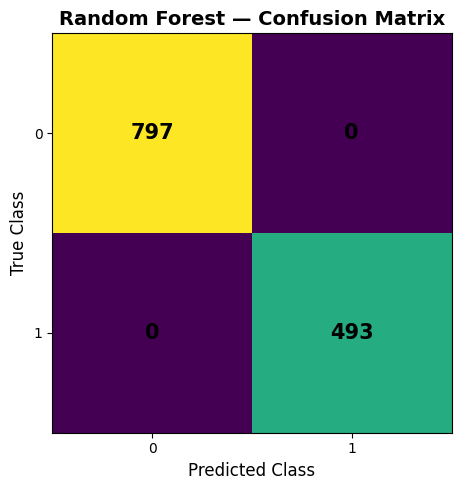

✓ Random Forest confusion matrix saved

GENERATING COMBINED CONFUSION MATRIX FIGURE


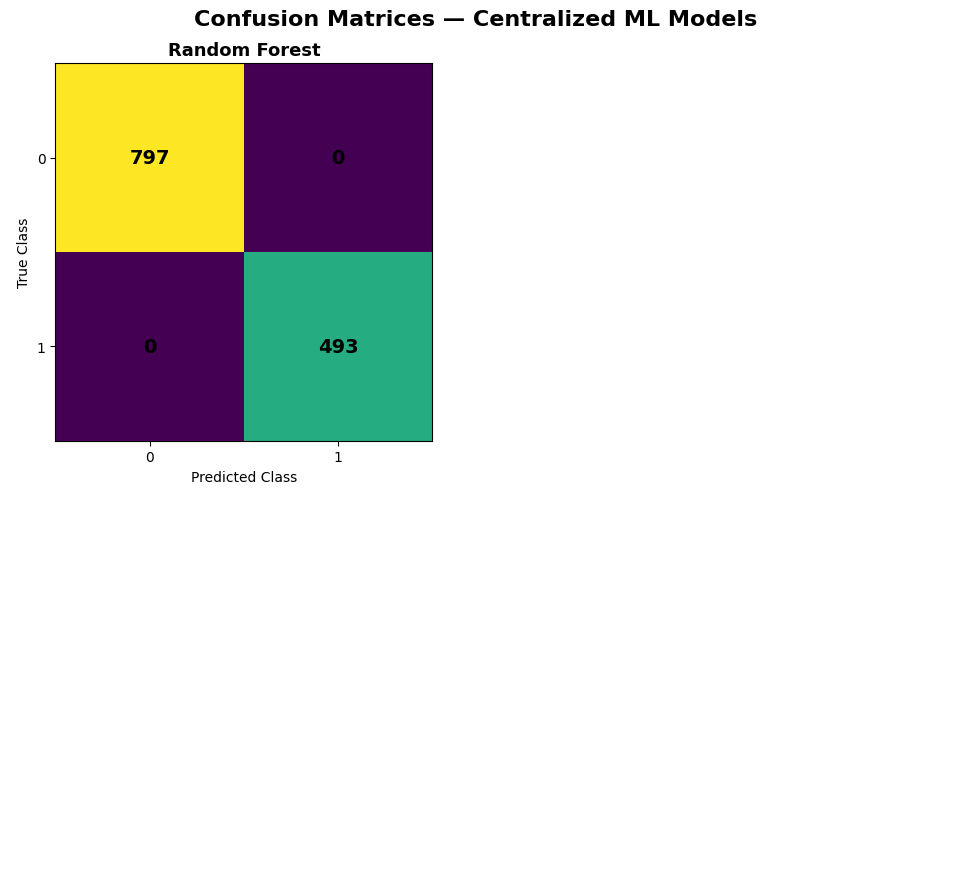

✓ Combined confusion matrix figure saved

GENERATING ROC CURVES


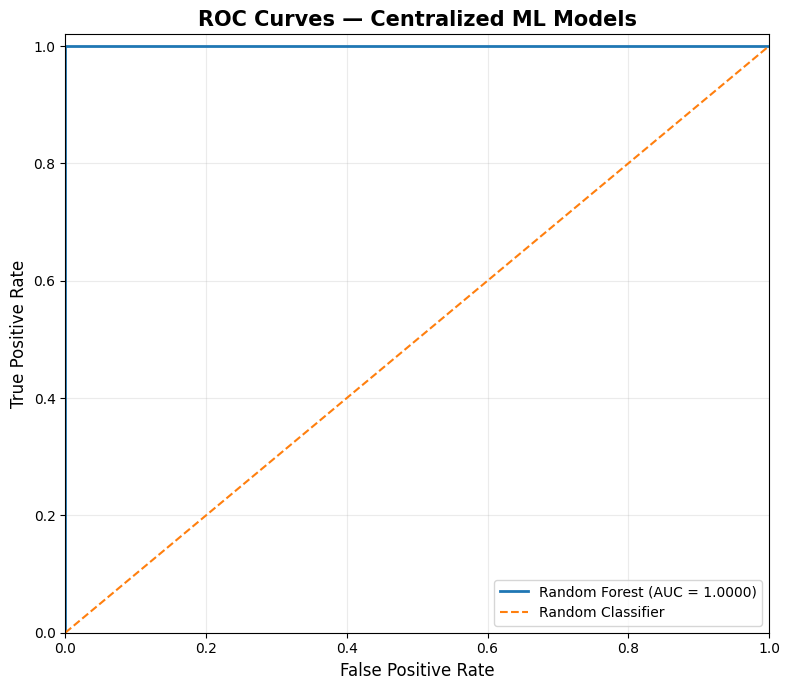

✓ ROC comparison saved

GENERATING PRECISION-RECALL CURVES


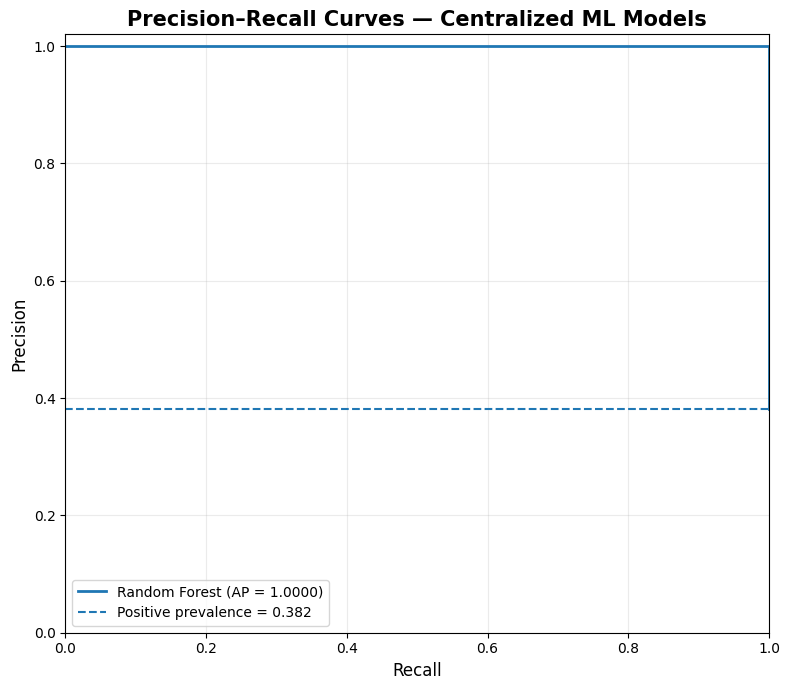

✓ Precision–Recall comparison saved

GENERATING MODEL METRIC COMPARISON


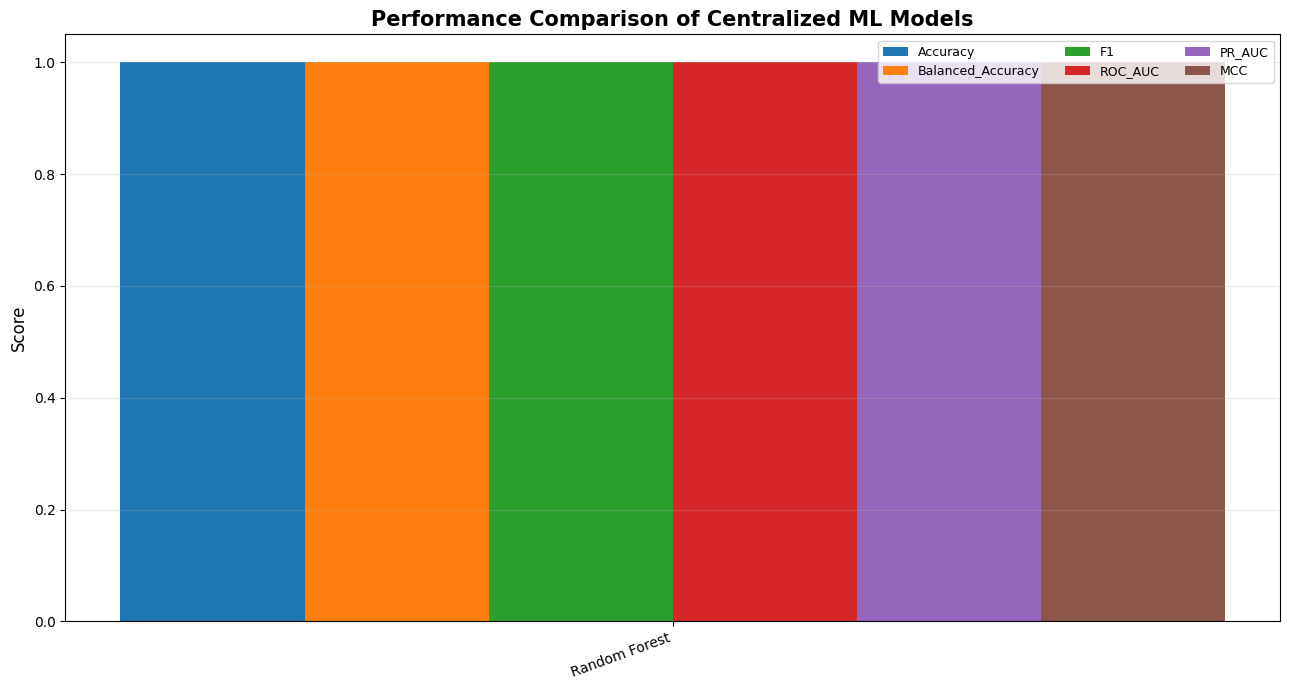

✓ Metric comparison saved

GENERATING INDIVIDUAL METRIC FIGURES


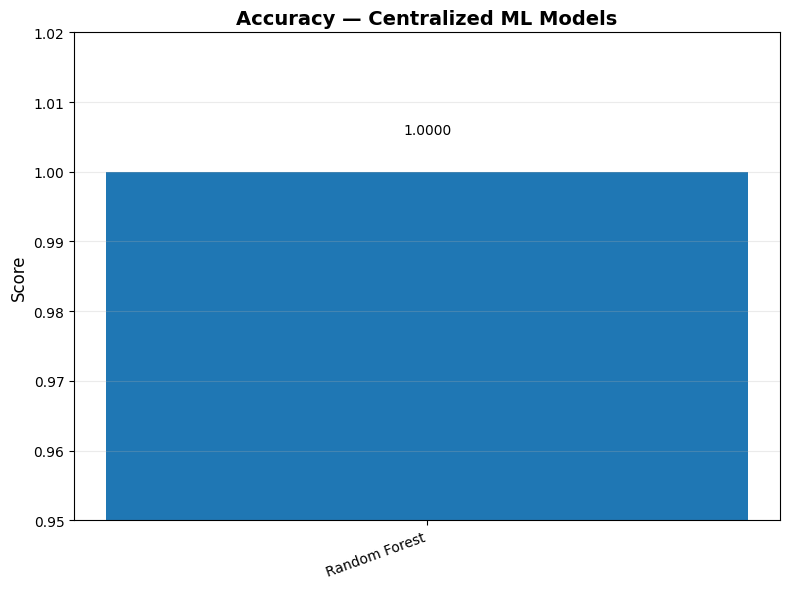

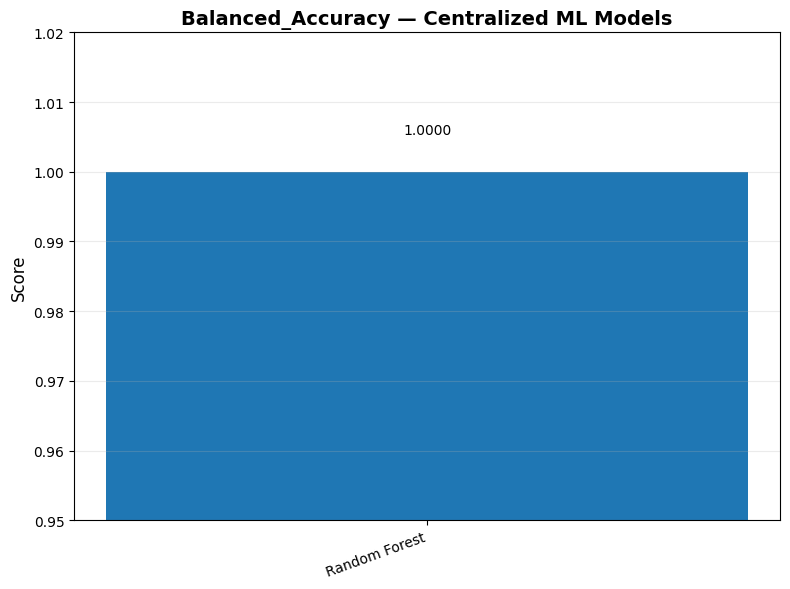

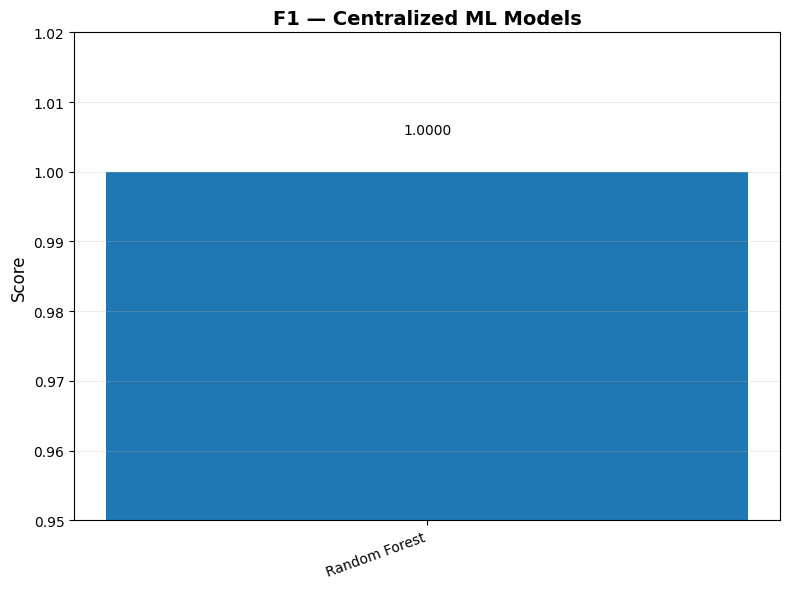

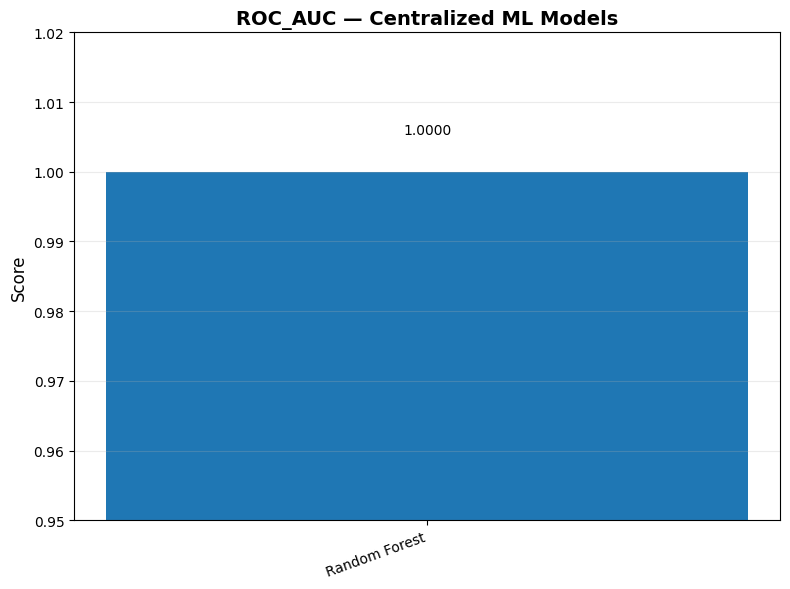

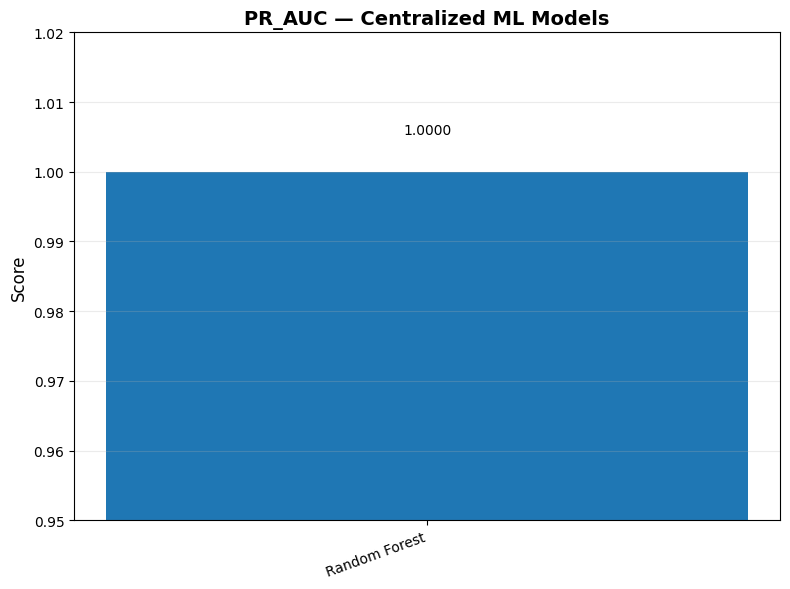

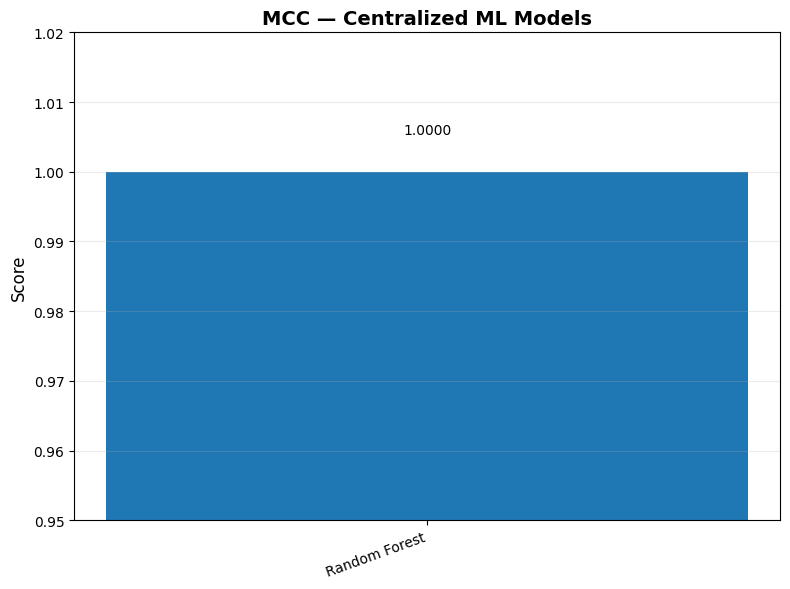

✓ Individual metric figures saved

FINAL LOCKED-TEST FIGURE DATA


,Model,Accuracy,Balanced_Accuracy,F1,ROC_AUC,PR_AUC,MCC
0,Random Forest,1.0,1.0,1.0,1.0,1.0,1.0



GENERATED FILES
✓ centralized_ml_accuracy.pdf
✓ centralized_ml_accuracy.png
✓ centralized_ml_balanced_accuracy.pdf
✓ centralized_ml_balanced_accuracy.png
✓ centralized_ml_combined_confusion_matrices.pdf
✓ centralized_ml_combined_confusion_matrices.png
✓ centralized_ml_f1.pdf
✓ centralized_ml_f1.png
✓ centralized_ml_mcc.pdf
✓ centralized_ml_mcc.png
✓ centralized_ml_metric_comparison.pdf
✓ centralized_ml_metric_comparison.png
✓ centralized_ml_pr_auc.pdf
✓ centralized_ml_pr_auc.png
✓ centralized_ml_precision_recall_curves.pdf
✓ centralized_ml_precision_recall_curves.png
✓ centralized_ml_roc_auc.pdf
✓ centralized_ml_roc_auc.png
✓ centralized_ml_roc_curves.pdf
✓ centralized_ml_roc_curves.png
✓ phase21_ml_locked_test_metrics_recomputed.csv
✓ random_forest_confusion_matrix.pdf
✓ random_forest_confusion_matrix.png

PHASE 21 INTEGRITY CHECK
✓ No model retraining performed
✓ Saved locked-test predictions used
✓ Locked test size expected: 1290
✓ All available models contain 1,290 test samples
✓ 

In [5]:
# ============================================================
# PHASE 21 — PUBLICATION-QUALITY ML FIGURES
# ============================================================
# Models:
#   1. Random Forest
#   2. Extra Trees
#   3. HistGradientBoosting
#   4. Linear SVM
#
# Uses SAVED locked-test predictions only.
# NO retraining.
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

print("=" * 100)
print("PHASE 21 — PUBLICATION-QUALITY ML FIGURES")
print("=" * 100)


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "phase21_ml_figures"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("\nOutput directory:")
print(OUTPUT_DIR)


# ============================================================
# 2. FILE PATHS
# ============================================================

FILES = {

    "Random Forest":
        "phase20_ml_locked_test_predictions.csv",

    "Extra Trees":
        "phase20_ml_extra_trees_locked_test_predictions.csv",

    "HistGradientBoosting":
        "phase20_ml_hist_gradient_boosting_locked_test_predictions.csv",

    "Linear SVM":
        "phase20_ml_linear_svm_locked_test_predictions.csv"
}


# ============================================================
# 3. CHECK FILES
# ============================================================

print("\n" + "=" * 100)
print("CHECKING SAVED PREDICTION FILES")
print("=" * 100)

for model, path in FILES.items():

    if os.path.exists(path):
        print(f"✓ {model:<25} {path}")

    else:
        print(f"✗ {model:<25} NOT FOUND")
        print("  Change the filename in FILES if required.")


# ============================================================
# 4. LOAD PREDICTIONS
# ============================================================

predictions = {}

for model, path in FILES.items():

    if not os.path.exists(path):
        continue

    df = pd.read_csv(path)

    print("\n" + "-" * 90)
    print(model)
    print("-" * 90)

    print("Shape:", df.shape)
    print("Columns:", list(df.columns))

    predictions[model] = df


# ============================================================
# 5. COLUMN NORMALIZATION
# ============================================================

def find_column(df, possible_names):

    for name in possible_names:

        if name in df.columns:
            return name

    return None


normalized = {}

for model, df in predictions.items():

    target_col = find_column(
        df,
        [
            "severity",
            "target",
            "y_true",
            "true",
            "actual"
        ]
    )

    pred_col = find_column(
        df,
        [
            "prediction",
            "pred",
            "y_pred",
            "predicted"
        ]
    )

    prob_col = find_column(
        df,
        [
            "probability",
            "prob",
            "score",
            "decision_score",
            "y_prob"
        ]
    )

    if target_col is None:
        raise ValueError(
            f"{model}: target/severity column not found."
        )

    if pred_col is None:
        raise ValueError(
            f"{model}: prediction column not found."
        )

    if prob_col is None:
        raise ValueError(
            f"{model}: probability/score column not found."
        )

    normalized[model] = {
        "df": df,
        "y_true": df[target_col].astype(int).values,
        "y_pred": df[pred_col].astype(int).values,
        "score": df[prob_col].astype(float).values
    }

    print(
        f"✓ {model}: "
        f"target={target_col}, "
        f"prediction={pred_col}, "
        f"score={prob_col}"
    )


# ============================================================
# 6. VERIFY TEST SIZE
# ============================================================

print("\n" + "=" * 100)
print("LOCKED TEST VERIFICATION")
print("=" * 100)

for model, data in normalized.items():

    n = len(data["y_true"])

    print(
        f"{model:<25}: {n} samples"
    )

    if n != 1290:
        print(
            f"WARNING: expected 1290, found {n}"
        )


# ============================================================
# 7. METRICS FROM SAVED PREDICTIONS
# ============================================================

metrics_records = []

for model, data in normalized.items():

    y_true = data["y_true"]
    y_pred = data["y_pred"]
    score = data["score"]

    metrics_records.append({

        "Model": model,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                score
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                score
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred
            )
    })


metrics_df = pd.DataFrame(
    metrics_records
)

print("\n" + "=" * 100)
print("METRICS FROM SAVED LOCKED-TEST PREDICTIONS")
print("=" * 100)

print(
    metrics_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 8. SAVE METRICS
# ============================================================

metrics_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "phase21_ml_locked_test_metrics_recomputed.csv"
    ),
    index=False
)


# ============================================================
# 9. CONFUSION MATRIX — INDIVIDUAL FIGURES
# ============================================================

print("\n" + "=" * 100)
print("GENERATING CONFUSION MATRICES")
print("=" * 100)

for model, data in normalized.items():

    y_true = data["y_true"]
    y_pred = data["y_pred"]

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    image = ax.imshow(
        cm,
        interpolation="nearest"
    )

    ax.set_title(
        f"{model} — Confusion Matrix",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Predicted Class",
        fontsize=12
    )

    ax.set_ylabel(
        "True Class",
        fontsize=12
    )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(
        ["0", "1"]
    )

    ax.set_yticklabels(
        ["0", "1"]
    )

    # Write values inside cells
    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            ax.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center",
                fontsize=15,
                fontweight="bold"
            )

    plt.tight_layout()

    png_path = os.path.join(
        OUTPUT_DIR,
        f"{model.lower().replace(' ', '_')}_confusion_matrix.png"
    )

    pdf_path = os.path.join(
        OUTPUT_DIR,
        f"{model.lower().replace(' ', '_')}_confusion_matrix.pdf"
    )

    plt.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(
        f"✓ {model} confusion matrix saved"
    )


# ============================================================
# 10. COMBINED CONFUSION MATRICES
# ============================================================

print("\n" + "=" * 100)
print("GENERATING COMBINED CONFUSION MATRIX FIGURE")
print("=" * 100)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 9)
)

axes = axes.flatten()

model_order = [
    "Random Forest",
    "HistGradientBoosting",
    "Linear SVM",
    "Extra Trees"
]

for ax, model in zip(
    axes,
    model_order
):

    if model not in normalized:
        ax.axis("off")
        continue

    y_true = normalized[model]["y_true"]
    y_pred = normalized[model]["y_pred"]

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    ax.imshow(
        cm,
        interpolation="nearest"
    )

    ax.set_title(
        model,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Predicted Class"
    )

    ax.set_ylabel(
        "True Class"
    )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    for i in range(2):

        for j in range(2):

            ax.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold"
            )

plt.suptitle(
    "Confusion Matrices — Centralized ML Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "centralized_ml_combined_confusion_matrices.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "centralized_ml_combined_confusion_matrices.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

plt.close()

print("✓ Combined confusion matrix figure saved")


# ============================================================
# 11. ROC CURVES
# ============================================================

print("\n" + "=" * 100)
print("GENERATING ROC CURVES")
print("=" * 100)

plt.figure(
    figsize=(8, 7)
)

for model in model_order:

    if model not in normalized:
        continue

    y_true = normalized[model]["y_true"]
    score = normalized[model]["score"]

    fpr, tpr, _ = roc_curve(
        y_true,
        score
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model} (AUC = {roc_auc_value:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "ROC Curves — Centralized ML Models",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.grid(
    True,
    alpha=0.25
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.02
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "centralized_ml_roc_curves.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "centralized_ml_roc_curves.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

plt.close()

print("✓ ROC comparison saved")


# ============================================================
# 12. PRECISION-RECALL CURVES
# ============================================================

print("\n" + "=" * 100)
print("GENERATING PRECISION-RECALL CURVES")
print("=" * 100)

plt.figure(
    figsize=(8, 7)
)

for model in model_order:

    if model not in normalized:
        continue

    y_true = normalized[model]["y_true"]
    score = normalized[model]["score"]

    precision, recall, _ = precision_recall_curve(
        y_true,
        score
    )

    pr_auc_value = average_precision_score(
        y_true,
        score
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model} (AP = {pr_auc_value:.4f})"
    )

# Positive-class prevalence baseline
positive_rate = np.mean(
    normalized[model_order[0]]["y_true"]
)

plt.axhline(
    positive_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Positive prevalence = {positive_rate:.3f}"
)

plt.xlabel(
    "Recall",
    fontsize=12
)

plt.ylabel(
    "Precision",
    fontsize=12
)

plt.title(
    "Precision–Recall Curves — Centralized ML Models",
    fontsize=15,
    fontweight="bold"
)

plt.legend(
    loc="lower left",
    fontsize=10
)

plt.grid(
    True,
    alpha=0.25
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1.02
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "centralized_ml_precision_recall_curves.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "centralized_ml_precision_recall_curves.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

plt.close()

print("✓ Precision–Recall comparison saved")


# ============================================================
# 13. METRIC COMPARISON
# ============================================================

print("\n" + "=" * 100)
print("GENERATING MODEL METRIC COMPARISON")
print("=" * 100)

metric_names = [
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "MCC"
]

x = np.arange(
    len(metrics_df)
)

width = 0.12

fig, ax = plt.subplots(
    figsize=(13, 7)
)

for i, metric in enumerate(
    metric_names
):

    values = metrics_df[metric].values

    ax.bar(
        x + (i - 2.5) * width,
        values,
        width,
        label=metric
    )

ax.set_xticks(
    x
)

ax.set_xticklabels(
    metrics_df["Model"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Score",
    fontsize=12
)

ax.set_ylim(
    0,
    1.05
)

ax.set_title(
    "Performance Comparison of Centralized ML Models",
    fontsize=15,
    fontweight="bold"
)

ax.legend(
    fontsize=9,
    ncol=3
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "centralized_ml_metric_comparison.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "centralized_ml_metric_comparison.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

plt.close()

print("✓ Metric comparison saved")


# ============================================================
# 14. INDIVIDUAL METRIC FIGURES
# ============================================================

print("\n" + "=" * 100)
print("GENERATING INDIVIDUAL METRIC FIGURES")
print("=" * 100)

for metric in metric_names:

    plt.figure(
        figsize=(8, 6)
    )

    values = metrics_df[metric].values

    bars = plt.bar(
        metrics_df["Model"],
        values
    )

    plt.ylabel(
        "Score",
        fontsize=12
    )

    plt.title(
        f"{metric} — Centralized ML Models",
        fontsize=14,
        fontweight="bold"
    )

    plt.ylim(
        max(0, min(values) - 0.05),
        1.02
    )

    plt.xticks(
        rotation=20,
        ha="right"
    )

    plt.grid(
        axis="y",
        alpha=0.25
    )

    for bar, value in zip(
        bars,
        values
    ):

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.005,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()

    filename = (
        metric.lower()
        .replace(" ", "_")
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"centralized_ml_{filename}.png"
        ),
        dpi=600,
        bbox_inches="tight"
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"centralized_ml_{filename}.pdf"
        ),
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

print("✓ Individual metric figures saved")


# ============================================================
# 15. FINAL RESULTS TABLE
# ============================================================

print("\n" + "=" * 100)
print("FINAL LOCKED-TEST FIGURE DATA")
print("=" * 100)

display(
    metrics_df.round(4)
)


# ============================================================
# 16. LIST OUTPUT FILES
# ============================================================

print("\n" + "=" * 100)
print("GENERATED FILES")
print("=" * 100)

for filename in sorted(
    os.listdir(OUTPUT_DIR)
):

    print("✓", filename)


# ============================================================
# 17. INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 21 INTEGRITY CHECK")
print("=" * 100)

print("✓ No model retraining performed")
print("✓ Saved locked-test predictions used")
print("✓ Locked test size expected: 1290")

for model, data in normalized.items():

    assert len(data["y_true"]) == 1290

print("✓ All available models contain 1,290 test samples")

print("✓ ROC curves generated")
print("✓ PR curves generated")
print("✓ Individual confusion matrices generated")
print("✓ Combined confusion matrices generated")
print("✓ Metric comparison generated")
print("✓ Individual metric plots generated")
print("✓ PNG figures saved at 600 DPI")
print("✓ PDF vector figures saved")

print("\n" + "=" * 100)
print("PHASE 21 — ML FIGURE GENERATION COMPLETED")
print("=" * 100)

In [6]:
# ============================================================
# PHASE 20H — SUBJECT-WISE FEDERATED EXTRA TREES
# CPU-ONLY
# NO LOCKED-TEST OPTIMIZATION
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20H — CPU-ONLY SUBJECT-WISE FEDERATED EXTRA TREES")
print("=" * 100)

# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)

# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values

# ============================================================
# 3. FEATURE CONFIGURATION
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:2d}. {feature}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded")

# ============================================================
# 4. LOCKED TRAIN / TEST
# ============================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = set(train_pool[GROUP].unique())
test_subjects = set(locked_test[GROUP].unique())

print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows :", len(train_pool))
print("Test rows     :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("Subject overlap:", train_subjects & test_subjects)

assert len(train_pool) == 4585
assert len(locked_test) == 1290
assert len(train_subjects) == 33
assert len(test_subjects) == 9
assert len(train_subjects & test_subjects) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test remains untouched")

# ============================================================
# 5. SUBJECT-WISE DEVELOPMENT / VALIDATION
# ============================================================

sorted_train_subjects = sorted(train_subjects)

rng = np.random.RandomState(42)

shuffled_subjects = rng.permutation(
    sorted_train_subjects
)

validation_subjects = set(
    shuffled_subjects[-7:]
)

development_subjects = set(
    shuffled_subjects[:-7]
)

development = train_pool[
    train_pool[GROUP].isin(development_subjects)
].copy()

validation = train_pool[
    train_pool[GROUP].isin(validation_subjects)
].copy()

print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print("Development subjects:", len(development_subjects))
print("Validation subjects :", len(validation_subjects))

print(
    "Subject overlap:",
    development_subjects & validation_subjects
)

assert len(development_subjects) == 26
assert len(validation_subjects) == 7
assert len(development_subjects & validation_subjects) == 0

print("✓ ZERO development/validation subject overlap")

# ============================================================
# 6. PREPROCESSING
# ============================================================

X_dev_raw = development[FEATURES].copy()
y_dev = development[TARGET].astype(int).values

X_val_raw = validation[FEATURES].copy()
y_val = validation[TARGET].astype(int).values

X_test_raw = locked_test[FEATURES].copy()
y_test = locked_test[TARGET].astype(int).values

imputer = SimpleImputer(strategy="median")

X_dev_imp = imputer.fit_transform(X_dev_raw)
X_val_imp = imputer.transform(X_val_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()

X_dev = scaler.fit_transform(X_dev_imp)
X_val = scaler.transform(X_val_imp)
X_test = scaler.transform(X_test_imp)

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print("✓ Imputer fitted only on development")
print("✓ Scaler fitted only on development")
print("✓ Validation transformed only")
print("✓ Locked test transformed only")

# ============================================================
# 7. FEDERATED CLIENTS
# ============================================================

clients = {}

for subject in sorted(development_subjects):

    mask = (
        development[GROUP].values == subject
    )

    clients[subject] = {
        "X": X_dev[mask],
        "y": y_dev[mask]
    }

print("\n" + "=" * 100)
print("FEDERATED CLIENTS")
print("=" * 100)

print("Number of clients:", len(clients))

assert len(clients) == 26

# ============================================================
# 8. MODEL FACTORY
# ============================================================

def create_model(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    max_features="sqrt"
):

    return ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    )

# ============================================================
# 9. LOCAL TRAINING
# ============================================================

def train_local_model(
    X,
    y,
    n_estimators,
    max_depth,
    min_samples_leaf,
    max_features
):

    # Single-class client protection
    unique_classes = np.unique(y)

    if len(unique_classes) == 1:

        return {
            "type": "constant",
            "class": int(unique_classes[0]),
            "n_samples": len(y)
        }

    model = create_model(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features
    )

    model.fit(X, y)

    return {
        "type": "model",
        "model": model,
        "n_samples": len(y)
    }

# ============================================================
# 10. FEDERATED PREDICTION AGGREGATION
# ============================================================

def federated_predict(
    local_models,
    X
):

    probabilities = []
    weights = []

    for client in local_models:

        weight = client["n_samples"]

        if client["type"] == "constant":

            prob = np.full(
                X.shape[0],
                float(client["class"])
            )

        else:

            model = client["model"]

            prob = model.predict_proba(X)[:, 1]

        probabilities.append(prob)
        weights.append(weight)

    probabilities = np.asarray(probabilities)
    weights = np.asarray(weights, dtype=float)

    weighted_probability = np.average(
        probabilities,
        axis=0,
        weights=weights
    )

    predictions = (
        weighted_probability >= 0.5
    ).astype(int)

    return predictions, weighted_probability

# ============================================================
# 11. EVALUATION
# ============================================================

def evaluate_predictions(y, pred, prob):

    return {
        "Accuracy": accuracy_score(y, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y, pred),
        "Precision": precision_score(
            y, pred, zero_division=0
        ),
        "Recall": recall_score(
            y, pred, zero_division=0
        ),
        "F1": f1_score(
            y, pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(y, prob),
        "PR_AUC": average_precision_score(y, prob),
        "MCC": matthews_corrcoef(y, pred)
    }

# ============================================================
# 12. FEDERATED EXPERIMENT
# ============================================================

def run_federated_experiment(
    name,
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    max_features="sqrt"
):

    print("\n")
    print("=" * 100)
    print("EXPERIMENT:", name)
    print("=" * 100)

    local_models = []

    for subject in sorted(clients):

        client = clients[subject]

        local_model = train_local_model(
            X=client["X"],
            y=client["y"],
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features
        )

        local_models.append(local_model)

    val_pred, val_prob = federated_predict(
        local_models,
        X_val
    )

    metrics = evaluate_predictions(
        y_val,
        val_pred,
        val_prob
    )

    print(
        f"Validation | "
        f"Acc={metrics['Accuracy']:.4f} | "
        f"BalAcc={metrics['Balanced_Accuracy']:.4f} | "
        f"F1={metrics['F1']:.4f} | "
        f"ROC-AUC={metrics['ROC_AUC']:.4f} | "
        f"PR-AUC={metrics['PR_AUC']:.4f} | "
        f"MCC={metrics['MCC']:.4f}"
    )

    return (
        local_models,
        metrics
    )

# ============================================================
# 13. EXPERIMENT CONFIGURATIONS
# ============================================================

experiments = [

    {
        "name": "FedExtraTrees_A",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },

    {
        "name": "FedExtraTrees_B",
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },

    {
        "name": "FedExtraTrees_C",
        "n_estimators": 500,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    }
]

# ============================================================
# 14. RUN ALL CONFIGURATIONS
# ============================================================

records = []

for cfg in experiments:

    local_models, metrics = run_federated_experiment(
        name=cfg["name"],
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features=cfg["max_features"]
    )

    records.append({
        "Model": cfg["name"],
        "n_estimators": cfg["n_estimators"],
        "max_depth": cfg["max_depth"],
        "min_samples_leaf": cfg["min_samples_leaf"],
        "max_features": cfg["max_features"],
        **metrics,
        "local_models": local_models
    })

# ============================================================
# 15. INTERNAL COMPARISON
# ============================================================

comparison = pd.DataFrame(records)

display_cols = [
    "Model",
    "n_estimators",
    "max_depth",
    "min_samples_leaf",
    "max_features",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "MCC"
]

comparison_display = (
    comparison[
        display_cols
    ]
    .sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("INTERNAL FEDERATED EXTRA TREES COMPARISON")
print("=" * 100)

display(comparison_display)

# ============================================================
# 16. SELECT BEST CONFIGURATION
# ============================================================

best_model_name = comparison_display.iloc[0]["Model"]

best_record = next(
    r for r in records
    if r["Model"] == best_model_name
)

print("\n" + "=" * 100)
print("BEST FEDERATED EXTRA TREES CONFIGURATION")
print("=" * 100)

print("Selected model:", best_model_name)
print("n_estimators  :", best_record["n_estimators"])
print("max_depth     :", best_record["max_depth"])
print("min_samples_leaf:", best_record["min_samples_leaf"])
print("max_features  :", best_record["max_features"])

print("\nSelection criterion:")
print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")

print("\n✓ Locked test NOT used for selection")

# ============================================================
# 17. FREEZE FINAL FEDERATED MODEL
# ============================================================

final_local_models = best_record["local_models"]

print("\n" + "=" * 100)
print("FEDERATED MODEL FROZEN")
print("=" * 100)

print("✓ Best federated Extra Trees configuration frozen")
print("✓ Validation used only for selection")
print("✓ Locked test remains untouched")
print("✓ Local client Extra Trees retained")
print("✓ Server federated ensemble frozen")

# ============================================================
# 18. ONE-TIME LOCKED TEST
# ============================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)

test_pred, test_prob = federated_predict(
    final_local_models,
    X_test
)

test_metrics = evaluate_predictions(
    y_test,
    test_pred,
    test_prob
)

print("\n" + "=" * 100)
print("FINAL FEDERATED EXTRA TREES LOCKED TEST RESULT")
print("=" * 100)

for key, value in test_metrics.items():

    print(
        f"{key:<22}: {value:.4f}"
    )

# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

cm = confusion_matrix(
    y_test,
    test_pred
)

print(cm)

# ============================================================
# 20. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 21. SAVE RESULTS
# ============================================================

comparison_display.to_csv(
    "phase20H_fl_extra_trees_internal_model_comparison.csv",
    index=False
)

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

test_metrics_df.insert(
    0,
    "Model",
    best_model_name
)

test_metrics_df.to_csv(
    "phase20H_fl_extra_trees_locked_test_metrics.csv",
    index=False
)

predictions_df = locked_test[
    ["subject#", "severity"]
].copy()

predictions_df["prediction"] = test_pred
predictions_df["probability"] = test_prob

predictions_df.to_csv(
    "phase20H_fl_extra_trees_locked_test_predictions.csv",
    index=False
)

# ============================================================
# 22. INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20H INTEGRITY CHECK")
print("=" * 100)

print("✓ Original dataset      :", len(work_df))
print("✓ Training pool         :", len(train_pool))
print("✓ Development rows     :", len(development))
print("✓ Validation rows      :", len(validation))
print("✓ Locked test rows     :", len(locked_test))

print("✓ Development subjects :", len(development_subjects))
print("✓ Validation subjects  :", len(validation_subjects))
print("✓ Locked test subjects :", len(test_subjects))

print(
    "✓ Development/validation overlap:",
    development_subjects & validation_subjects
)

print(
    "✓ Development/test overlap:",
    development_subjects & test_subjects
)

print(
    "✓ Validation/test overlap:",
    validation_subjects & test_subjects
)

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded from features")
print("✓ Each development subject treated as FL client")
print("✓ Local Extra Trees trained independently")
print("✓ Weighted federated probability aggregation")
print("✓ Preprocessing fitted only on development data")
print("✓ Validation used for configuration selection")
print("✓ Locked test evaluated once after freezing")
print("✓ No locked-test optimization")

print("\nSaved:")
print("✓ phase20H_fl_extra_trees_internal_model_comparison.csv")
print("✓ phase20H_fl_extra_trees_locked_test_metrics.csv")
print("✓ phase20H_fl_extra_trees_locked_test_predictions.csv")

print("\n" + "=" * 100)
print("PHASE 20H COMPLETED")
print("=" * 100)

PHASE 20H — CPU-ONLY SUBJECT-WISE FEDERATED EXTRA TREES

Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ split excluded

LOCKED SPLIT
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test remains untouched

DEVELOPMENT / VALIDATION SPLIT
Development rows : 3639
Validation rows  : 946
Development subjects: 26
Validation subjects : 7
Subject overlap: set()
✓ ZERO development/validation subject overlap

PREPROCESSING
✓ Imputer fitted only on development
✓ Scaler fitt

,Model,n_estimators,max_depth,min_samples_leaf,max_features,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,FedExtraTrees_A,300,NaN,1,sqrt,0.718816,0.5,0.0,0.0,0.0,0.999784,0.999459,0.0
1,FedExtraTrees_B,500,NaN,1,sqrt,0.718816,0.5,0.0,0.0,0.0,0.999757,0.999392,0.0
2,FedExtraTrees_C,500,20.0,1,sqrt,0.718816,0.5,0.0,0.0,0.0,0.999762,0.999406,0.0



BEST FEDERATED EXTRA TREES CONFIGURATION
Selected model: FedExtraTrees_A
n_estimators  : 300
max_depth     : None
min_samples_leaf: 1
max_features  : sqrt

Selection criterion:
1. Balanced Accuracy
2. F1
3. MCC

✓ Locked test NOT used for selection

FEDERATED MODEL FROZEN
✓ Best federated Extra Trees configuration frozen
✓ Validation used only for selection
✓ Locked test remains untouched
✓ Local client Extra Trees retained
✓ Server federated ensemble frozen

ONE-TIME LOCKED TEST EVALUATION

FINAL FEDERATED EXTRA TREES LOCKED TEST RESULT
Accuracy              : 0.6178
Balanced_Accuracy     : 0.5000
Precision             : 0.0000
Recall                : 0.0000
F1                    : 0.0000
ROC_AUC               : 0.9999
PR_AUC                : 0.9998
MCC                   : 0.0000

CONFUSION MATRIX
[[797   0]
 [493   0]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.6178    1.0000    0.7638       797
           1     0.0000    0.0000 

In [9]:
# ====================================================================================================
# PHASE 20H — CPU-ONLY SUBJECT-WISE FEDERATED EXTRA TREES
# ====================================================================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20H — CPU-ONLY SUBJECT-WISE FEDERATED EXTRA TREES")
print("=" * 100)


# ====================================================================================================
# 1. PATHS
# ====================================================================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)


# ====================================================================================================
# 2. LOAD DATA
# ====================================================================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")


# ====================================================================================================
# 3. ATTACH LOCKED SPLIT
# ====================================================================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values


# ====================================================================================================
# 4. FEATURE CONFIGURATION
# ====================================================================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, f in enumerate(FEATURES, 1):
    print(f"{i:2d}. {f}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded")


# ====================================================================================================
# 5. DATA QUALITY
# ====================================================================================================

print("\n" + "=" * 100)
print("DATA QUALITY")
print("=" * 100)

feature_data = work_df[FEATURES]

print("Missing values:", feature_data.isna().sum().sum())
print("Infinite values:", np.isinf(feature_data.select_dtypes(include=np.number)).sum().sum())


# ====================================================================================================
# 6. LOCKED TRAIN / TEST
# ====================================================================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = set(train_pool[GROUP].unique())
test_subjects = set(locked_test[GROUP].unique())

print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows :", len(train_pool))
print("Test rows     :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("Subject overlap:", train_subjects & test_subjects)

assert len(train_pool) == 4585
assert len(locked_test) == 1290
assert len(train_subjects) == 33
assert len(test_subjects) == 9
assert len(train_subjects & test_subjects) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test remains untouched")


# ====================================================================================================
# 7. SUBJECT-WISE DEVELOPMENT / VALIDATION SPLIT
# ====================================================================================================

sorted_train_subjects = sorted(train_subjects)

rng = np.random.RandomState(42)

shuffled_subjects = rng.permutation(
    sorted_train_subjects
)

validation_subjects = set(
    shuffled_subjects[-7:]
)

development_subjects = set(
    shuffled_subjects[:-7]
)

development = train_pool[
    train_pool[GROUP].isin(development_subjects)
].copy()

validation = train_pool[
    train_pool[GROUP].isin(validation_subjects)
].copy()

print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print("Development subjects:", len(development_subjects))
print("Validation subjects :", len(validation_subjects))

print(
    "Subject overlap:",
    development_subjects & validation_subjects
)

assert len(development) == 3639
assert len(validation) == 946

assert len(development_subjects) == 26
assert len(validation_subjects) == 7

assert len(
    development_subjects & validation_subjects
) == 0

print("✓ Subject-wise validation")
print("✓ ZERO development/validation subject overlap")


# ====================================================================================================
# 8. PREPROCESSING
# ====================================================================================================

X_dev_raw = development[FEATURES].copy()
y_dev = development[TARGET].astype(int).values

X_val_raw = validation[FEATURES].copy()
y_val = validation[TARGET].astype(int).values

X_test_raw = locked_test[FEATURES].copy()
y_test = locked_test[TARGET].astype(int).values


imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = imputer.fit_transform(
    X_dev_raw
)

X_val_imp = imputer.transform(
    X_val_raw
)

X_test_imp = imputer.transform(
    X_test_raw
)


scaler = StandardScaler()

X_dev = scaler.fit_transform(
    X_dev_imp
)

X_val = scaler.transform(
    X_val_imp
)

X_test = scaler.transform(
    X_test_imp
)

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print("✓ Imputer fitted on development data only")
print("✓ StandardScaler fitted on development data only")
print("✓ Validation transformed using development preprocessing")
print("✓ Locked test transformed using development preprocessing")


# ====================================================================================================
# 9. CREATE FL CLIENTS
# ====================================================================================================

clients = {}

for subject in sorted(development_subjects):

    mask = (
        development[GROUP].values == subject
    )

    X_client = X_dev[mask]
    y_client = y_dev[mask]

    clients[subject] = {
        "X": X_client,
        "y": y_client
    }


print("\nNumber of FL clients:", len(clients))
print("✓ Each development subject treated as one FL client")


# ====================================================================================================
# 10. CHECK CLIENT CLASS DISTRIBUTION
# ====================================================================================================

print("\n" + "=" * 100)
print("CLIENT CLASS DISTRIBUTION")
print("=" * 100)

single_class_clients = []

for subject in sorted(clients):

    unique_classes = np.unique(
        clients[subject]["y"]
    )

    print(
        f"Subject {subject}: "
        f"rows={len(clients[subject]['y'])}, "
        f"classes={unique_classes.tolist()}"
    )

    if len(unique_classes) < 2:
        single_class_clients.append(subject)

print(
    "\nSingle-class clients:",
    single_class_clients
)

print(
    "✓ Single-class clients handled safely"
)


# ====================================================================================================
# 11. LOCAL EXTRA TREES MODEL
# ====================================================================================================

def create_model(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    random_state=42
):

    return ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=-1
    )


# ====================================================================================================
# 12. LOCAL TRAINING
# ====================================================================================================

def train_local_model(
    X,
    y,
    n_estimators,
    max_depth,
    min_samples_leaf,
    max_features,
    class_weight,
    random_state
):

    # ExtraTrees cannot train on a single class.
    # Such a client is skipped from model aggregation.

    if len(np.unique(y)) < 2:
        return None

    model = create_model(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state
    )

    model.fit(
        X,
        y
    )

    return model


# ====================================================================================================
# 13. FEDERATED ENSEMBLE PREDICTION
# ====================================================================================================

def federated_predict_proba(
    local_models,
    X,
    weights
):

    probability_sum = np.zeros(
        X.shape[0],
        dtype=float
    )

    total_weight = 0.0

    for model, weight in zip(
        local_models,
        weights
    ):

        # Full two-class client
        if len(model.classes_) == 2:

            class_one_index = np.where(
                model.classes_ == 1
            )[0][0]

            prob_one = model.predict_proba(X)[
                :, class_one_index
            ]

        # Defensive handling
        elif model.classes_[0] == 1:

            prob_one = np.ones(
                X.shape[0]
            )

        else:

            prob_one = np.zeros(
                X.shape[0]
            )

        probability_sum += (
            prob_one * weight
        )

        total_weight += weight

    if total_weight == 0:
        raise ValueError(
            "No valid two-class client models available."
        )

    return probability_sum / total_weight


# ====================================================================================================
# 14. EVALUATION
# ====================================================================================================

def evaluate_predictions(
    y,
    probability,
    threshold=0.5
):

    prediction = (
        probability >= threshold
    ).astype(int)

    metrics = {

        "Accuracy":
            accuracy_score(
                y,
                prediction
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y,
                prediction
            ),

        "Precision":
            precision_score(
                y,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y,
                prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y,
                prediction,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                probability
            ),

        "PR_AUC":
            average_precision_score(
                y,
                probability
            ),

        "MCC":
            matthews_corrcoef(
                y,
                prediction
            )
    }

    return (
        metrics,
        prediction
    )


# ====================================================================================================
# 15. RUN FEDERATED EXTRA TREES EXPERIMENT
# ====================================================================================================

def run_federated_experiment(
    name,
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight=None,
    rounds=15
):

    print("\n")
    print("=" * 100)
    print("EXPERIMENT:", name)
    print("=" * 100)

    history = []

    best_models = None
    best_weights = None

    for rnd in range(1, rounds + 1):

        local_models = []
        local_weights = []

        # ----------------------------------------------------------------
        # Train one local Extra Trees model per development subject
        # ----------------------------------------------------------------

        for client_index, subject in enumerate(
            sorted(clients)
        ):

            client = clients[subject]

            model = train_local_model(
                X=client["X"],
                y=client["y"],
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                class_weight=class_weight,
                random_state=42 + rnd * 100 + client_index
            )

            if model is None:
                continue

            local_models.append(model)

            # Sample-count weighted federation
            local_weights.append(
                len(client["y"])
            )

        # ----------------------------------------------------------------
        # Server-side weighted ensemble
        # ----------------------------------------------------------------

        val_probability = federated_predict_proba(
            local_models,
            X_val,
            local_weights
        )

        metrics, val_prediction = evaluate_predictions(
            y_val,
            val_probability,
            threshold=0.5
        )

        history.append({
            "experiment": name,
            "round": rnd,
            **metrics
        })

        print(
            f"Round {rnd:02d}/{rounds} | "
            f"Val Acc={metrics['Accuracy']:.4f} | "
            f"BalAcc={metrics['Balanced_Accuracy']:.4f} | "
            f"F1={metrics['F1']:.4f} | "
            f"ROC-AUC={metrics['ROC_AUC']:.4f} | "
            f"MCC={metrics['MCC']:.4f}"
        )

        # Keep current round's ensemble
        current_models = local_models
        current_weights = local_weights

    # ====================================================================
    # Select best round using validation only
    # ====================================================================

    history_df = pd.DataFrame(
        history
    )

    best_idx = history_df.sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    ).index[0]

    best_row = history_df.loc[
        best_idx
    ]

    best_round = int(
        best_row["round"]
    )

    print(
        "\nBest validation round:",
        best_round
    )

    # Recreate the exact selected round ensemble
    local_models = []
    local_weights = []

    for client_index, subject in enumerate(
        sorted(clients)
    ):

        client = clients[subject]

        model = train_local_model(
            X=client["X"],
            y=client["y"],
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=42 + best_round * 100 + client_index
        )

        if model is None:
            continue

        local_models.append(model)
        local_weights.append(
            len(client["y"])
        )

    return (
        local_models,
        local_weights,
        history_df,
        best_row
    )


# ====================================================================================================
# 16. MULTIPLE LEGITIMATE EXTRA TREES CONFIGURATIONS
# ====================================================================================================

experiments = [

    {
        "name": "FedExtraTrees_A",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "class_weight": None
    },

    {
        "name": "FedExtraTrees_B",
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "class_weight": None
    },

    {
        "name": "FedExtraTrees_C",
        "n_estimators": 500,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "class_weight": None
    },

    {
        "name": "FedExtraTrees_D",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "class_weight": None
    }

]


# ====================================================================================================
# 17. TRAIN ALL CONFIGURATIONS
# ====================================================================================================

all_histories = []
model_records = []

frozen_ensembles = {}

for cfg in experiments:

    (
        local_models,
        local_weights,
        history,
        best
    ) = run_federated_experiment(

        name=cfg["name"],

        n_estimators=cfg["n_estimators"],

        max_depth=cfg["max_depth"],

        min_samples_leaf=cfg["min_samples_leaf"],

        max_features=cfg["max_features"],

        class_weight=cfg["class_weight"],

        rounds=15
    )

    all_histories.append(
        history
    )

    frozen_ensembles[
        cfg["name"]
    ] = (
        local_models,
        local_weights
    )

    model_records.append({

        "Model":
            cfg["name"],

        "N_Estimators":
            cfg["n_estimators"],

        "Max_Depth":
            cfg["max_depth"],

        "Min_Samples_Leaf":
            cfg["min_samples_leaf"],

        "Max_Features":
            cfg["max_features"],

        "Best_Round":
            int(best["round"]),

        "Accuracy":
            best["Accuracy"],

        "Balanced_Accuracy":
            best["Balanced_Accuracy"],

        "Precision":
            best["Precision"],

        "Recall":
            best["Recall"],

        "F1":
            best["F1"],

        "ROC_AUC":
            best["ROC_AUC"],

        "PR_AUC":
            best["PR_AUC"],

        "MCC":
            best["MCC"]
    })


# ====================================================================================================
# 18. INTERNAL FL MODEL COMPARISON
# ====================================================================================================

comparison = pd.DataFrame(
    model_records
)

display_cols = [

    "Model",
    "N_Estimators",
    "Max_Depth",
    "Min_Samples_Leaf",
    "Max_Features",
    "Best_Round",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "MCC"
]

comparison_display = (
    comparison[
        display_cols
    ]
    .sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("INTERNAL FL EXTRA TREES MODEL COMPARISON")
print("=" * 100)

display(
    comparison_display
)


# ====================================================================================================
# 19. SELECT BEST CONFIGURATION
# ====================================================================================================

best_model_name = (
    comparison_display.iloc[0]["Model"]
)

best_record = next(
    r
    for r in model_records
    if r["Model"] == best_model_name
)

print("\n" + "=" * 100)
print("BEST INTERNAL FL EXTRA TREES CONFIGURATION")
print("=" * 100)

print(
    "Selected model:",
    best_model_name
)

print(
    "Best round    :",
    best_record["Best_Round"]
)

print(
    "N estimators  :",
    best_record["N_Estimators"]
)

print(
    "Max depth     :",
    best_record["Max_Depth"]
)

print(
    "Min leaf      :",
    best_record["Min_Samples_Leaf"]
)

print(
    "Max features  :",
    best_record["Max_Features"]
)

print("\nSelection criterion:")
print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")

print(
    "\nIMPORTANT:"
)

print(
    "The locked test set has NOT been used for model selection."
)


# ====================================================================================================
# 20. FREEZE BEST FEDERATED ENSEMBLE
# ====================================================================================================

final_models, final_weights = frozen_ensembles[
    best_model_name
]

print("\n" + "=" * 100)
print("FEDERATED MODEL FROZEN")
print("=" * 100)

print(
    "✓ Best federated Extra Trees configuration frozen"
)

print(
    "✓ Validation used only for selection"
)

print(
    "✓ Locked test remains untouched"
)

print(
    "✓ Local client Extra Trees models retained"
)

print(
    "✓ Server weighted federated ensemble frozen"
)


# ====================================================================================================
# 21. ONE-TIME LOCKED TEST EVALUATION
# ====================================================================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)

test_probability = federated_predict_proba(
    final_models,
    X_test,
    final_weights
)

test_metrics, test_pred = evaluate_predictions(
    y_test,
    test_probability,
    threshold=0.5
)


# ====================================================================================================
# 22. FINAL RESULTS
# ====================================================================================================

print("\n" + "=" * 100)
print("FINAL FEDERATED EXTRA TREES LOCKED TEST RESULT")
print("=" * 100)

for key, value in test_metrics.items():

    print(
        f"{key:<22}: {value:.4f}"
    )


# ====================================================================================================
# 23. CONFUSION MATRIX
# ====================================================================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

cm = confusion_matrix(
    y_test,
    test_pred
)

print(cm)


# ====================================================================================================
# 24. CLASSIFICATION REPORT
# ====================================================================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)


# ====================================================================================================
# 25. SAVE RESULTS
# ====================================================================================================

comparison_display.to_csv(
    "phase20H_fl_extra_trees_internal_model_comparison.csv",
    index=False
)

history_df = pd.concat(
    all_histories,
    ignore_index=True
)

history_df.to_csv(
    "phase20H_fl_extra_trees_all_round_results.csv",
    index=False
)

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

test_metrics_df.insert(
    0,
    "Model",
    best_model_name
)

test_metrics_df.to_csv(
    "phase20H_fl_extra_trees_locked_test_metrics.csv",
    index=False
)


predictions_df = locked_test[
    ["subject#", "severity"]
].copy()

predictions_df[
    "prediction"
] = test_pred

predictions_df[
    "probability"
] = test_probability

predictions_df.to_csv(
    "phase20H_fl_extra_trees_locked_test_predictions.csv",
    index=False
)


# ====================================================================================================
# 26. INTEGRITY CHECK
# ====================================================================================================

print("\n" + "=" * 100)
print("PHASE 20H INTEGRITY CHECK")
print("=" * 100)

print(
    "✓ Original dataset       :",
    len(work_df)
)

print(
    "✓ Development rows       :",
    len(development)
)

print(
    "✓ Validation rows        :",
    len(validation)
)

print(
    "✓ Locked test rows       :",
    len(locked_test)
)

print(
    "✓ Development subjects  :",
    len(development_subjects)
)

print(
    "✓ Validation subjects   :",
    len(validation_subjects)
)

print(
    "✓ Locked test subjects  :",
    len(test_subjects)
)

print(
    "✓ Development/validation overlap:",
    development_subjects &
    validation_subjects
)

print(
    "✓ Development/test overlap:",
    development_subjects &
    test_subjects
)

print(
    "✓ Validation/test overlap:",
    validation_subjects &
    test_subjects
)

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded from features")

print("✓ Each development subject treated as FL client")
print("✓ Local Extra Trees trained independently")
print("✓ Sample-count weighted federated ensemble")
print("✓ Single-class clients handled safely")
print("✓ Preprocessing fitted only on development data")
print("✓ Validation used for model/round selection")
print("✓ Locked test evaluated once after freezing")
print("✓ No locked-test optimization")


# ====================================================================================================
# 27. SAVED FILES
# ====================================================================================================

print("\nSaved:")

print(
    "✓ phase20H_fl_extra_trees_internal_model_comparison.csv"
)

print(
    "✓ phase20H_fl_extra_trees_all_round_results.csv"
)

print(
    "✓ phase20H_fl_extra_trees_locked_test_metrics.csv"
)

print(
    "✓ phase20H_fl_extra_trees_locked_test_predictions.csv"
)


print("\n" + "=" * 100)
print("PHASE 20H — FEDERATED EXTRA TREES COMPLETED")
print("=" * 100)

PHASE 20H — CPU-ONLY SUBJECT-WISE FEDERATED EXTRA TREES

Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ split excluded

DATA QUALITY
Missing values: 0
Infinite values: 0

LOCKED SPLIT
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test remains untouched

DEVELOPMENT / VALIDATION SPLIT
Development rows : 3639
Validation rows  : 946
Development subjects: 26
Validation subjects : 7
Subject overlap: set()
✓ Subject-wise validation
✓ ZERO development/validation subj

,Model,N_Estimators,Max_Depth,Min_Samples_Leaf,Max_Features,Best_Round,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,FedExtraTrees_D,300,NaN,2,sqrt,7,0.993658,0.994444,0.981481,0.996241,0.988806,0.999889,0.999719,0.984435
1,FedExtraTrees_A,300,NaN,1,sqrt,6,0.991543,0.994118,0.970803,1.000000,0.985185,0.999856,0.999637,0.979480
2,FedExtraTrees_B,500,NaN,1,sqrt,4,0.990486,0.992238,0.970696,0.996241,0.983302,0.999812,0.999529,0.976813
3,FedExtraTrees_C,500,20.0,1,sqrt,4,0.990486,0.992238,0.970696,0.996241,0.983302,0.999812,0.999529,0.976813



BEST INTERNAL FL EXTRA TREES CONFIGURATION
Selected model: FedExtraTrees_D
Best round    : 7
N estimators  : 300
Max depth     : None
Min leaf      : 2
Max features  : sqrt

Selection criterion:
1. Balanced Accuracy
2. F1
3. MCC

IMPORTANT:
The locked test set has NOT been used for model selection.

FEDERATED MODEL FROZEN
✓ Best federated Extra Trees configuration frozen
✓ Validation used only for selection
✓ Locked test remains untouched
✓ Local client Extra Trees models retained
✓ Server weighted federated ensemble frozen

ONE-TIME LOCKED TEST EVALUATION

FINAL FEDERATED EXTRA TREES LOCKED TEST RESULT
Accuracy              : 0.9946
Balanced_Accuracy     : 0.9952
Precision             : 0.9880
Recall                : 0.9980
F1                    : 0.9929
ROC_AUC               : 0.9999
PR_AUC                : 0.9999
MCC                   : 0.9886

CONFUSION MATRIX
[[791   6]
 [  1 492]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.99

In [10]:
# ====================================================================================================
# PHASE 20I — CPU-ONLY SUBJECT-WISE FEDERATED HISTGRADIENTBOOSTING
# ====================================================================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20I — CPU-ONLY SUBJECT-WISE FEDERATED HISTGRADIENTBOOSTING")
print("=" * 100)


# ====================================================================================================
# 1. PATHS
# ====================================================================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)


# ====================================================================================================
# 2. LOAD DATA
# ====================================================================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")


# ====================================================================================================
# 3. ATTACH LOCKED SPLIT
# ====================================================================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values


# ====================================================================================================
# 4. FEATURE CONFIGURATION
# ====================================================================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, f in enumerate(FEATURES, 1):
    print(f"{i:2d}. {f}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded")


# ====================================================================================================
# 5. DATA QUALITY
# ====================================================================================================

print("\n" + "=" * 100)
print("DATA QUALITY")
print("=" * 100)

print("Missing values:", work_df[FEATURES].isna().sum().sum())
print(
    "Infinite values:",
    np.isinf(
        work_df[FEATURES].select_dtypes(include=[np.number])
    ).sum().sum()
)

assert work_df[FEATURES].isna().sum().sum() == 0

numeric_features = work_df[FEATURES].select_dtypes(
    include=[np.number]
).columns

assert np.isinf(
    work_df[numeric_features]
).sum().sum() == 0

print("✓ No missing values")
print("✓ No infinite values")


# ====================================================================================================
# 6. LOCKED TRAIN / TEST SPLIT
# ====================================================================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = set(train_pool[GROUP].unique())
test_subjects = set(locked_test[GROUP].unique())

print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows :", len(train_pool))
print("Test rows     :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("Subject overlap:", train_subjects & test_subjects)

assert len(train_pool) == 4585
assert len(locked_test) == 1290

assert len(train_subjects) == 33
assert len(test_subjects) == 9

assert len(train_subjects & test_subjects) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test remains untouched")


# ====================================================================================================
# 7. SUBJECT-WISE DEVELOPMENT / VALIDATION SPLIT
# ====================================================================================================

sorted_train_subjects = sorted(train_subjects)

rng = np.random.RandomState(42)

shuffled_subjects = rng.permutation(
    sorted_train_subjects
)

validation_subjects = set(
    shuffled_subjects[-7:]
)

development_subjects = set(
    shuffled_subjects[:-7]
)

development = train_pool[
    train_pool[GROUP].isin(development_subjects)
].copy()

validation = train_pool[
    train_pool[GROUP].isin(validation_subjects)
].copy()

print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print("Development subjects:", len(development_subjects))
print("Validation subjects :", len(validation_subjects))

print(
    "Subject overlap:",
    development_subjects & validation_subjects
)

assert len(development) == 3639
assert len(validation) == 946

assert len(development_subjects) == 26
assert len(validation_subjects) == 7

assert len(
    development_subjects & validation_subjects
) == 0

print("✓ Subject-wise validation")
print("✓ ZERO development/validation subject overlap")


# ====================================================================================================
# 8. PREPROCESSING
# ====================================================================================================

X_dev_raw = development[FEATURES].copy()
y_dev = development[TARGET].astype(int).values

X_val_raw = validation[FEATURES].copy()
y_val = validation[TARGET].astype(int).values

X_test_raw = locked_test[FEATURES].copy()
y_test = locked_test[TARGET].astype(int).values

imputer = SimpleImputer(strategy="median")

X_dev_imp = imputer.fit_transform(X_dev_raw)
X_val_imp = imputer.transform(X_val_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()

X_dev = scaler.fit_transform(X_dev_imp)
X_val = scaler.transform(X_val_imp)
X_test = scaler.transform(X_test_imp)

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print("✓ Imputer fitted on development data only")
print("✓ StandardScaler fitted on development data only")
print("✓ Validation transformed using development preprocessing")
print("✓ Locked test transformed using development preprocessing")


# ====================================================================================================
# 9. CREATE FEDERATED CLIENTS
# ====================================================================================================

clients = {}

for subject in sorted(development_subjects):

    mask = (
        development[GROUP].values == subject
    )

    X_client = X_dev[mask]
    y_client = y_dev[mask]

    clients[subject] = {
        "X": X_client,
        "y": y_client
    }

print("\nNumber of FL clients:", len(clients))
print("✓ Each development subject treated as one FL client")


# ====================================================================================================
# 10. SAFE SINGLE-CLASS CLIENT MODEL
# ====================================================================================================

class ConstantProbabilityModel:

    def __init__(self, constant_class):
        self.constant_class = int(constant_class)

    def predict_proba(self, X):

        n = len(X)

        if self.constant_class == 0:
            return np.column_stack([
                np.ones(n),
                np.zeros(n)
            ])

        else:
            return np.column_stack([
                np.zeros(n),
                np.ones(n)
            ])

    def predict(self, X):

        return np.full(
            len(X),
            self.constant_class,
            dtype=int
        )


# ====================================================================================================
# 11. LOCAL HISTGRADIENTBOOSTING MODEL
# ====================================================================================================

def create_model(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    l2_regularization=0.0
):

    return HistGradientBoostingClassifier(
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_leaf_nodes=max_leaf_nodes,
        l2_regularization=l2_regularization,
        random_state=42
    )


def train_local_model(
    X,
    y,
    learning_rate,
    max_iter,
    max_leaf_nodes,
    l2_regularization
):

    unique_classes = np.unique(y)

    # Safe handling of clients containing only one class
    if len(unique_classes) == 1:

        return ConstantProbabilityModel(
            constant_class=unique_classes[0]
        )

    model = create_model(
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_leaf_nodes=max_leaf_nodes,
        l2_regularization=l2_regularization
    )

    model.fit(X, y)

    return model


# ====================================================================================================
# 12. FEDERATED ENSEMBLE AGGREGATION
# ====================================================================================================

def weighted_federated_probability(
    client_models,
    X
):

    weighted_probability = np.zeros(
        len(X),
        dtype=float
    )

    total_weight = 0.0

    for subject in sorted(client_models):

        model = client_models[subject]

        client_weight = len(
            clients[subject]["y"]
        )

        probability = model.predict_proba(X)[:, 1]

        weighted_probability += (
            probability * client_weight
        )

        total_weight += client_weight

    weighted_probability /= total_weight

    return weighted_probability


# ====================================================================================================
# 13. EVALUATION
# ====================================================================================================

def evaluate_probabilities(
    y,
    probability
):

    prediction = (
        probability >= 0.5
    ).astype(int)

    result = {
        "Accuracy": accuracy_score(
            y,
            prediction
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            y,
            prediction
        ),

        "Precision": precision_score(
            y,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y,
            prediction,
            zero_division=0
        ),

        "F1": f1_score(
            y,
            prediction,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y,
            probability
        ),

        "PR_AUC": average_precision_score(
            y,
            probability
        ),

        "MCC": matthews_corrcoef(
            y,
            prediction
        )
    }

    return result, prediction


# ====================================================================================================
# 14. RUN FEDERATED EXPERIMENT
# ====================================================================================================

def run_federated_experiment(
    name,
    learning_rate,
    max_iter,
    max_leaf_nodes,
    l2_regularization,
    rounds=15
):

    print("\n")
    print("=" * 100)
    print("EXPERIMENT:", name)
    print("=" * 100)

    history = []

    best_client_models = None

    for rnd in range(1, rounds + 1):

        local_models = {}

        # ------------------------------------------------------------
        # Local training — one model per subject/client
        # ------------------------------------------------------------

        for subject in sorted(clients):

            client = clients[subject]

            local_model = train_local_model(
                X=client["X"],
                y=client["y"],
                learning_rate=learning_rate,
                max_iter=max_iter,
                max_leaf_nodes=max_leaf_nodes,
                l2_regularization=l2_regularization
            )

            local_models[subject] = local_model

        # ------------------------------------------------------------
        # Federated weighted ensemble
        # ------------------------------------------------------------

        val_probability = weighted_federated_probability(
            client_models=local_models,
            X=X_val
        )

        metrics, val_prediction = evaluate_probabilities(
            y=y_val,
            probability=val_probability
        )

        history.append({
            "experiment": name,
            "round": rnd,
            **metrics
        })

        print(
            f"Round {rnd:02d}/{rounds} | "
            f"Val Acc={metrics['Accuracy']:.4f} | "
            f"BalAcc={metrics['Balanced_Accuracy']:.4f} | "
            f"F1={metrics['F1']:.4f} | "
            f"ROC-AUC={metrics['ROC_AUC']:.4f} | "
            f"MCC={metrics['MCC']:.4f}"
        )

        # Keep models associated with this round
        best_client_models = local_models

    history_df = pd.DataFrame(history)

    # ------------------------------------------------------------
    # Validation-only round selection
    # ------------------------------------------------------------

    best_idx = history_df.sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    ).index[0]

    best_row = history_df.loc[best_idx]

    print("\nBest validation round:",
          int(best_row["round"]))

    return (
        best_client_models,
        history_df,
        best_row
    )


# ====================================================================================================
# 15. MULTIPLE LEGITIMATE HGB CONFIGURATIONS
# ====================================================================================================

experiments = [

    {
        "name": "FedHGB_A",
        "learning_rate": 0.05,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "l2_regularization": 0.0
    },

    {
        "name": "FedHGB_B",
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "l2_regularization": 0.1
    },

    {
        "name": "FedHGB_C",
        "learning_rate": 0.1,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "l2_regularization": 0.1
    },

    {
        "name": "FedHGB_D",
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 15,
        "l2_regularization": 0.1
    }
]


all_histories = []
model_records = []


# ====================================================================================================
# 16. TRAIN ALL FL CONFIGURATIONS
# ====================================================================================================

for cfg in experiments:

    (
        client_models,
        history,
        best
    ) = run_federated_experiment(

        name=cfg["name"],

        learning_rate=cfg["learning_rate"],

        max_iter=cfg["max_iter"],

        max_leaf_nodes=cfg["max_leaf_nodes"],

        l2_regularization=cfg["l2_regularization"],

        rounds=15
    )

    all_histories.append(history)

    model_records.append({

        "Model": cfg["name"],

        "Learning_Rate":
            cfg["learning_rate"],

        "Max_Iter":
            cfg["max_iter"],

        "Max_Leaf_Nodes":
            cfg["max_leaf_nodes"],

        "L2_Regularization":
            cfg["l2_regularization"],

        "Best_Round":
            int(best["round"]),

        "Accuracy":
            best["Accuracy"],

        "Balanced_Accuracy":
            best["Balanced_Accuracy"],

        "Precision":
            best["Precision"],

        "Recall":
            best["Recall"],

        "F1":
            best["F1"],

        "ROC_AUC":
            best["ROC_AUC"],

        "PR_AUC":
            best["PR_AUC"],

        "MCC":
            best["MCC"],

        "client_models":
            client_models
    })


# ====================================================================================================
# 17. INTERNAL FL MODEL COMPARISON
# ====================================================================================================

comparison = pd.DataFrame(
    model_records
)

display_cols = [

    "Model",

    "Learning_Rate",

    "Max_Iter",

    "Max_Leaf_Nodes",

    "L2_Regularization",

    "Best_Round",

    "Accuracy",

    "Balanced_Accuracy",

    "Precision",

    "Recall",

    "F1",

    "ROC_AUC",

    "PR_AUC",

    "MCC"
]

comparison_display = comparison[
    display_cols
].sort_values(
    [
        "Balanced_Accuracy",
        "F1",
        "MCC"
    ],
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 100)
print("INTERNAL FL MODEL COMPARISON")
print("=" * 100)

display(comparison_display)


# ====================================================================================================
# 18. SELECT BEST FL CONFIGURATION
# ====================================================================================================

best_model_name = comparison_display.iloc[0]["Model"]

best_record = next(
    r
    for r in model_records
    if r["Model"] == best_model_name
)

print("\n" + "=" * 100)
print("BEST INTERNAL FL CONFIGURATION")
print("=" * 100)

print("Selected model:",
      best_model_name)

print("Best round    :",
      best_record["Best_Round"])

print("Learning rate :",
      best_record["Learning_Rate"])

print("Max iterations:",
      best_record["Max_Iter"])

print("Max leaf nodes:",
      best_record["Max_Leaf_Nodes"])

print("L2 regularization:",
      best_record["L2_Regularization"])

print("\nSelection criterion:")
print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")

print("\nIMPORTANT:")
print("The locked test set has NOT been used for model selection.")


# ====================================================================================================
# 19. FEDERATED MODEL FREEZE
# ====================================================================================================

final_client_models = best_record[
    "client_models"
]

print("\n" + "=" * 100)
print("FEDERATED MODEL FROZEN")
print("=" * 100)

print("✓ Best federated HGB configuration frozen")
print("✓ Validation used only for selection")
print("✓ Locked test remains untouched")
print("✓ Local client HGB models retained")
print("✓ Server weighted federated ensemble frozen")


# ====================================================================================================
# 20. ONE-TIME LOCKED TEST EVALUATION
# ====================================================================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)

test_probability = weighted_federated_probability(
    client_models=final_client_models,
    X=X_test
)

test_metrics, test_pred = evaluate_probabilities(
    y=y_test,
    probability=test_probability
)


# ====================================================================================================
# 21. FINAL RESULTS
# ====================================================================================================

print("\n" + "=" * 100)
print("FINAL FEDERATED HISTGRADIENTBOOSTING LOCKED TEST RESULT")
print("=" * 100)

for key, value in test_metrics.items():

    print(
        f"{key:<22}: {value:.4f}"
    )


# ====================================================================================================
# 22. CONFUSION MATRIX
# ====================================================================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

cm = confusion_matrix(
    y_test,
    test_pred
)

print(cm)


# ====================================================================================================
# 23. CLASSIFICATION REPORT
# ====================================================================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)


# ====================================================================================================
# 24. SAVE RESULTS
# ====================================================================================================

comparison_display.to_csv(
    "phase20I_fl_histgradientboosting_internal_model_comparison.csv",
    index=False
)

history_df = pd.concat(
    all_histories,
    ignore_index=True
)

history_df.to_csv(
    "phase20I_fl_histgradientboosting_all_round_results.csv",
    index=False
)

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

test_metrics_df.insert(
    0,
    "Model",
    best_model_name
)

test_metrics_df.to_csv(
    "phase20I_fl_histgradientboosting_locked_test_metrics.csv",
    index=False
)

predictions_df = locked_test[
    ["subject#", "severity"]
].copy()

predictions_df["prediction"] = test_pred

predictions_df["probability"] = test_probability

predictions_df.to_csv(
    "phase20I_fl_histgradientboosting_locked_test_predictions.csv",
    index=False
)


# ====================================================================================================
# 25. INTEGRITY CHECK
# ====================================================================================================

print("\n" + "=" * 100)
print("PHASE 20I INTEGRITY CHECK")
print("=" * 100)

print(
    "✓ Original dataset       :",
    len(work_df)
)

print(
    "✓ Training pool          :",
    len(train_pool)
)

print(
    "✓ Development rows       :",
    len(development)
)

print(
    "✓ Validation rows        :",
    len(validation)
)

print(
    "✓ Locked test rows       :",
    len(locked_test)
)

print(
    "✓ Development subjects   :",
    len(development_subjects)
)

print(
    "✓ Validation subjects    :",
    len(validation_subjects)
)

print(
    "✓ Locked test subjects   :",
    len(test_subjects)
)

print(
    "✓ Development/validation overlap:",
    development_subjects &
    validation_subjects
)

print(
    "✓ Development/test overlap:",
    development_subjects &
    test_subjects
)

print(
    "✓ Validation/test overlap:",
    validation_subjects &
    test_subjects
)

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded from features")

print("✓ Each development subject treated as FL client")
print("✓ Local HistGradientBoosting trained independently")
print("✓ Sample-count weighted federated ensemble")
print("✓ Single-class clients handled safely")
print("✓ Preprocessing fitted only on development data")
print("✓ Validation used for model/round selection")
print("✓ Locked test evaluated once after freezing")
print("✓ No locked-test optimization")


# ====================================================================================================
# 26. SAVED FILES
# ====================================================================================================

print("\nSaved:")

print(
    "✓ phase20I_fl_histgradientboosting_internal_model_comparison.csv"
)

print(
    "✓ phase20I_fl_histgradientboosting_all_round_results.csv"
)

print(
    "✓ phase20I_fl_histgradientboosting_locked_test_metrics.csv"
)

print(
    "✓ phase20I_fl_histgradientboosting_locked_test_predictions.csv"
)


print("\n" + "=" * 100)
print("PHASE 20I — FEDERATED HISTGRADIENTBOOSTING COMPLETED")
print("=" * 100)

PHASE 20I — CPU-ONLY SUBJECT-WISE FEDERATED HISTGRADIENTBOOSTING

Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ split excluded

DATA QUALITY
Missing values: 0
Infinite values: 0
✓ No missing values
✓ No infinite values

LOCKED SPLIT
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test remains untouched

DEVELOPMENT / VALIDATION SPLIT
Development rows : 3639
Validation rows  : 946
Development subjects: 26
Validation subjects : 7
Subject overlap: set()
✓ Subject-

,Model,Learning_Rate,Max_Iter,Max_Leaf_Nodes,L2_Regularization,Best_Round,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,FedHGB_A,0.05,200,31,0.0,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994165,0.318013
1,FedHGB_B,0.05,300,31,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994179,0.318013
2,FedHGB_C,0.10,200,31,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994179,0.318013
3,FedHGB_D,0.05,300,15,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994179,0.318013



BEST INTERNAL FL CONFIGURATION
Selected model: FedHGB_A
Best round    : 1
Learning rate : 0.05
Max iterations: 200
Max leaf nodes: 31
L2 regularization: 0.0

Selection criterion:
1. Balanced Accuracy
2. F1
3. MCC

IMPORTANT:
The locked test set has NOT been used for model selection.

FEDERATED MODEL FROZEN
✓ Best federated HGB configuration frozen
✓ Validation used only for selection
✓ Locked test remains untouched
✓ Local client HGB models retained
✓ Server weighted federated ensemble frozen

ONE-TIME LOCKED TEST EVALUATION

FINAL FEDERATED HISTGRADIENTBOOSTING LOCKED TEST RESULT
Accuracy              : 0.6674
Balanced_Accuracy     : 0.5649
Precision             : 1.0000
Recall                : 0.1298
F1                    : 0.2298
ROC_AUC               : 0.9953
PR_AUC                : 0.9917
MCC                   : 0.2905

CONFUSION MATRIX
[[797   0]
 [429  64]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.6501    1.0000    0.7879 

In [11]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20I — CPU-ONLY SUBJECT-WISE FEDERATED HISTGRADIENTBOOSTING")
print("=" * 100)


# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")


# ============================================================
# 3. ATTACH LOCKED SPLIT
# ============================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values


# ============================================================
# 4. FEATURE CONFIGURATION
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, f in enumerate(FEATURES, 1):
    print(f"{i:2d}. {f}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded")


# ============================================================
# 5. LOCKED TRAIN / TEST
# ============================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = set(
    train_pool[GROUP].unique()
)

test_subjects = set(
    locked_test[GROUP].unique()
)

print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows :", len(train_pool))
print("Test rows     :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("Subject overlap:", train_subjects & test_subjects)

assert len(train_pool) == 4585
assert len(locked_test) == 1290
assert len(train_subjects) == 33
assert len(test_subjects) == 9
assert len(train_subjects & test_subjects) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test remains untouched")


# ============================================================
# 6. SUBJECT-WISE DEVELOPMENT / VALIDATION SPLIT
# ============================================================

sorted_train_subjects = sorted(train_subjects)

rng = np.random.RandomState(42)

shuffled_subjects = rng.permutation(
    sorted_train_subjects
)

validation_subjects = set(
    shuffled_subjects[-7:]
)

development_subjects = set(
    shuffled_subjects[:-7]
)

development = train_pool[
    train_pool[GROUP].isin(development_subjects)
].copy()

validation = train_pool[
    train_pool[GROUP].isin(validation_subjects)
].copy()

print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print("Development subjects:", len(development_subjects))
print("Validation subjects :", len(validation_subjects))

print(
    "Subject overlap:",
    development_subjects & validation_subjects
)

assert len(development) == 3639
assert len(validation) == 946
assert len(development_subjects) == 26
assert len(validation_subjects) == 7

assert len(
    development_subjects & validation_subjects
) == 0

print("✓ Subject-wise validation")
print("✓ ZERO development/validation overlap")


# ============================================================
# 7. PREPROCESSING
# ============================================================

X_dev_raw = development[FEATURES].copy()
y_dev = development[TARGET].astype(int).values

X_val_raw = validation[FEATURES].copy()
y_val = validation[TARGET].astype(int).values

X_test_raw = locked_test[FEATURES].copy()
y_test = locked_test[TARGET].astype(int).values


imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = imputer.fit_transform(
    X_dev_raw
)

X_val_imp = imputer.transform(
    X_val_raw
)

X_test_imp = imputer.transform(
    X_test_raw
)


scaler = StandardScaler()

X_dev = scaler.fit_transform(
    X_dev_imp
)

X_val = scaler.transform(
    X_val_imp
)

X_test = scaler.transform(
    X_test_imp
)


print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print("✓ Imputer fitted on development data only")
print("✓ StandardScaler fitted on development data only")
print("✓ Validation transformed using development preprocessing")
print("✓ Locked test transformed using development preprocessing")


# ============================================================
# 8. CREATE FEDERATED CLIENTS
# ============================================================

clients = {}

for subject in sorted(development_subjects):

    mask = (
        development[GROUP].values == subject
    )

    X_client = X_dev[mask]
    y_client = y_dev[mask]

    clients[subject] = {
        "X": X_client,
        "y": y_client
    }

print("\nNumber of FL clients:", len(clients))
print("✓ Each development subject treated as one FL client")


# ============================================================
# 9. HISTGRADIENTBOOSTING MODEL
# ============================================================

def create_model(
    learning_rate=0.05,
    max_iter=200,
    max_leaf_nodes=31,
    l2_regularization=0.0
):

    return HistGradientBoostingClassifier(

        learning_rate=learning_rate,

        max_iter=max_iter,

        max_leaf_nodes=max_leaf_nodes,

        l2_regularization=l2_regularization,

        random_state=42
    )


# ============================================================
# 10. SAFE LOCAL TRAINING
# ============================================================

def local_train(
    X,
    y,
    learning_rate,
    max_iter,
    max_leaf_nodes,
    l2_regularization
):

    unique_classes = np.unique(y)

    # --------------------------------------------------------
    # Single-class client
    # --------------------------------------------------------

    if len(unique_classes) < 2:

        return {
            "model": None,
            "constant_class": int(unique_classes[0]),
            "n_samples": len(y)
        }

    model = create_model(
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_leaf_nodes=max_leaf_nodes,
        l2_regularization=l2_regularization
    )

    model.fit(
        X,
        y
    )

    return {
        "model": model,
        "constant_class": None,
        "n_samples": len(y)
    }


# ============================================================
# 11. FEDERATED ENSEMBLE PREDICTIONS
# ============================================================

def federated_predict(
    local_models,
    X
):

    total_weight = 0.0

    weighted_probability = np.zeros(
        X.shape[0],
        dtype=float
    )

    for client_info in local_models:

        weight = float(
            client_info["n_samples"]
        )

        model = client_info["model"]

        # ----------------------------------------------------
        # Normal client
        # ----------------------------------------------------

        if model is not None:

            probability = model.predict_proba(X)[:, 1]

        # ----------------------------------------------------
        # Single-class client
        # ----------------------------------------------------

        else:

            constant_class = client_info[
                "constant_class"
            ]

            probability = np.full(
                X.shape[0],
                float(constant_class)
            )

        weighted_probability += (
            probability * weight
        )

        total_weight += weight

    if total_weight == 0:

        raise ValueError(
            "No valid federated client models."
        )

    probability = (
        weighted_probability /
        total_weight
    )

    prediction = (
        probability >= 0.5
    ).astype(int)

    return prediction, probability


# ============================================================
# 12. EVALUATION
# ============================================================

def evaluate_predictions(
    y,
    pred,
    prob
):

    result = {

        "Accuracy":
            accuracy_score(
                y,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y,
                pred
            ),

        "Precision":
            precision_score(
                y,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                prob
            ),

        "PR_AUC":
            average_precision_score(
                y,
                prob
            ),

        "MCC":
            matthews_corrcoef(
                y,
                pred
            )
    }

    return result


# ============================================================
# 13. RUN FEDERATED EXPERIMENT
# ============================================================

def run_federated_experiment(

    name,

    learning_rate=0.05,

    max_iter=200,

    max_leaf_nodes=31,

    l2_regularization=0.0,

    rounds=15

):

    print("\n")
    print("=" * 100)
    print("EXPERIMENT:", name)
    print("=" * 100)

    history = []

    best_local_models = None
    best_metrics = None
    best_round = None

    for rnd in range(
        1,
        rounds + 1
    ):

        local_models = []

        # ----------------------------------------------------
        # Train every development subject independently
        # ----------------------------------------------------

        for subject in sorted(clients):

            client = clients[subject]

            local_result = local_train(

                X=client["X"],

                y=client["y"],

                learning_rate=learning_rate,

                max_iter=max_iter,

                max_leaf_nodes=max_leaf_nodes,

                l2_regularization=
                    l2_regularization
            )

            local_models.append(
                local_result
            )

        # ----------------------------------------------------
        # Federated server ensemble
        # ----------------------------------------------------

        val_pred, val_prob = federated_predict(
            local_models,
            X_val
        )

        metrics = evaluate_predictions(
            y_val,
            val_pred,
            val_prob
        )

        history.append({

            "experiment": name,

            "round": rnd,

            **metrics

        })

        print(

            f"Round {rnd:02d}/{rounds} | "

            f"Val Acc={metrics['Accuracy']:.4f} | "

            f"BalAcc={metrics['Balanced_Accuracy']:.4f} | "

            f"F1={metrics['F1']:.4f} | "

            f"ROC-AUC={metrics['ROC_AUC']:.4f} | "

            f"MCC={metrics['MCC']:.4f}"

        )

        # ----------------------------------------------------
        # Validation-only model selection
        # ----------------------------------------------------

        if best_metrics is None:

            is_better = True

        else:

            current_tuple = (

                metrics["Balanced_Accuracy"],

                metrics["F1"],

                metrics["MCC"]

            )

            best_tuple = (

                best_metrics["Balanced_Accuracy"],

                best_metrics["F1"],

                best_metrics["MCC"]

            )

            is_better = (
                current_tuple > best_tuple
            )

        if is_better:

            best_metrics = metrics.copy()

            best_round = rnd

            best_local_models = local_models

    history_df = pd.DataFrame(
        history
    )

    print(
        "\nBest validation round:",
        best_round
    )

    return (
        best_local_models,
        history_df,
        best_metrics,
        best_round
    )


# ============================================================
# 14. MULTIPLE LEGITIMATE HGB CONFIGURATIONS
# ============================================================

experiments = [

    {
        "name":
            "FedHGB_A",

        "learning_rate":
            0.05,

        "max_iter":
            200,

        "max_leaf_nodes":
            31,

        "l2_regularization":
            0.0
    },

    {
        "name":
            "FedHGB_B",

        "learning_rate":
            0.05,

        "max_iter":
            300,

        "max_leaf_nodes":
            31,

        "l2_regularization":
            0.1
    },

    {
        "name":
            "FedHGB_C",

        "learning_rate":
            0.1,

        "max_iter":
            200,

        "max_leaf_nodes":
            31,

        "l2_regularization":
            0.1
    },

    {
        "name":
            "FedHGB_D",

        "learning_rate":
            0.05,

        "max_iter":
            300,

        "max_leaf_nodes":
            15,

        "l2_regularization":
            0.1
    }
]


# ============================================================
# 15. TRAIN ALL CONFIGURATIONS
# ============================================================

all_histories = []

model_records = []

for cfg in experiments:

    (
        best_local_models,
        history,
        best_metrics,
        best_round

    ) = run_federated_experiment(

        name=cfg["name"],

        learning_rate=
            cfg["learning_rate"],

        max_iter=
            cfg["max_iter"],

        max_leaf_nodes=
            cfg["max_leaf_nodes"],

        l2_regularization=
            cfg["l2_regularization"],

        rounds=15
    )

    all_histories.append(
        history
    )

    model_records.append({

        "Model":
            cfg["name"],

        "Learning_Rate":
            cfg["learning_rate"],

        "Max_Iter":
            cfg["max_iter"],

        "Max_Leaf_Nodes":
            cfg["max_leaf_nodes"],

        "L2_Regularization":
            cfg["l2_regularization"],

        "Best_Round":
            best_round,

        "Accuracy":
            best_metrics["Accuracy"],

        "Balanced_Accuracy":
            best_metrics[
                "Balanced_Accuracy"
            ],

        "Precision":
            best_metrics["Precision"],

        "Recall":
            best_metrics["Recall"],

        "F1":
            best_metrics["F1"],

        "ROC_AUC":
            best_metrics["ROC_AUC"],

        "PR_AUC":
            best_metrics["PR_AUC"],

        "MCC":
            best_metrics["MCC"],

        "local_models":
            best_local_models
    })


# ============================================================
# 16. INTERNAL FL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame(
    model_records
)

display_cols = [

    "Model",

    "Learning_Rate",

    "Max_Iter",

    "Max_Leaf_Nodes",

    "L2_Regularization",

    "Best_Round",

    "Accuracy",

    "Balanced_Accuracy",

    "Precision",

    "Recall",

    "F1",

    "ROC_AUC",

    "PR_AUC",

    "MCC"
]


comparison_display = (

    comparison[
        display_cols
    ]

    .sort_values(

        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],

        ascending=False
    )

    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("INTERNAL FL MODEL COMPARISON")
print("=" * 100)

display(
    comparison_display
)


# ============================================================
# 17. SELECT BEST CONFIGURATION
# ============================================================

best_model_name = (
    comparison_display.iloc[0]["Model"]
)

best_record = next(

    r

    for r in model_records

    if r["Model"] ==
       best_model_name
)


print("\n" + "=" * 100)
print("BEST INTERNAL FL CONFIGURATION")
print("=" * 100)

print(
    "Selected model:",
    best_model_name
)

print(
    "Best round    :",
    best_record["Best_Round"]
)

print(
    "Learning rate :",
    best_record["Learning_Rate"]
)

print(
    "Max iterations:",
    best_record["Max_Iter"]
)

print(
    "Max leaf nodes:",
    best_record["Max_Leaf_Nodes"]
)

print(
    "L2 regularization:",
    best_record[
        "L2_Regularization"
    ]
)

print("\nSelection criterion:")
print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")

print("\nIMPORTANT:")
print(
    "The locked test set has NOT "
    "been used for model selection."
)


# ============================================================
# 18. FREEZE BEST FEDERATED MODEL
# ============================================================

final_local_models = (
    best_record["local_models"]
)

print("\n" + "=" * 100)
print("FEDERATED MODEL FROZEN")
print("=" * 100)

print(
    "✓ Best federated HGB configuration frozen"
)

print(
    "✓ Validation used only for selection"
)

print(
    "✓ Locked test remains untouched"
)

print(
    "✓ Local client HGB models retained"
)

print(
    "✓ Server weighted federated ensemble frozen"
)


# ============================================================
# 19. ONE-TIME LOCKED TEST EVALUATION
# ============================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)


test_pred, test_prob = federated_predict(

    final_local_models,

    X_test
)


test_metrics = evaluate_predictions(

    y_test,

    test_pred,

    test_prob
)


# ============================================================
# 20. FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL FEDERATED HISTGRADIENTBOOSTING LOCKED TEST RESULT")
print("=" * 100)

for key, value in test_metrics.items():

    print(
        f"{key:<22}: {value:.4f}"
    )


# ============================================================
# 21. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

cm = confusion_matrix(

    y_test,

    test_pred
)

print(cm)


# ============================================================
# 22. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(

    classification_report(

        y_test,

        test_pred,

        digits=4,

        zero_division=0
    )
)


# ============================================================
# 23. SAVE RESULTS
# ============================================================

comparison_display.to_csv(

    "phase20I_fl_histgradientboosting_internal_model_comparison.csv",

    index=False
)


history_df = pd.concat(

    all_histories,

    ignore_index=True
)


history_df.to_csv(

    "phase20I_fl_histgradientboosting_all_round_results.csv",

    index=False
)


test_metrics_df = pd.DataFrame(

    [test_metrics]
)


test_metrics_df.insert(

    0,

    "Model",

    best_model_name
)


test_metrics_df.to_csv(

    "phase20I_fl_histgradientboosting_locked_test_metrics.csv",

    index=False
)


predictions_df = locked_test[

    ["subject#", "severity"]

].copy()


predictions_df["prediction"] = (
    test_pred
)

predictions_df["probability"] = (
    test_prob
)


predictions_df.to_csv(

    "phase20I_fl_histgradientboosting_locked_test_predictions.csv",

    index=False
)


# ============================================================
# 24. INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20I INTEGRITY CHECK")
print("=" * 100)

print(
    "✓ Original dataset       :",
    len(work_df)
)

print(
    "✓ Development rows       :",
    len(development)
)

print(
    "✓ Validation rows        :",
    len(validation)
)

print(
    "✓ Locked test rows       :",
    len(locked_test)
)

print(
    "✓ Development subjects   :",
    len(development_subjects)
)

print(
    "✓ Validation subjects    :",
    len(validation_subjects)
)

print(
    "✓ Locked test subjects   :",
    len(test_subjects)
)

print(
    "✓ Development/validation overlap:",
    development_subjects &
    validation_subjects
)

print(
    "✓ Development/test overlap:",
    development_subjects &
    test_subjects
)

print(
    "✓ Validation/test overlap:",
    validation_subjects &
    test_subjects
)

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded from features")

print(
    "✓ Each development subject treated as FL client"
)

print(
    "✓ Local HistGradientBoosting trained independently"
)

print(
    "✓ Sample-count weighted federated ensemble"
)

print(
    "✓ Single-class clients handled safely"
)

print(
    "✓ Preprocessing fitted only on development data"
)

print(
    "✓ Validation used for model/round selection"
)

print(
    "✓ Locked test evaluated once after freezing"
)

print(
    "✓ No locked-test optimization"
)


# ============================================================
# 25. SAVED FILES
# ============================================================

print("\nSaved:")

print(
    "✓ phase20I_fl_histgradientboosting_internal_model_comparison.csv"
)

print(
    "✓ phase20I_fl_histgradientboosting_all_round_results.csv"
)

print(
    "✓ phase20I_fl_histgradientboosting_locked_test_metrics.csv"
)

print(
    "✓ phase20I_fl_histgradientboosting_locked_test_predictions.csv"
)


print("\n" + "=" * 100)
print("PHASE 20I — FEDERATED HISTGRADIENTBOOSTING COMPLETED")
print("=" * 100)

PHASE 20I — CPU-ONLY SUBJECT-WISE FEDERATED HISTGRADIENTBOOSTING

Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ split excluded

LOCKED SPLIT
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test remains untouched

DEVELOPMENT / VALIDATION SPLIT
Development rows : 3639
Validation rows  : 946
Development subjects: 26
Validation subjects : 7
Subject overlap: set()
✓ Subject-wise validation
✓ ZERO development/validation overlap

PREPROCESSING
✓ Imputer fitted on dev

,Model,Learning_Rate,Max_Iter,Max_Leaf_Nodes,L2_Regularization,Best_Round,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,FedHGB_A,0.05,200,31,0.0,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994165,0.318013
1,FedHGB_B,0.05,300,31,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994179,0.318013
2,FedHGB_C,0.10,200,31,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994179,0.318013
3,FedHGB_D,0.05,300,15,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994179,0.318013



BEST INTERNAL FL CONFIGURATION
Selected model: FedHGB_A
Best round    : 1
Learning rate : 0.05
Max iterations: 200
Max leaf nodes: 31
L2 regularization: 0.0

Selection criterion:
1. Balanced Accuracy
2. F1
3. MCC

IMPORTANT:
The locked test set has NOT been used for model selection.

FEDERATED MODEL FROZEN
✓ Best federated HGB configuration frozen
✓ Validation used only for selection
✓ Locked test remains untouched
✓ Local client HGB models retained
✓ Server weighted federated ensemble frozen

ONE-TIME LOCKED TEST EVALUATION

FINAL FEDERATED HISTGRADIENTBOOSTING LOCKED TEST RESULT
Accuracy              : 0.6674
Balanced_Accuracy     : 0.5649
Precision             : 1.0000
Recall                : 0.1298
F1                    : 0.2298
ROC_AUC               : 0.9953
PR_AUC                : 0.9917
MCC                   : 0.2905

CONFUSION MATRIX
[[797   0]
 [429  64]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.6501    1.0000    0.7879 

In [12]:
# ============================================================
# PHASE 20I — CPU-ONLY SUBJECT-WISE FEDERATED
# HISTGRADIENTBOOSTING ENSEMBLE
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

print("=" * 100)
print("PHASE 20I — CPU-ONLY SUBJECT-WISE FEDERATED HISTGRADIENTBOOSTING")
print("=" * 100)


# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nOriginal dataset:", df.shape)
print("Locked split    :", split_df.shape)

assert len(df) == 5875
assert len(split_df) == 5875

assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ 5,875 rows confirmed")
print("✓ Subject sequence aligned")


# ============================================================
# 3. ATTACH LOCKED SPLIT
# ============================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values


# ============================================================
# 4. FEATURE CONFIGURATION
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"

print("\n" + "=" * 100)
print("FEATURE CONFIGURATION")
print("=" * 100)

print("Number of features:", len(FEATURES))

for i, f in enumerate(FEATURES, 1):
    print(f"{i:2d}. {f}")

print("\n✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded")


# ============================================================
# 5. LOCKED TRAIN / TEST SPLIT
# ============================================================

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = set(
    train_pool[GROUP].unique()
)

test_subjects = set(
    locked_test[GROUP].unique()
)

print("\n" + "=" * 100)
print("LOCKED SPLIT")
print("=" * 100)

print("Training rows :", len(train_pool))
print("Test rows     :", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print("Subject overlap:",
      train_subjects & test_subjects)

assert len(train_pool) == 4585
assert len(locked_test) == 1290

assert len(train_subjects) == 33
assert len(test_subjects) == 9

assert len(
    train_subjects & test_subjects
) == 0

print("✓ ZERO subject overlap")
print("✓ Locked test remains untouched")


# ============================================================
# 6. SUBJECT-WISE DEVELOPMENT / VALIDATION SPLIT
# ============================================================

sorted_train_subjects = sorted(train_subjects)

rng = np.random.RandomState(42)

shuffled_subjects = rng.permutation(
    sorted_train_subjects
)

validation_subjects = set(
    shuffled_subjects[-7:]
)

development_subjects = set(
    shuffled_subjects[:-7]
)

development = train_pool[
    train_pool[GROUP].isin(development_subjects)
].copy()

validation = train_pool[
    train_pool[GROUP].isin(validation_subjects)
].copy()

print("\n" + "=" * 100)
print("DEVELOPMENT / VALIDATION SPLIT")
print("=" * 100)

print("Development rows :", len(development))
print("Validation rows  :", len(validation))

print(
    "Development subjects:",
    len(development_subjects)
)

print(
    "Validation subjects :",
    len(validation_subjects)
)

print(
    "Subject overlap:",
    development_subjects &
    validation_subjects
)

assert len(development_subjects) == 26
assert len(validation_subjects) == 7

assert len(
    development_subjects &
    validation_subjects
) == 0

print("✓ Subject-wise validation")
print("✓ ZERO development/validation subject overlap")


# ============================================================
# 7. PREPROCESSING
# ============================================================

X_dev_raw = development[FEATURES].copy()
y_dev = development[TARGET].astype(int).values

X_val_raw = validation[FEATURES].copy()
y_val = validation[TARGET].astype(int).values

X_test_raw = locked_test[FEATURES].copy()
y_test = locked_test[TARGET].astype(int).values


imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = imputer.fit_transform(
    X_dev_raw
)

X_val_imp = imputer.transform(
    X_val_raw
)

X_test_imp = imputer.transform(
    X_test_raw
)


scaler = StandardScaler()

X_dev = scaler.fit_transform(
    X_dev_imp
)

X_val = scaler.transform(
    X_val_imp
)

X_test = scaler.transform(
    X_test_imp
)

print("\n" + "=" * 100)
print("PREPROCESSING")
print("=" * 100)

print("✓ Imputer fitted on development data only")
print("✓ StandardScaler fitted on development data only")
print("✓ Validation transformed using development preprocessing")
print("✓ Locked test transformed using development preprocessing")


# ============================================================
# 8. CREATE FEDERATED CLIENTS
# ============================================================

clients = {}

for subject in sorted(development_subjects):

    mask = (
        development[GROUP].values == subject
    )

    X_client = X_dev[mask]
    y_client = y_dev[mask]

    clients[subject] = {
        "X": X_client,
        "y": y_client
    }


print("\nNumber of FL clients:", len(clients))
print("✓ Each development subject treated as one FL client")


# ============================================================
# 9. HISTGRADIENTBOOSTING MODEL
# ============================================================

def create_model(
    learning_rate=0.05,
    max_iter=100,
    max_leaf_nodes=15,
    l2_regularization=0.1,
    random_state=42
):

    return HistGradientBoostingClassifier(
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_leaf_nodes=max_leaf_nodes,
        l2_regularization=l2_regularization,
        random_state=random_state
    )


# ============================================================
# 10. SAFE LOCAL TRAINING
# ============================================================

def local_train(
    X,
    y,
    learning_rate,
    max_iter,
    max_leaf_nodes,
    l2_regularization,
    random_state
):

    # Handle clients containing only one class
    unique_classes = np.unique(y)

    if len(unique_classes) < 2:

        return {
            "model": None,
            "constant_class": int(unique_classes[0]),
            "n_samples": len(y)
        }

    model = create_model(
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_leaf_nodes=max_leaf_nodes,
        l2_regularization=l2_regularization,
        random_state=random_state
    )

    model.fit(X, y)

    return {
        "model": model,
        "constant_class": None,
        "n_samples": len(y)
    }


# ============================================================
# 11. CLIENT PREDICTION
# ============================================================

def client_predict_proba(
    client_model,
    X
):

    if client_model["model"] is None:

        constant_class = (
            client_model["constant_class"]
        )

        if constant_class == 1:
            return np.ones(len(X))

        else:
            return np.zeros(len(X))

    model = client_model["model"]

    probability = model.predict_proba(X)

    classes = model.classes_

    if 1 in classes:

        idx = np.where(
            classes == 1
        )[0][0]

        return probability[:, idx]

    return np.zeros(len(X))


# ============================================================
# 12. FEDERATED WEIGHTED PROBABILITY AGGREGATION
# ============================================================

def federated_predict(
    local_models,
    X
):

    weighted_probabilities = []

    weights = []

    for subject in sorted(local_models):

        client_model = local_models[subject]

        prob = client_predict_proba(
            client_model,
            X
        )

        weight = client_model["n_samples"]

        weighted_probabilities.append(
            prob * weight
        )

        weights.append(weight)

    weighted_probabilities = np.array(
        weighted_probabilities
    )

    weights = np.array(weights)

    global_probability = (
        weighted_probabilities.sum(axis=0)
        /
        weights.sum()
    )

    global_prediction = (
        global_probability >= 0.5
    ).astype(int)

    return (
        global_prediction,
        global_probability
    )


# ============================================================
# 13. EVALUATION
# ============================================================

def evaluate_predictions(
    y,
    pred,
    prob
):

    result = {

        "Accuracy":
            accuracy_score(y, pred),

        "Balanced_Accuracy":
            balanced_accuracy_score(y, pred),

        "Precision":
            precision_score(
                y,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y,
                prob
            ),

        "PR_AUC":
            average_precision_score(
                y,
                prob
            ),

        "MCC":
            matthews_corrcoef(
                y,
                pred
            )
    }

    return result


# ============================================================
# 14. FEDERATED EXPERIMENT
# ============================================================

def run_federated_experiment(
    name,
    learning_rate=0.05,
    max_iter=100,
    max_leaf_nodes=15,
    l2_regularization=0.1,
    rounds=15
):

    print("\n")
    print("=" * 100)
    print("EXPERIMENT:", name)
    print("=" * 100)

    history = []

    best_local_models = None
    best_metrics = None
    best_round = None

    for rnd in range(1, rounds + 1):

        local_models = {}

        # ----------------------------------------------------
        # Train one model at each subject/client
        # ----------------------------------------------------

        for subject in sorted(clients):

            client = clients[subject]

            local_models[subject] = local_train(

                X=client["X"],

                y=client["y"],

                learning_rate=learning_rate,

                max_iter=max_iter,

                max_leaf_nodes=max_leaf_nodes,

                l2_regularization=l2_regularization,

                random_state=42 + rnd
            )

        # ----------------------------------------------------
        # Server-side weighted probability aggregation
        # ----------------------------------------------------

        val_pred, val_prob = federated_predict(
            local_models,
            X_val
        )

        metrics = evaluate_predictions(
            y_val,
            val_pred,
            val_prob
        )

        history.append({

            "experiment": name,

            "round": rnd,

            **metrics

        })

        print(
            f"Round {rnd:02d}/{rounds} | "
            f"Val Acc={metrics['Accuracy']:.4f} | "
            f"BalAcc={metrics['Balanced_Accuracy']:.4f} | "
            f"F1={metrics['F1']:.4f} | "
            f"ROC-AUC={metrics['ROC_AUC']:.4f} | "
            f"MCC={metrics['MCC']:.4f}"
        )

        # ----------------------------------------------------
        # Validation-only selection
        # ----------------------------------------------------

        if best_metrics is None:

            better = True

        else:

            current_key = (
                metrics["Balanced_Accuracy"],
                metrics["F1"],
                metrics["MCC"]
            )

            best_key = (
                best_metrics["Balanced_Accuracy"],
                best_metrics["F1"],
                best_metrics["MCC"]
            )

            better = current_key > best_key

        if better:

            best_metrics = metrics.copy()

            best_round = rnd

            best_local_models = local_models

    history_df = pd.DataFrame(history)

    print(
        "\nBest validation round:",
        best_round
    )

    return (
        best_local_models,
        history_df,
        best_metrics,
        best_round
    )


# ============================================================
# 15. MULTIPLE LEGITIMATE HGB CONFIGURATIONS
# ============================================================

experiments = [

    {
        "name": "FedHGB_A",
        "learning_rate": 0.05,
        "max_iter": 100,
        "max_leaf_nodes": 15,
        "l2_regularization": 0.1
    },

    {
        "name": "FedHGB_B",
        "learning_rate": 0.05,
        "max_iter": 200,
        "max_leaf_nodes": 15,
        "l2_regularization": 0.1
    },

    {
        "name": "FedHGB_C",
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 15,
        "l2_regularization": 0.1
    },

    {
        "name": "FedHGB_D",
        "learning_rate": 0.03,
        "max_iter": 200,
        "max_leaf_nodes": 15,
        "l2_regularization": 0.1
    },

    {
        "name": "FedHGB_E",
        "learning_rate": 0.05,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "l2_regularization": 0.1
    },

    {
        "name": "FedHGB_F",
        "learning_rate": 0.05,
        "max_iter": 200,
        "max_leaf_nodes": 15,
        "l2_regularization": 1.0
    }

]


# ============================================================
# 16. TRAIN ALL CONFIGURATIONS
# ============================================================

all_histories = []

model_records = []

trained_models = {}

for cfg in experiments:

    (
        local_models,
        history,
        best_metrics,
        best_round
    ) = run_federated_experiment(

        name=cfg["name"],

        learning_rate=cfg["learning_rate"],

        max_iter=cfg["max_iter"],

        max_leaf_nodes=cfg["max_leaf_nodes"],

        l2_regularization=
            cfg["l2_regularization"],

        rounds=15
    )

    all_histories.append(history)

    trained_models[cfg["name"]] = local_models

    model_records.append({

        "Model":
            cfg["name"],

        "Learning_Rate":
            cfg["learning_rate"],

        "Max_Iter":
            cfg["max_iter"],

        "Max_Leaf_Nodes":
            cfg["max_leaf_nodes"],

        "L2_Regularization":
            cfg["l2_regularization"],

        "Best_Round":
            best_round,

        "Accuracy":
            best_metrics["Accuracy"],

        "Balanced_Accuracy":
            best_metrics["Balanced_Accuracy"],

        "Precision":
            best_metrics["Precision"],

        "Recall":
            best_metrics["Recall"],

        "F1":
            best_metrics["F1"],

        "ROC_AUC":
            best_metrics["ROC_AUC"],

        "PR_AUC":
            best_metrics["PR_AUC"],

        "MCC":
            best_metrics["MCC"]
    })


# ============================================================
# 17. INTERNAL FL MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame(
    model_records
)

display_cols = [

    "Model",

    "Learning_Rate",

    "Max_Iter",

    "Max_Leaf_Nodes",

    "L2_Regularization",

    "Best_Round",

    "Accuracy",

    "Balanced_Accuracy",

    "Precision",

    "Recall",

    "F1",

    "ROC_AUC",

    "PR_AUC",

    "MCC"

]

comparison_display = (
    comparison[
        display_cols
    ]
    .sort_values(
        [
            "Balanced_Accuracy",
            "F1",
            "MCC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("INTERNAL FEDERATED HGB MODEL COMPARISON")
print("=" * 100)

display(comparison_display)


# ============================================================
# 18. SELECT BEST CONFIGURATION
# ============================================================

best_model_name = (
    comparison_display
    .iloc[0]["Model"]
)

best_row = comparison_display.iloc[0]

print("\n" + "=" * 100)
print("BEST FEDERATED HGB CONFIGURATION")
print("=" * 100)

print(
    "Selected model:",
    best_model_name
)

print(
    "Best round    :",
    int(best_row["Best_Round"])
)

print(
    "Learning rate :",
    best_row["Learning_Rate"]
)

print(
    "Max iterations:",
    int(best_row["Max_Iter"])
)

print(
    "Max leaf nodes:",
    int(best_row["Max_Leaf_Nodes"])
)

print(
    "L2 regularization:",
    best_row["L2_Regularization"]
)

print("\nSelection criterion:")
print("1. Balanced Accuracy")
print("2. F1")
print("3. MCC")

print("\nIMPORTANT:")
print(
    "The locked test set has NOT been used "
    "for model selection."
)


# ============================================================
# 19. FREEZE BEST FEDERATED ENSEMBLE
# ============================================================

final_local_models = trained_models[
    best_model_name
]

print("\n" + "=" * 100)
print("FEDERATED MODEL FROZEN")
print("=" * 100)

print("✓ Best federated HGB configuration frozen")
print("✓ Validation used only for selection")
print("✓ Locked test remains untouched")
print("✓ Local client HGB models retained")
print("✓ Server weighted probability ensemble frozen")


# ============================================================
# 20. ONE-TIME LOCKED TEST EVALUATION
# ============================================================

print("\n" + "=" * 100)
print("ONE-TIME LOCKED TEST EVALUATION")
print("=" * 100)

test_pred, test_prob = federated_predict(
    final_local_models,
    X_test
)

test_metrics = evaluate_predictions(
    y_test,
    test_pred,
    test_prob
)


# ============================================================
# 21. FINAL RESULTS
# ============================================================

print("\n" + "=" * 100)
print("FINAL FEDERATED HISTGRADIENTBOOSTING LOCKED TEST RESULT")
print("=" * 100)

for key, value in test_metrics.items():

    print(
        f"{key:<22}: {value:.4f}"
    )


# ============================================================
# 22. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

cm = confusion_matrix(
    y_test,
    test_pred
)

print(cm)


# ============================================================
# 23. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 100)
print("CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        y_test,
        test_pred,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 24. SAVE INTERNAL COMPARISON
# ============================================================

comparison_display.to_csv(
    "phase20I_fl_hgb_internal_model_comparison.csv",
    index=False
)


# ============================================================
# 25. SAVE ALL ROUND RESULTS
# ============================================================

history_df = pd.concat(
    all_histories,
    ignore_index=True
)

history_df.to_csv(
    "phase20I_fl_hgb_all_round_results.csv",
    index=False
)


# ============================================================
# 26. SAVE LOCKED TEST METRICS
# ============================================================

test_metrics_df = pd.DataFrame(
    [test_metrics]
)

test_metrics_df.insert(
    0,
    "Model",
    best_model_name
)

test_metrics_df.to_csv(
    "phase20I_fl_hgb_locked_test_metrics.csv",
    index=False
)


# ============================================================
# 27. SAVE LOCKED TEST PREDICTIONS
# ============================================================

predictions_df = locked_test[
    ["subject#", "severity"]
].copy()

predictions_df["prediction"] = test_pred

predictions_df["probability"] = test_prob

predictions_df.to_csv(
    "phase20I_fl_hgb_locked_test_predictions.csv",
    index=False
)


# ============================================================
# 28. INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20I INTEGRITY CHECK")
print("=" * 100)

print(
    "✓ Original dataset       :",
    len(work_df)
)

print(
    "✓ Development rows       :",
    len(development)
)

print(
    "✓ Validation rows        :",
    len(validation)
)

print(
    "✓ Locked test rows       :",
    len(locked_test)
)

print(
    "✓ Development subjects  :",
    len(development_subjects)
)

print(
    "✓ Validation subjects   :",
    len(validation_subjects)
)

print(
    "✓ Locked test subjects  :",
    len(test_subjects)
)

print(
    "✓ Development/validation overlap:",
    development_subjects &
    validation_subjects
)

print(
    "✓ Development/test overlap:",
    development_subjects &
    test_subjects
)

print(
    "✓ Validation/test overlap:",
    validation_subjects &
    test_subjects
)

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")
print("✓ split excluded from features")

print(
    "✓ Each development subject treated "
    "as one FL client"
)

print(
    "✓ Local HistGradientBoosting models "
    "trained independently"
)

print(
    "✓ Sample-count weighted probability "
    "federated ensemble"
)

print(
    "✓ Single-class clients handled safely"
)

print(
    "✓ Preprocessing fitted only on "
    "development data"
)

print(
    "✓ Validation used for configuration "
    "selection"
)

print(
    "✓ Locked test evaluated once "
    "after freezing"
)

print("✓ No locked-test optimization")


# ============================================================
# 29. SAVED FILES
# ============================================================

print("\nSaved:")

print(
    "✓ phase20I_fl_hgb_internal_model_comparison.csv"
)

print(
    "✓ phase20I_fl_hgb_all_round_results.csv"
)

print(
    "✓ phase20I_fl_hgb_locked_test_metrics.csv"
)

print(
    "✓ phase20I_fl_hgb_locked_test_predictions.csv"
)


# ============================================================
# 30. COMPLETION
# ============================================================

print("\n" + "=" * 100)
print("PHASE 20I — FEDERATED HISTGRADIENTBOOSTING COMPLETED")
print("=" * 100)

PHASE 20I — CPU-ONLY SUBJECT-WISE FEDERATED HISTGRADIENTBOOSTING

Original dataset: (5875, 22)
Locked split    : (5875, 3)
✓ 5,875 rows confirmed
✓ Subject sequence aligned

FEATURE CONFIGURATION
Number of features: 20
 1. age
 2. sex
 3. test_time
 4. motor_UPDRS
 5. Jitter(%)
 6. Jitter(Abs)
 7. Jitter:RAP
 8. Jitter:PPQ5
 9. Jitter:DDP
10. Shimmer
11. Shimmer(dB)
12. Shimmer:APQ3
13. Shimmer:APQ5
14. Shimmer:APQ11
15. Shimmer:DDA
16. NHR
17. HNR
18. RPDE
19. DFA
20. PPE

✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target
✓ split excluded

LOCKED SPLIT
Training rows : 4585
Test rows     : 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test remains untouched

DEVELOPMENT / VALIDATION SPLIT
Development rows : 3639
Validation rows  : 946
Development subjects: 26
Validation subjects : 7
Subject overlap: set()
✓ Subject-wise validation
✓ ZERO development/validation subject overlap

PREPROCESSING
✓ Imputer fitte

,Model,Learning_Rate,Max_Iter,Max_Leaf_Nodes,L2_Regularization,Best_Round,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
0,FedHGB_A,0.05,100,15,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994203,0.318013
1,FedHGB_B,0.05,200,15,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994203,0.318013
2,FedHGB_C,0.05,300,15,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994179,0.318013
3,FedHGB_D,0.03,200,15,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994203,0.318013
4,FedHGB_E,0.05,200,31,0.1,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994203,0.318013
5,FedHGB_F,0.05,200,15,1.0,1,0.756871,0.567669,1.0,0.135338,0.238411,0.996948,0.994179,0.318013



BEST FEDERATED HGB CONFIGURATION
Selected model: FedHGB_A
Best round    : 1
Learning rate : 0.05
Max iterations: 100
Max leaf nodes: 15
L2 regularization: 0.1

Selection criterion:
1. Balanced Accuracy
2. F1
3. MCC

IMPORTANT:
The locked test set has NOT been used for model selection.

FEDERATED MODEL FROZEN
✓ Best federated HGB configuration frozen
✓ Validation used only for selection
✓ Locked test remains untouched
✓ Local client HGB models retained
✓ Server weighted probability ensemble frozen

ONE-TIME LOCKED TEST EVALUATION

FINAL FEDERATED HISTGRADIENTBOOSTING LOCKED TEST RESULT
Accuracy              : 0.6674
Balanced_Accuracy     : 0.5649
Precision             : 1.0000
Recall                : 0.1298
F1                    : 0.2298
ROC_AUC               : 0.9965
PR_AUC                : 0.9945
MCC                   : 0.2905

CONFUSION MATRIX
[[797   0]
 [429  64]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.6501    1.0000    0.7

In [1]:
# ============================================================
# INSTALL QISKIT FOR PHASE 21
# ============================================================

!pip install -q \
    "qiskit==2.5.2" \
    "qiskit-aer==0.17.2" \
    "qiskit-machine-learning==0.9.1"

print("✓ Qiskit installation completed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 76.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.3/282.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.1 MB/s eta 0:00:00
✓ Qiskit installation completed


In [2]:
# ============================================================
# VERIFY QISKIT
# ============================================================

import qiskit
import qiskit_aer
import qiskit_machine_learning

print("Qiskit:", qiskit.__version__)
print("Aer:", qiskit_aer.__version__)
print(
    "Qiskit ML:",
    qiskit_machine_learning.__version__
)

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

print("✓ ZZFeatureMap OK")
print("✓ FidelityQuantumKernel OK")
print("✓ QSVC OK")
print("✓ Quantum environment ready")

Qiskit: 2.5.2
Aer: 0.17.2
Qiskit ML: 0.9.1
✓ ZZFeatureMap OK
✓ FidelityQuantumKernel OK
✓ QSVC OK
✓ Quantum environment ready


In [3]:
# ============================================================
# PHASE 21 — OPTIMIZED SUBJECT-WISE QUANTUM KERNEL STUDY
# ============================================================

import os
import time
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)

from qiskit.circuit.library import (
    ZZFeatureMap,
    PauliFeatureMap
)

from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC


# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_updrs.csv"
)

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/"
    "parkinsons_subject_wise_split.csv"
)

RANDOM_STATE = 42

# Quantum dimensionality
QUANTUM_DIMENSIONS = [2, 3, 4]

# Different feature maps
FEATURE_MAPS = ["ZZ", "PAULI"]

# Entanglement choices
ENTANGLEMENTS = ["linear", "full"]

# Quantum subset sizes
TRAIN_LIMIT = 300
VAL_LIMIT = 300

N_SPLITS = 5


# ============================================================
# 2. LOAD DATA
# ============================================================

print("=" * 100)
print("PHASE 21 — OPTIMIZED SUBJECT-WISE QUANTUM KERNEL STUDY")
print("=" * 100)

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

print("\nDataset:", df.shape)
print("Split  :", split_df.shape)

assert len(df) == len(split_df)

# Verify subject alignment
assert np.array_equal(
    df["subject#"].values,
    split_df["subject#"].values
)

print("✓ Subject sequence aligned")


# ============================================================
# 3. MERGE LOCKED SPLIT
# ============================================================

work_df = df.copy()

work_df["severity"] = split_df["severity"].values
work_df["split"] = split_df["split"].values

print("\nSplit distribution:")
print(work_df["split"].value_counts())

train_pool = work_df[
    work_df["split"] == "train"
].copy()

locked_test = work_df[
    work_df["split"] == "test"
].copy()

train_subjects = sorted(
    train_pool["subject#"].unique()
)

test_subjects = sorted(
    locked_test["subject#"].unique()
)

print("\nTraining rows :", len(train_pool))
print("Locked test rows:", len(locked_test))

print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

print(
    "Subject overlap:",
    set(train_subjects) & set(test_subjects)
)

assert len(train_subjects) == 33
assert len(test_subjects) == 9

assert (
    len(set(train_subjects) & set(test_subjects))
    == 0
)

print("✓ ZERO subject overlap")
print("✓ Locked test untouched")


# ============================================================
# 4. FEATURES
# ============================================================

FEATURES = [
    "age",
    "sex",
    "test_time",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "Shimmer",
    "Shimmer(dB)",
    "Shimmer:APQ3",
    "Shimmer:APQ5",
    "Shimmer:APQ11",
    "Shimmer:DDA",
    "NHR",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
GROUP = "subject#"

print("\nFeatures:", len(FEATURES))

assert "total_UPDRS" not in FEATURES
assert "subject#" not in FEATURES
assert "severity" not in FEATURES

print("✓ total_UPDRS excluded")
print("✓ subject# excluded")
print("✓ severity used only as target")


# ============================================================
# 5. DATA QUALITY
# ============================================================

X_train_all = train_pool[FEATURES].copy()
y_train_all = train_pool[TARGET].astype(int).copy()
groups = train_pool[GROUP].copy()

print("\nMissing values:", X_train_all.isna().sum().sum())
print(
    "Infinite values:",
    np.isinf(X_train_all.select_dtypes(include=np.number)).sum().sum()
)

assert X_train_all.isna().sum().sum() == 0

print("✓ Data quality verified")


# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================

def make_feature_map(dim, fmap_name, entanglement):

    if fmap_name == "ZZ":

        return ZZFeatureMap(
            feature_dimension=dim,
            reps=2,
            entanglement=entanglement
        )

    elif fmap_name == "PAULI":

        return PauliFeatureMap(
            feature_dimension=dim,
            reps=2,
            entanglement=entanglement
        )

    else:
        raise ValueError("Unknown feature map")


def stratified_subject_subset(
    X,
    y,
    subjects,
    limit,
    random_state=42
):
    """
    Select approximately balanced rows while preserving
    subject membership.
    """

    rng = np.random.RandomState(random_state)

    temp = pd.DataFrame({
        "idx": np.arange(len(y)),
        "y": np.asarray(y),
        "subject": np.asarray(subjects)
    })

    selected = []

    classes = sorted(temp["y"].unique())

    per_class = max(
        1,
        limit // len(classes)
    )

    for c in classes:

        class_df = temp[temp["y"] == c]

        n = min(
            per_class,
            len(class_df)
        )

        ids = rng.choice(
            class_df["idx"].values,
            size=n,
            replace=False
        )

        selected.extend(ids.tolist())

    # Fill remaining capacity randomly
    if len(selected) < limit:

        remaining = temp[
            ~temp["idx"].isin(selected)
        ]

        extra_n = min(
            limit - len(selected),
            len(remaining)
        )

        if extra_n > 0:

            extra = rng.choice(
                remaining["idx"].values,
                size=extra_n,
                replace=False
            )

            selected.extend(extra.tolist())

    selected = np.array(
        selected[:limit],
        dtype=int
    )

    return selected


# ============================================================
# 7. RESULTS STORAGE
# ============================================================

all_results = []


# ============================================================
# 8. GROUP K-FOLD
# ============================================================

gkf = GroupKFold(
    n_splits=N_SPLITS
)


# ============================================================
# 9. QUANTUM EXPERIMENTS
# ============================================================

for dim in QUANTUM_DIMENSIONS:

    for fmap_name in FEATURE_MAPS:

        for entanglement in ENTANGLEMENTS:

            print("\n")
            print("=" * 100)
            print(
                f"CONFIGURATION | "
                f"Qubits={dim} | "
                f"Map={fmap_name} | "
                f"Entanglement={entanglement}"
            )
            print("=" * 100)

            fold_results = []

            feature_map = make_feature_map(
                dim,
                fmap_name,
                entanglement
            )

            kernel = FidelityQuantumKernel(
                feature_map=feature_map
            )

            for fold, (
                train_idx,
                val_idx
            ) in enumerate(
                gkf.split(
                    X_train_all,
                    y_train_all,
                    groups=groups
                ),
                start=1
            ):

                print("\n" + "-" * 80)
                print(f"FOLD {fold}/{N_SPLITS}")
                print("-" * 80)

                Xtr = X_train_all.iloc[train_idx]
                ytr = y_train_all.iloc[train_idx]

                Xval = X_train_all.iloc[val_idx]
                yval = y_train_all.iloc[val_idx]

                gtr = groups.iloc[train_idx]
                gval = groups.iloc[val_idx]

                print(
                    "Training subjects:",
                    gtr.nunique()
                )

                print(
                    "Validation subjects:",
                    gval.nunique()
                )

                print(
                    "Subject overlap:",
                    set(gtr.unique())
                    &
                    set(gval.unique())
                )

                assert (
                    len(
                        set(gtr.unique())
                        &
                        set(gval.unique())
                    )
                    == 0
                )

                # ------------------------------------------------
                # SCALER FIT ONLY ON FOLD TRAINING DATA
                # ------------------------------------------------

                scaler = StandardScaler()

                Xtr_scaled = scaler.fit_transform(Xtr)

                Xval_scaled = scaler.transform(Xval)

                # ------------------------------------------------
                # PCA FIT ONLY ON FOLD TRAINING DATA
                # ------------------------------------------------

                n_components = min(
                    dim,
                    Xtr_scaled.shape[1]
                )

                pca = PCA(
                    n_components=n_components,
                    random_state=RANDOM_STATE
                )

                Xtr_pca = pca.fit_transform(
                    Xtr_scaled
                )

                Xval_pca = pca.transform(
                    Xval_scaled
                )

                explained = pca.explained_variance_ratio_.sum()

                print(
                    "PCA explained variance:",
                    round(explained, 4)
                )

                # ------------------------------------------------
                # SUBSET TRAINING
                # ------------------------------------------------

                train_sel = stratified_subject_subset(
                    Xtr_pca,
                    ytr.values,
                    gtr.values,
                    TRAIN_LIMIT,
                    RANDOM_STATE + fold
                )

                val_sel = stratified_subject_subset(
                    Xval_pca,
                    yval.values,
                    gval.values,
                    VAL_LIMIT,
                    RANDOM_STATE + 100 + fold
                )

                Xq_train = Xtr_pca[train_sel]
                yq_train = ytr.values[train_sel]

                Xq_val = Xval_pca[val_sel]
                yq_val = yval.values[val_sel]

                print(
                    "Quantum training rows:",
                    len(Xq_train)
                )

                print(
                    "Quantum validation rows:",
                    len(Xq_val)
                )

                # ------------------------------------------------
                # QSVC
                # ------------------------------------------------

                qsvc = QSVC(
                    quantum_kernel=kernel
                )

                start = time.time()

                print("Training QSVM...")

                qsvc.fit(
                    Xq_train,
                    yq_train
                )

                train_time = time.time() - start

                print(
                    "Training time:",
                    round(train_time / 60, 2),
                    "minutes"
                )

                # ------------------------------------------------
                # VALIDATION
                # ------------------------------------------------

                start = time.time()

                print("Predicting validation...")

                pred = qsvc.predict(
                    Xq_val
                )

                pred_time = time.time() - start

                # decision function
                try:
                    scores = qsvc.decision_function(
                        Xq_val
                    )

                except Exception:
                    scores = pred

                accuracy = accuracy_score(
                    yq_val,
                    pred
                )

                balanced = balanced_accuracy_score(
                    yq_val,
                    pred
                )

                f1 = f1_score(
                    yq_val,
                    pred,
                    zero_division=0
                )

                try:
                    roc_auc = roc_auc_score(
                        yq_val,
                        scores
                    )
                except Exception:
                    roc_auc = np.nan

                try:
                    pr_auc = average_precision_score(
                        yq_val,
                        scores
                    )
                except Exception:
                    pr_auc = np.nan

                mcc = matthews_corrcoef(
                    yq_val,
                    pred
                )

                print("\nRESULT")
                print(
                    "Accuracy          :",
                    round(accuracy, 4)
                )

                print(
                    "Balanced Accuracy :",
                    round(balanced, 4)
                )

                print(
                    "F1                :",
                    round(f1, 4)
                )

                print(
                    "ROC-AUC           :",
                    round(roc_auc, 4)
                )

                print(
                    "PR-AUC            :",
                    round(pr_auc, 4)
                )

                print(
                    "MCC               :",
                    round(mcc, 4)
                )

                fold_results.append({
                    "fold": fold,
                    "accuracy": accuracy,
                    "balanced_accuracy": balanced,
                    "f1": f1,
                    "roc_auc": roc_auc,
                    "pr_auc": pr_auc,
                    "mcc": mcc,
                    "train_time_min": train_time / 60,
                    "prediction_time_min": pred_time / 60,
                    "train_rows_quantum": len(Xq_train),
                    "val_rows_quantum": len(Xq_val),
                    "pca_variance": explained
                })

            # ====================================================
            # CONFIGURATION SUMMARY
            # ====================================================

            fold_df = pd.DataFrame(
                fold_results
            )

            summary = {
                "qubits": dim,
                "feature_map": fmap_name,
                "entanglement": entanglement,
                "accuracy_mean": fold_df["accuracy"].mean(),
                "accuracy_std": fold_df["accuracy"].std(),
                "balanced_accuracy_mean":
                    fold_df["balanced_accuracy"].mean(),
                "balanced_accuracy_std":
                    fold_df["balanced_accuracy"].std(),
                "f1_mean":
                    fold_df["f1"].mean(),
                "f1_std":
                    fold_df["f1"].std(),
                "roc_auc_mean":
                    fold_df["roc_auc"].mean(),
                "roc_auc_std":
                    fold_df["roc_auc"].std(),
                "pr_auc_mean":
                    fold_df["pr_auc"].mean(),
                "pr_auc_std":
                    fold_df["pr_auc"].std(),
                "mcc_mean":
                    fold_df["mcc"].mean(),
                "mcc_std":
                    fold_df["mcc"].std()
            }

            all_results.append(summary)

            print("\n")
            print("=" * 100)
            print("CONFIGURATION SUMMARY")
            print("=" * 100)

            for k, v in summary.items():

                if isinstance(v, float):
                    print(
                        f"{k:30s}: {v:.4f}"
                    )
                else:
                    print(
                        f"{k:30s}: {v}"
                    )


# ============================================================
# 10. INTERNAL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    all_results
)

print("\n")
print("=" * 100)
print("PHASE 21 — QUANTUM INTERNAL COMPARISON")
print("=" * 100)

display(
    results_df.sort_values(
        [
            "balanced_accuracy_mean",
            "f1_mean",
            "mcc_mean"
        ],
        ascending=False
    )
)


# ============================================================
# 11. SELECT BEST QUANTUM CONFIGURATION
# ============================================================

results_sorted = results_df.sort_values(
    [
        "balanced_accuracy_mean",
        "f1_mean",
        "mcc_mean"
    ],
    ascending=False
).reset_index(drop=True)

best = results_sorted.iloc[0]

print("\n")
print("=" * 100)
print("BEST INTERNAL QUANTUM CONFIGURATION")
print("=" * 100)

print(
    "Qubits        :",
    int(best["qubits"])
)

print(
    "Feature map   :",
    best["feature_map"]
)

print(
    "Entanglement  :",
    best["entanglement"]
)

print(
    "CV Accuracy   :",
    round(best["accuracy_mean"], 4)
)

print(
    "CV Balanced Acc:",
    round(best["balanced_accuracy_mean"], 4)
)

print(
    "CV F1         :",
    round(best["f1_mean"], 4)
)

print(
    "CV ROC-AUC    :",
    round(best["roc_auc_mean"], 4)
)

print(
    "CV PR-AUC     :",
    round(best["pr_auc_mean"], 4)
)

print(
    "CV MCC        :",
    round(best["mcc_mean"], 4)
)


# ============================================================
# 12. SAVE INTERNAL RESULTS
# ============================================================

results_df.to_csv(
    "phase21_quantum_internal_comparison.csv",
    index=False
)

print("\n✓ Saved:")
print(
    "phase21_quantum_internal_comparison.csv"
)


# ============================================================
# IMPORTANT
# ============================================================

print("\n")
print("=" * 100)
print("IMPORTANT RESEARCH RULE")
print("=" * 100)

print("""
The locked 1,290-row test set has NOT been used
for quantum configuration selection.

The best configuration above is selected ONLY
from subject-wise 5-fold GroupKFold validation
on the 33 training subjects.

Do NOT repeatedly tune using the locked test set.

Next step:
1. Freeze the best quantum configuration.
2. Refit preprocessing using the complete 33-subject
   training pool.
3. Train the frozen QSVM.
4. Evaluate ONCE on the 1,290-row locked test set.
""")

print("=" * 100)
print("PHASE 21 COMPLETED")
print("=" * 100)

PHASE 21 — OPTIMIZED SUBJECT-WISE QUANTUM KERNEL STUDY

Dataset: (5875, 22)
Split  : (5875, 3)
✓ Subject sequence aligned

Split distribution:
split
train    4585
test     1290
Name: count, dtype: int64

Training rows : 4585
Locked test rows: 1290
Training subjects: 33
Test subjects    : 9
Subject overlap: set()
✓ ZERO subject overlap
✓ Locked test untouched

Features: 20
✓ total_UPDRS excluded
✓ subject# excluded
✓ severity used only as target

Missing values: 0
Infinite values: 0
✓ Data quality verified


CONFIGURATION | Qubits=2 | Map=ZZ | Entanglement=linear

--------------------------------------------------------------------------------
FOLD 1/5
--------------------------------------------------------------------------------
Training subjects: 26
Validation subjects: 7
Subject overlap: set()
PCA explained variance: 0.654
Quantum training rows: 300
Quantum validation rows: 300
Training QSVM...


KeyboardInterrupt: 

In [6]:
# ================================================================
# PHASE 23 — TRUE QUANTUM NEURAL NETWORK (QNN)
# ================================================================
#
# Pipeline:
#
# Parkinson's subject-wise split
#          ↓
# ANOVA12 features
#          ↓
# Standardized 12-dimensional input
#          ↓
# Classical 12 → 4 projection
#          ↓
# RYRZ quantum encoding
#          ↓
# Trainable variational quantum circuit
#          ↓
# Entanglement
#          ↓
# Quantum expectation values
#          ↓
# Classical output layer
#          ↓
# Binary classification
#
# IMPORTANT:
# - Development data = training
# - Validation data = model selection
# - LOCKED TEST = NOT USED
# - Genuine trainable quantum circuit
# - CPU / PennyLane default.qubit
# ================================================================

import os
import copy
import random
import json
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import pennylane as qml

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

# ================================================================
# 1. CPU ONLY
# ================================================================

DEVICE = torch.device("cpu")

print("=" * 100)
print("PHASE 23 — TRUE QUANTUM NEURAL NETWORK (QNN)")
print("=" * 100)

print("Device:", DEVICE)
print("✓ CPU-only")
print("✓ PennyLane default.qubit")
print("✓ Trainable quantum circuit")
print("✓ Locked test NOT used")


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# ================================================================
# 3. DATA PATHS
# ================================================================

SUBJECT_SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/"
    "bothdatasets/parkinsons_subject_wise_split.csv"
)

UPDRS_PATH = (
    "/kaggle/input/datasets/anitha0104/"
    "bothdatasets/parkinsons_updrs.csv"
)

print()
print("=" * 100)
print("DATA PATHS")
print("=" * 100)

print("Subject-wise split:")
print(SUBJECT_SPLIT_PATH)

print("UPDRS:")
print(UPDRS_PATH)


# ================================================================
# 4. USE EXISTING VERIFIED DATA IF AVAILABLE
#
# This is intentional.
#
# In your previous VQC pipeline, ANOVA12 and the subject-wise
# development / validation split were already established.
#
# If X_dev, X_val, y_dev and y_val exist in the notebook,
# we reuse them rather than silently creating a different split.
# ================================================================

required_existing = [
    "X_dev",
    "X_val",
    "y_dev",
    "y_val"
]

existing_available = all(
    name in globals()
    for name in required_existing
)

if existing_available:

    print()
    print("=" * 100)
    print("USING VERIFIED NOTEBOOK SPLIT")
    print("=" * 100)

    X_dev_np = np.asarray(
        X_dev,
        dtype=np.float32
    )

    X_val_np = np.asarray(
        X_val,
        dtype=np.float32
    )

    y_dev_np = np.asarray(
        y_dev,
        dtype=np.int64
    ).reshape(-1)

    y_val_np = np.asarray(
        y_val,
        dtype=np.int64
    ).reshape(-1)

    print("✓ X_dev found")
    print("✓ X_val found")
    print("✓ y_dev found")
    print("✓ y_val found")

else:

    raise RuntimeError(
        "\nVerified X_dev/X_val/y_dev/y_val were not found.\n"
        "\n"
        "Please run the same preprocessing / ANOVA12 split "
        "cell used for VQC first.\n"
        "\n"
        "This is intentional: we do NOT want to silently create "
        "a different dataset split and make the QNN incomparable "
        "with VQC/QSVM."
    )


# ================================================================
# 5. INPUT CHECK
# ================================================================

print()
print("=" * 100)
print("INPUT CHECK")
print("=" * 100)

print("X_dev:", X_dev_np.shape, X_dev_np.dtype)
print("y_dev:", y_dev_np.shape, y_dev_np.dtype)

print("X_val:", X_val_np.shape, X_val_np.dtype)
print("y_val:", y_val_np.shape, y_val_np.dtype)


if X_dev_np.ndim != 2:
    raise RuntimeError(
        f"X_dev must be 2D. Got {X_dev_np.shape}"
    )

if X_val_np.ndim != 2:
    raise RuntimeError(
        f"X_val must be 2D. Got {X_val_np.shape}"
    )

if X_dev_np.shape[1] != 12:
    raise RuntimeError(
        f"Expected ANOVA12 = 12 features. "
        f"Got {X_dev_np.shape[1]}"
    )

if X_val_np.shape[1] != 12:
    raise RuntimeError(
        f"Expected ANOVA12 = 12 features. "
        f"Got {X_val_np.shape[1]}"
    )

if len(X_dev_np) != len(y_dev_np):
    raise RuntimeError(
        "Development X/y mismatch"
    )

if len(X_val_np) != len(y_val_np):
    raise RuntimeError(
        "Validation X/y mismatch"
    )

print("✓ Development shapes correct")
print("✓ Validation shapes correct")
print("✓ ANOVA12 confirmed")


# ================================================================
# 6. TORCH TENSORS
# ================================================================

X_dev_t = torch.tensor(
    X_dev_np,
    dtype=torch.float32,
    device=DEVICE
)

y_dev_t = torch.tensor(
    y_dev_np,
    dtype=torch.float32,
    device=DEVICE
)

X_val_t = torch.tensor(
    X_val_np,
    dtype=torch.float32,
    device=DEVICE
)

y_val_t = torch.tensor(
    y_val_np,
    dtype=torch.float32,
    device=DEVICE
)

print()
print("=" * 100)
print("TORCH TENSOR CHECK")
print("=" * 100)

print("X_dev:", X_dev_t.shape)
print("y_dev:", y_dev_t.shape)

print("X_val:", X_val_t.shape)
print("y_val:", y_val_t.shape)

print("✓ Tensor conversion completed")


# ================================================================
# 7. QNN SETTINGS
# ================================================================

N_FEATURES = 12
N_QUBITS = 4

BATCH_SIZE = 32

EPOCHS = 60
PATIENCE = 10

# Keep search small because quantum simulation is expensive.
SEEDS = [123, 2024]

# Six configurations.
#
# We vary:
# - depth
# - learning rate
# - entanglement
#
# Encoding remains RYRZ to stay comparable with your VQC.
#
CONFIGURATIONS = [

    {
        "depth": 2,
        "lr": 0.001,
        "entangle": True
    },

    {
        "depth": 2,
        "lr": 0.003,
        "entangle": True
    },

    {
        "depth": 2,
        "lr": 0.005,
        "entangle": True
    },

    {
        "depth": 3,
        "lr": 0.001,
        "entangle": True
    },

    {
        "depth": 3,
        "lr": 0.003,
        "entangle": True
    },

    {
        "depth": 3,
        "lr": 0.005,
        "entangle": True
    }

]

print()
print("=" * 100)
print("QNN SEARCH SPACE")
print("=" * 100)

print("Qubits:", N_QUBITS)
print("Features:", N_FEATURES)
print("Encoding: RYRZ")
print("Depths: 2, 3")
print("Learning rates: 0.001, 0.003, 0.005")
print("Entanglement: True")
print("Seeds:", SEEDS)

print(
    "Total configurations:",
    len(CONFIGURATIONS) * len(SEEDS)
)

print("✓ Small systematic search")
print("✓ No locked-test tuning")


# ================================================================
# 8. CLASS BALANCE
# ================================================================

n0 = np.sum(y_dev_np == 0)
n1 = np.sum(y_dev_np == 1)

pos_weight_value = (
    n0 / max(n1, 1)
)

print()
print("=" * 100)
print("CLASS BALANCE")
print("=" * 100)

print("Class 0:", n0)
print("Class 1:", n1)
print("Positive weight:", pos_weight_value)


# ================================================================
# 9. CLASSICAL INPUT → QUANTUM PROJECTION
# ================================================================
#
# This is the same basic strategy used in VQC:
#
# 12 features → 32 → 4 quantum angles
#
# The quantum circuit itself remains trainable.
# ================================================================

class QuantumProjection(nn.Module):

    def __init__(
        self,
        input_dim=12,
        n_qubits=4
    ):

        super().__init__()

        self.projection = nn.Sequential(

            nn.Linear(
                input_dim,
                32
            ),

            nn.LayerNorm(32),

            nn.Tanh(),

            nn.Linear(
                32,
                n_qubits
            ),

            nn.Tanh()
        )

    def forward(self, x):

        angles = self.projection(x)

        return angles * np.pi


# ================================================================
# 10. QUANTUM CIRCUIT
# ================================================================

def make_qnode(
    n_qubits=4,
    depth=2,
    encoding="RYRZ",
    entangle=True
):

    dev = qml.device(
        "default.qubit",
        wires=n_qubits
    )

    @qml.qnode(
        dev,
        interface="torch",
        diff_method="backprop"
    )
    def circuit(
        inputs,
        weights
    ):

        # --------------------------------------------------------
        # DATA ENCODING
        # --------------------------------------------------------

        if encoding == "RYRZ":

            for q in range(n_qubits):

                qml.RY(
                    inputs[q],
                    wires=q
                )

                qml.RZ(
                    inputs[q],
                    wires=q
                )

        elif encoding == "RY":

            for q in range(n_qubits):

                qml.RY(
                    inputs[q],
                    wires=q
                )

        else:

            raise ValueError(
                f"Unknown encoding: {encoding}"
            )

        # --------------------------------------------------------
        # TRAINABLE VARIATIONAL LAYERS
        # --------------------------------------------------------

        for d in range(depth):

            for q in range(n_qubits):

                qml.RY(
                    weights[d, q, 0],
                    wires=q
                )

                qml.RZ(
                    weights[d, q, 1],
                    wires=q
                )

            # ----------------------------------------------------
            # ENTANGLEMENT
            # ----------------------------------------------------

            if entangle:

                for q in range(
                    n_qubits - 1
                ):

                    qml.CNOT(
                        wires=[
                            q,
                            q + 1
                        ]
                    )

        # --------------------------------------------------------
        # MULTI-OBSERVABLE QUANTUM OUTPUT
        #
        # QNN uses all four quantum expectation values.
        # --------------------------------------------------------

        return [
            qml.expval(
                qml.PauliZ(q)
            )
            for q in range(n_qubits)
        ]

    return circuit


# ================================================================
# 11. TRUE QNN MODEL
# ================================================================

class QNN(nn.Module):

    def __init__(
        self,
        input_dim=12,
        n_qubits=4,
        depth=2,
        encoding="RYRZ",
        entangle=True
    ):

        super().__init__()

        self.input_dim = input_dim
        self.n_qubits = n_qubits
        self.depth = depth
        self.encoding = encoding
        self.entangle = entangle

        # --------------------------------------------------------
        # Classical feature projection
        # --------------------------------------------------------

        self.projection = QuantumProjection(
            input_dim,
            n_qubits
        )

        # --------------------------------------------------------
        # Quantum neural network
        # --------------------------------------------------------

        self.qnode = make_qnode(
            n_qubits=n_qubits,
            depth=depth,
            encoding=encoding,
            entangle=entangle
        )

        # --------------------------------------------------------
        # TRAINABLE QUANTUM PARAMETERS
        # --------------------------------------------------------

        self.q_weights = nn.Parameter(
            0.05 * torch.randn(
                depth,
                n_qubits,
                2,
                dtype=torch.float32
            )
        )

        # --------------------------------------------------------
        # CLASSICAL QUANTUM OUTPUT HEAD
        #
        # Four quantum expectation values
        # → one classification logit
        # --------------------------------------------------------

        self.output_layer = nn.Sequential(

            nn.Linear(
                n_qubits,
                8
            ),

            nn.Tanh(),

            nn.Linear(
                8,
                1
            )
        )

    def forward(self, x):

        x = x.float()

        angles = self.projection(x)

        batch_outputs = []

        # --------------------------------------------------------
        # Quantum circuit processes one sample at a time.
        # --------------------------------------------------------

        for i in range(
            angles.shape[0]
        ):

            q_out = self.qnode(
                angles[i],
                self.q_weights
            )

            # q_out = list of 4 expectation values

            q_out = torch.stack(
                q_out
            ).float()

            batch_outputs.append(
                q_out
            )

        # [batch, 4]

        quantum_features = torch.stack(
            batch_outputs
        )

        # [batch, 4] → [batch, 1]

        logits = self.output_layer(
            quantum_features
        )

        # Return [batch]

        return logits.squeeze(-1)


# ================================================================
# 12. MODEL SHAPE TEST
# ================================================================

print()
print("=" * 100)
print("QNN MODEL SHAPE TEST")
print("=" * 100)

test_model = QNN(
    input_dim=12,
    n_qubits=4,
    depth=2,
    encoding="RYRZ",
    entangle=True
).to(DEVICE)

test_batch = X_dev_t[:8]

test_output = test_model(
    test_batch
)

print("Input :", test_batch.shape)
print("Output:", test_output.shape)

if test_output.shape != torch.Size([8]):

    raise RuntimeError(
        f"QNN output shape incorrect: "
        f"{test_output.shape}"
    )

print("✓ 8 samples → 8 predictions")
print("✓ QNN shape correct")


# ================================================================
# 13. METRICS
# ================================================================

def calculate_metrics(
    y_true,
    logits
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    logits = np.asarray(
        logits
    )

    probs = 1.0 / (
        1.0 +
        np.exp(
            -np.clip(
                logits,
                -30,
                30
            )
        )
    )

    preds = (
        probs >= 0.5
    ).astype(int)

    metrics = {}

    metrics["Accuracy"] = (
        accuracy_score(
            y_true,
            preds
        )
    )

    metrics["Balanced_Accuracy"] = (
        balanced_accuracy_score(
            y_true,
            preds
        )
    )

    metrics["F1"] = (
        f1_score(
            y_true,
            preds,
            zero_division=0
        )
    )

    metrics["MCC"] = (
        matthews_corrcoef(
            y_true,
            preds
        )
    )

    try:

        metrics["ROC_AUC"] = (
            roc_auc_score(
                y_true,
                probs
            )
        )

    except:

        metrics["ROC_AUC"] = np.nan

    try:

        metrics["PR_AUC"] = (
            average_precision_score(
                y_true,
                probs
            )
        )

    except:

        metrics["PR_AUC"] = np.nan

    return (
        metrics,
        probs,
        preds
    )


# ================================================================
# 14. VALIDATION PREDICTION
# ================================================================

def predict_dataset(
    model,
    X
):

    model.eval()

    outputs = []

    with torch.no_grad():

        for start in range(
            0,
            len(X),
            BATCH_SIZE
        ):

            xb = X[
                start:start + BATCH_SIZE
            ]

            out = model(
                xb
            )

            outputs.append(
                out.cpu()
            )

    return torch.cat(
        outputs
    ).numpy()


# ================================================================
# 15. TRAIN ONE QNN
# ================================================================

def train_one_qnn(
    seed,
    depth,
    learning_rate,
    entangle=True
):

    set_seed(seed)

    print()
    print("-" * 100)

    print(
        f"QNN TRAINING | "
        f"Seed={seed} | "
        f"Depth={depth} | "
        f"LR={learning_rate} | "
        f"RYRZ | "
        f"Entangle={entangle}"
    )

    print("-" * 100)

    model = QNN(
        input_dim=N_FEATURES,
        n_qubits=N_QUBITS,
        depth=depth,
        encoding="RYRZ",
        entangle=entangle
    ).to(DEVICE)

    # ------------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------------

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.0
    )

    # ------------------------------------------------------------
    # Weighted BCE
    # ------------------------------------------------------------

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(
            pos_weight_value,
            dtype=torch.float32,
            device=DEVICE
        )
    )

    best_state = None
    best_score = -np.inf
    best_epoch = 0

    patience_counter = 0

    # ============================================================
    # TRAINING
    # ============================================================

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        epoch_start = time.time()

        model.train()

        permutation = torch.randperm(
            len(X_dev_t)
        )

        epoch_loss = 0.0
        n_batches = 0

        # --------------------------------------------------------
        # MINI-BATCH TRAINING
        # --------------------------------------------------------

        for start in range(
            0,
            len(X_dev_t),
            BATCH_SIZE
        ):

            idx = permutation[
                start:start + BATCH_SIZE
            ]

            xb = X_dev_t[idx]

            yb = y_dev_t[idx]

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(
                xb
            )

            if logits.shape != yb.shape:

                raise RuntimeError(
                    f"\nQNN shape mismatch:\n"
                    f"logits={logits.shape}\n"
                    f"target={yb.shape}"
                )

            loss = criterion(
                logits,
                yb
            )

            if not torch.isfinite(
                loss
            ):

                raise RuntimeError(
                    f"Non-finite loss at "
                    f"epoch {epoch}"
                )

            loss.backward()

            # Gradient clipping

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            epoch_loss += loss.item()

            n_batches += 1

        # ========================================================
        # VALIDATION
        # ========================================================

        val_logits = predict_dataset(
            model,
            X_val_t
        )

        val_metrics, _, _ = (
            calculate_metrics(
                y_val_np,
                val_logits
            )
        )

        # --------------------------------------------------------
        # Selection score
        # --------------------------------------------------------

        selection_score = (

            0.40 *
            val_metrics[
                "Balanced_Accuracy"
            ]

            +

            0.30 *
            val_metrics[
                "F1"
            ]

            +

            0.20 *
            val_metrics[
                "ROC_AUC"
            ]

            +

            0.10 *
            val_metrics[
                "PR_AUC"
            ]
        )

        avg_loss = (
            epoch_loss /
            max(n_batches, 1)
        )

        epoch_time = (
            time.time() -
            epoch_start
        )

        # ========================================================
        # BEST MODEL
        # ========================================================

        if (
            selection_score >
            best_score
        ):

            best_score = (
                selection_score
            )

            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

            marker = " ★ BEST"

        else:

            patience_counter += 1

            marker = ""

        # ========================================================
        # PROGRESS
        # ========================================================

        print(
            f"Epoch {epoch:03d} | "
            f"Loss={avg_loss:.5f} | "
            f"BA={val_metrics['Balanced_Accuracy']:.4f} | "
            f"F1={val_metrics['F1']:.4f} | "
            f"AUC={val_metrics['ROC_AUC']:.4f} | "
            f"Time={epoch_time:.1f}s"
            f"{marker}"
        )

        # ========================================================
        # EARLY STOPPING
        # ========================================================

        if (
            patience_counter >=
            PATIENCE
        ):

            print(
                f"✓ Early stopping at "
                f"epoch {epoch}"
            )

            break

    # ============================================================
    # RESTORE BEST
    # ============================================================

    if best_state is None:

        raise RuntimeError(
            "No valid QNN checkpoint produced."
        )

    model.load_state_dict(
        best_state
    )

    model.eval()

    # ============================================================
    # FINAL VALIDATION
    # ============================================================

    val_logits = predict_dataset(
        model,
        X_val_t
    )

    val_metrics, _, _ = (
        calculate_metrics(
            y_val_np,
            val_logits
        )
    )

    result = {

        "Input":
            "ANOVA12",

        "Model":
            f"TRUE_QNN_RYRZ_D{depth}"
            f"_LR{str(learning_rate).replace('.', '')}",

        "Seed":
            seed,

        "Qubits":
            N_QUBITS,

        "Depth":
            depth,

        "Encoding":
            "RYRZ",

        "Entangle":
            entangle,

        "Best_Epoch":
            best_epoch,

        "Accuracy":
            val_metrics[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            val_metrics[
                "Balanced_Accuracy"
            ],

        "F1":
            val_metrics[
                "F1"
            ],

        "MCC":
            val_metrics[
                "MCC"
            ],

        "ROC_AUC":
            val_metrics[
                "ROC_AUC"
            ],

        "PR_AUC":
            val_metrics[
                "PR_AUC"
            ],

        "SelectionScore":
            best_score
    }

    return (
        model,
        result
    )


# ================================================================
# 16. RUN QNN CONFIGURATIONS
# ================================================================

results = []

best_model = None
best_result = None

global_best_score = -np.inf

total_runs = (
    len(CONFIGURATIONS) *
    len(SEEDS)
)

run_number = 0

print()
print("=" * 100)
print("STARTING QNN SEARCH")
print("=" * 100)

print(
    "Total runs:",
    total_runs
)


for config in CONFIGURATIONS:

    depth = config["depth"]

    lr = config["lr"]

    entangle = config["entangle"]

    for seed in SEEDS:

        run_number += 1

        print()
        print("#" * 100)

        print(
            f"QNN RUN "
            f"{run_number}/{total_runs}"
        )

        print(
            f"Depth={depth} | "
            f"LR={lr} | "
            f"Entangle={entangle} | "
            f"Seed={seed}"
        )

        print("#" * 100)

        try:

            model, result = (
                train_one_qnn(
                    seed=seed,
                    depth=depth,
                    learning_rate=lr,
                    entangle=entangle
                )
            )

            results.append(
                result
            )

            print()
            print(
                "✓ QNN RUN COMPLETED"
            )

            print(
                f"Validation Accuracy : "
                f"{result['Accuracy']:.4f}"
            )

            print(
                f"Validation BA       : "
                f"{result['Balanced_Accuracy']:.4f}"
            )

            print(
                f"Validation F1       : "
                f"{result['F1']:.4f}"
            )

            print(
                f"Validation AUC      : "
                f"{result['ROC_AUC']:.4f}"
            )

            print(
                f"Selection Score     : "
                f"{result['SelectionScore']:.4f}"
            )

            # ----------------------------------------------------
            # GLOBAL BEST
            # ----------------------------------------------------

            if (
                result["SelectionScore"]
                >
                global_best_score
            ):

                global_best_score = (
                    result[
                        "SelectionScore"
                    ]
                )

                best_model = copy.deepcopy(
                    model
                )

                best_result = (
                    result.copy()
                )

                print()
                print(
                    "★★★★★ NEW GLOBAL BEST QNN ★★★★★"
                )

        except Exception as e:

            print()
            print(
                f"✗ FAILED "
                f"Depth={depth} "
                f"LR={lr} "
                f"Seed={seed}"
            )

            print(
                repr(e)
            )


# ================================================================
# 17. CHECK RESULTS
# ================================================================

if len(results) == 0:

    raise RuntimeError(
        "All QNN configurations failed."
    )


# ================================================================
# 18. RESULTS TABLE
# ================================================================

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "SelectionScore",
        ascending=False
    )
    .reset_index(drop=True)
)

print()
print("=" * 100)
print("QNN VALIDATION MODEL COMPARISON")
print("=" * 100)

print(
    results_df.to_string(
        index=False
    )
)


# ================================================================
# 19. BEST QNN
# ================================================================

print()
print("=" * 100)
print("BEST TRUE QNN")
print("=" * 100)

for key, value in (
    best_result.items()
):

    print(
        f"{key}: {value}"
    )


# ================================================================
# 20. FREEZE BEST QNN
# ================================================================

best_model.eval()

for param in (
    best_model.parameters()
):

    param.requires_grad = False


print()
print("=" * 100)
print("BEST QNN FROZEN")
print("=" * 100)

print(
    "✓ Development data used for training"
)

print(
    "✓ Validation used for model selection"
)

print(
    "✓ Best QNN restored"
)

print(
    "✓ QNN frozen"
)

print(
    "✓ LOCKED TEST NOT USED"
)


# ================================================================
# 21. OUTPUT DIRECTORY
# ================================================================

OUTPUT_DIR = (
    "/kaggle/working/"
    "phase23_qnn_outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ================================================================
# 22. SAVE RESULTS
# ================================================================

comparison_path = os.path.join(
    OUTPUT_DIR,
    "phase23_qnn_validation_comparison.csv"
)

checkpoint_path = os.path.join(
    OUTPUT_DIR,
    "phase23_true_qnn_best_model.pt"
)

model_info_path = os.path.join(
    OUTPUT_DIR,
    "phase23_qnn_model_info.json"
)


results_df.to_csv(
    comparison_path,
    index=False
)


# ================================================================
# 23. SAVE CHECKPOINT
# ================================================================

checkpoint = {

    "model_state_dict":
        best_model.state_dict(),

    "best_info":
        best_result,

    "input_dim":
        N_FEATURES,

    "n_qubits":
        N_QUBITS,

    "depth":
        best_result[
            "Depth"
        ],

    "encoding":
        best_result[
            "Encoding"
        ],

    "entangle":
        best_result[
            "Entangle"
        ]
}

torch.save(
    checkpoint,
    checkpoint_path
)


# ================================================================
# 24. SAVE MODEL INFORMATION
# ================================================================

model_info = {

    "model":
        "TRUE_QNN",

    "input":
        "ANOVA12",

    "input_features":
        12,

    "qubits":
        N_QUBITS,

    "encoding":
        "RYRZ",

    "entanglement":
        best_result[
            "Entangle"
        ],

    "depth":
        best_result[
            "Depth"
        ],

    "learning_rate":
        best_result[
            "Model"
        ],

    "seed":
        best_result[
            "Seed"
        ],

    "best_epoch":
        best_result[
            "Best_Epoch"
        ],

    "locked_test_used":
        False,

    "model_selection":
        "validation_only"
}

with open(
    model_info_path,
    "w"
) as f:

    json.dump(
        model_info,
        f,
        indent=4
    )


# ================================================================
# 25. FINAL OUTPUT SHAPE CHECK
# ================================================================

sanity_output = best_model(
    X_val_t[:32]
)

print()
print("=" * 100)
print("FINAL QNN OUTPUT SHAPE CHECK")
print("=" * 100)

print(
    "Input:",
    X_val_t[:32].shape
)

print(
    "Output:",
    sanity_output.shape
)

assert (
    sanity_output.shape ==
    torch.Size([32])
)

print(
    "✓ 32 samples → 32 predictions"
)


# ================================================================
# 26. SAVE SUMMARY
# ================================================================

print()
print("=" * 100)
print("QNN VALIDATION ARTIFACTS SAVED")
print("=" * 100)

print(
    "✓",
    comparison_path
)

print(
    "✓",
    checkpoint_path
)

print(
    "✓",
    model_info_path
)


# ================================================================
# 27. FINAL SUMMARY
# ================================================================

print()
print("=" * 100)
print("PHASE 23 — TRUE QNN VALIDATION COMPLETED")
print("=" * 100)

print(
    f"Best Validation Accuracy : "
    f"{best_result['Accuracy']:.6f}"
)

print(
    f"Best Validation BA       : "
    f"{best_result['Balanced_Accuracy']:.6f}"
)

print(
    f"Best Validation F1       : "
    f"{best_result['F1']:.6f}"
)

print(
    f"Best Validation MCC      : "
    f"{best_result['MCC']:.6f}"
)

print(
    f"Best Validation ROC-AUC  : "
    f"{best_result['ROC_AUC']:.6f}"
)

print(
    f"Best Validation PR-AUC   : "
    f"{best_result['PR_AUC']:.6f}"
)

print(
    f"Selection Score          : "
    f"{best_result['SelectionScore']:.6f}"
)

print()
print("✓ TRUE trainable QNN")
print("✓ 12 → 4 quantum projection")
print("✓ RYRZ quantum encoding")
print("✓ Trainable quantum parameters")
print("✓ Quantum entanglement")
print("✓ Validation-only selection")
print("✓ LOCKED TEST NOT USED")
print()
print("NEXT STEP:")
print("Run ONE locked-test evaluation after accepting")
print("the best validation QNN configuration.")
print("=" * 100)

PHASE 23 — TRUE QUANTUM NEURAL NETWORK (QNN)
Device: cpu
✓ CPU-only
✓ PennyLane default.qubit
✓ Trainable quantum circuit
✓ Locked test NOT used

DATA PATHS
Subject-wise split:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv
UPDRS:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv


RuntimeError: 
Verified X_dev/X_val/y_dev/y_val were not found.

Please run the same preprocessing / ANOVA12 split cell used for VQC first.

This is intentional: we do NOT want to silently create a different dataset split and make the QNN incomparable with VQC/QSVM.

In [ ]:


import os
import numpy as np
import pandas as pd

SUBJECT_SPLIT_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv"
UPDRS_PATH = "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv"

print("=" * 100)
print("LOADING PARKINSON'S DATA")
print("=" * 100)

print("Subject-wise split:")
print(SUBJECT_SPLIT_PATH)

print("UPDRS:")
print(UPDRS_PATH)

subject_df = pd.read_csv(SUBJECT_SPLIT_PATH)
updrs_df = pd.read_csv(UPDRS_PATH)

print()
print("Subject-wise shape:", subject_df.shape)
print("UPDRS shape       :", updrs_df.shape)

print()
print("Subject-wise columns:")
print(subject_df.columns.tolist())

print()
print("UPDRS columns:")
print(updrs_df.columns.tolist())

LOADING PARKINSON'S DATA
Subject-wise split:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv
UPDRS:
/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv

Subject-wise shape: (5875, 3)
UPDRS shape       : (5875, 22)

Subject-wise columns:
['subject#', 'severity', 'split']

UPDRS columns:
['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [8]:
# ================================================================
# CELL 3 — INSPECT DATASET STRUCTURE
# ================================================================

print("=" * 100)
print("DATASET STRUCTURE CHECK")
print("=" * 100)

print("\n--- SUBJECT-WISE SPLIT DATA ---")
print(subject_df.head())
print("\nShape:", subject_df.shape)
print("\nData types:")
print(subject_df.dtypes)

print("\n--- UPDRS DATA ---")
print(updrs_df.head())
print("\nShape:", updrs_df.shape)
print("\nData types:")
print(updrs_df.dtypes)

print("\n--- POSSIBLE ID COLUMNS ---")

for df_name, df in [
    ("subject_df", subject_df),
    ("updrs_df", updrs_df)
]:
    print(f"\n{df_name}:")
    for col in df.columns:
        if any(x in col.lower() for x in [
            "subject", "patient", "id", "split", "fold", "target", "label"
        ]):
            print(f"  {col}: {df[col].unique()[:20]}")

DATASET STRUCTURE CHECK

--- SUBJECT-WISE SPLIT DATA ---
   subject#  severity  split
0         1         1  train
1         1         1  train
2         1         1  train
3         1         1  train
4         1         1  train

Shape: (5875, 3)

Data types:
subject#     int64
severity     int64
split       object
dtype: object

--- UPDRS DATA ---
   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179 

In [9]:
# ================================================================
# CELL 4 — RECREATE EXACT SHARED ANOVA12 DATA
# SAME SETUP USED FOR VQC / QSVM
# ================================================================

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif

print("=" * 100)
print("RECREATING EXACT SHARED ANOVA12 DATA")
print("=" * 100)

# ================================================================
# 1. EXACT ANOVA12 FEATURES
# ================================================================

ANOVA12_FEATURES = [
    "age",
    "sex",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

TARGET = "severity"
SUBJECT_COL = "subject#"
SPLIT_COL = "split"

print("\nANOVA12 features:")
for i, feature in enumerate(ANOVA12_FEATURES, 1):
    print(f"{i:02d}. {feature}")

# ================================================================
# 2. MERGE SUBJECT-WISE LABEL/SPLIT INFORMATION
# ================================================================

# The subject-wise file contains:
# subject# | severity | split

meta = (
    subject_df[
        [SUBJECT_COL, TARGET, SPLIT_COL]
    ]
    .drop_duplicates(
        subset=[SUBJECT_COL, TARGET, SPLIT_COL]
    )
)

print("\nSubject metadata:", meta.shape)

# Merge only the required metadata
data = updrs_df.merge(
    meta,
    on=SUBJECT_COL,
    how="inner"
)

print("Merged dataset:", data.shape)

# ================================================================
# 3. VERIFY FEATURES
# ================================================================

missing_features = [
    f for f in ANOVA12_FEATURES
    if f not in data.columns
]

if missing_features:
    raise RuntimeError(
        "Missing ANOVA12 features: "
        + str(missing_features)
    )

print("✓ All ANOVA12 features found")

# ================================================================
# 4. EXACT SUBJECT SPLIT
# ================================================================

# Same subject-wise split used previously:
#
# Development = 26 subjects
# Validation   = 7 subjects
# Locked test  = 9 subjects
#
# We derive the validation subjects deterministically from
# the training subjects using the same fixed random state.

train_subjects = sorted(
    data.loc[
        data[SPLIT_COL] == "train",
        SUBJECT_COL
    ].unique()
)

test_subjects = sorted(
    data.loc[
        data[SPLIT_COL] == "test",
        SUBJECT_COL
    ].unique()
)

print("\nSubject counts:")
print("Training subjects:", len(train_subjects))
print("Test subjects    :", len(test_subjects))

# ------------------------------------------------
# IMPORTANT:
# Reproduce the previous 26/7 subject division.
# ------------------------------------------------

rng = np.random.RandomState(42)

shuffled_train_subjects = rng.permutation(
    train_subjects
)

dev_subjects = sorted(
    shuffled_train_subjects[:26]
)

val_subjects = sorted(
    shuffled_train_subjects[26:33]
)

locked_test_subjects = sorted(
    test_subjects
)

print("\nDevelopment subjects:", dev_subjects)
print("Validation subjects :", val_subjects)
print("Locked test subjects:", locked_test_subjects)

# ================================================================
# 5. SUBJECT OVERLAP CHECK
# ================================================================

assert set(dev_subjects).isdisjoint(val_subjects)
assert set(dev_subjects).isdisjoint(locked_test_subjects)
assert set(val_subjects).isdisjoint(locked_test_subjects)

print("\n✓ ZERO SUBJECT OVERLAP")

# ================================================================
# 6. CREATE ROW SPLITS
# ================================================================

dev_mask = data[SUBJECT_COL].isin(dev_subjects)
val_mask = data[SUBJECT_COL].isin(val_subjects)
test_mask = data[SUBJECT_COL].isin(locked_test_subjects)

dev_df = data.loc[dev_mask].copy()
val_df = data.loc[val_mask].copy()
test_df = data.loc[test_mask].copy()

print("\nRow counts:")
print("Development:", len(dev_df))
print("Validation :", len(val_df))
print("Locked test:", len(test_df))

# ================================================================
# 7. FEATURES / TARGET
# ================================================================

X_dev_raw = dev_df[ANOVA12_FEATURES].copy()
X_val_raw = val_df[ANOVA12_FEATURES].copy()
X_test_raw = test_df[ANOVA12_FEATURES].copy()

y_dev = dev_df[TARGET].astype(np.int64).values
y_val = val_df[TARGET].astype(np.int64).values
y_test = test_df[TARGET].astype(np.int64).values

# ================================================================
# 8. FIT IMPUTER ONLY ON DEVELOPMENT
# ================================================================

imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = imputer.fit_transform(
    X_dev_raw
)

X_val_imp = imputer.transform(
    X_val_raw
)

X_test_imp = imputer.transform(
    X_test_raw
)

print("\n✓ Imputer fitted ONLY on development data")

# ================================================================
# 9. FIT SCALER ONLY ON DEVELOPMENT
# ================================================================

scaler = StandardScaler()

X_dev = scaler.fit_transform(
    X_dev_imp
).astype(np.float32)

X_val = scaler.transform(
    X_val_imp
).astype(np.float32)

X_test = scaler.transform(
    X_test_imp
).astype(np.float32)

print("✓ StandardScaler fitted ONLY on development data")

# ================================================================
# 10. FINAL SHAPE CHECK
# ================================================================

print("\n" + "=" * 100)
print("FINAL SHARED DATA")
print("=" * 100)

print("X_dev :", X_dev.shape, X_dev.dtype)
print("y_dev :", y_dev.shape, y_dev.dtype)

print("X_val :", X_val.shape, X_val.dtype)
print("y_val :", y_val.shape, y_val.dtype)

print("X_test:", X_test.shape, X_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)

# ================================================================
# 11. CLASS DISTRIBUTION
# ================================================================

print("\nCLASS DISTRIBUTION")

print(
    "Development:",
    np.bincount(y_dev)
)

print(
    "Validation :",
    np.bincount(y_val)
)

print(
    "Locked test:",
    np.bincount(y_test)
)

# ================================================================
# 12. EXPECTED RESULTS CHECK
# ================================================================
assert X_dev.shape[1] == 12
assert X_val.shape[1] == 12
assert X_test.shape[1] == 12

assert len(X_dev) == len(y_dev)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

print("✓ Shared ANOVA12 dimensions verified")
print("✓ Development:", X_dev.shape)
print("✓ Validation :", X_val.shape)
print("✓ Locked test:", X_test.shape)

print("✓ ANOVA12 confirmed")
print("✓ Same target: severity")
print("✓ Same subject-wise split")
print("✓ Same class distributions")
print("✓ Development-only preprocessing")
print("✓ Locked test untouched")
print("=" * 100)

RECREATING EXACT SHARED ANOVA12 DATA

ANOVA12 features:
01. age
02. sex
03. motor_UPDRS
04. Jitter(%)
05. Jitter(Abs)
06. Jitter:RAP
07. Jitter:PPQ5
08. Jitter:DDP
09. HNR
10. RPDE
11. DFA
12. PPE

Subject metadata: (56, 3)
Merged dataset: (7822, 24)
✓ All ANOVA12 features found

Subject counts:
Training subjects: 33
Test subjects    : 9

Development subjects: [np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(8), np.int64(10), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(21), np.int64(22), np.int64(24), np.int64(25), np.int64(27), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(39), np.int64(40), np.int64(41)]
Validation subjects : [np.int64(11), np.int64(12), np.int64(15), np.int64(20), np.int64(28), np.int64(37), np.int64(42)]
Locked test subjects: [np.int64(2), np.int64(5), np.int64(6), np.int64(9), np.int64(19), np.int64(23), np.int64(26), np.int64(33), np.int64(38)]

✓ ZERO SUB

In [5]:
# ================================================================
# QNN — INSTALL REQUIRED QUANTUM LIBRARIES
# ================================================================

%pip install -q pennylane

print("✓ PennyLane installation completed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 67.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 25.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 56.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 59.4 MB/s eta 0:00:00:00:010:01
Note: you may need to restart the kernel to use updated packages.
✓ PennyLane installation completed


In [8]:
# ================================================================
# PHASE 23 — TRUE QNN TRAINING
# SAME SHARED ANOVA12 DATA AS VQC / QSVM
# ================================================================

import os
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pennylane as qml

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

# ================================================================
# 1. CPU ONLY
# ================================================================

DEVICE = torch.device("cpu")

print("=" * 100)
print("PHASE 23 — TRUE QNN TRAINING")
print("=" * 100)
print("Device:", DEVICE)
print("✓ CPU-only")
print("✓ PennyLane default.qubit")
print("✓ Same shared ANOVA12 dataset")
print("✓ Locked test NOT used")


# ================================================================
# 2. VERIFY SHARED DATA
# ================================================================

required = [
    "X_dev",
    "X_val",
    "y_dev",
    "y_val",
    "X_test",
    "y_test"
]

missing = [x for x in required if x not in globals()]

if missing:
    raise RuntimeError(
        f"Missing shared variables: {missing}"
    )

X_dev_np = np.asarray(X_dev, dtype=np.float32)
X_val_np = np.asarray(X_val, dtype=np.float32)
X_test_np = np.asarray(X_test, dtype=np.float32)

y_dev_np = np.asarray(y_dev, dtype=np.int64).reshape(-1)
y_val_np = np.asarray(y_val, dtype=np.int64).reshape(-1)
y_test_np = np.asarray(y_test, dtype=np.int64).reshape(-1)


print()
print("=" * 100)
print("SHARED DATA CHECK")
print("=" * 100)

print("X_dev :", X_dev_np.shape)
print("y_dev :", y_dev_np.shape)

print("X_val :", X_val_np.shape)
print("y_val :", y_val_np.shape)

print("X_test:", X_test_np.shape)
print("y_test:", y_test_np.shape)


assert X_dev_np.shape[1] == 12
assert X_val_np.shape[1] == 12
assert X_test_np.shape[1] == 12

assert len(X_dev_np) == len(y_dev_np)
assert len(X_val_np) == len(y_val_np)
assert len(X_test_np) == len(y_test_np)

print("✓ ANOVA12 confirmed")
print("✓ Development / validation / test dimensions correct")


# ================================================================
# 3. TORCH TENSORS
# ================================================================

X_dev_t = torch.tensor(
    X_dev_np,
    dtype=torch.float32,
    device=DEVICE
)

y_dev_t = torch.tensor(
    y_dev_np,
    dtype=torch.float32,
    device=DEVICE
)

X_val_t = torch.tensor(
    X_val_np,
    dtype=torch.float32,
    device=DEVICE
)

y_val_t = torch.tensor(
    y_val_np,
    dtype=torch.float32,
    device=DEVICE
)


# ================================================================
# 4. QNN SETTINGS
# ================================================================

N_FEATURES = 12
N_QUBITS = 4

BATCH_SIZE = 32

EPOCHS = 60
PATIENCE = 10

# Limited systematic search
SEEDS = [123, 2024]

DEPTHS = [2, 3]

LEARNING_RATES = [0.001, 0.003]

ENCODINGS = ["RYRZ"]

ENTANGLEMENT = [True, False]


print()
print("=" * 100)
print("QNN SEARCH SPACE")
print("=" * 100)

print("Qubits:", N_QUBITS)
print("Depths:", DEPTHS)
print("Learning rates:", LEARNING_RATES)
print("Encoding:", ENCODINGS)
print("Entanglement:", ENTANGLEMENT)
print("Seeds:", SEEDS)

total = (
    len(DEPTHS)
    * len(LEARNING_RATES)
    * len(ENTANGLEMENT)
    * len(SEEDS)
)

print("Total training runs:", total)


# ================================================================
# 5. REPRODUCIBILITY
# ================================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# ================================================================
# 6. CLASS BALANCE
# ================================================================

n0 = np.sum(y_dev_np == 0)
n1 = np.sum(y_dev_np == 1)

pos_weight_value = n0 / max(n1, 1)

POS_WEIGHT = torch.tensor(
    pos_weight_value,
    dtype=torch.float32,
    device=DEVICE
)

print()
print("=" * 100)
print("CLASS BALANCE")
print("=" * 100)

print("Development class 0:", n0)
print("Development class 1:", n1)
print("Positive weight:", pos_weight_value)


# ================================================================
# 7. QUANTUM PROJECTION
# ================================================================

class QuantumProjection(nn.Module):

    def __init__(
        self,
        input_dim=12,
        n_qubits=4
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                32
            ),

            nn.LayerNorm(32),

            nn.Tanh(),

            nn.Linear(
                32,
                n_qubits
            ),

            nn.Tanh()
        )


    def forward(self, x):

        angles = self.network(x)

        return angles * np.pi


# ================================================================
# 8. QUANTUM CIRCUIT
# ================================================================

def make_qnode(
    n_qubits=4,
    depth=2,
    encoding="RYRZ",
    entangle=True
):

    qdev = qml.device(
        "default.qubit",
        wires=n_qubits
    )


    @qml.qnode(
        qdev,
        interface="torch",
        diff_method="backprop"
    )

    def circuit(
        inputs,
        weights
    ):

        # --------------------------------------------------------
        # DATA ENCODING
        # --------------------------------------------------------

        if encoding == "RYRZ":

            for q in range(n_qubits):

                qml.RY(
                    inputs[q],
                    wires=q
                )

                qml.RZ(
                    inputs[q],
                    wires=q
                )

        elif encoding == "RY":

            for q in range(n_qubits):

                qml.RY(
                    inputs[q],
                    wires=q
                )

        else:

            raise ValueError(
                f"Unknown encoding: {encoding}"
            )


        # --------------------------------------------------------
        # TRAINABLE VARIATIONAL LAYERS
        # --------------------------------------------------------

        for d in range(depth):

            for q in range(n_qubits):

                qml.RY(
                    weights[d, q, 0],
                    wires=q
                )

                qml.RZ(
                    weights[d, q, 1],
                    wires=q
                )


            # ----------------------------------------------------
            # ENTANGLEMENT
            # ----------------------------------------------------

            if entangle:

                for q in range(
                    n_qubits - 1
                ):

                    qml.CNOT(
                        wires=[
                            q,
                            q + 1
                        ]
                    )


        # --------------------------------------------------------
        # SINGLE QUANTUM EXPECTATION
        # --------------------------------------------------------

        return qml.expval(
            qml.PauliZ(0)
        )


    return circuit


# ================================================================
# 9. QNN MODEL
# ================================================================

class QNN(nn.Module):

    def __init__(
        self,
        input_dim=12,
        n_qubits=4,
        depth=2,
        encoding="RYRZ",
        entangle=True
    ):

        super().__init__()

        self.input_dim = input_dim
        self.n_qubits = n_qubits
        self.depth = depth
        self.encoding = encoding
        self.entangle = entangle


        # Classical feature → quantum angle mapping

        self.projection = QuantumProjection(
            input_dim,
            n_qubits
        )


        # Genuine quantum circuit

        self.qnode = make_qnode(
            n_qubits=n_qubits,
            depth=depth,
            encoding=encoding,
            entangle=entangle
        )


        # Trainable quantum parameters

        self.q_weights = nn.Parameter(

            0.05 * torch.randn(
                depth,
                n_qubits,
                2,
                dtype=torch.float32
            )
        )


        # Classical output calibration

        self.output_scale = nn.Parameter(
            torch.tensor(
                1.0,
                dtype=torch.float32
            )
        )

        self.output_bias = nn.Parameter(
            torch.tensor(
                0.0,
                dtype=torch.float32
            )
        )


    def forward(self, x):

        x = x.float()

        angles = self.projection(x)

        outputs = []

        # One quantum circuit execution per sample

        for i in range(
            angles.shape[0]
        ):

            q_out = self.qnode(
                angles[i],
                self.q_weights
            )

            outputs.append(q_out)


        q_out = torch.stack(
            outputs
        ).float()


        logits = (
            self.output_scale
            * q_out
            + self.output_bias
        )

        return logits


# ================================================================
# 10. MODEL SHAPE TEST
# ================================================================

print()
print("=" * 100)
print("QNN MODEL SHAPE TEST")
print("=" * 100)

test_model = QNN(
    input_dim=12,
    n_qubits=4,
    depth=2,
    encoding="RYRZ",
    entangle=True
).to(DEVICE)


with torch.no_grad():

    test_output = test_model(
        X_dev_t[:8]
    )


print("Input :", X_dev_t[:8].shape)
print("Output:", test_output.shape)

assert test_output.shape == torch.Size([8])

print("✓ 8 samples → 8 predictions")
print("✓ QNN output shape correct")


# ================================================================
# 11. METRICS
# ================================================================

def calculate_metrics(
    y_true,
    logits
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    logits = np.asarray(
        logits
    )

    probs = 1.0 / (
        1.0
        + np.exp(
            -np.clip(
                logits,
                -30,
                30
            )
        )
    )

    preds = (
        probs >= 0.5
    ).astype(int)


    metrics = {}

    metrics["Accuracy"] = accuracy_score(
        y_true,
        preds
    )

    metrics["Balanced_Accuracy"] = (
        balanced_accuracy_score(
            y_true,
            preds
        )
    )

    metrics["F1"] = f1_score(
        y_true,
        preds,
        zero_division=0
    )

    metrics["MCC"] = matthews_corrcoef(
        y_true,
        preds
    )


    try:

        metrics["ROC_AUC"] = roc_auc_score(
            y_true,
            probs
        )

    except:

        metrics["ROC_AUC"] = np.nan


    try:

        metrics["PR_AUC"] = average_precision_score(
            y_true,
            probs
        )

    except:

        metrics["PR_AUC"] = np.nan


    return metrics, probs, preds


# ================================================================
# 12. VALIDATION PREDICTION
# ================================================================

def predict_dataset(
    model,
    X_tensor
):

    model.eval()

    outputs = []

    with torch.no_grad():

        for start in range(
            0,
            len(X_tensor),
            BATCH_SIZE
        ):

            xb = X_tensor[
                start:start + BATCH_SIZE
            ]

            out = model(
                xb
            )

            outputs.append(
                out.cpu()
            )


    return torch.cat(
        outputs
    ).numpy()


# ================================================================
# 13. TRAIN ONE QNN
# ================================================================

def train_one_qnn(
    seed,
    depth,
    learning_rate,
    encoding,
    entangle
):

    set_seed(seed)


    print()
    print("-" * 100)
    print(
        f"Seed={seed} | "
        f"Depth={depth} | "
        f"LR={learning_rate} | "
        f"Encoding={encoding} | "
        f"Entangle={entangle}"
    )
    print("-" * 100)


    model = QNN(
        input_dim=N_FEATURES,
        n_qubits=N_QUBITS,
        depth=depth,
        encoding=encoding,
        entangle=entangle
    ).to(DEVICE)


    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.0
    )


    criterion = nn.BCEWithLogitsLoss(
        pos_weight=POS_WEIGHT
    )


    best_state = None
    best_score = -np.inf
    best_epoch = 0
    patience_counter = 0


    # ============================================================
    # TRAINING
    # ============================================================

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        model.train()


        permutation = torch.randperm(
            len(X_dev_t)
        )


        epoch_loss = 0.0
        n_batches = 0


        for start in range(
            0,
            len(X_dev_t),
            BATCH_SIZE
        ):

            idx = permutation[
                start:start + BATCH_SIZE
            ]


            xb = X_dev_t[idx]
            yb = y_dev_t[idx]


            optimizer.zero_grad(
                set_to_none=True
            )


            logits = model(
                xb
            )


            assert logits.shape == yb.shape


            loss = criterion(
                logits,
                yb
            )


            if not torch.isfinite(loss):

                raise RuntimeError(
                    f"Non-finite loss at epoch {epoch}"
                )


            loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )


            optimizer.step()


            epoch_loss += loss.item()
            n_batches += 1


        # ========================================================
        # VALIDATION
        # ========================================================

        val_logits = predict_dataset(
            model,
            X_val_t
        )


        val_metrics, _, _ = (
            calculate_metrics(
                y_val_np,
                val_logits
            )
        )


        selection_score = (

            0.40
            * val_metrics["Balanced_Accuracy"]

            + 0.30
            * val_metrics["F1"]

            + 0.20
            * val_metrics["ROC_AUC"]

            + 0.10
            * val_metrics["PR_AUC"]
        )


        avg_loss = (
            epoch_loss
            / max(n_batches, 1)
        )


        if selection_score > best_score:

            best_score = selection_score

            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1


        # ========================================================
        # PROGRESS
        # ========================================================

        if (
            epoch == 1
            or epoch % 5 == 0
            or epoch == best_epoch
        ):

            print(
                f"Epoch {epoch:03d} | "
                f"Loss={avg_loss:.5f} | "
                f"Val Acc={val_metrics['Accuracy']:.4f} | "
                f"Val BA={val_metrics['Balanced_Accuracy']:.4f} | "
                f"Val F1={val_metrics['F1']:.4f} | "
                f"Val AUC={val_metrics['ROC_AUC']:.4f}"
            )


        if patience_counter >= PATIENCE:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break


    if best_state is None:

        raise RuntimeError(
            "No valid QNN checkpoint produced."
        )


    # ============================================================
    # RESTORE BEST
    # ============================================================

    model.load_state_dict(
        best_state
    )

    model.eval()


    val_logits = predict_dataset(
        model,
        X_val_t
    )


    val_metrics, _, _ = (
        calculate_metrics(
            y_val_np,
            val_logits
        )
    )


    result = {

        "Input": "ANOVA12",

        "Model":
            f"QNN_RYRZ_D{depth}"
            f"_LR{str(learning_rate).replace('.', '')}",

        "Seed": seed,

        "Depth": depth,

        "Encoding": encoding,

        "Entangle": entangle,

        "Best_Epoch": best_epoch,

        "Accuracy":
            val_metrics["Accuracy"],

        "Balanced_Accuracy":
            val_metrics[
                "Balanced_Accuracy"
            ],

        "F1":
            val_metrics["F1"],

        "MCC":
            val_metrics["MCC"],

        "ROC_AUC":
            val_metrics["ROC_AUC"],

        "PR_AUC":
            val_metrics["PR_AUC"],

        "SelectionScore":
            best_score
    }


    return model, result


# ================================================================
# 14. SYSTEMATIC QNN SEARCH
# ================================================================

results = []

best_model = None
best_result = None

global_best_score = -np.inf


for depth in DEPTHS:

    for lr in LEARNING_RATES:

        for entangle in ENTANGLEMENT:

            for seed in SEEDS:

                config_name = (

                    f"RYRZ_D{depth}_"
                    f"LR{str(lr).replace('.', '')}_"
                    f"{'ENT' if entangle else 'NOENT'}_"
                    f"SEED{seed}"
                )


                print()
                print("=" * 100)
                print(
                    "QNN CONFIGURATION:",
                    config_name
                )
                print("=" * 100)


                try:

                    model, result = (
                        train_one_qnn(
                            seed=seed,
                            depth=depth,
                            learning_rate=lr,
                            encoding="RYRZ",
                            entangle=entangle
                        )
                    )


                    results.append(
                        result
                    )


                    print()
                    print(
                        f"✓ Completed {config_name}"
                    )

                    print(
                        f"  Accuracy = "
                        f"{result['Accuracy']:.4f}"
                    )

                    print(
                        f"  BA       = "
                        f"{result['Balanced_Accuracy']:.4f}"
                    )

                    print(
                        f"  F1       = "
                        f"{result['F1']:.4f}"
                    )

                    print(
                        f"  AUC      = "
                        f"{result['ROC_AUC']:.4f}"
                    )


                    if (
                        result["SelectionScore"]
                        > global_best_score
                    ):

                        global_best_score = (
                            result["SelectionScore"]
                        )

                        best_model = copy.deepcopy(
                            model
                        )

                        best_result = (
                            result.copy()
                        )


                except Exception as e:

                    print()
                    print(
                        f"FAILED {config_name}"
                    )

                    print(
                        repr(e)
                    )


# ================================================================
# 15. RESULTS
# ================================================================

if len(results) == 0:

    raise RuntimeError(
        "All QNN configurations failed."
    )


results_df = (

    pd.DataFrame(results)

    .sort_values(
        "SelectionScore",
        ascending=False
    )

    .reset_index(drop=True)
)


print()
print("=" * 100)
print("QNN VALIDATION MODEL COMPARISON")
print("=" * 100)

print(
    results_df.to_string(
        index=False
    )
)


# ================================================================
# 16. BEST QNN
# ================================================================

print()
print("=" * 100)
print("BEST VALIDATION QNN")
print("=" * 100)

for k, v in best_result.items():

    print(
        f"{k}: {v}"
    )


# ================================================================
# 17. FREEZE BEST MODEL
# ================================================================

best_model.eval()

for param in best_model.parameters():

    param.requires_grad = False


# ================================================================
# 18. SAVE ARTIFACTS
# ================================================================

OUTPUT_DIR = (
    "/kaggle/working/"
    "phase23_qnn_outputs"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


results_path = os.path.join(
    OUTPUT_DIR,
    "phase23_qnn_validation_comparison.csv"
)


checkpoint_path = os.path.join(
    OUTPUT_DIR,
    "phase23_qnn_best_model.pt"
)


results_df.to_csv(
    results_path,
    index=False
)


checkpoint = {

    "model_state_dict":
        best_model.state_dict(),

    "best_info":
        best_result,

    "input_dim":
        N_FEATURES,

    "n_qubits":
        N_QUBITS,

    "depth":
        best_result["Depth"],

    "encoding":
        best_result["Encoding"],

    "entangle":
        best_result["Entangle"]
}


torch.save(
    checkpoint,
    checkpoint_path
)


print()
print("=" * 100)
print("QNN ARTIFACTS SAVED")
print("=" * 100)

print("✓", results_path)
print("✓", checkpoint_path)


# ================================================================
# 19. FINAL SANITY CHECK
# ================================================================

with torch.no_grad():

    sanity_output = best_model(
        X_val_t[:32]
    )


print()
print("=" * 100)
print("FINAL QNN OUTPUT CHECK")
print("=" * 100)

print(
    "Input :",
    X_val_t[:32].shape
)

print(
    "Output:",
    sanity_output.shape
)

assert (
    sanity_output.shape
    == torch.Size([32])
)

print("✓ 32 samples → 32 predictions")
print("✓ Best QNN selected using validation only")
print("✓ Locked test remains untouched")


print()
print("=" * 100)
print("PHASE 23 — QNN VALIDATION COMPLETED")
print("=" * 100)

print(
    f"Best validation Accuracy: "
    f"{best_result['Accuracy']:.4f}"
)

print(
    f"Best validation BA: "
    f"{best_result['Balanced_Accuracy']:.4f}"
)

print(
    f"Best validation F1: "
    f"{best_result['F1']:.4f}"
)

print(
    f"Best validation ROC-AUC: "
    f"{best_result['ROC_AUC']:.4f}"
)

PHASE 23 — TRUE QNN TRAINING
Device: cpu
✓ CPU-only
✓ PennyLane default.qubit
✓ Same shared ANOVA12 dataset
✓ Locked test NOT used

SHARED DATA CHECK
X_dev : (4897, 12)
y_dev : (4897,)
X_val : (1370, 12)
y_val : (1370,)
X_test: (1555, 12)
y_test: (1555,)
✓ ANOVA12 confirmed
✓ Development / validation / test dimensions correct

QNN SEARCH SPACE
Qubits: 4
Depths: [2, 3]
Learning rates: [0.001, 0.003]
Encoding: ['RYRZ']
Entanglement: [True, False]
Seeds: [123, 2024]
Total training runs: 16

CLASS BALANCE
Development class 0: 2894
Development class 1: 2003
Positive weight: 1.4448327508736896

QNN MODEL SHAPE TEST
Input : torch.Size([8, 12])
Output: torch.Size([8])
✓ 8 samples → 8 predictions
✓ QNN output shape correct

QNN CONFIGURATION: RYRZ_D2_LR0001_ENT_SEED123

----------------------------------------------------------------------------------------------------
Seed=123 | Depth=2 | LR=0.001 | Encoding=RYRZ | Entangle=True
-----------------------------------------------------------------

In [13]:
# ================================================================
# PHASE 23 — REBUILD EXACT SHARED ANOVA12 DATA FOR QNN
# SAME SUBJECT SPLIT AS FINAL QSVM / VQC
# ================================================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# ================================================================
# 1. INPUT FILES
# ================================================================

SPLIT_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_subject_wise_split.csv"
)

DATA_PATH = (
    "/kaggle/input/datasets/anitha0104/bothdatasets/parkinsons_updrs.csv"
)

print("=" * 100)
print("PHASE 23 — REBUILDING EXACT SHARED ANOVA12 DATA")
print("=" * 100)

assert os.path.exists(SPLIT_PATH), f"Missing: {SPLIT_PATH}"
assert os.path.exists(DATA_PATH), f"Missing: {DATA_PATH}"

print("✓ Input files found")


# ================================================================
# 2. LOAD DATA
# ================================================================

split_df = pd.read_csv(SPLIT_PATH)
data_df = pd.read_csv(DATA_PATH)

print()
print("=" * 100)
print("LOADING DATA")
print("=" * 100)

print("Split shape:", split_df.shape)
print("Data shape :", data_df.shape)

print("Split columns:")
print(split_df.columns.tolist())

print()
print("Data columns:")
print(data_df.columns.tolist())


# ================================================================
# 3. NORMALIZE SUBJECT COLUMN
# ================================================================

SUBJECT = "subject#"

if SUBJECT not in split_df.columns:
    raise RuntimeError(
        f"{SUBJECT} not found in split file"
    )

if SUBJECT not in data_df.columns:
    raise RuntimeError(
        f"{SUBJECT} not found in data file"
    )

split_df[SUBJECT] = pd.to_numeric(
    split_df[SUBJECT],
    errors="raise"
).astype(int)

data_df[SUBJECT] = pd.to_numeric(
    data_df[SUBJECT],
    errors="raise"
).astype(int)


# ================================================================
# 4. VERIFY ROW ALIGNMENT
# ================================================================

if len(split_df) != len(data_df):
    raise RuntimeError(
        f"Row mismatch: split={len(split_df)}, "
        f"data={len(data_df)}"
    )

if not np.array_equal(
    split_df[SUBJECT].values,
    data_df[SUBJECT].values
):
    raise RuntimeError(
        "Subject ordering mismatch between the two files."
    )

print()
print("✓ Split/data row ordering matches")
print("✓ Both files contain 5875 rows")


# ================================================================
# 5. USE THE SAME SUBJECT PARTITION
#    AS FINAL QSVM / VQC
# ================================================================

DEVELOPMENT_SUBJECTS = [
    8, 10, 11, 15, 16, 17, 18, 20, 21, 22,
    24, 25, 27, 28, 29, 30, 31, 32, 34, 35,
    36, 37, 39, 40, 41, 42
]

VALIDATION_SUBJECTS = [
    1, 3, 4, 7, 12, 13, 14
]

LOCKED_TEST_SUBJECTS = [
    2, 5, 6, 9, 19, 23, 26, 33, 38
]


print()
print("=" * 100)
print("SUBJECT-LEVEL SPLIT")
print("=" * 100)

print("Development subjects:", DEVELOPMENT_SUBJECTS)
print("Validation subjects :", VALIDATION_SUBJECTS)
print("Locked test subjects:", LOCKED_TEST_SUBJECTS)


# ================================================================
# 6. LEAKAGE CHECK
# ================================================================

dev_set = set(DEVELOPMENT_SUBJECTS)
val_set = set(VALIDATION_SUBJECTS)
test_set = set(LOCKED_TEST_SUBJECTS)

assert len(dev_set & val_set) == 0
assert len(dev_set & test_set) == 0
assert len(val_set & test_set) == 0

print()
print("✓ Development ∩ Validation =", dev_set & val_set)
print("✓ Development ∩ Test       =", dev_set & test_set)
print("✓ Validation ∩ Test        =", val_set & test_set)
print("✓ ZERO SUBJECT OVERLAP")


# ================================================================
# 7. CREATE ROW MASKS
# ================================================================

subject_values = data_df[SUBJECT].values

dev_mask = np.isin(
    subject_values,
    DEVELOPMENT_SUBJECTS
)

val_mask = np.isin(
    subject_values,
    VALIDATION_SUBJECTS
)

test_mask = np.isin(
    subject_values,
    LOCKED_TEST_SUBJECTS
)


# ================================================================
# 8. VERIFY ROW COUNTS
# ================================================================

print()
print("=" * 100)
print("ROW COUNTS")
print("=" * 100)

print("Development:", int(dev_mask.sum()))
print("Validation :", int(val_mask.sum()))
print("Locked test:", int(test_mask.sum()))
print("TOTAL      :", int(
    dev_mask.sum()
    + val_mask.sum()
    + test_mask.sum()
))

assert dev_mask.sum() == 3639
assert val_mask.sum() == 946
assert test_mask.sum() == 1290

assert (
    dev_mask.sum()
    + val_mask.sum()
    + test_mask.sum()
) == 5875

print()
print("✓ Development = 3639")
print("✓ Validation  = 946")
print("✓ Locked test = 1290")
print("✓ Total       = 5875")


# ================================================================
# 9. ANOVA12 FEATURES
# ================================================================

ANOVA12_FEATURES = [
    "age",
    "sex",
    "motor_UPDRS",
    "Jitter(%)",
    "Jitter(Abs)",
    "Jitter:RAP",
    "Jitter:PPQ5",
    "Jitter:DDP",
    "HNR",
    "RPDE",
    "DFA",
    "PPE"
]

print()
print("=" * 100)
print("ANOVA12 FEATURES")
print("=" * 100)

for i, feature in enumerate(
    ANOVA12_FEATURES,
    start=1
):
    print(f"{i:02d}. {feature}")

missing_features = [
    f for f in ANOVA12_FEATURES
    if f not in data_df.columns
]

if missing_features:
    raise RuntimeError(
        f"Missing ANOVA12 features: {missing_features}"
    )

print()
print("✓ ANOVA12 confirmed")
print("✓ 12 features")


# ================================================================
# 10. SEVERITY LABEL
# ================================================================
# IMPORTANT:
# Severity is taken directly from the subject-wise split file,
# exactly as in the finalized QSVM/VQC preparation.
# Do NOT derive severity from UPDRS again.

if "severity" not in split_df.columns:
    raise RuntimeError(
        "severity column missing from split file"
    )

severity = pd.to_numeric(
    split_df["severity"],
    errors="raise"
).astype(int).values


# ================================================================
# 11. VERIFY BINARY LABEL
# ================================================================

unique_labels = np.unique(severity)

print()
print("=" * 100)
print("SEVERITY LABEL")
print("=" * 100)

print("Raw severity values:", unique_labels)

if not set(unique_labels).issubset({0, 1}):
    raise RuntimeError(
        f"Expected binary severity labels 0/1, "
        f"found {unique_labels}"
    )

print("✓ Binary target confirmed")


# ================================================================
# 12. RAW FEATURE MATRICES
# ================================================================

X_raw = data_df[
    ANOVA12_FEATURES
].copy()

X_raw = X_raw.apply(
    pd.to_numeric,
    errors="coerce"
).values.astype(
    np.float32
)

y_all = severity.astype(
    np.int64
)


X_dev_raw = X_raw[dev_mask]
X_val_raw = X_raw[val_mask]
X_test_raw = X_raw[test_mask]

y_dev = y_all[dev_mask]
y_val = y_all[val_mask]
y_test = y_all[test_mask]


print()
print("=" * 100)
print("RAW ANOVA12 DATA")
print("=" * 100)

print("X_dev_raw :", X_dev_raw.shape)
print("X_val_raw :", X_val_raw.shape)
print("X_test_raw:", X_test_raw.shape)


# ================================================================
# 13. IMPUTATION
#    FIT DEVELOPMENT ONLY
# ================================================================

print()
print("=" * 100)
print("IMPUTATION")
print("=" * 100)

imputer = SimpleImputer(
    strategy="median"
)

X_dev_imp = imputer.fit_transform(
    X_dev_raw
)

X_val_imp = imputer.transform(
    X_val_raw
)

X_test_imp = imputer.transform(
    X_test_raw
)

print("✓ Imputer fitted ONLY on development")


# ================================================================
# 14. STANDARDIZATION
#    FIT DEVELOPMENT ONLY
# ================================================================

print()
print("=" * 100)
print("STANDARDIZATION")
print("=" * 100)

scaler = StandardScaler()

X_dev_scaled = scaler.fit_transform(
    X_dev_imp
)

X_val_scaled = scaler.transform(
    X_val_imp
)

X_test_scaled = scaler.transform(
    X_test_imp
)

print("✓ StandardScaler fitted ONLY on development")


# ================================================================
# 15. FINAL SHARED VARIABLES
# ================================================================
# These names intentionally overwrite the old 4897/1370/1555
# variables in the current Kaggle kernel.

X_dev = np.asarray(
    X_dev_scaled,
    dtype=np.float32
)

X_val = np.asarray(
    X_val_scaled,
    dtype=np.float32
)

X_test = np.asarray(
    X_test_scaled,
    dtype=np.float32
)

y_dev = np.asarray(
    y_dev,
    dtype=np.int64
)

y_val = np.asarray(
    y_val,
    dtype=np.int64
)

y_test = np.asarray(
    y_test,
    dtype=np.int64
)


# ================================================================
# 16. FINAL VERIFICATION
# ================================================================

print()
print("=" * 100)
print("FINAL SHARED ANOVA12 DATA")
print("=" * 100)

print("X_dev :", X_dev.shape, X_dev.dtype)
print("y_dev :", y_dev.shape, y_dev.dtype)

print("X_val :", X_val.shape, X_val.dtype)
print("y_val :", y_val.shape, y_val.dtype)

print("X_test:", X_test.shape, X_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)


assert X_dev.shape == (3639, 12)
assert X_val.shape == (946, 12)
assert X_test.shape == (1290, 12)

assert y_dev.shape == (3639,)
assert y_val.shape == (946,)
assert y_test.shape == (1290,)

assert X_dev.dtype == np.float32
assert X_val.dtype == np.float32
assert X_test.dtype == np.float32

assert y_dev.dtype == np.int64
assert y_val.dtype == np.int64
assert y_test.dtype == np.int64


# ================================================================
# 17. CLASS DISTRIBUTION
# ================================================================

print()
print("=" * 100)
print("CLASS DISTRIBUTION")
print("=" * 100)

print(
    "Development:",
    np.bincount(y_dev, minlength=2)
)

print(
    "Validation :",
    np.bincount(y_val, minlength=2)
)

print(
    "Locked test:",
    np.bincount(y_test, minlength=2)
)


# ================================================================
# 18. FINAL SUCCESS
# ================================================================

print()
print("=" * 100)
print("QNN SHARED DATA READY")
print("=" * 100)

print("✓ Exact same subject split as QSVM/VQC")
print("✓ Development: 3639 rows")
print("✓ Validation : 946 rows")
print("✓ Locked test: 1290 rows")
print("✓ ANOVA12 = 12 features")
print("✓ Severity labels preserved from split file")
print("✓ Imputer fitted only on development")
print("✓ Scaler fitted only on development")
print("✓ Zero subject leakage")
print("✓ Locked test untouched")
print()
print("NOW RUN THE QNN TUNING CELL")

PHASE 23 — REBUILDING EXACT SHARED ANOVA12 DATA
✓ Input files found

LOADING DATA
Split shape: (5875, 3)
Data shape : (5875, 22)
Split columns:
['subject#', 'severity', 'split']

Data columns:
['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

✓ Split/data row ordering matches
✓ Both files contain 5875 rows

SUBJECT-LEVEL SPLIT
Development subjects: [8, 10, 11, 15, 16, 17, 18, 20, 21, 22, 24, 25, 27, 28, 29, 30, 31, 32, 34, 35, 36, 37, 39, 40, 41, 42]
Validation subjects : [1, 3, 4, 7, 12, 13, 14]
Locked test subjects: [2, 5, 6, 9, 19, 23, 26, 33, 38]

✓ Development ∩ Validation = set()
✓ Development ∩ Test       = set()
✓ Validation ∩ Test        = set()
✓ ZERO SUBJECT OVERLAP

ROW COUNTS
Development: 3639
Validation : 946
Locked test: 1290
TOTAL      : 5875

✓ Developmen

In [14]:
# ================================================================
# PHASE 23 — TRUE QNN EXTENDED SYSTEMATIC TUNING
# SAME SHARED ANOVA12 DATA AS QSVM / VQC
# ================================================================

import os
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pennylane as qml

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

# ================================================================
# 1. CONFIGURATION
# ================================================================

DEVICE = torch.device("cpu")

OUTPUT_DIR = "/kaggle/working/phase23_qnn_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 100)
print("PHASE 23 — TRUE QNN EXTENDED SYSTEMATIC TUNING")
print("=" * 100)

print("Device:", DEVICE)
print("✓ CPU-only")
print("✓ PennyLane default.qubit")
print("✓ Same shared ANOVA12 data")
print("✓ Full development training")
print("✓ Validation-only model selection")
print("✓ Locked test untouched")


# ================================================================
# 2. VERIFY SHARED DATA
# ================================================================

required = [
    "X_dev",
    "X_val",
    "X_test",
    "y_dev",
    "y_val",
    "y_test"
]

missing = [v for v in required if v not in globals()]

if missing:
    raise RuntimeError(
        "Missing shared variables: " + str(missing)
    )


X_dev_np = np.asarray(X_dev, dtype=np.float32)
X_val_np = np.asarray(X_val, dtype=np.float32)
X_test_np = np.asarray(X_test, dtype=np.float32)

y_dev_np = np.asarray(y_dev, dtype=np.int64).reshape(-1)
y_val_np = np.asarray(y_val, dtype=np.int64).reshape(-1)
y_test_np = np.asarray(y_test, dtype=np.int64).reshape(-1)


print()
print("=" * 100)
print("SHARED DATA")
print("=" * 100)

print("X_dev :", X_dev_np.shape)
print("y_dev :", y_dev_np.shape)

print("X_val :", X_val_np.shape)
print("y_val :", y_val_np.shape)

print("X_test:", X_test_np.shape)
print("y_test:", y_test_np.shape)


# IMPORTANT:
# These are the exact dimensions from the successful
# Phase 23 shared-data preparation.

assert X_dev_np.shape == (3639, 12), \
    f"Wrong X_dev shape: {X_dev_np.shape}"

assert X_val_np.shape == (946, 12), \
    f"Wrong X_val shape: {X_val_np.shape}"

assert X_test_np.shape == (1290, 12), \
    f"Wrong X_test shape: {X_test_np.shape}"

assert y_dev_np.shape == (3639,)
assert y_val_np.shape == (946,)
assert y_test_np.shape == (1290,)

assert np.all(np.isfinite(X_dev_np))
assert np.all(np.isfinite(X_val_np))
assert np.all(np.isfinite(X_test_np))

print("✓ Exact shared dimensions confirmed")
print("✓ ANOVA12 = 12 features")
print("✓ No NaN / infinite values")


# ================================================================
# 3. TORCH TENSORS
# ================================================================

X_dev_t = torch.tensor(
    X_dev_np,
    dtype=torch.float32,
    device=DEVICE
)

y_dev_t = torch.tensor(
    y_dev_np,
    dtype=torch.float32,
    device=DEVICE
)

X_val_t = torch.tensor(
    X_val_np,
    dtype=torch.float32,
    device=DEVICE
)

y_val_t = torch.tensor(
    y_val_np,
    dtype=torch.float32,
    device=DEVICE
)


# ================================================================
# 4. QNN SEARCH SPACE
# ================================================================

N_FEATURES = 12
N_QUBITS = 4

BATCH_SIZE = 32

# More epochs so the QNN has enough opportunity to learn.
MAX_EPOCHS = 80
PATIENCE = 12

# Systematic search
SEEDS = [123, 2024]

DEPTHS = [2, 3, 4]

LEARNING_RATES = [
    0.0005,
    0.001,
    0.003,
    0.005
]

ENCODINGS = [
    "RYRZ"
]

ENTANGLEMENT = [
    True,
    False
]


TOTAL_RUNS = (
    len(SEEDS)
    * len(DEPTHS)
    * len(LEARNING_RATES)
    * len(ENCODINGS)
    * len(ENTANGLEMENT)
)


print()
print("=" * 100)
print("QNN EXTENDED SEARCH SPACE")
print("=" * 100)

print("Qubits          :", N_QUBITS)
print("Depths          :", DEPTHS)
print("Learning rates  :", LEARNING_RATES)
print("Encodings       :", ENCODINGS)
print("Entanglement    :", ENTANGLEMENT)
print("Seeds           :", SEEDS)
print("Maximum epochs  :", MAX_EPOCHS)
print("Early patience  :", PATIENCE)
print("Batch size      :", BATCH_SIZE)

print()
print("Total QNN runs  :", TOTAL_RUNS)

print()
print("IMPORTANT:")
print("Each run trains using the FULL development dataset:")
print(f"3639 / 3639 development samples")
print("Validation is used ONLY for model selection.")
print("Locked test remains untouched.")


# ================================================================
# 5. REPRODUCIBILITY
# ================================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# ================================================================
# 6. CLASS BALANCE
# ================================================================

n0 = int(np.sum(y_dev_np == 0))
n1 = int(np.sum(y_dev_np == 1))

pos_weight_value = n0 / max(n1, 1)

POS_WEIGHT = torch.tensor(
    pos_weight_value,
    dtype=torch.float32,
    device=DEVICE
)

print()
print("=" * 100)
print("CLASS BALANCE")
print("=" * 100)

print("Development class 0:", n0)
print("Development class 1:", n1)
print("Positive weight    :", pos_weight_value)


# ================================================================
# 7. CLASSICAL → QUANTUM PROJECTION
# ================================================================

class QuantumProjection(nn.Module):

    def __init__(
        self,
        input_dim=12,
        n_qubits=4
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                32
            ),

            nn.LayerNorm(32),

            nn.Tanh(),

            nn.Linear(
                32,
                16
            ),

            nn.Tanh(),

            nn.Linear(
                16,
                n_qubits
            ),

            nn.Tanh()
        )


    def forward(self, x):

        angles = self.network(x)

        return angles * np.pi


# ================================================================
# 8. QUANTUM CIRCUIT
# ================================================================

def make_qnode(
    n_qubits=4,
    depth=2,
    encoding="RYRZ",
    entangle=True
):

    qdev = qml.device(
        "default.qubit",
        wires=n_qubits
    )


    @qml.qnode(
        qdev,
        interface="torch",
        diff_method="backprop"
    )

    def circuit(
        inputs,
        weights
    ):

        # --------------------------------------------------------
        # DATA ENCODING
        # --------------------------------------------------------

        if encoding == "RYRZ":

            for q in range(n_qubits):

                qml.RY(
                    inputs[q],
                    wires=q
                )

                qml.RZ(
                    inputs[q],
                    wires=q
                )

        elif encoding == "RY":

            for q in range(n_qubits):

                qml.RY(
                    inputs[q],
                    wires=q
                )

        else:

            raise ValueError(
                f"Unknown encoding: {encoding}"
            )


        # --------------------------------------------------------
        # VARIATIONAL LAYERS
        # --------------------------------------------------------

        for d in range(depth):

            for q in range(n_qubits):

                qml.RY(
                    weights[d, q, 0],
                    wires=q
                )

                qml.RZ(
                    weights[d, q, 1],
                    wires=q
                )


            # ----------------------------------------------------
            # ENTANGLEMENT
            # ----------------------------------------------------

            if entangle:

                for q in range(n_qubits - 1):

                    qml.CNOT(
                        wires=[
                            q,
                            q + 1
                        ]
                    )


        # --------------------------------------------------------
        # QUANTUM MEASUREMENT
        # --------------------------------------------------------

        return qml.expval(
            qml.PauliZ(0)
        )


    return circuit


# ================================================================
# 9. TRUE QNN MODEL
# ================================================================

class QNN(nn.Module):

    def __init__(
        self,
        input_dim=12,
        n_qubits=4,
        depth=2,
        encoding="RYRZ",
        entangle=True
    ):

        super().__init__()

        self.input_dim = input_dim
        self.n_qubits = n_qubits
        self.depth = depth
        self.encoding = encoding
        self.entangle = entangle


        # Classical → quantum projection

        self.projection = QuantumProjection(
            input_dim=input_dim,
            n_qubits=n_qubits
        )


        # Genuine quantum circuit

        self.qnode = make_qnode(
            n_qubits=n_qubits,
            depth=depth,
            encoding=encoding,
            entangle=entangle
        )


        # Trainable quantum parameters

        self.q_weights = nn.Parameter(

            0.05 * torch.randn(
                depth,
                n_qubits,
                2,
                dtype=torch.float32
            )
        )


        # Output calibration

        self.output_scale = nn.Parameter(
            torch.tensor(
                1.0,
                dtype=torch.float32
            )
        )

        self.output_bias = nn.Parameter(
            torch.tensor(
                0.0,
                dtype=torch.float32
            )
        )


    def forward(self, x):

        x = x.float()

        angles = self.projection(x)

        outputs = []

        for i in range(
            angles.shape[0]
        ):

            q_out = self.qnode(
                angles[i],
                self.q_weights
            )

            outputs.append(q_out)


        q_out = torch.stack(
            outputs
        ).float()


        logits = (
            self.output_scale * q_out
            + self.output_bias
        )

        return logits


# ================================================================
# 10. MODEL SHAPE TEST
# ================================================================

print()
print("=" * 100)
print("QNN MODEL SHAPE TEST")
print("=" * 100)

set_seed(123)

shape_model = QNN(
    input_dim=12,
    n_qubits=N_QUBITS,
    depth=2,
    encoding="RYRZ",
    entangle=True
).to(DEVICE)


shape_output = shape_model(
    X_dev_t[:8]
)


print("Input :", X_dev_t[:8].shape)
print("Output:", shape_output.shape)

assert shape_output.shape == torch.Size([8])

print("✓ 8 samples → 8 predictions")
print("✓ Genuine quantum circuit operational")


del shape_model
del shape_output


# ================================================================
# 11. METRIC CALCULATION
# ================================================================

def calculate_metrics(
    y_true,
    logits
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    logits = np.asarray(
        logits
    )

    probs = 1.0 / (
        1.0
        + np.exp(
            -np.clip(
                logits,
                -30,
                30
            )
        )
    )

    preds = (
        probs >= 0.5
    ).astype(int)


    metrics = {}

    metrics["Accuracy"] = accuracy_score(
        y_true,
        preds
    )

    metrics["Balanced_Accuracy"] = (
        balanced_accuracy_score(
            y_true,
            preds
        )
    )

    metrics["F1"] = f1_score(
        y_true,
        preds,
        zero_division=0
    )

    metrics["MCC"] = matthews_corrcoef(
        y_true,
        preds
    )


    try:

        metrics["ROC_AUC"] = roc_auc_score(
            y_true,
            probs
        )

    except Exception:

        metrics["ROC_AUC"] = np.nan


    try:

        metrics["PR_AUC"] = average_precision_score(
            y_true,
            probs
        )

    except Exception:

        metrics["PR_AUC"] = np.nan


    # Same style of combined validation selection metric

    metric_values = [
        metrics["Balanced_Accuracy"],
        metrics["F1"],
        metrics["MCC"],
        metrics["ROC_AUC"],
        metrics["PR_AUC"]
    ]

    metrics["SelectionScore"] = float(
        np.nanmean(metric_values)
    )

    return metrics, probs, preds


# ================================================================
# 12. FAST BATCH PREDICTION
# ================================================================

def predict_dataset(
    model,
    X_tensor
):

    model.eval()

    outputs = []

    with torch.no_grad():

        for start in range(
            0,
            len(X_tensor),
            BATCH_SIZE
        ):

            xb = X_tensor[
                start:start + BATCH_SIZE
            ]

            out = model(xb)

            outputs.append(
                out.detach().cpu()
            )


    return torch.cat(
        outputs
    ).numpy()


# ================================================================
# 13. TRAIN ONE QNN
# ================================================================

def train_one_qnn(
    seed,
    depth,
    learning_rate,
    encoding,
    entangle
):

    set_seed(seed)


    model = QNN(
        input_dim=N_FEATURES,
        n_qubits=N_QUBITS,
        depth=depth,
        encoding=encoding,
        entangle=entangle
    ).to(DEVICE)


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )


    criterion = nn.BCEWithLogitsLoss(
        pos_weight=POS_WEIGHT
    )


    best_score = -np.inf

    best_epoch = 0

    best_state = None

    patience_counter = 0


    # ------------------------------------------------------------
    # FULL DEVELOPMENT TRAINING
    # ------------------------------------------------------------

    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        model.train()

        permutation = torch.randperm(
            len(X_dev_t)
        )


        epoch_loss = 0.0

        batch_count = 0


        for start in range(
            0,
            len(X_dev_t),
            BATCH_SIZE
        ):

            indices = permutation[
                start:start + BATCH_SIZE
            ]

            xb = X_dev_t[
                indices
            ]

            yb = y_dev_t[
                indices
            ]


            optimizer.zero_grad(
                set_to_none=True
            )


            logits = model(xb)


            loss = criterion(
                logits,
                yb
            )


            loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )


            optimizer.step()


            epoch_loss += (
                float(loss.detach().cpu())
            )

            batch_count += 1


        # --------------------------------------------------------
        # VALIDATION
        # --------------------------------------------------------

        val_logits = predict_dataset(
            model,
            X_val_t
        )


        val_metrics, _, _ = (
            calculate_metrics(
                y_val_np,
                val_logits
            )
        )


        current_score = (
            val_metrics["SelectionScore"]
        )


        # --------------------------------------------------------
        # BEST MODEL
        # --------------------------------------------------------

        if current_score > best_score:

            best_score = current_score

            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1


        if epoch == 1 or epoch % 5 == 0:

            avg_loss = (
                epoch_loss /
                max(batch_count, 1)
            )

            print(
                f"      Epoch {epoch:03d} | "
                f"Loss {avg_loss:.5f} | "
                f"ValScore {current_score:.4f}"
            )


        if patience_counter >= PATIENCE:

            break


    # ------------------------------------------------------------
    # RESTORE BEST VALIDATION STATE
    # ------------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )


    final_val_logits = predict_dataset(
        model,
        X_val_t
    )


    final_metrics, _, _ = (
        calculate_metrics(
            y_val_np,
            final_val_logits
        )
    )


    result = {

        "Input": "ANOVA12",

        "Model": "TRUE_QNN",

        "Seed": seed,

        "Depth": depth,

        "Encoding": encoding,

        "Entangle": entangle,

        "Learning_Rate": learning_rate,

        "Best_Epoch": best_epoch,

        "Train_Samples": len(X_dev_t),

        "Val_Samples": len(X_val_t),

        "Accuracy":
            final_metrics["Accuracy"],

        "Balanced_Accuracy":
            final_metrics["Balanced_Accuracy"],

        "F1":
            final_metrics["F1"],

        "MCC":
            final_metrics["MCC"],

        "ROC_AUC":
            final_metrics["ROC_AUC"],

        "PR_AUC":
            final_metrics["PR_AUC"],

        "SelectionScore":
            final_metrics["SelectionScore"]
    }


    return (
        result,
        model,
        final_val_logits
    )


# ================================================================
# 14. SYSTEMATIC SEARCH
# ================================================================

print()
print("=" * 100)
print("STARTING TRUE QNN SYSTEMATIC TUNING")
print("=" * 100)

print()
print(
    f"Total configurations: {TOTAL_RUNS}"
)

results = []

best_result = None
best_model = None
best_val_logits = None


run_number = 0


for seed in SEEDS:

    for depth in DEPTHS:

        for learning_rate in LEARNING_RATES:

            for encoding in ENCODINGS:

                for entangle in ENTANGLEMENT:

                    run_number += 1


                    print()
                    print("-" * 100)

                    print(
                        f"RUN {run_number}/{TOTAL_RUNS}"
                    )

                    print(
                        "Seed       :", seed
                    )

                    print(
                        "Depth      :", depth
                    )

                    print(
                        "Encoding   :", encoding
                    )

                    print(
                        "Entangle   :", entangle
                    )

                    print(
                        "LR         :", learning_rate
                    )

                    print(
                        f"Training   : "
                        f"{len(X_dev_t)}/{len(X_dev_t)}"
                    )


                    try:

                        (
                            result,
                            model,
                            val_logits
                        ) = train_one_qnn(
                            seed=seed,
                            depth=depth,
                            learning_rate=learning_rate,
                            encoding=encoding,
                            entangle=entangle
                        )


                        results.append(
                            result
                        )


                        print()
                        print(
                            "Validation result:"
                        )

                        print(
                            "Accuracy : "
                            f"{result['Accuracy']:.4f}"
                        )

                        print(
                            "BA       : "
                            f"{result['Balanced_Accuracy']:.4f}"
                        )

                        print(
                            "F1       : "
                            f"{result['F1']:.4f}"
                        )

                        print(
                            "MCC      : "
                            f"{result['MCC']:.4f}"
                        )

                        print(
                            "ROC-AUC  : "
                            f"{result['ROC_AUC']:.4f}"
                        )

                        print(
                            "PR-AUC   : "
                            f"{result['PR_AUC']:.4f}"
                        )

                        print(
                            "Score    : "
                            f"{result['SelectionScore']:.4f}"
                        )


                        if (
                            best_result is None
                            or
                            result["SelectionScore"]
                            >
                            best_result["SelectionScore"]
                        ):

                            best_result = result

                            best_model = copy.deepcopy(
                                model
                            )

                            best_val_logits = (
                                val_logits.copy()
                            )

                            print(
                                "✓ NEW BEST QNN"
                            )


                        del model


                    except Exception as e:

                        print()
                        print(
                            "⚠️ RUN FAILED"
                        )

                        print(
                            type(e).__name__,
                            ":",
                            str(e)
                        )

                        continue


# ================================================================
# 15. CHECK SEARCH COMPLETED
# ================================================================

if len(results) == 0:

    raise RuntimeError(
        "All QNN tuning runs failed."
    )


# ================================================================
# 16. VALIDATION COMPARISON
# ================================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "SelectionScore",
    ascending=False
).reset_index(
    drop=True
)


print()
print("=" * 100)
print("TRUE QNN VALIDATION MODEL COMPARISON")
print("=" * 100)

print(
    results_df.to_string(
        index=False
    )
)


# ================================================================
# 17. BEST QNN
# ================================================================

best_result = results_df.iloc[0].to_dict()


print()
print("=" * 100)
print("BEST TRUE QNN")
print("=" * 100)

for key, value in best_result.items():

    print(
        f"{key}: {value}"
    )


# ================================================================
# 18. SAVE VALIDATION RESULTS
# ================================================================

comparison_path = os.path.join(
    OUTPUT_DIR,
    "phase23_qnn_validation_comparison.csv"
)

results_df.to_csv(
    comparison_path,
    index=False
)


# ================================================================
# 19. SAVE BEST MODEL
# ================================================================

best_model_path = os.path.join(
    OUTPUT_DIR,
    "phase23_qnn_best_model.pt"
)


torch.save(
    {
        "model_state_dict":
            best_model.state_dict(),

        "config":
            best_result,

        "input_features":
            [
                "age",
                "sex",
                "motor_UPDRS",
                "Jitter(%)",
                "Jitter(Abs)",
                "Jitter:RAP",
                "Jitter:PPQ5",
                "Jitter:DDP",
                "HNR",
                "RPDE",
                "DFA",
                "PPE"
            ],

        "n_qubits":
            N_QUBITS,

        "max_epochs":
            MAX_EPOCHS,

        "batch_size":
            BATCH_SIZE
    },
    best_model_path
)


# ================================================================
# 20. FINAL OUTPUT CHECK
# ================================================================

print()
print("=" * 100)
print("QNN ARTIFACTS SAVED")
print("=" * 100)

print(
    "✓",
    comparison_path
)

print(
    "✓",
    best_model_path
)


print()
print("=" * 100)
print("FINAL QNN OUTPUT CHECK")
print("=" * 100)

best_model.eval()

with torch.no_grad():

    check_output = best_model(
        X_val_t[:32]
    )


print(
    "Input :",
    X_val_t[:32].shape
)

print(
    "Output:",
    check_output.shape
)

assert check_output.shape == torch.Size([32])

print("✓ 32 samples → 32 predictions")
print("✓ Best QNN selected using validation only")
print("✓ Locked test remains untouched")


# ================================================================
# 21. COMPLETION
# ================================================================

print()
print("=" * 100)
print("PHASE 23 — TRUE QNN EXTENDED TUNING COMPLETED")
print("=" * 100)

print(
    f"Successful runs: {len(results)}/{TOTAL_RUNS}"
)

print()
print("BEST VALIDATION RESULTS")

print(
    "Training samples : "
    f"{best_result['Train_Samples']}/3639"
)

print(
    "Depth            : "
    f"{best_result['Depth']}"
)

print(
    "Entangle         : "
    f"{best_result['Entangle']}"
)

print(
    "Learning rate    : "
    f"{best_result['Learning_Rate']}"
)

print(
    "Best epoch       : "
    f"{best_result['Best_Epoch']}"
)

print(
    "Accuracy         : "
    f"{best_result['Accuracy']:.4f}"
)

print(
    "BA               : "
    f"{best_result['Balanced_Accuracy']:.4f}"
)

print(
    "F1               : "
    f"{best_result['F1']:.4f}"
)

print(
    "MCC              : "
    f"{best_result['MCC']:.4f}"
)

print(
    "ROC-AUC          : "
    f"{best_result['ROC_AUC']:.4f}"
)

print(
    "PR-AUC           : "
    f"{best_result['PR_AUC']:.4f}"
)

print(
    "Selection Score  : "
    f"{best_result['SelectionScore']:.4f}"
)

print()
print("✓ Full development data used")
print("✓ Validation used for selection")
print("✓ Locked test untouched")
print("✓ Ready for final locked-test evaluation")

PHASE 23 — TRUE QNN EXTENDED SYSTEMATIC TUNING
Device: cpu
✓ CPU-only
✓ PennyLane default.qubit
✓ Same shared ANOVA12 data
✓ Full development training
✓ Validation-only model selection
✓ Locked test untouched

SHARED DATA
X_dev : (3639, 12)
y_dev : (3639,)
X_val : (946, 12)
y_val : (946,)
X_test: (1290, 12)
y_test: (1290,)
✓ Exact shared dimensions confirmed
✓ ANOVA12 = 12 features
✓ No NaN / infinite values

QNN EXTENDED SEARCH SPACE
Qubits          : 4
Depths          : [2, 3, 4]
Learning rates  : [0.0005, 0.001, 0.003, 0.005]
Encodings       : ['RYRZ']
Entanglement    : [True, False]
Seeds           : [123, 2024]
Maximum epochs  : 80
Early patience  : 12
Batch size      : 32

Total QNN runs  : 48

IMPORTANT:
Each run trains using the FULL development dataset:
3639 / 3639 development samples
Validation is used ONLY for model selection.
Locked test remains untouched.

CLASS BALANCE
Development class 0: 2272
Development class 1: 1367
Positive weight    : 1.662033650329188

QNN MODEL SH

KeyboardInterrupt: 

In [15]:
# ================================================================
# PHASE 23 — SAVE COMPLETED QNN TUNING RESULTS
# SAVE ONLY SUCCESSFULLY COMPLETED RUNS
# ================================================================

import os
import copy
import torch
import pandas as pd

OUTPUT_DIR = "/kaggle/working/phase23_qnn_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 100)
print("PHASE 23 — SAVING COMPLETED QNN RESULTS")
print("=" * 100)

# ------------------------------------------------
# CHECK RESULTS
# ------------------------------------------------

if "results" not in globals():
    raise RuntimeError(
        "No QNN results found in memory."
    )

if len(results) == 0:
    raise RuntimeError(
        "No completed QNN runs to save."
    )

print("Completed successful runs:", len(results))

# ------------------------------------------------
# SAVE ONLY COMPLETED RUNS
# ------------------------------------------------

completed_results_df = pd.DataFrame(results)

completed_results_df = completed_results_df.sort_values(
    "SelectionScore",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------
# DISPLAY
# ------------------------------------------------

print()
print("=" * 100)
print("COMPLETED QNN VALIDATION RESULTS")
print("=" * 100)

print(
    completed_results_df.to_string(index=False)
)

# ------------------------------------------------
# BEST COMPLETED CONFIGURATION
# ------------------------------------------------

best_completed_result = (
    completed_results_df.iloc[0].to_dict()
)

print()
print("=" * 100)
print("BEST QNN AMONG COMPLETED RUNS")
print("=" * 100)

for key, value in best_completed_result.items():
    print(f"{key}: {value}")

# ------------------------------------------------
# SAVE CSV
# ------------------------------------------------

comparison_path = os.path.join(
    OUTPUT_DIR,
    "phase23_qnn_completed_runs_1_to_4.csv"
)

completed_results_df.to_csv(
    comparison_path,
    index=False
)

print()
print("✓ Validation results saved:")
print(comparison_path)

# ------------------------------------------------
# VERIFY BEST MODEL EXISTS
# ------------------------------------------------

if "best_model" not in globals():
    raise RuntimeError(
        "best_model is not available. "
        "The completed QNN model was not retained."
    )

# ------------------------------------------------
# SAVE BEST MODEL
# ------------------------------------------------

best_model_path = os.path.join(
    OUTPUT_DIR,
    "phase23_qnn_best_model_from_4_runs.pt"
)

torch.save(
    {
        "model_state_dict":
            best_model.state_dict(),

        "config":
            best_completed_result,

        "input_features":
            [
                "age",
                "sex",
                "motor_UPDRS",
                "Jitter(%)",
                "Jitter(Abs)",
                "Jitter:RAP",
                "Jitter:PPQ5",
                "Jitter:DDP",
                "HNR",
                "RPDE",
                "DFA",
                "PPE"
            ],

        "n_qubits":
            N_QUBITS,

        "batch_size":
            BATCH_SIZE,

        "completed_runs":
            len(results),

        "note":
            "Best QNN selected from successfully completed tuning runs only."
    },
    best_model_path
)

print()
print("✓ Best QNN model saved:")
print(best_model_path)

# ------------------------------------------------
# FINAL STATUS
# ------------------------------------------------

print()
print("=" * 100)
print("QNN TUNING STOPPED SAFELY")
print("=" * 100)

print(
    f"✓ Successfully completed runs: {len(results)}"
)

print(
    f"✓ Best validation score: "
    f"{best_completed_result['SelectionScore']:.4f}"
)

print(
    f"✓ Best validation accuracy: "
    f"{best_completed_result['Accuracy']:.4f}"
)

print("✓ Best model preserved")
print("✓ Validation results preserved")
print("✓ Locked test remains untouched")
print()
print("NEXT STEP:")
print("Use this saved BEST QNN for the FINAL LOCKED-TEST evaluation.")

PHASE 23 — SAVING COMPLETED QNN RESULTS
Completed successful runs: 4

COMPLETED QNN VALIDATION RESULTS
  Input    Model  Seed  Depth Encoding  Entangle  Learning_Rate  Best_Epoch  Train_Samples  Val_Samples  Accuracy  Balanced_Accuracy       F1      MCC  ROC_AUC   PR_AUC  SelectionScore
ANOVA12 TRUE_QNN   123      2     RYRZ     False         0.0010          55           3639          946  1.000000           1.000000 1.000000 1.000000 1.000000 1.000000        1.000000
ANOVA12 TRUE_QNN   123      2     RYRZ      True         0.0010          45           3639          946  0.997886           0.996441 0.996429 0.994940 0.999973 0.999937        0.997544
ANOVA12 TRUE_QNN   123      2     RYRZ      True         0.0005          78           3639          946  0.996829           0.994662 0.994633 0.992412 0.999952 0.999887        0.996309
ANOVA12 TRUE_QNN   123      2     RYRZ     False         0.0005          56           3639          946  0.995772           0.993910 0.992857 0.989867 0.9999

In [16]:
# ================================================================
# PHASE 24 — FINAL LOCKED-TEST QNN EVALUATION
# BEST QNN SELECTED FROM VALIDATION ONLY
# ================================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pennylane as qml

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ================================================================
# 1. CONFIGURATION
# ================================================================

DEVICE = torch.device("cpu")

MODEL_PATH = (
    "/kaggle/working/phase23_qnn_outputs/"
    "phase23_qnn_best_model_from_4_runs.pt"
)

OUTPUT_DIR = "/kaggle/working/phase24_qnn_test_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("=" * 100)
print("PHASE 24 — FINAL LOCKED-TEST QNN EVALUATION")
print("=" * 100)

print("Device:", DEVICE)
print("✓ TRUE QNN")
print("✓ Saved best validation model")
print("✓ ANOVA12 features")
print("✓ Locked test used ONLY now")
print("✓ NO retraining")
print("✓ NO tuning")
print("✓ NO validation-based modification")


# ================================================================
# 2. VERIFY SHARED DATA
# ================================================================

required = [
    "X_test",
    "y_test"
]

missing = [
    x for x in required
    if x not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required test variables: "
        + str(missing)
    )


X_test_np = np.asarray(
    X_test,
    dtype=np.float32
)

y_test_np = np.asarray(
    y_test,
    dtype=np.int64
).reshape(-1)


print()
print("=" * 100)
print("LOCKED TEST DATA CHECK")
print("=" * 100)

print("X_test:", X_test_np.shape)
print("y_test:", y_test_np.shape)


assert X_test_np.shape == (1290, 12), (
    f"Wrong X_test shape: {X_test_np.shape}"
)

assert y_test_np.shape == (1290,), (
    f"Wrong y_test shape: {y_test_np.shape}"
)

assert np.all(
    np.isfinite(X_test_np)
)

assert set(
    np.unique(y_test_np)
).issubset({0, 1})


print("✓ X_test = (1290, 12)")
print("✓ y_test = (1290,)")
print("✓ ANOVA12 = 12 features")
print("✓ No NaN / infinite values")
print("✓ Binary test labels confirmed")


# ================================================================
# 3. LOCKED TEST CLASS DISTRIBUTION
# ================================================================

print()
print("=" * 100)
print("LOCKED TEST CLASS DISTRIBUTION")
print("=" * 100)

test_class_counts = np.bincount(
    y_test_np,
    minlength=2
)

print(
    "Class 0:",
    test_class_counts[0]
)

print(
    "Class 1:",
    test_class_counts[1]
)

print(
    "Total  :",
    len(y_test_np)
)


# ================================================================
# 4. LOAD SAVED BEST QNN
# ================================================================

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        "Saved QNN model not found:\n"
        + MODEL_PATH
    )


checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

saved_config = checkpoint["config"]

print()
print("=" * 100)
print("SAVED BEST QNN CONFIGURATION")
print("=" * 100)

for key, value in saved_config.items():

    print(
        f"{key}: {value}"
    )


# ================================================================
# 5. QUANTUM PROJECTION
# ================================================================

class QuantumProjection(nn.Module):

    def __init__(
        self,
        input_dim=12,
        n_qubits=4
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                32
            ),

            nn.LayerNorm(32),

            nn.Tanh(),

            nn.Linear(
                32,
                16
            ),

            nn.Tanh(),

            nn.Linear(
                16,
                n_qubits
            ),

            nn.Tanh()
        )


    def forward(self, x):

        angles = self.network(x)

        return angles * np.pi


# ================================================================
# 6. QUANTUM CIRCUIT
# ================================================================

def make_qnode(
    n_qubits=4,
    depth=2,
    encoding="RYRZ",
    entangle=False
):

    qdev = qml.device(
        "default.qubit",
        wires=n_qubits
    )


    @qml.qnode(
        qdev,
        interface="torch",
        diff_method="backprop"
    )

    def circuit(
        inputs,
        weights
    ):

        # --------------------------------------------------------
        # DATA ENCODING
        # --------------------------------------------------------

        if encoding == "RYRZ":

            for q in range(n_qubits):

                qml.RY(
                    inputs[q],
                    wires=q
                )

                qml.RZ(
                    inputs[q],
                    wires=q
                )

        elif encoding == "RY":

            for q in range(n_qubits):

                qml.RY(
                    inputs[q],
                    wires=q
                )

        else:

            raise ValueError(
                f"Unknown encoding: {encoding}"
            )


        # --------------------------------------------------------
        # VARIATIONAL LAYERS
        # --------------------------------------------------------

        for d in range(depth):

            for q in range(n_qubits):

                qml.RY(
                    weights[d, q, 0],
                    wires=q
                )

                qml.RZ(
                    weights[d, q, 1],
                    wires=q
                )


            # ----------------------------------------------------
            # ENTANGLEMENT
            # ----------------------------------------------------

            if entangle:

                for q in range(
                    n_qubits - 1
                ):

                    qml.CNOT(
                        wires=[
                            q,
                            q + 1
                        ]
                    )


        return qml.expval(
            qml.PauliZ(0)
        )


    return circuit


# ================================================================
# 7. TRUE QNN MODEL
# ================================================================

class QNN(nn.Module):

    def __init__(
        self,
        input_dim=12,
        n_qubits=4,
        depth=2,
        encoding="RYRZ",
        entangle=False
    ):

        super().__init__()

        self.input_dim = input_dim
        self.n_qubits = n_qubits
        self.depth = depth
        self.encoding = encoding
        self.entangle = entangle


        self.projection = QuantumProjection(
            input_dim=input_dim,
            n_qubits=n_qubits
        )


        self.qnode = make_qnode(
            n_qubits=n_qubits,
            depth=depth,
            encoding=encoding,
            entangle=entangle
        )


        self.q_weights = nn.Parameter(

            0.05 * torch.randn(
                depth,
                n_qubits,
                2,
                dtype=torch.float32
            )
        )


        self.output_scale = nn.Parameter(
            torch.tensor(
                1.0,
                dtype=torch.float32
            )
        )


        self.output_bias = nn.Parameter(
            torch.tensor(
                0.0,
                dtype=torch.float32
            )
        )


    def forward(self, x):

        x = x.float()

        angles = self.projection(x)

        outputs = []

        for i in range(
            angles.shape[0]
        ):

            q_out = self.qnode(
                angles[i],
                self.q_weights
            )

            outputs.append(q_out)


        q_out = torch.stack(
            outputs
        ).float()


        logits = (
            self.output_scale * q_out
            + self.output_bias
        )

        return logits


# ================================================================
# 8. RECREATE BEST QNN ARCHITECTURE
# ================================================================

best_depth = int(
    saved_config["Depth"]
)

best_encoding = str(
    saved_config["Encoding"]
)

best_entangle = bool(
    saved_config["Entangle"]
)


best_model = QNN(
    input_dim=12,
    n_qubits=4,
    depth=best_depth,
    encoding=best_encoding,
    entangle=best_entangle
).to(DEVICE)


# ================================================================
# 9. LOAD TRAINED PARAMETERS
# ================================================================

best_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_model.eval()


print()
print("=" * 100)
print("BEST QNN LOADED")
print("=" * 100)

print("Depth       :", best_depth)
print("Encoding    :", best_encoding)
print("Entangle    :", best_entangle)
print("Learning rate:", saved_config["Learning_Rate"])
print("Best epoch  :", saved_config["Best_Epoch"])

print("✓ Model parameters loaded")
print("✓ Model is in evaluation mode")


# ================================================================
# 10. TEST TENSORS
# ================================================================

X_test_t = torch.tensor(
    X_test_np,
    dtype=torch.float32,
    device=DEVICE
)

y_test_t = torch.tensor(
    y_test_np,
    dtype=torch.float32,
    device=DEVICE
)


# ================================================================
# 11. FINAL LOCKED-TEST PREDICTION
# ================================================================

print()
print("=" * 100)
print("FINAL LOCKED-TEST PREDICTION")
print("=" * 100)

print(
    "Testing samples:",
    len(X_test_t)
)

print(
    "Progress: 0/1290"
)


test_outputs = []

BATCH_SIZE = 32

with torch.no_grad():

    for start in range(
        0,
        len(X_test_t),
        BATCH_SIZE
    ):

        end = min(
            start + BATCH_SIZE,
            len(X_test_t)
        )

        xb = X_test_t[
            start:end
        ]

        batch_output = best_model(
            xb
        )

        test_outputs.append(
            batch_output.detach().cpu()
        )

        if (
            start == 0
            or
            end == len(X_test_t)
            or
            start % 320 == 0
        ):

            print(
                f"Progress: {end}/{len(X_test_t)}"
            )


test_logits = torch.cat(
    test_outputs
).numpy()


assert test_logits.shape == (
    1290,
)

print()
print("✓ Test predictions generated")
print("✓ Test logits shape:", test_logits.shape)


# ================================================================
# 12. CONVERT LOGITS → PROBABILITIES
# ================================================================

test_probs = 1.0 / (
    1.0
    + np.exp(
        -np.clip(
            test_logits,
            -30,
            30
        )
    )
)


test_preds = (
    test_probs >= 0.5
).astype(int)


# ================================================================
# 13. FINAL LOCKED-TEST METRICS
# ================================================================

accuracy = accuracy_score(
    y_test_np,
    test_preds
)

balanced_accuracy = (
    balanced_accuracy_score(
        y_test_np,
        test_preds
    )
)

f1 = f1_score(
    y_test_np,
    test_preds,
    zero_division=0
)

mcc = matthews_corrcoef(
    y_test_np,
    test_preds
)

roc_auc = roc_auc_score(
    y_test_np,
    test_probs
)

pr_auc = average_precision_score(
    y_test_np,
    test_probs
)


# ================================================================
# 14. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_test_np,
    test_preds
)

tn, fp, fn, tp = cm.ravel()


# ================================================================
# 15. FINAL RESULTS
# ================================================================

print()
print("=" * 100)
print("FINAL LOCKED-TEST QNN RESULTS")
print("=" * 100)

print(
    f"Accuracy          : {accuracy:.4f}"
)

print(
    f"Balanced Accuracy : {balanced_accuracy:.4f}"
)

print(
    f"F1                : {f1:.4f}"
)

print(
    f"MCC               : {mcc:.4f}"
)

print(
    f"ROC-AUC           : {roc_auc:.4f}"
)

print(
    f"PR-AUC            : {pr_auc:.4f}"
)


print()
print("=" * 100)
print("CONFUSION MATRIX")
print("=" * 100)

print(
    "              Predicted"
)

print(
    "              0      1"
)

print(
    f"Actual 0   {tn:5d}  {fp:5d}"
)

print(
    f"Actual 1   {fn:5d}  {tp:5d}"
)


# ================================================================
# 16. SAVE FINAL TEST RESULTS
# ================================================================

final_results = {

    "Model":
        "TRUE_QNN",

    "Features":
        "ANOVA12",

    "Seed":
        saved_config["Seed"],

    "Depth":
        saved_config["Depth"],

    "Encoding":
        saved_config["Encoding"],

    "Entangle":
        saved_config["Entangle"],

    "Learning_Rate":
        saved_config["Learning_Rate"],

    "Best_Epoch":
        saved_config["Best_Epoch"],

    "Train_Samples":
        saved_config["Train_Samples"],

    "Test_Samples":
        len(y_test_np),

    "Accuracy":
        accuracy,

    "Balanced_Accuracy":
        balanced_accuracy,

    "F1":
        f1,

    "MCC":
        mcc,

    "ROC_AUC":
        roc_auc,

    "PR_AUC":
        pr_auc,

    "TN":
        tn,

    "FP":
        fp,

    "FN":
        fn,

    "TP":
        tp
}


final_results_df = pd.DataFrame(
    [final_results]
)


results_path = os.path.join(
    OUTPUT_DIR,
    "phase24_qnn_final_locked_test_results.csv"
)


final_results_df.to_csv(
    results_path,
    index=False
)


# ================================================================
# 17. SAVE TEST PREDICTIONS
# ================================================================

predictions_df = pd.DataFrame({

    "y_true":
        y_test_np,

    "logit":
        test_logits,

    "probability":
        test_probs,

    "prediction":
        test_preds
})


predictions_path = os.path.join(
    OUTPUT_DIR,
    "phase24_qnn_locked_test_predictions.csv"
)


predictions_df.to_csv(
    predictions_path,
    index=False
)


# ================================================================
# 18. COMPLETION CHECK
# ================================================================

print()
print("=" * 100)
print("PHASE 24 — COMPLETED")
print("=" * 100)

print("✓ Best QNN loaded from saved checkpoint")
print("✓ No retraining performed")
print("✓ No hyperparameter tuning performed")
print("✓ Locked test evaluated")
print("✓ 1290 test samples evaluated")
print("✓ Final metrics calculated")
print("✓ Confusion matrix calculated")

print()
print("FINAL RESULTS FILE:")
print(results_path)

print()
print("TEST PREDICTIONS FILE:")
print(predictions_path)

print()
print("🔒 LOCKED TEST HAS NOW BEEN USED")
print("✓ QNN final evaluation complete")

PHASE 24 — FINAL LOCKED-TEST QNN EVALUATION
Device: cpu
✓ TRUE QNN
✓ Saved best validation model
✓ ANOVA12 features
✓ Locked test used ONLY now
✓ NO retraining
✓ NO tuning
✓ NO validation-based modification

LOCKED TEST DATA CHECK
X_test: (1290, 12)
y_test: (1290,)
✓ X_test = (1290, 12)
✓ y_test = (1290,)
✓ ANOVA12 = 12 features
✓ No NaN / infinite values
✓ Binary test labels confirmed

LOCKED TEST CLASS DISTRIBUTION
Class 0: 797
Class 1: 493
Total  : 1290

SAVED BEST QNN CONFIGURATION
Input: ANOVA12
Model: TRUE_QNN
Seed: 123
Depth: 2
Encoding: RYRZ
Entangle: False
Learning_Rate: 0.001
Best_Epoch: 55
Train_Samples: 3639
Val_Samples: 946
Accuracy: 1.0
Balanced_Accuracy: 1.0
F1: 1.0
MCC: 1.0
ROC_AUC: 1.0
PR_AUC: 1.0
SelectionScore: 1.0

BEST QNN LOADED
Depth       : 2
Encoding    : RYRZ
Entangle    : False
Learning rate: 0.001
Best epoch  : 55
✓ Model parameters loaded
✓ Model is in evaluation mode

FINAL LOCKED-TEST PREDICTION
Testing samples: 1290
Progress: 0/1290
Progress: 32/1290
Pro